<a href="https://colab.research.google.com/github/Rehman1995/IoMT-IOH-Prediction/blob/main/Copy_of_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import vitaldb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_trks = pd.read_csv('https://api.vitaldb.net/trks')  # read track list
df_cases = pd.read_csv("https://api.vitaldb.net/cases")  # read case information

# inclusion & exclusion criteria
caseids = list(
    set(df_trks[df_trks['tname'] == 'Solar8000/ART_MBP']['caseid']) & \
    set(df_cases[df_cases['age'] > 18]['caseid']) & \
    set(df_cases[df_cases['caseend'] > 3600]['caseid']) & \
    set(df_cases[~df_cases['opname'].str.contains("transplant", case=False)]['caseid'])
)
print('Total {} cases found'.format(len(caseids)))
np.random.shuffle(caseids)  # shuffle caseids

Total 3420 cases found


In [ ]:
MINUTES_AHEAD = 5  # Predict hypotension 1 minutes ahead
LSTM_NODES = 16  # Number of cells in LSTM
BATCH_SIZE = 256  # Batch size for learning
MAX_CASES = 100  # Maximum number of cases for this example

# Final dataset for training and testing the model
x = []  # input with shape of (segements, timepoints)
y = []  # output with shape of (segments)
valid_mask = []  # validity of each segement
c = []  # caseid of each segment

# maximum number of cases
for caseid in caseids:
    print(f'loading {caseid}', end='...', flush=True)

    # read the mean blood pressure with 2 min interval
    mbps = vitaldb.load_case(caseid, ['Solar8000/ART_MBP'], 2).flatten()

    # samples before arterial catheter inserted
    mbps[mbps < 40] = np.nan

    # removing the nan values at the beginning and the ending
    case_valid_mask = ~np.isnan(mbps)
    mbps = mbps[(np.cumsum(case_valid_mask) > 0) & (np.cumsum(case_valid_mask[::-1])[::-1] > 0)]

    case_sample = 0
    case_event = 0
    for i in range(0, len(mbps) - (10 + MINUTES_AHEAD * 30 + 30)):
        segx = mbps[i:i + 10]
        segy = mbps[i + 10 + MINUTES_AHEAD * 30:i + 10 + MINUTES_AHEAD * 30 + 30]

        # check the validity of this segment
        valid = True
        if np.isnan(segx).mean() > 0.1:
            valid = False
        if np.isnan(segy).mean() > 0.1:
            valid = False
        elif (segx > 150).any():
            valid = False
        elif (segy > 150).any():
            valid = False
        elif (np.abs(np.diff(segx)) > 50).any():  # abrupt change -> noise
            valid = False
        elif (np.abs(np.diff(segy)) > 50).any():  # abrupt change -> noise
            valid = False

        evt = np.nanmax(segy) < 65
        x.append(segx)
        y.append(evt)
        valid_mask.append(valid)
        c.append(caseid)

        if valid:
            case_sample += 1
            if evt:
                case_event += 1

    if case_sample > 0:
        print("{} samples {} ({:.1f} %) events".format(case_sample, case_event, 100*case_event/case_sample))
    else:
        print('no samples')

    if len(np.unique(c)) >= MAX_CASES:
        break

# final caseids
caseids = np.unique(c)

x = np.array(x)
y = np.array(y)
valid_mask = np.array(valid_mask)
c = np.array(c)

# forward filling
#x = pd.DataFrame(x).fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).values
x = (
    pd.DataFrame(x)
    .ffill(axis=1)
    .bfill(axis=1)
    .values
)
x = x[...,None]  # add 3rd axis for input of LSTM

print(x.shape)
print(y.shape)

loading 1498...2676 samples 0 (0.0 %) events
loading 3857...5286 samples 209 (4.0 %) events
loading 4169...3564 samples 0 (0.0 %) events
loading 3364...9619 samples 301 (3.1 %) events
loading 1681...6916 samples 13 (0.2 %) events
loading 3138...5168 samples 677 (13.1 %) events
loading 2863...4549 samples 69 (1.5 %) events
loading 2417...4297 samples 207 (4.8 %) events
loading 3082...6875 samples 58 (0.8 %) events
loading 3211...5247 samples 2 (0.0 %) events
loading 4995...10042 samples 190 (1.9 %) events
loading 2424...10280 samples 629 (6.1 %) events
loading 6160...12460 samples 512 (4.1 %) events
loading 4673...2556 samples 0 (0.0 %) events
loading 4886...4359 samples 0 (0.0 %) events
loading 5739...8012 samples 744 (9.3 %) events
loading 1907...3776 samples 168 (4.4 %) events
loading 1522...5523 samples 0 (0.0 %) events
loading 6306...9313 samples 112 (1.2 %) events
loading 946...2466 samples 50 (2.0 %) events
loading 6129...7862 samples 320 (4.1 %) events
loading 5971...829 samples

In [ ]:
import numpy as np
import pandas as pd
import vitaldb

# ----------------------------------------------------------------------
# Configuration / hyperparameters
# ----------------------------------------------------------------------

RANDOM_SEED = 42

# VitalDB sampling interval: '2' here means 2 seconds per sample
SAMPLE_INTERVAL_SEC = 2
SAMPLES_PER_MIN = int(60 / SAMPLE_INTERVAL_SEC)

# Window lengths (in minutes)
PAST_WINDOW_MIN = 20         # how much history the model sees
PREDICTION_HORIZON_MIN = 5   # how far ahead we predict
FUTURE_WINDOW_MIN = 10       # window over which we assess hypotension

# Convert windows from minutes to number of samples
PAST_WINDOW_SAMPLES = PAST_WINDOW_MIN * SAMPLES_PER_MIN
PREDICTION_HORIZON_SAMPLES = PREDICTION_HORIZON_MIN * SAMPLES_PER_MIN
FUTURE_WINDOW_SAMPLES = FUTURE_WINDOW_MIN * SAMPLES_PER_MIN

# Hypotension definition
HYPOTENSION_THRESHOLD = 65.0        # mmHg
HYPOTENSION_MIN_FRACTION = 0.5      # at least 50% of future samples < 65

# Data quality thresholds
MAX_NAN_FRACTION = 0.1              # max fraction of NaNs allowed per segment
MAX_ARTIFACT_MAP = 150.0            # discard segments with MAP above this
MAX_STEP_CHANGE = 50.0              # discard segments with abrupt changes > 50 mmHg

# Case-level limits
MAX_CASES = 100

# Train/val/test split fractions (by case, not by segment)
TRAIN_FRACTION = 0.7
VAL_FRACTION = 0.1  # test gets the remainder

# ----------------------------------------------------------------------
# 1. Load metadata tables
# ----------------------------------------------------------------------

df_trks = pd.read_csv("https://api.vitaldb.net/trks")   # track list
df_cases = pd.read_csv("https://api.vitaldb.net/cases") # case-level info

# ----------------------------------------------------------------------
# 2. Inclusion / exclusion criteria at case level
# ----------------------------------------------------------------------

eligible_caseids = (
    set(df_trks[df_trks["tname"] == "Solar8000/ART_MBP"]["caseid"])
    & set(df_cases[df_cases["age"] > 18]["caseid"])                           # adults
    & set(df_cases[df_cases["caseend"] > 3600]["caseid"])                     # ≥ 1 hour
    & set(df_cases[~df_cases["opname"].str.contains("transplant", case=False)]["caseid"])  # non-transplant
)

eligible_caseids = np.array(sorted(eligible_caseids))

print(f"Total {len(eligible_caseids)} eligible cases before MAX_CASES filter.")

# Reproducible shuffle
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(eligible_caseids)

# Limit cases if desired
eligible_caseids = eligible_caseids[:MAX_CASES]
print(f"Using {len(eligible_caseids)} cases after applying MAX_CASES = {MAX_CASES}.")

# ----------------------------------------------------------------------
# 3. Build segment-level dataset
# ----------------------------------------------------------------------

X_segments = []   # (num_segments, past_window_samples)
y_segments = []   # (num_segments,)
case_ids = []     # (num_segments,)

for caseid in eligible_caseids:
    print(f"Loading case {caseid}...", end="", flush=True)

    # Load MAP time series at 2-second intervals
    mbps = vitaldb.load_case(caseid, ["Solar8000/ART_MBP"], SAMPLE_INTERVAL_SEC).flatten().astype(float)

    if mbps.size == 0:
        print(" no MAP track; skipping.")
        continue

    # Samples before arterial catheter insertion / very low values -> set to NaN
    mbps[mbps < 40] = np.nan

    # Trim leading and trailing NaNs (keep only the central valid part)
    valid_mask = ~np.isnan(mbps)
    if not valid_mask.any():
        print(" all NaN; skipping.")
        continue

    # Keep indices where there is at least one valid sample before and after
    idx = (np.cumsum(valid_mask) > 0) & (np.cumsum(valid_mask[::-1])[::-1] > 0)
    mbps = mbps[idx]

    # Check minimum length for at least 1 full segment
    min_required_len = (
        PAST_WINDOW_SAMPLES
        + PREDICTION_HORIZON_SAMPLES
        + FUTURE_WINDOW_SAMPLES
    )
    if len(mbps) < min_required_len:
        print(" insufficient length; skipping.")
        continue

    n_case_segments = 0
    n_case_events = 0

    # Sliding window over the case time series
    for start_idx in range(0, len(mbps) - min_required_len + 1):
        past_start = start_idx
        past_end = start_idx + PAST_WINDOW_SAMPLES

        future_start = past_end + PREDICTION_HORIZON_SAMPLES
        future_end = future_start + FUTURE_WINDOW_SAMPLES

        segx = mbps[past_start:past_end]
        segy = mbps[future_start:future_end]

        # ---------- Quality checks ----------
        # Too many NaNs
        if np.mean(np.isnan(segx)) > MAX_NAN_FRACTION:
            continue
        if np.mean(np.isnan(segy)) > MAX_NAN_FRACTION:
            continue

        # Replace remaining NaNs in segx using forward-fill then back-fill
        segx_filled = pd.Series(segx).ffill().bfill().to_numpy()

        # Artifact rejection: extreme values or abrupt changes
        if (segx_filled > MAX_ARTIFACT_MAP).any():
            continue
        if (np.abs(np.diff(segx_filled)) > MAX_STEP_CHANGE).any():
            continue

        # For future window, we do NOT fill NaNs before labeling; we ignore them in the fraction
        valid_future = ~np.isnan(segy)
        if valid_future.sum() == 0:
            continue

        hypotension_fraction = np.mean(segy[valid_future] < HYPOTENSION_THRESHOLD)

        evt = hypotension_fraction >= HYPOTENSION_MIN_FRACTION

        # Optional: artifact rejection in future window as well
        segy_valid_values = segy[valid_future]
        if (segy_valid_values > MAX_ARTIFACT_MAP).any():
            continue
        if (np.abs(np.diff(segy_valid_values)) > MAX_STEP_CHANGE).any():
            continue

        # ---------- Add segment ----------
        X_segments.append(segx_filled)
        y_segments.append(int(evt))
        case_ids.append(caseid)

        n_case_segments += 1
        if evt:
            n_case_events += 1

    if n_case_segments > 0:
        event_rate = 100.0 * n_case_events / n_case_segments
        print(f" {n_case_segments} segments, {n_case_events} ({event_rate:.1f}%) hypotension events.")
    else:
        print(" no usable segments.")

# ----------------------------------------------------------------------
# 4. Convert to numpy arrays and reshape for LSTM
# ----------------------------------------------------------------------

X = np.asarray(X_segments, dtype=float)          # (N, past_window_samples)
y = np.asarray(y_segments, dtype=int)           # (N,)
case_ids = np.asarray(case_ids, dtype=int)      # (N,)

# Add feature dimension for LSTM: (N, T, F)
X = X[..., None]

print("Final dataset shapes:")
print("X:", X.shape)         # (N, T, 1)
print("y:", y.shape)         # (N,)
print("case_ids:", case_ids.shape)

# ----------------------------------------------------------------------
# 5. Case-level train/val/test split (no leakage)
# ----------------------------------------------------------------------

unique_cases = np.unique(case_ids)
rng.shuffle(unique_cases)

n_cases = len(unique_cases)
n_train = int(TRAIN_FRACTION * n_cases)
n_val = int(VAL_FRACTION * n_cases)
n_test = n_cases - n_train - n_val

train_cases = unique_cases[:n_train]
val_cases = unique_cases[n_train:n_train + n_val]
test_cases = unique_cases[n_train + n_val:]

def _mask_from_cases(all_case_ids, selected_cases):
    selected_cases = set(selected_cases.tolist())
    return np.array([cid in selected_cases for cid in all_case_ids], dtype=bool)

train_mask = _mask_from_cases(case_ids, train_cases)
val_mask = _mask_from_cases(case_ids, val_cases)
test_mask = _mask_from_cases(case_ids, test_cases)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("Train segments:", X_train.shape[0], "from", len(train_cases), "cases")
print("Val segments:  ", X_val.shape[0],   "from", len(val_cases),   "cases")
print("Test segments: ", X_test.shape[0],  "from", len(test_cases),  "cases")





from keras.models import Sequential
from keras.models import Model, load_model
from keras.layers import Dense, LSTM, Input, BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf


#weight_path = tempdir + "/weights.hdf5"

# build a model
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D, BatchNormalization,
    Dropout, Bidirectional, GlobalAveragePooling1D,
    MultiHeadAttention, Add, LayerNormalization, Concatenate
)
from tensorflow.keras.models import Model
class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        score = self.w(x)                      # (B, T, 1)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

def build_mstan_model(input_shape, lstm_units=32, dropout=0.3):
    inp = Input(shape=input_shape)

    # ---- Short-term CNN ----
    cnn = Conv1D(32, 3, padding="causal", activation="relu")(inp)
    cnn = BatchNormalization()(cnn)
    cnn = Conv1D(64, 3, padding="causal", activation="relu")(cnn)
    cnn = BatchNormalization()(cnn)
    # ---- BiLSTM ----
    lstm = Bidirectional(LSTM(lstm_units, return_sequences=True))(inp)
    lstm = BatchNormalization()(lstm)

    # ---- Multi-Head Self-Attention ----
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(lstm, lstm)
    attn = Add()([lstm, attn])
    attn = LayerNormalization()(attn)

    # ---- Attention-based temporal pooling (KEY CHANGE) ----
    attn_pool = TemporalAttentionPooling()(attn)
    cnn_pool = GlobalAveragePooling1D()(cnn)

    # ---- Fusion ----
    fused = Concatenate()([cnn_pool, attn_pool])
    fused = Dense(64, activation="relu")(fused)
    fused = Dropout(dropout)(fused)

    out = Dense(1, activation="sigmoid")(fused)
    return Model(inp, out)



model = build_mstan_model(
    input_shape=train_x_valid.shape[1:],
    lstm_units=32
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="AUROC"),
        tf.keras.metrics.AUC(curve="PR", name="AUPRC")
    ]
)

model.summary()

hist = model.fit(train_x_valid, train_y_valid, validation_split=0.1, epochs=100, batch_size=BATCH_SIZE, class_weight={0:1, 1:5},
                callbacks=[EarlyStopping(monitor='val_loss', patience=30, verbose=0, mode='auto')])

from sklearn.metrics import auc, classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, f1_score, precision_recall_curve

# make prediction on the test dataset
test_y_pred = model.predict(test_x_valid).flatten()

precision, recall, thmbps = precision_recall_curve(test_y_valid, test_y_pred)
auprc = auc(recall, precision)

fpr, tpr, thmbps = roc_curve(test_y_valid, test_y_pred)
auroc = auc(fpr, tpr)

thval = 0.5
f1 = f1_score(test_y_valid, test_y_pred > thval)
acc = accuracy_score(test_y_valid, test_y_pred > thval)
tn, fp, fn, tp = confusion_matrix(test_y_valid, test_y_pred > thval).ravel()

testres = 'auroc={:.3f}, auprc={:.3f} acc={:.3f}, F1={:.3f}, PPV={:.1f}, NPV={:.1f}, TN={}, fp={}, fn={}, TP={}'.format(auroc, auprc, acc, f1, tp/(tp+fp)*100, tn/(tn+fn)*100, tn, fp, fn, tp)
print(testres)

# auroc curve
plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.close()

# auprc curve
plt.figure(figsize=(10, 10))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.close()



Total 3420 eligible cases before MAX_CASES filter.
Using 100 cases after applying MAX_CASES = 100.
Loading case 2771... 699 segments, 0 (0.0%) hypotension events.
Loading case 241... 6017 segments, 824 (13.7%) hypotension events.
Loading case 1880... all NaN; skipping.
Loading case 5367... 1929 segments, 0 (0.0%) hypotension events.
Loading case 4101... 1994 segments, 0 (0.0%) hypotension events.
Loading case 559... 4347 segments, 0 (0.0%) hypotension events.
Loading case 244... 2714 segments, 1255 (46.2%) hypotension events.
Loading case 4767... 1164 segments, 0 (0.0%) hypotension events.
Loading case 3249... 1408 segments, 0 (0.0%) hypotension events.
Loading case 2537... 2996 segments, 0 (0.0%) hypotension events.
Loading case 1918... 4447 segments, 0 (0.0%) hypotension events.
Loading case 972... 4071 segments, 61 (1.5%) hypotension events.
Loading case 140... 5786 segments, 0 (0.0%) hypotension events.
Loading case 3606... 4328 segments, 0 (0.0%) hypotension events.
Loading case 3

NameError: name 'c' is not defined

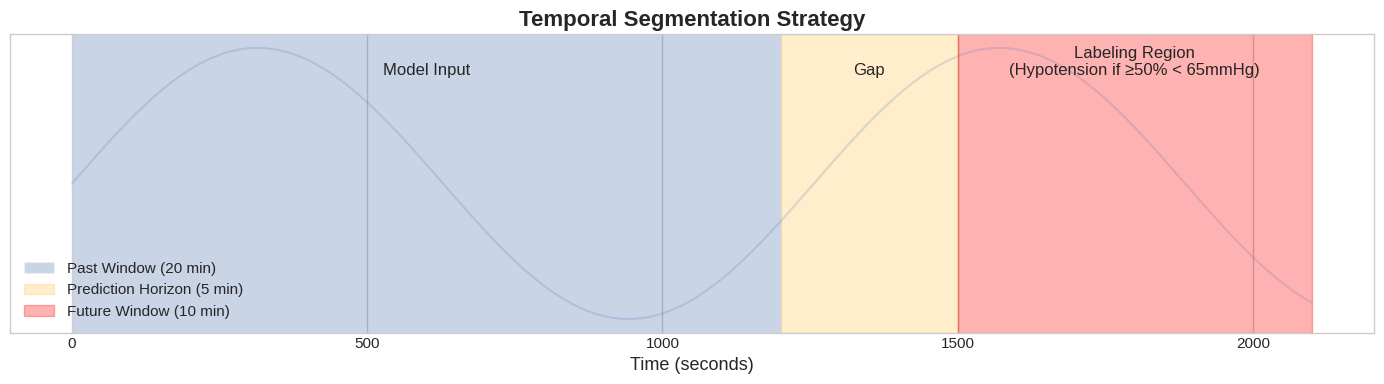

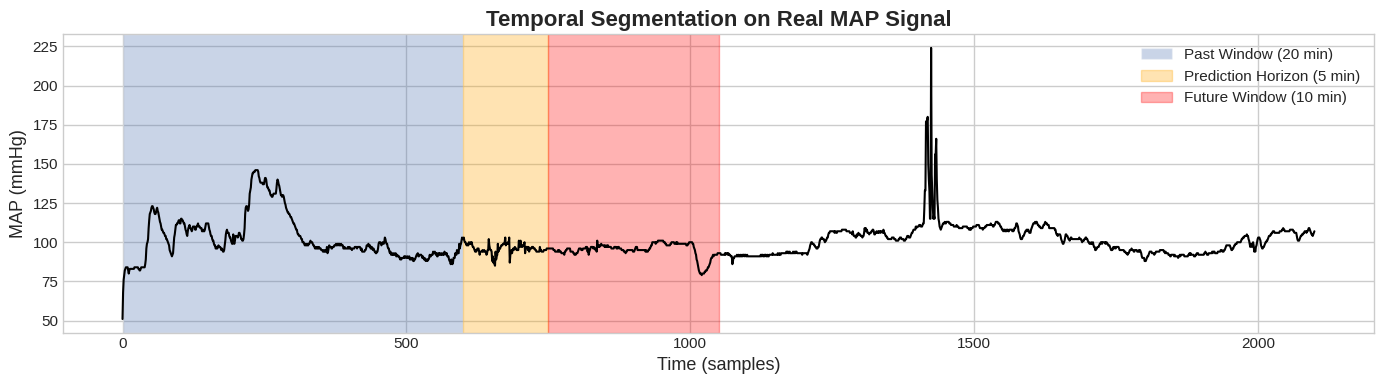

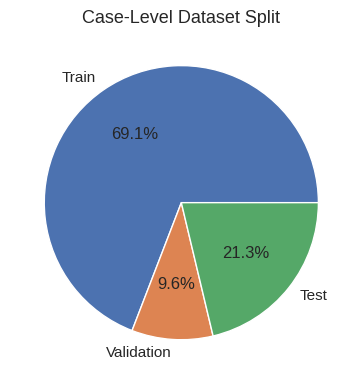

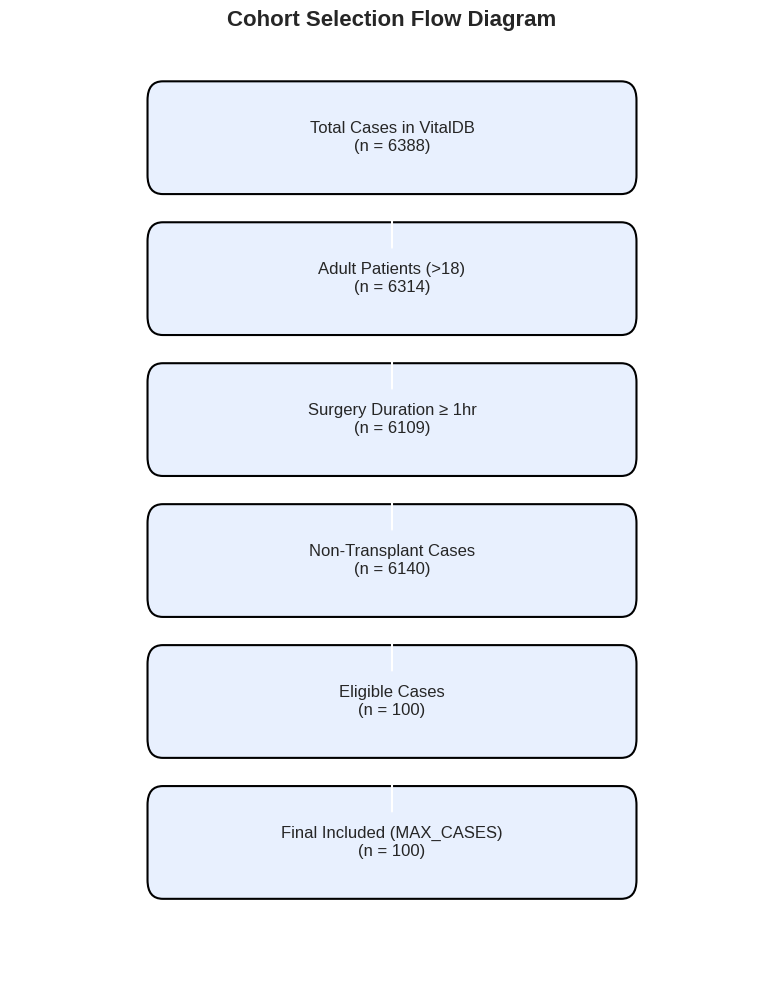

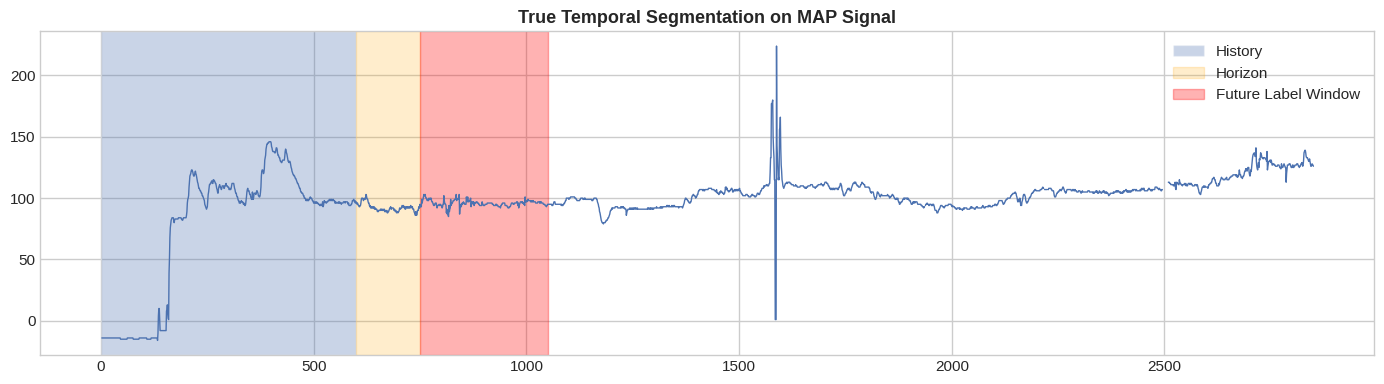

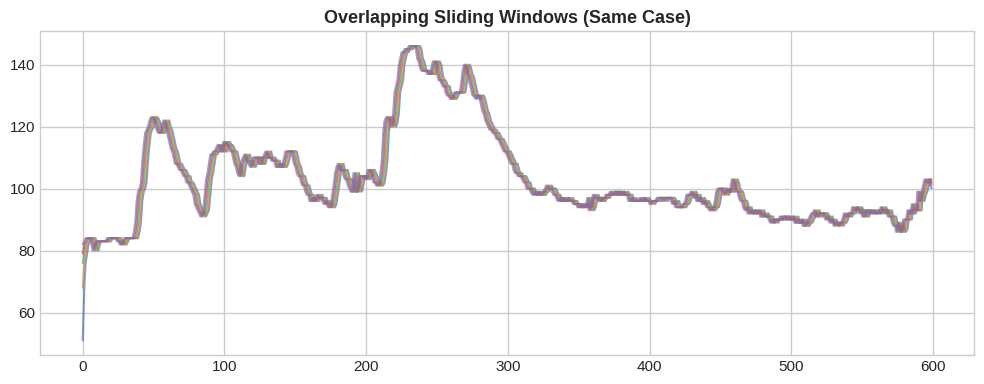

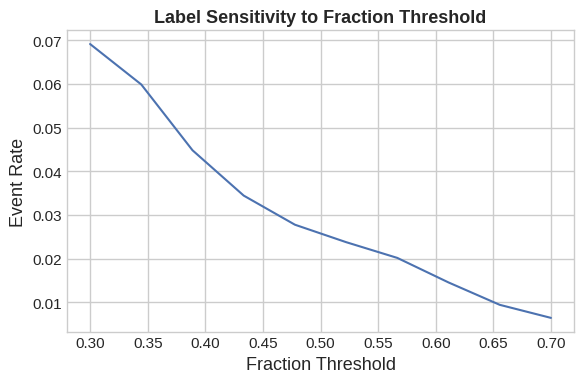

In [ ]:
# ============================================================
# TEMPORAL SEGMENTATION SCHEMATIC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

timeline = np.arange(0, 2100)  # 35 min timeline

plt.figure(figsize=(14,4))

# history
plt.axvspan(0, 1200, alpha=0.3, label="Past Window (20 min)")
# horizon
plt.axvspan(1200, 1500, alpha=0.2, color='orange',
            label="Prediction Horizon (5 min)")
# future
plt.axvspan(1500, 2100, alpha=0.3, color='red',
            label="Future Window (10 min)")

plt.plot(timeline, np.sin(timeline/200), alpha=0.2)

plt.text(600, 0.8, "Model Input", ha='center')
plt.text(1350, 0.8, "Gap", ha='center')
plt.text(1800, 0.8, "Labeling Region\n(Hypotension if ≥50% < 65mmHg)",
         ha='center')

plt.xlabel("Time (seconds)")
plt.yticks([])
plt.legend()
plt.title("Temporal Segmentation Strategy", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Temporal_Windowing.png", dpi=600)
plt.show()



# ============================================================
# FINAL PUBLICATION-READY TEMPORAL SEGMENTATION FIGURE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "legend.fontsize": 11
})

# -------------------------------
# Load example case
# -------------------------------

example_case = eligible_caseids[0]

mbps = vitaldb.load_case(
    example_case,
    ["Solar8000/ART_MBP"],
    SAMPLE_INTERVAL_SEC
).flatten().astype(float)

mbps[mbps < 40] = np.nan
mbps = mbps[~np.isnan(mbps)]

segment = mbps[:2100]  # ~35 minutes

time_minutes = np.arange(len(segment)) * SAMPLE_INTERVAL_SEC / 60

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(12,4))

plt.plot(time_minutes, segment, color="black", linewidth=1.2)

# History window
plt.axvspan(
    0,
    PAST_WINDOW_SAMPLES * SAMPLE_INTERVAL_SEC / 60,
    alpha=0.20,
    label="History (20 min)"
)

# Prediction horizon
plt.axvspan(
    PAST_WINDOW_SAMPLES * SAMPLE_INTERVAL_SEC / 60,
    (PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES) * SAMPLE_INTERVAL_SEC / 60,
    alpha=0.20,
    color="orange",
    label="Prediction Horizon (5 min)"
)

# Future label window
plt.axvspan(
    (PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES) * SAMPLE_INTERVAL_SEC / 60,
    (PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES + FUTURE_WINDOW_SAMPLES) * SAMPLE_INTERVAL_SEC / 60,
    alpha=0.20,
    color="red",
    label="Future Label Window (10 min)"
)

# Hypotension threshold
plt.axhline(
    65,
    linestyle="--",
    color="red",
    linewidth=1,
    label="Hypotension Threshold (65 mmHg)"
)

# -------------------------------
# Annotation for prediction point
# -------------------------------

prediction_time = PAST_WINDOW_SAMPLES * SAMPLE_INTERVAL_SEC / 60

plt.annotate(
    "Model predicts risk here",
    xy=(prediction_time, segment[int(PAST_WINDOW_SAMPLES)]),
    xytext=(prediction_time + 3, 120),
    arrowprops=dict(arrowstyle="->"),
)

# -------------------------------
# Annotation for hypotension episode
# -------------------------------

plt.annotate(
    "Sustained hypotension\n(≥50% below 65 mmHg)",
    xy=((prediction_time + 5), 60),
    xytext=(prediction_time + 8, 85),
    arrowprops=dict(arrowstyle="->"),
)

# -------------------------------
# Final formatting
# -------------------------------

plt.xlabel("Time (minutes)")
plt.ylabel("MAP (mmHg)")
plt.title(
    "Temporal Segmentation Strategy Applied to Real MAP Signal",
    fontweight="bold"
)

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(
    "Temporal_Segmentation_RealMAP_Final.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


import numpy as np
import matplotlib.pyplot as plt
import vitaldb

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15
})

# Pick one real case
example_case = eligible_caseids[1]

mbps = vitaldb.load_case(
    example_case,
    ["Solar8000/ART_MBP"],
    SAMPLE_INTERVAL_SEC
).flatten().astype(float)

mbps[mbps < 40] = np.nan
mbps = mbps[~np.isnan(mbps)]

segment = mbps[:2100]  # 35 minutes

# Convert samples to minutes
time_minutes = np.arange(len(segment)) * SAMPLE_INTERVAL_SEC / 60

plt.figure(figsize=(12,4))

# Plot MAP
plt.plot(time_minutes, segment, linewidth=1.3, color="black")

# Shaded regions
plt.axvspan(0,
            PAST_WINDOW_SAMPLES * SAMPLE_INTERVAL_SEC / 60,
            alpha=0.25, label="History (20 min)")

plt.axvspan(PAST_WINDOW_SAMPLES * SAMPLE_INTERVAL_SEC / 60,
            (PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES) * SAMPLE_INTERVAL_SEC / 60,
            alpha=0.25, color='orange',
            label="Prediction Horizon (5 min)")

plt.axvspan((PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES) * SAMPLE_INTERVAL_SEC / 60,
            (PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES + FUTURE_WINDOW_SAMPLES) * SAMPLE_INTERVAL_SEC / 60,
            alpha=0.25, color='red',
            label="Future Label Window (10 min)")

# Hypotension threshold
plt.axhline(65, linestyle='--', color='red', linewidth=1,
            label="Hypotension Threshold (65 mmHg)")

# Labels
plt.xlabel("Time (minutes)")
plt.ylabel("MAP (mmHg)")
plt.title("Temporal Segmentation Strategy Applied to Real MAP Signal",
          fontweight="bold")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("Temporal_Segmentation_RealMAP_Final.png",
            dpi=600, bbox_inches="tight")
plt.show()


import numpy as np
import matplotlib.pyplot as plt

# Pick one real case
example_case = eligible_caseids[0]

mbps = vitaldb.load_case(
    example_case,
    ["Solar8000/ART_MBP"],
    SAMPLE_INTERVAL_SEC
).flatten().astype(float)

mbps[mbps < 40] = np.nan

# Ensure enough length
mbps = mbps[~np.isnan(mbps)]

segment = mbps[:2100]  # 35 minutes worth

plt.figure(figsize=(14,4))

plt.plot(segment, linewidth=1.5, color="black")

# Past window
plt.axvspan(0, PAST_WINDOW_SAMPLES,
            alpha=0.3, label="Past Window (20 min)")

# Horizon
plt.axvspan(PAST_WINDOW_SAMPLES,
            PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES,
            alpha=0.3, color='orange',
            label="Prediction Horizon (5 min)")

# Future window
plt.axvspan(PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES,
            PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES + FUTURE_WINDOW_SAMPLES,
            alpha=0.3, color='red',
            label="Future Window (10 min)")

plt.xlabel("Time (samples)")
plt.ylabel("MAP (mmHg)")
plt.legend()
plt.title("Temporal Segmentation on Real MAP Signal",
          fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Temporal_Segmentation_RealMAP.png", dpi=600)
plt.show()




plt.figure(figsize=(6,4))
sizes = [len(train_cases), len(val_cases), len(test_cases)]
labels = ["Train", "Validation", "Test"]

plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Case-Level Dataset Split")
plt.tight_layout()
plt.savefig("Case_Split.png", dpi=600)
plt.show()


total_cases = len(df_cases)
adult_cases = len(set(df_cases[df_cases["age"] > 18]["caseid"]))
duration_cases = len(set(df_cases[df_cases["caseend"] > 3600]["caseid"]))
non_transplant_cases = len(set(df_cases[~df_cases["opname"].str.contains("transplant", case=False)]["caseid"]))
eligible_cases = len(eligible_caseids)

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(8, 10))
ax.axis("off")

def box(y, text):
    rect = FancyBboxPatch((0.2, y), 0.6, 0.08,
                          boxstyle="round,pad=0.02",
                          ec="black", fc="#E8F0FE", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(0.5, y+0.04, text, ha="center", va="center", fontsize=12)

box(0.85, f"Total Cases in VitalDB\n(n = {total_cases})")
box(0.70, f"Adult Patients (>18)\n(n = {adult_cases})")
box(0.55, f"Surgery Duration ≥ 1hr\n(n = {duration_cases})")
box(0.40, f"Non-Transplant Cases\n(n = {non_transplant_cases})")
box(0.25, f"Eligible Cases\n(n = {eligible_cases})")
box(0.10, f"Final Included (MAX_CASES)\n(n = {len(eligible_caseids)})")

for y in [0.82, 0.67, 0.52, 0.37, 0.22]:
    ax.annotate("", xy=(0.5, y), xytext=(0.5, y-0.05),
                arrowprops=dict(arrowstyle="->", linewidth=1.5))

plt.title("Cohort Selection Flow Diagram", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Dataset_FlowDiagram.png", dpi=600)
plt.show()

sample_case = eligible_caseids[0]
mbps = vitaldb.load_case(sample_case, ["Solar8000/ART_MBP"], SAMPLE_INTERVAL_SEC).flatten()

plt.figure(figsize=(14,4))
plt.plot(mbps[:3000], linewidth=1)

plt.axvspan(0, PAST_WINDOW_SAMPLES, alpha=0.3, label="History")
plt.axvspan(PAST_WINDOW_SAMPLES,
            PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES,
            alpha=0.2, color="orange", label="Horizon")
plt.axvspan(PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES,
            PAST_WINDOW_SAMPLES + PREDICTION_HORIZON_SAMPLES + FUTURE_WINDOW_SAMPLES,
            alpha=0.3, color="red", label="Future Label Window")

plt.legend()
plt.title("True Temporal Segmentation on MAP Signal", fontweight="bold")
plt.tight_layout()
plt.savefig("Dataset_TemporalSegmentation.png", dpi=600)
plt.show()

case_event_rates = []


example_case = eligible_caseids[0]
idx = case_ids == example_case

plt.figure(figsize=(10,4))
for i in range(5):
    start = i * 30
    plt.plot(X[idx][i].squeeze(), alpha=0.7)

plt.title("Overlapping Sliding Windows (Same Case)", fontweight="bold")
plt.tight_layout()
plt.savefig("Dataset_SlidingWindows.png", dpi=600)
plt.show()

thresholds = np.linspace(0.3, 0.7, 10)
event_rates = []

for th in thresholds:
    temp_y = []
    for seg in X_segments:
        temp_y.append(np.mean(seg < 65) >= th)
    event_rates.append(np.mean(temp_y))

plt.figure(figsize=(6,4))
plt.plot(thresholds, event_rates)
plt.xlabel("Fraction Threshold")
plt.ylabel("Event Rate")
plt.title("Label Sensitivity to Fraction Threshold", fontweight="bold")
plt.tight_layout()
plt.savefig("Dataset_LabelRobustness.png", dpi=600)
plt.show()

In [ ]:
ncase = len(caseids)
ntest = int(ncase * 0.2)
ntrain = ncase - ntest
caseids_train = caseids[:ntrain]
caseids_test = caseids[ncase - ntest:ncase]

# train set과 test set 으로 나눔
train_mask = np.isin(c, caseids_train)
test_mask = np.isin(c, caseids_test)

# invalid samples in test dataset is also needed for plotting
test_x = x[test_mask]
test_y = y[test_mask]
test_c = c[test_mask]

# only valid samples are required for the training dataset
train_x_valid = x[train_mask & valid_mask]
train_y_valid = y[train_mask & valid_mask]
test_x_valid = x[test_mask & valid_mask]
test_y_valid = y[test_mask & valid_mask]

testname = '{}cases {}ahead batchsize={} total {}, train {} ({} events {:.1f}%), test {} ({} events {:.1f}%)'.format(MAX_CASES, MINUTES_AHEAD, BATCH_SIZE, len(y), len(train_y_valid), sum(train_y_valid), 100*np.mean(train_y_valid), len(test_y_valid), sum(test_y_valid), 100*np.mean(test_y_valid))
testname

'100cases 5ahead batchsize=256 total 585483, train 423277 (18282 events 4.3%), test 120079 (4523 events 3.8%)'

In [ ]:
from keras.models import Sequential
from keras.models import Model, load_model
from keras.layers import Dense, LSTM, Input, BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf


#weight_path = tempdir + "/weights.hdf5"

# build a model
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D, BatchNormalization,
    Dropout, Bidirectional, GlobalAveragePooling1D,
    MultiHeadAttention, Add, LayerNormalization, Concatenate
)
from tensorflow.keras.models import Model
class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        score = self.w(x)                      # (B, T, 1)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

def build_mstan_model(input_shape, lstm_units=32, dropout=0.3):
    inp = Input(shape=input_shape)

    # ---- Short-term CNN ----
    cnn = Conv1D(32, 3, padding="causal", activation="relu")(inp)
    cnn = BatchNormalization()(cnn)
    cnn = Conv1D(64, 3, padding="causal", activation="relu")(cnn)
    cnn = BatchNormalization()(cnn)
    # ---- BiLSTM ----
    lstm = Bidirectional(LSTM(lstm_units, return_sequences=True))(inp)
    lstm = BatchNormalization()(lstm)

    # ---- Multi-Head Self-Attention ----
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(lstm, lstm)
    attn = Add()([lstm, attn])
    attn = LayerNormalization()(attn)

    # ---- Attention-based temporal pooling (KEY CHANGE) ----
    attn_pool = TemporalAttentionPooling()(attn)
    cnn_pool = GlobalAveragePooling1D()(cnn)

    # ---- Fusion ----
    fused = Concatenate()([cnn_pool, attn_pool])
    fused = Dense(64, activation="relu")(fused)
    fused = Dropout(dropout)(fused)

    out = Dense(1, activation="sigmoid")(fused)
    return Model(inp, out)



model = build_mstan_model(
    input_shape=train_x_valid.shape[1:],
    lstm_units=32
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="AUROC"),
        tf.keras.metrics.AUC(curve="PR", name="AUPRC")
    ]
)

model.summary()

hist = model.fit(train_x_valid, train_y_valid, validation_split=0.1, epochs=100, batch_size=BATCH_SIZE, class_weight={0:1, 1:5},
                callbacks=[EarlyStopping(monitor='val_loss', patience=30, verbose=0, mode='auto')])

from sklearn.metrics import auc, classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, f1_score, precision_recall_curve

# make prediction on the test dataset
test_y_pred = model.predict(test_x_valid).flatten()

precision, recall, thmbps = precision_recall_curve(test_y_valid, test_y_pred)
auprc = auc(recall, precision)

fpr, tpr, thmbps = roc_curve(test_y_valid, test_y_pred)
auroc = auc(fpr, tpr)

thval = 0.5
f1 = f1_score(test_y_valid, test_y_pred > thval)
acc = accuracy_score(test_y_valid, test_y_pred > thval)
tn, fp, fn, tp = confusion_matrix(test_y_valid, test_y_pred > thval).ravel()

testres = 'auroc={:.3f}, auprc={:.3f} acc={:.3f}, F1={:.3f}, PPV={:.1f}, NPV={:.1f}, TN={}, fp={}, fn={}, TP={}'.format(auroc, auprc, acc, f1, tp/(tp+fp)*100, tn/(tn+fn)*100, tn, fp, fn, tp)
print(testres)

# auroc curve
plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.close()

# auprc curve
plt.figure(figsize=(10, 10))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.close()

NameError: name 'train_x_valid' is not defined

In [ ]:
pip install vitaldb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 117.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 25.10.0 requires pandas<2.4.0dev0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 w

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import vitaldb
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D, BatchNormalization,
    Dropout, Bidirectional, GlobalAveragePooling1D,
    MultiHeadAttention, Add, LayerNormalization, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    auc, classification_report, confusion_matrix,
    accuracy_score, roc_curve, roc_auc_score,
    f1_score, precision_recall_curve
)

# ----------------------------------------------------------------------
# Configuration / hyperparameters
# ----------------------------------------------------------------------

RANDOM_SEED = 42

# VitalDB sampling interval: '2' here means 2 seconds per sample
SAMPLE_INTERVAL_SEC = 2
SAMPLES_PER_MIN = int(60 / SAMPLE_INTERVAL_SEC)  # 30 samples / min

# Window lengths (in minutes)
PAST_WINDOW_MIN = 20          # history length
PREDICTION_HORIZON_MIN = 5    # how far ahead to predict
FUTURE_WINDOW_MIN = 10        # window for defining hypotension label

# Convert windows from minutes to number of samples
PAST_WINDOW_SAMPLES = PAST_WINDOW_MIN * SAMPLES_PER_MIN
PREDICTION_HORIZON_SAMPLES = PREDICTION_HORIZON_MIN * SAMPLES_PER_MIN
FUTURE_WINDOW_SAMPLES = FUTURE_WINDOW_MIN * SAMPLES_PER_MIN

# Hypotension definition
HYPOTENSION_THRESHOLD = 65.0   # mmHg
HYPOTENSION_MIN_FRACTION = 0.5 # ≥50% of future samples < 65

# Data quality thresholds
MAX_NAN_FRACTION = 0.1         # max fraction of NaNs per segment
MAX_ARTIFACT_MAP = 150.0       # discard segments with MAP above this
MAX_STEP_CHANGE = 50.0         # discard segments with abrupt change > 50 mmHg

# Case-level limit
MAX_CASES = 100

# Train/val/test split (by case)
TRAIN_FRACTION = 0.7
VAL_FRACTION   = 0.1  # remainder is test

BATCH_SIZE = 256

# ----------------------------------------------------------------------
# 1. Load metadata tables
# ----------------------------------------------------------------------

df_trks  = pd.read_csv("https://api.vitaldb.net/trks")   # track list
df_cases = pd.read_csv("https://api.vitaldb.net/cases")  # case-level info

# ----------------------------------------------------------------------
# 2. Case-level inclusion / exclusion
# ----------------------------------------------------------------------

eligible_caseids = (
    set(df_trks[df_trks["tname"] == "Solar8000/ART_MBP"]["caseid"])           # has ART_MBP
    & set(df_cases[df_cases["age"] > 18]["caseid"])                           # adults
    & set(df_cases[df_cases["caseend"] > 3600]["caseid"])                     # ≥ 1 hour
    & set(df_cases[~df_cases["opname"].str.contains("transplant", case=False)]["caseid"])  # non-transplant
)

eligible_caseids = np.array(sorted(eligible_caseids))

print(f"Total {len(eligible_caseids)} eligible cases before MAX_CASES filter.")

rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(eligible_caseids)

eligible_caseids = eligible_caseids[:MAX_CASES]
print(f"Using {len(eligible_caseids)} cases after applying MAX_CASES = {MAX_CASES}.")

# ----------------------------------------------------------------------
# 3. Build segment-level dataset
# ----------------------------------------------------------------------

X_segments = []   # (num_segments, PAST_WINDOW_SAMPLES)
y_segments = []   # (num_segments,)
case_ids   = []   # (num_segments,)

min_required_len = (
    PAST_WINDOW_SAMPLES
    + PREDICTION_HORIZON_SAMPLES
    + FUTURE_WINDOW_SAMPLES
)

for caseid in eligible_caseids:
    print(f"Loading case {caseid}...", end="", flush=True)

    # Load MAP time series at 2-sec intervals
    mbps = vitaldb.load_case(caseid, ["Solar8000/ART_MBP"], SAMPLE_INTERVAL_SEC)
    if mbps is None or len(mbps) == 0:
        print(" no MAP track; skipping.")
        continue

    mbps = mbps.flatten().astype(float)

    # Very low values → NaN (e.g., before ART line placement)
    mbps[mbps < 40] = np.nan

    # Trim leading and trailing NaNs
    valid_mask = ~np.isnan(mbps)
    if not valid_mask.any():
        print(" all NaN; skipping.")
        continue

    idx = (np.cumsum(valid_mask) > 0) & (np.cumsum(valid_mask[::-1])[::-1] > 0)
    mbps = mbps[idx]

    if len(mbps) < min_required_len:
        print(" insufficient length; skipping.")
        continue

    n_case_segments = 0
    n_case_events   = 0

    # Sliding window (step = 1 sample; you can increase for fewer segments)
    for start_idx in range(0, len(mbps) - min_required_len + 1):
        past_start  = start_idx
        past_end    = start_idx + PAST_WINDOW_SAMPLES

        future_start = past_end + PREDICTION_HORIZON_SAMPLES
        future_end   = future_start + FUTURE_WINDOW_SAMPLES

        segx = mbps[past_start:past_end]
        segy = mbps[future_start:future_end]

        # --- Quality checks: NaNs ---
        if np.mean(np.isnan(segx)) > MAX_NAN_FRACTION:
            continue
        if np.mean(np.isnan(segy)) > MAX_NAN_FRACTION:
            continue

        # Fill NaNs in segx (the model input) by ffill/bfill
        segx_filled = pd.Series(segx).ffill().bfill().to_numpy()

        # Artifact rejection on history
        if (segx_filled > MAX_ARTIFACT_MAP).any():
            continue
        if (np.abs(np.diff(segx_filled)) > MAX_STEP_CHANGE).any():
            continue

        # For labeling, consider only valid future points
        valid_future = ~np.isnan(segy)
        if valid_future.sum() == 0:
            continue

        segy_valid = segy[valid_future]

        # Artifact rejection on future window (optional)
        if (segy_valid > MAX_ARTIFACT_MAP).any():
            continue
        if (np.abs(np.diff(segy_valid)) > MAX_STEP_CHANGE).any():
            continue

        hypotension_fraction = np.mean(segy_valid < HYPOTENSION_THRESHOLD)
        evt = int(hypotension_fraction >= HYPOTENSION_MIN_FRACTION)

        X_segments.append(segx_filled)
        y_segments.append(evt)
        case_ids.append(caseid)

        n_case_segments += 1
        if evt:
            n_case_events += 1

    if n_case_segments > 0:
        event_rate = 100.0 * n_case_events / n_case_segments
        print(f" {n_case_segments} segments, {n_case_events} ({event_rate:.1f}%) hypotension events.")
    else:
        print(" no usable segments.")

# ----------------------------------------------------------------------
# 4. Numpy arrays and reshape for LSTM
# ----------------------------------------------------------------------

X = np.asarray(X_segments, dtype=float)    # (N, T)
y = np.asarray(y_segments, dtype=int)      # (N,)
case_ids = np.asarray(case_ids, dtype=int) # (N,)

# Add feature dimension: (N, T, 1)
X = X[..., None]

print("\nFinal dataset shapes:")
print("X:", X.shape)         # (N, T, 1)
print("y:", y.shape)
print("case_ids:", case_ids.shape)

# ----------------------------------------------------------------------
# 5. Case-level train/val/test split
# ----------------------------------------------------------------------

unique_cases = np.unique(case_ids)
rng.shuffle(unique_cases)

n_cases = len(unique_cases)
n_train = int(TRAIN_FRACTION * n_cases)
n_val   = int(VAL_FRACTION * n_cases)
n_test  = n_cases - n_train - n_val

train_cases = unique_cases[:n_train]
val_cases   = unique_cases[n_train:n_train + n_val]
test_cases  = unique_cases[n_train + n_val:]

def mask_from_cases(all_case_ids, selected_cases):
    selected = set(selected_cases.tolist())
    return np.array([cid in selected for cid in all_case_ids], dtype=bool)

train_mask = mask_from_cases(case_ids, train_cases)
val_mask   = mask_from_cases(case_ids, val_cases)
test_mask  = mask_from_cases(case_ids, test_cases)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]


import numpy as np
import os

SAVE_PATH = "vitaldb_hypotension_dataset.npz"

np.savez_compressed(
    SAVE_PATH,
    X=X,
    y=y,
    case_ids=case_ids,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(f"Dataset saved to {SAVE_PATH}")


print("\nCase-level split:")
print(" Train segments:", X_train.shape[0], "from", len(train_cases), "cases")
print(" Val segments:  ", X_val.shape[0],   "from", len(val_cases),   "cases")
print(" Test segments: ", X_test.shape[0],  "from", len(test_cases),  "cases")

# ----------------------------------------------------------------------
# 6. Model: MSTAN-style (CNN + BiLSTM + self-attention + attention pooling)
# ----------------------------------------------------------------------

class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        # x: (B, T, F)
        score = self.w(x)                # (B, T, 1)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)  # (B, F)

def build_mstan_model(input_shape, lstm_units=32, dropout=0.3):
    inp = Input(shape=input_shape)

    # Short-term CNN branch
    cnn = Conv1D(32, 3, padding="causal", activation="relu")(inp)
    cnn = BatchNormalization()(cnn)
    cnn = Conv1D(64, 3, padding="causal", activation="relu")(cnn)
    cnn = BatchNormalization()(cnn)
    cnn_pool = GlobalAveragePooling1D()(cnn)

    # BiLSTM + Multi-head self-attention branch
    lstm = Bidirectional(LSTM(lstm_units, return_sequences=True))(inp)
    lstm = BatchNormalization()(lstm)

    attn = MultiHeadAttention(num_heads=4, key_dim=16)(lstm, lstm)
    attn = Add()([lstm, attn])
    attn = LayerNormalization()(attn)

    attn_pool = TemporalAttentionPooling()(attn)

    # Fusion
    fused = Concatenate()([cnn_pool, attn_pool])
    fused = Dense(64, activation="relu")(fused)
    fused = Dropout(dropout)(fused)

    out = Dense(1, activation="sigmoid")(fused)

    model = Model(inp, out)
    return model

input_shape = X_train.shape[1:]  # (T, 1)

model = build_mstan_model(
    input_shape=input_shape,
    lstm_units=32,
    dropout=0.3
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="AUROC"),
        tf.keras.metrics.AUC(curve="PR", name="AUPRC")
    ]
)

model.summary()

# Optional: compute class weights from train label distribution
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {int(c): w for c, w in zip(classes, class_weights)}
print("\nClass weights:", class_weight_dict)

# ----------------------------------------------------------------------
# 7. Training
# ----------------------------------------------------------------------

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------------------------------------------------
# 8. Evaluation on test set
# ----------------------------------------------------------------------

test_y_pred = model.predict(X_test).flatten()

precision, recall, thresh_pr = precision_recall_curve(y_test, test_y_pred)
auprc = auc(recall, precision)

fpr, tpr, thresh_roc = roc_curve(y_test, test_y_pred)
auroc = auc(fpr, tpr)

thval = 0.5
y_pred_label = (test_y_pred > thval).astype(int)

f1  = f1_score(y_test, y_pred_label)
acc = accuracy_score(y_test, y_pred_label)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_label).ravel()

testres = (
    f"auroc={auroc:.3f}, auprc={auprc:.3f}, acc={acc:.3f}, F1={f1:.3f}, "
    f"PPV={tp/(tp+fp)*100:.1f}, NPV={tn/(tn+fn)*100:.1f}, "
    f"TN={tn}, FP={fp}, FN={fn}, TP={tp}"
)
print("\nTest results:")
print(testres)

# ----------------------------------------------------------------------
# 9. Curves (AUROC & AUPRC)
# ----------------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()

Total 3420 eligible cases before MAX_CASES filter.
Using 100 cases after applying MAX_CASES = 100.
Loading case 2771... 699 segments, 0 (0.0%) hypotension events.
Loading case 241... 6017 segments, 824 (13.7%) hypotension events.
Loading case 1880... all NaN; skipping.
Loading case 5367... 1929 segments, 0 (0.0%) hypotension events.
Loading case 4101... 1994 segments, 0 (0.0%) hypotension events.
Loading case 559... 4347 segments, 0 (0.0%) hypotension events.
Loading case 244... 2714 segments, 1255 (46.2%) hypotension events.
Loading case 4767... 1164 segments, 0 (0.0%) hypotension events.
Loading case 3249... 1408 segments, 0 (0.0%) hypotension events.
Loading case 2537... 2996 segments, 0 (0.0%) hypotension events.
Loading case 1918... 4447 segments, 0 (0.0%) hypotension events.
Loading case 972... 4071 segments, 61 (1.5%) hypotension events.
Loading case 140... 5786 segments, 0 (0.0%) hypotension events.
Loading case 3606... 4328 segments, 0 (0.0%) hypotension events.
Loading case 3

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 600, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 600, 64)   │      8,704 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 600, 32)   │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 600, 64)   │        256 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 600, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 600, 64)   │     16,640 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 600, 64)   │      6,208 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 600, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 600, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 600, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention… │ (None, 64)        │         65 │ layer_normalizat… │
│ (TemporalAttention… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ temporal_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,834 (159.51 KB)

 Trainable params: 40,514 (158.26 KB)

 Non-trainable params: 320 (1.25 KB)


Class weights: {0: np.float64(0.5125485454678684), 1: np.float64(20.42262773722628)}
Epoch 1/100
638/766 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - AUPRC: 0.1745 - AUROC: 0.9017 - accuracy: 0.7940 - loss: 0.3917

KeyboardInterrupt: 

In [ ]:
# ============================================================
# Hypotension Prediction - Full Benchmark Script
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D,
    GlobalAveragePooling1D, Dropout,
    Bidirectional, BatchNormalization,
    MultiHeadAttention, Add,
    LayerNormalization, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 1️⃣ Load Dataset
# ============================================================

print("Loading dataset...")

data = np.load("vitaldb_hypotension_dataset.npz")

X = data["X"]
y = data["y"]
train_mask = data["train_mask"]
val_mask = data["val_mask"]
test_mask = data["test_mask"]

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# Flatten for classical ML
X_train_flat = X_train.squeeze(-1)
X_val_flat   = X_val.squeeze(-1)
X_test_flat  = X_test.squeeze(-1)

# ============================================================
# 2️⃣ Evaluation Function
# ============================================================

def evaluate_model(name, y_true, y_prob):

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    return {
        "Model": name,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Accuracy": acc,
        "F1": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }

results = []

# ============================================================
# 3️⃣ Classical ML Models
# ============================================================

print("\nTraining Logistic Regression...")
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
logreg.fit(X_train_flat, y_train)
y_prob = logreg.predict_proba(X_test_flat)[:,1]
results.append(evaluate_model("Logistic Regression", y_test, y_prob))

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train_flat, y_train)
y_prob = rf.predict_proba(X_test_flat)[:,1]
results.append(evaluate_model("Random Forest", y_test, y_prob))

print("Training XGBoost...")
scale_pos = (len(y_train) - sum(y_train)) / (sum(y_train) + 1e-8)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb.fit(X_train_flat, y_train)
y_prob = xgb.predict_proba(X_test_flat)[:,1]
results.append(evaluate_model("XGBoost", y_test, y_prob))

# ============================================================
# 4️⃣ Deep Learning Baselines
# ============================================================

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# ------------------------------------------------------------
# Vanilla LSTM
# ------------------------------------------------------------

def build_lstm(input_shape):
    inp = Input(shape=input_shape)
    x = LSTM(32)(inp)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("Training Vanilla LSTM...")
model_lstm = build_lstm(X_train.shape[1:])
model_lstm.compile(optimizer="adam", loss="binary_crossentropy")
model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    callbacks=[early_stop]
)
y_prob = model_lstm.predict(X_test).flatten()
results.append(evaluate_model("Vanilla LSTM", y_test, y_prob))

# ------------------------------------------------------------
# CNN Only
# ------------------------------------------------------------

def build_cnn(input_shape):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, activation="relu")(inp)
    x = Conv1D(64, 3, activation="relu")(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("Training CNN Only...")
model_cnn = build_cnn(X_train.shape[1:])
model_cnn.compile(optimizer="adam", loss="binary_crossentropy")
model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    callbacks=[early_stop]
)
y_prob = model_cnn.predict(X_test).flatten()
results.append(evaluate_model("CNN Only", y_test, y_prob))

# ------------------------------------------------------------
# CNN + LSTM (No Attention)
# ------------------------------------------------------------

def build_cnn_lstm(input_shape):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, activation="relu")(inp)
    x = LSTM(32)(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("Training CNN + LSTM...")
model_cnn_lstm = build_cnn_lstm(X_train.shape[1:])
model_cnn_lstm.compile(optimizer="adam", loss="binary_crossentropy")
model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    callbacks=[early_stop]
)
y_prob = model_cnn_lstm.predict(X_test).flatten()
results.append(evaluate_model("CNN + LSTM", y_test, y_prob))

# ============================================================
# 5️⃣ MSTAN (Proposed Model)
# ============================================================

class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        score = self.w(x)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

def build_mstan(input_shape):

    inp = Input(shape=input_shape)

    # CNN branch
    cnn = Conv1D(32, 3, padding="causal", activation="relu")(inp)
    cnn = BatchNormalization()(cnn)
    cnn = Conv1D(64, 3, padding="causal", activation="relu")(cnn)
    cnn = BatchNormalization()(cnn)
    cnn_pool = GlobalAveragePooling1D()(cnn)

    # BiLSTM + Attention branch
    lstm = Bidirectional(LSTM(32, return_sequences=True))(inp)
    lstm = BatchNormalization()(lstm)

    attn = MultiHeadAttention(num_heads=4, key_dim=16)(lstm, lstm)
    attn = Add()([lstm, attn])
    attn = LayerNormalization()(attn)

    attn_pool = TemporalAttentionPooling()(attn)

    fused = Concatenate()([cnn_pool, attn_pool])
    fused = Dense(64, activation="relu")(fused)
    fused = Dropout(0.3)(fused)

    out = Dense(1, activation="sigmoid")(fused)

    return Model(inp, out)

print("Training MSTAN (Proposed)...")

model_mstan = build_mstan(X_train.shape[1:])
model_mstan.compile(optimizer="adam", loss="binary_crossentropy")

model_mstan.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    callbacks=[early_stop]
)

y_prob = model_mstan.predict(X_test).flatten()
results.append(evaluate_model("MSTAN (Proposed)", y_test, y_prob))

# ============================================================
# 6️⃣ Final Comparison Table
# ============================================================

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("AUROC", ascending=False)

print("\n================ FINAL MODEL COMPARISON ================\n")
print(df_results.round(4))

Loading dataset...
Train: (195853, 600, 1)
Val: (27658, 600, 1)
Test: (66761, 600, 1)

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training Vanilla LSTM...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Hypotension Prediction - Full Benchmark Script (BALANCED + MSTAN)
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt  # only if you later want plots

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D,
    GlobalAveragePooling1D, Dropout,
    Bidirectional, BatchNormalization,
    MultiHeadAttention, Add,
    LayerNormalization, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enforce deterministic GPU ops (important in Colab)
tf.config.experimental.enable_op_determinism()
# ============================================================
# 1️⃣ Load Dataset
# ============================================================

print("Loading dataset...")

data = np.load("vitaldb_hypotension_dataset.npz")

X = data["X"]
y = data["y"]
train_mask = data["train_mask"]
val_mask = data["val_mask"]
test_mask = data["test_mask"]

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("\nOriginal distributions (0 = non-hypo, 1 = hypo):")
print("Train:", np.bincount(y_train))
print("Val:  ", np.bincount(y_val))
print("Test: ", np.bincount(y_test))

# ============================================================
# 2️⃣ Balance Function (1:1 undersampling)
# ============================================================

def balance_dataset(X_split, y_split, seed=42):
    rng = np.random.default_rng(seed)

    pos_idx = np.where(y_split == 1)[0]
    neg_idx = np.where(y_split == 0)[0]

    n_pos = len(pos_idx)
    n_neg = len(neg_idx)

    if n_pos == 0 or n_neg == 0:
        return X_split, y_split

    n_neg_target = n_pos  # 1:1 ratio
    if n_neg_target > n_neg:
        n_neg_target = n_neg

    neg_sampled = rng.choice(neg_idx, size=n_neg_target, replace=False)

    balanced_idx = np.concatenate([pos_idx, neg_sampled])
    rng.shuffle(balanced_idx)

    return X_split[balanced_idx], y_split[balanced_idx]

X_train, y_train = balance_dataset(X_train, y_train, seed=42)
X_val,   y_val   = balance_dataset(X_val,   y_val,   seed=43)
X_test,  y_test  = balance_dataset(X_test,  y_test,  seed=44)

print("\nBalanced distributions (0 = non-hypo, 1 = hypo):")
print("Train:", np.bincount(y_train))
print("Val:  ", np.bincount(y_val))
print("Test: ", np.bincount(y_test))

# Flatten for classical ML
X_train_flat = X_train.squeeze(-1)
X_val_flat   = X_val.squeeze(-1)
X_test_flat  = X_test.squeeze(-1)

# ============================================================
# 3️⃣ Evaluation Function
# ============================================================

def evaluate_model(name, y_true, y_prob):

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    print(f"\n{name} Results:")
    print(f"  AUROC:      {auroc:.4f}")
    print(f"  AUPRC:      {auprc:.4f}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  F1:         {f1:.4f}")
    print(f"  Sensitivity:{sensitivity:.4f}")
    print(f"  Specificity:{specificity:.4f}")

    return {
        "Model": name,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Accuracy": acc,
        "F1": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
    "y_prob": y_prob  # STORE probabilities
    }

results = []

# ============================================================
# 4️⃣ Classical ML Models
# ============================================================

print("\nTraining Logistic Regression...")
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
logreg.fit(X_train_flat, y_train)
y_prob = logreg.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("Logistic Regression", y_test, y_prob))

print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1
)
rf.fit(X_train_flat, y_train)
y_prob = rf.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("Random Forest", y_test, y_prob))

print("\nTraining XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb.fit(X_train_flat, y_train)
y_prob = xgb.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("XGBoost", y_test, y_prob))

# ============================================================
# 5️⃣ Deep Learning Baselines
# ============================================================

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# ------------------------------------------------------------
# Vanilla LSTM
# ------------------------------------------------------------

def build_lstm(input_shape):
    inp = Input(shape=input_shape)
    x = LSTM(32)(inp)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining Vanilla LSTM...")
model_lstm = build_lstm(X_train.shape[1:])
model_lstm.compile(optimizer="adam", loss="binary_crossentropy")
model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)
y_prob = model_lstm.predict(X_test).flatten()
results.append(evaluate_model("Vanilla LSTM", y_test, y_prob))

# ------------------------------------------------------------
# CNN Only
# ------------------------------------------------------------

def build_cnn(input_shape):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, activation="relu")(inp)
    x = Conv1D(64, 3, activation="relu")(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining CNN Only...")
model_cnn = build_cnn(X_train.shape[1:])
model_cnn.compile(optimizer="adam", loss="binary_crossentropy")
model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)
y_prob = model_cnn.predict(X_test).flatten()
results.append(evaluate_model("CNN Only", y_test, y_prob))

# ------------------------------------------------------------
# CNN + LSTM (No Attention)
# ------------------------------------------------------------

def build_cnn_lstm(input_shape):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, activation="relu")(inp)
    x = LSTM(32)(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining CNN + LSTM...")
model_cnn_lstm = build_cnn_lstm(X_train.shape[1:])
model_cnn_lstm.compile(optimizer="adam", loss="binary_crossentropy")
model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    callbacks=[early_stop]
)
y_prob = model_cnn_lstm.predict(X_test).flatten()
results.append(evaluate_model("CNN + LSTM", y_test, y_prob))

# ============================================================
# 6️⃣ MSTAN (Proposed Model)
# ============================================================
# ------------------------------
# Temporal Attention Pooling
# ------------------------------

class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        score = self.w(x)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

# ------------------------------
# Improved MSTAN-v3
# ------------------------------
def add_derivative_channel(X):
    dX = np.diff(X, axis=1, prepend=X[:, :1, :])
    return np.concatenate([X, dX], axis=-1)

X_train_t = add_derivative_channel(X_train)
X_val_t   = add_derivative_channel(X_val)
X_test_t  = add_derivative_channel(X_test)


from tensorflow.keras.layers import Conv1D, Add, BatchNormalization, Activation


from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    MultiHeadAttention,
    LayerNormalization
)
from tensorflow.keras.models import Model

class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        score = self.w(x)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)


def build_multiscale_tcn(input_shape, dropout=0.30):

    inp = Input(shape=input_shape)

    # Multi-scale convolutions (parallel)
    x1 = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x2 = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x3 = Conv1D(64, 9, padding='causal', activation='relu')(inp)

    x = Concatenate()([x1, x2, x3])
    x = BatchNormalization()(x)

    # Simple residual block
    x_res = Conv1D(64, 3, padding='causal', activation='relu')(x)
    x_res = BatchNormalization()(x_res)
    x = Add()([Conv1D(64, 1, padding='same')(x), x_res])

    # Dilated refinement
    x = Conv1D(64, 3, padding='causal', dilation_rate=2, activation='relu')(x)
    x = BatchNormalization()(x)

    # Attention pooling (lightweight)
    pooled = TemporalAttentionPooling()(x)
    #pooled = GlobalAveragePooling1D()(x)
    # Dense head
    x = Dense(256, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)

    out = Dense(1, activation='sigmoid')(x)

    return Model(inp, out)


model_tcn = build_multiscale_tcn(X_train_t.shape[1:])

model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUROC")]
)

model_tcn.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=60,
    batch_size=256,
    verbose=1,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)

y_prob = model_tcn.predict(X_test_t).flatten()
results.append(evaluate_model("Multiscale TCN (Proposed)", y_test, y_prob))


# ------------------------------------------------------------
# GRU
# ------------------------------------------------------------

from tensorflow.keras.layers import GRU

def build_gru(input_shape):
    inp = Input(shape=input_shape)
    x = GRU(32)(inp)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining GRU...")
model_gru = build_gru(X_train.shape[1:])
model_gru.compile(optimizer="adam", loss="binary_crossentropy")

model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    shuffle=False,
    callbacks=[early_stop]
)

y_prob = model_gru.predict(X_test).flatten()
results.append(evaluate_model("GRU", y_test, y_prob))


# ------------------------------------------------------------
# CNN + GRU
# ------------------------------------------------------------

def build_cnn_gru(input_shape):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, activation="relu")(inp)
    x = GRU(32)(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining CNN + GRU...")
model_cnn_gru = build_cnn_gru(X_train.shape[1:])
model_cnn_gru.compile(optimizer="adam", loss="binary_crossentropy")

model_cnn_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    shuffle=False,
    callbacks=[early_stop]
)

y_prob = model_cnn_gru.predict(X_test).flatten()
results.append(evaluate_model("CNN + GRU", y_test, y_prob))


# ------------------------------------------------------------
# CNN + Self-Attention
# ------------------------------------------------------------

def build_cnn_attention(input_shape):
    inp = Input(shape=input_shape)

    x = Conv1D(64, 3, activation="relu")(inp)
    x = BatchNormalization()(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining CNN + Attention...")
model_cnn_att = build_cnn_attention(X_train.shape[1:])
model_cnn_att.compile(optimizer="adam", loss="binary_crossentropy")

model_cnn_att.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    shuffle=False,
    callbacks=[early_stop]
)

y_prob = model_cnn_att.predict(X_test).flatten()
results.append(evaluate_model("CNN + Attention", y_test, y_prob))

# ------------------------------------------------------------
# Transformer Encoder
# ------------------------------------------------------------

def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.3):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dense(x.shape[-1])(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x

def build_transformer(input_shape):
    inp = Input(shape=input_shape)

    x = Dense(64)(inp)  # projection

    x = transformer_block(x, head_size=32, num_heads=4, ff_dim=128)
    x = transformer_block(x, head_size=32, num_heads=4, ff_dim=128)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)

    out = Dense(1, activation="sigmoid")(x)

    return Model(inp, out)

print("\nTraining Transformer Encoder...")
model_transformer = build_transformer(X_train.shape[1:])
model_transformer.compile(optimizer="adam", loss="binary_crossentropy")

model_transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    verbose=0,
    shuffle=False,
    callbacks=[early_stop]
)

y_prob = model_transformer.predict(X_test).flatten()
results.append(evaluate_model("Transformer Encoder", y_test, y_prob))


# ============================================================
# 7️⃣ Final Comparison Table
# ============================================================

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("AUROC", ascending=False)

print("\n================ FINAL MODEL COMPARISON ================\n")
print(df_results.round(4))

Loading dataset...

Original distributions (0 = non-hypo, 1 = hypo):
Train: [191058   4795]
Val:   [26603  1055]
Test:  [65352  1409]

Balanced distributions (0 = non-hypo, 1 = hypo):
Train: [4795 4795]
Val:   [1055 1055]
Test:  [1409 1409]

Training Logistic Regression...

Logistic Regression Results:
  AUROC:      0.8342
  AUPRC:      0.8227
  Accuracy:   0.7363
  F1:         0.7396
  Sensitivity:0.7488
  Specificity:0.7239

Training Random Forest...

Random Forest Results:
  AUROC:      0.8493
  AUPRC:      0.8137
  Accuracy:   0.6167
  F1:         0.4033
  Sensitivity:0.2590
  Specificity:0.9744

Training XGBoost...

XGBoost Results:
  AUROC:      0.8119
  AUPRC:      0.7917
  Accuracy:   0.6391
  F1:         0.4744
  Sensitivity:0.3258
  Specificity:0.9524

Training Vanilla LSTM...
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Vanilla LSTM Results:
  AUROC:      0.9269
  AUPRC:      0.9156
  Accuracy:   0.8520
  F1:         0.8556
  Sensitivity:0.8765
  Specificity:0.8275

Training CNN

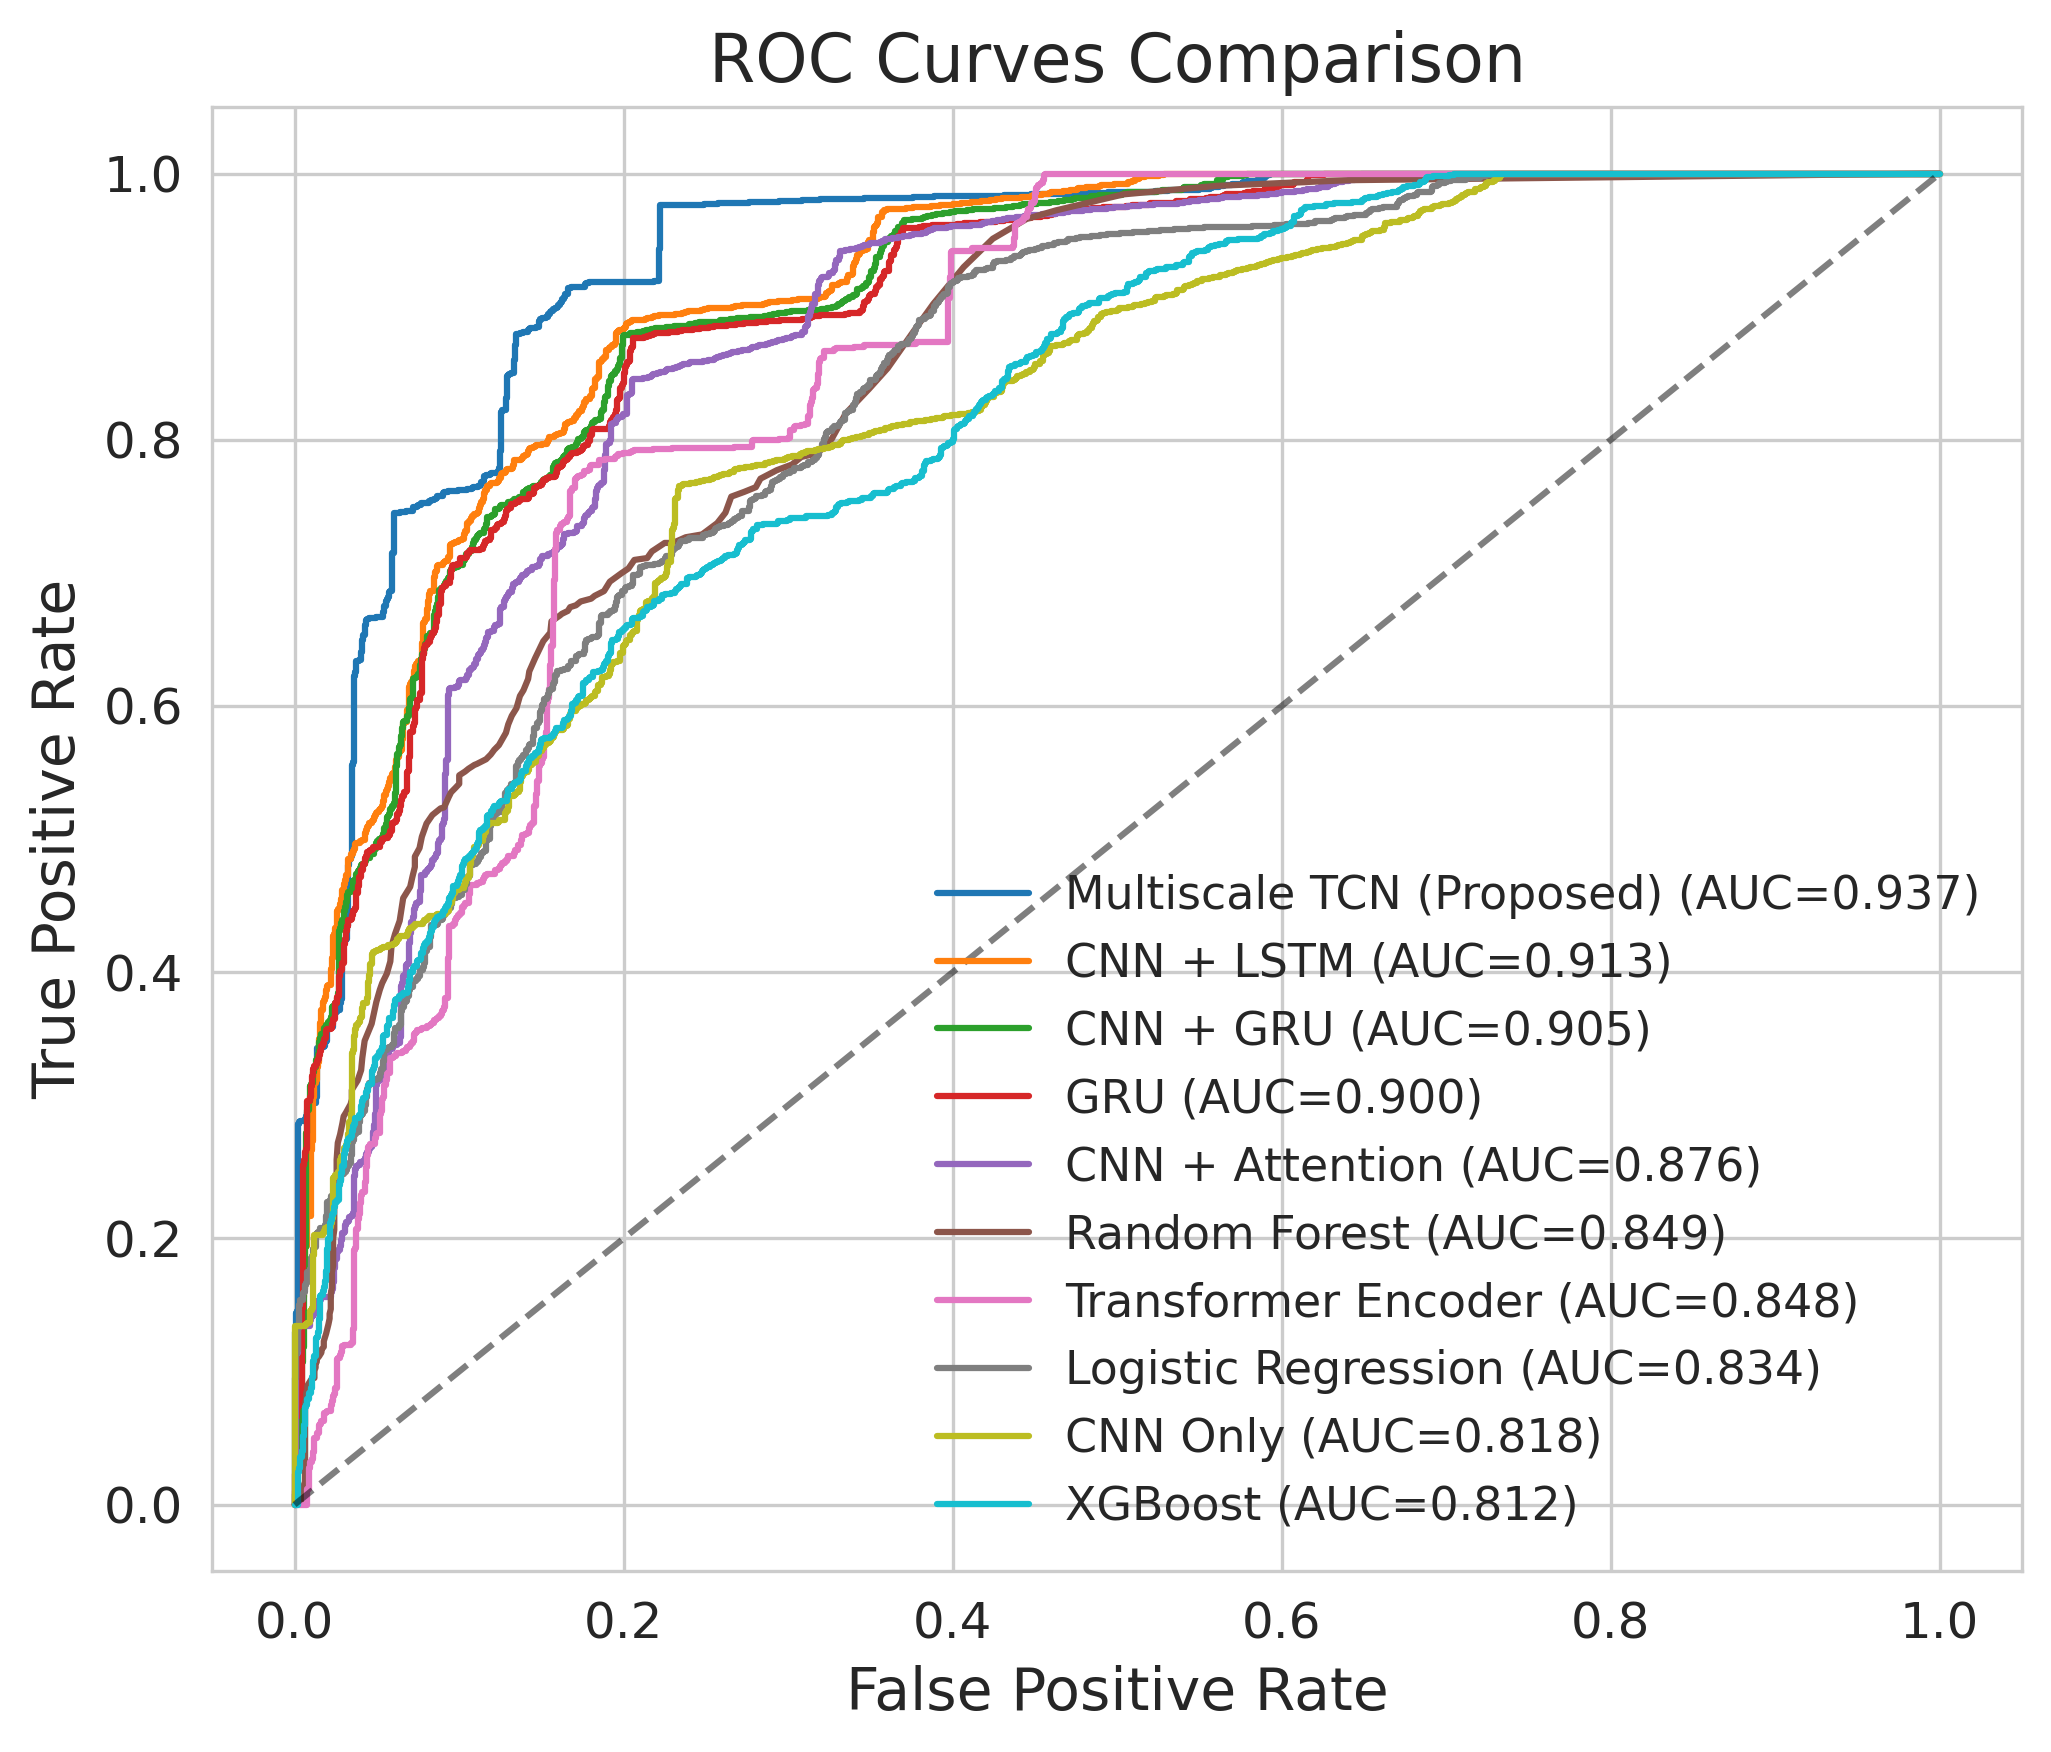

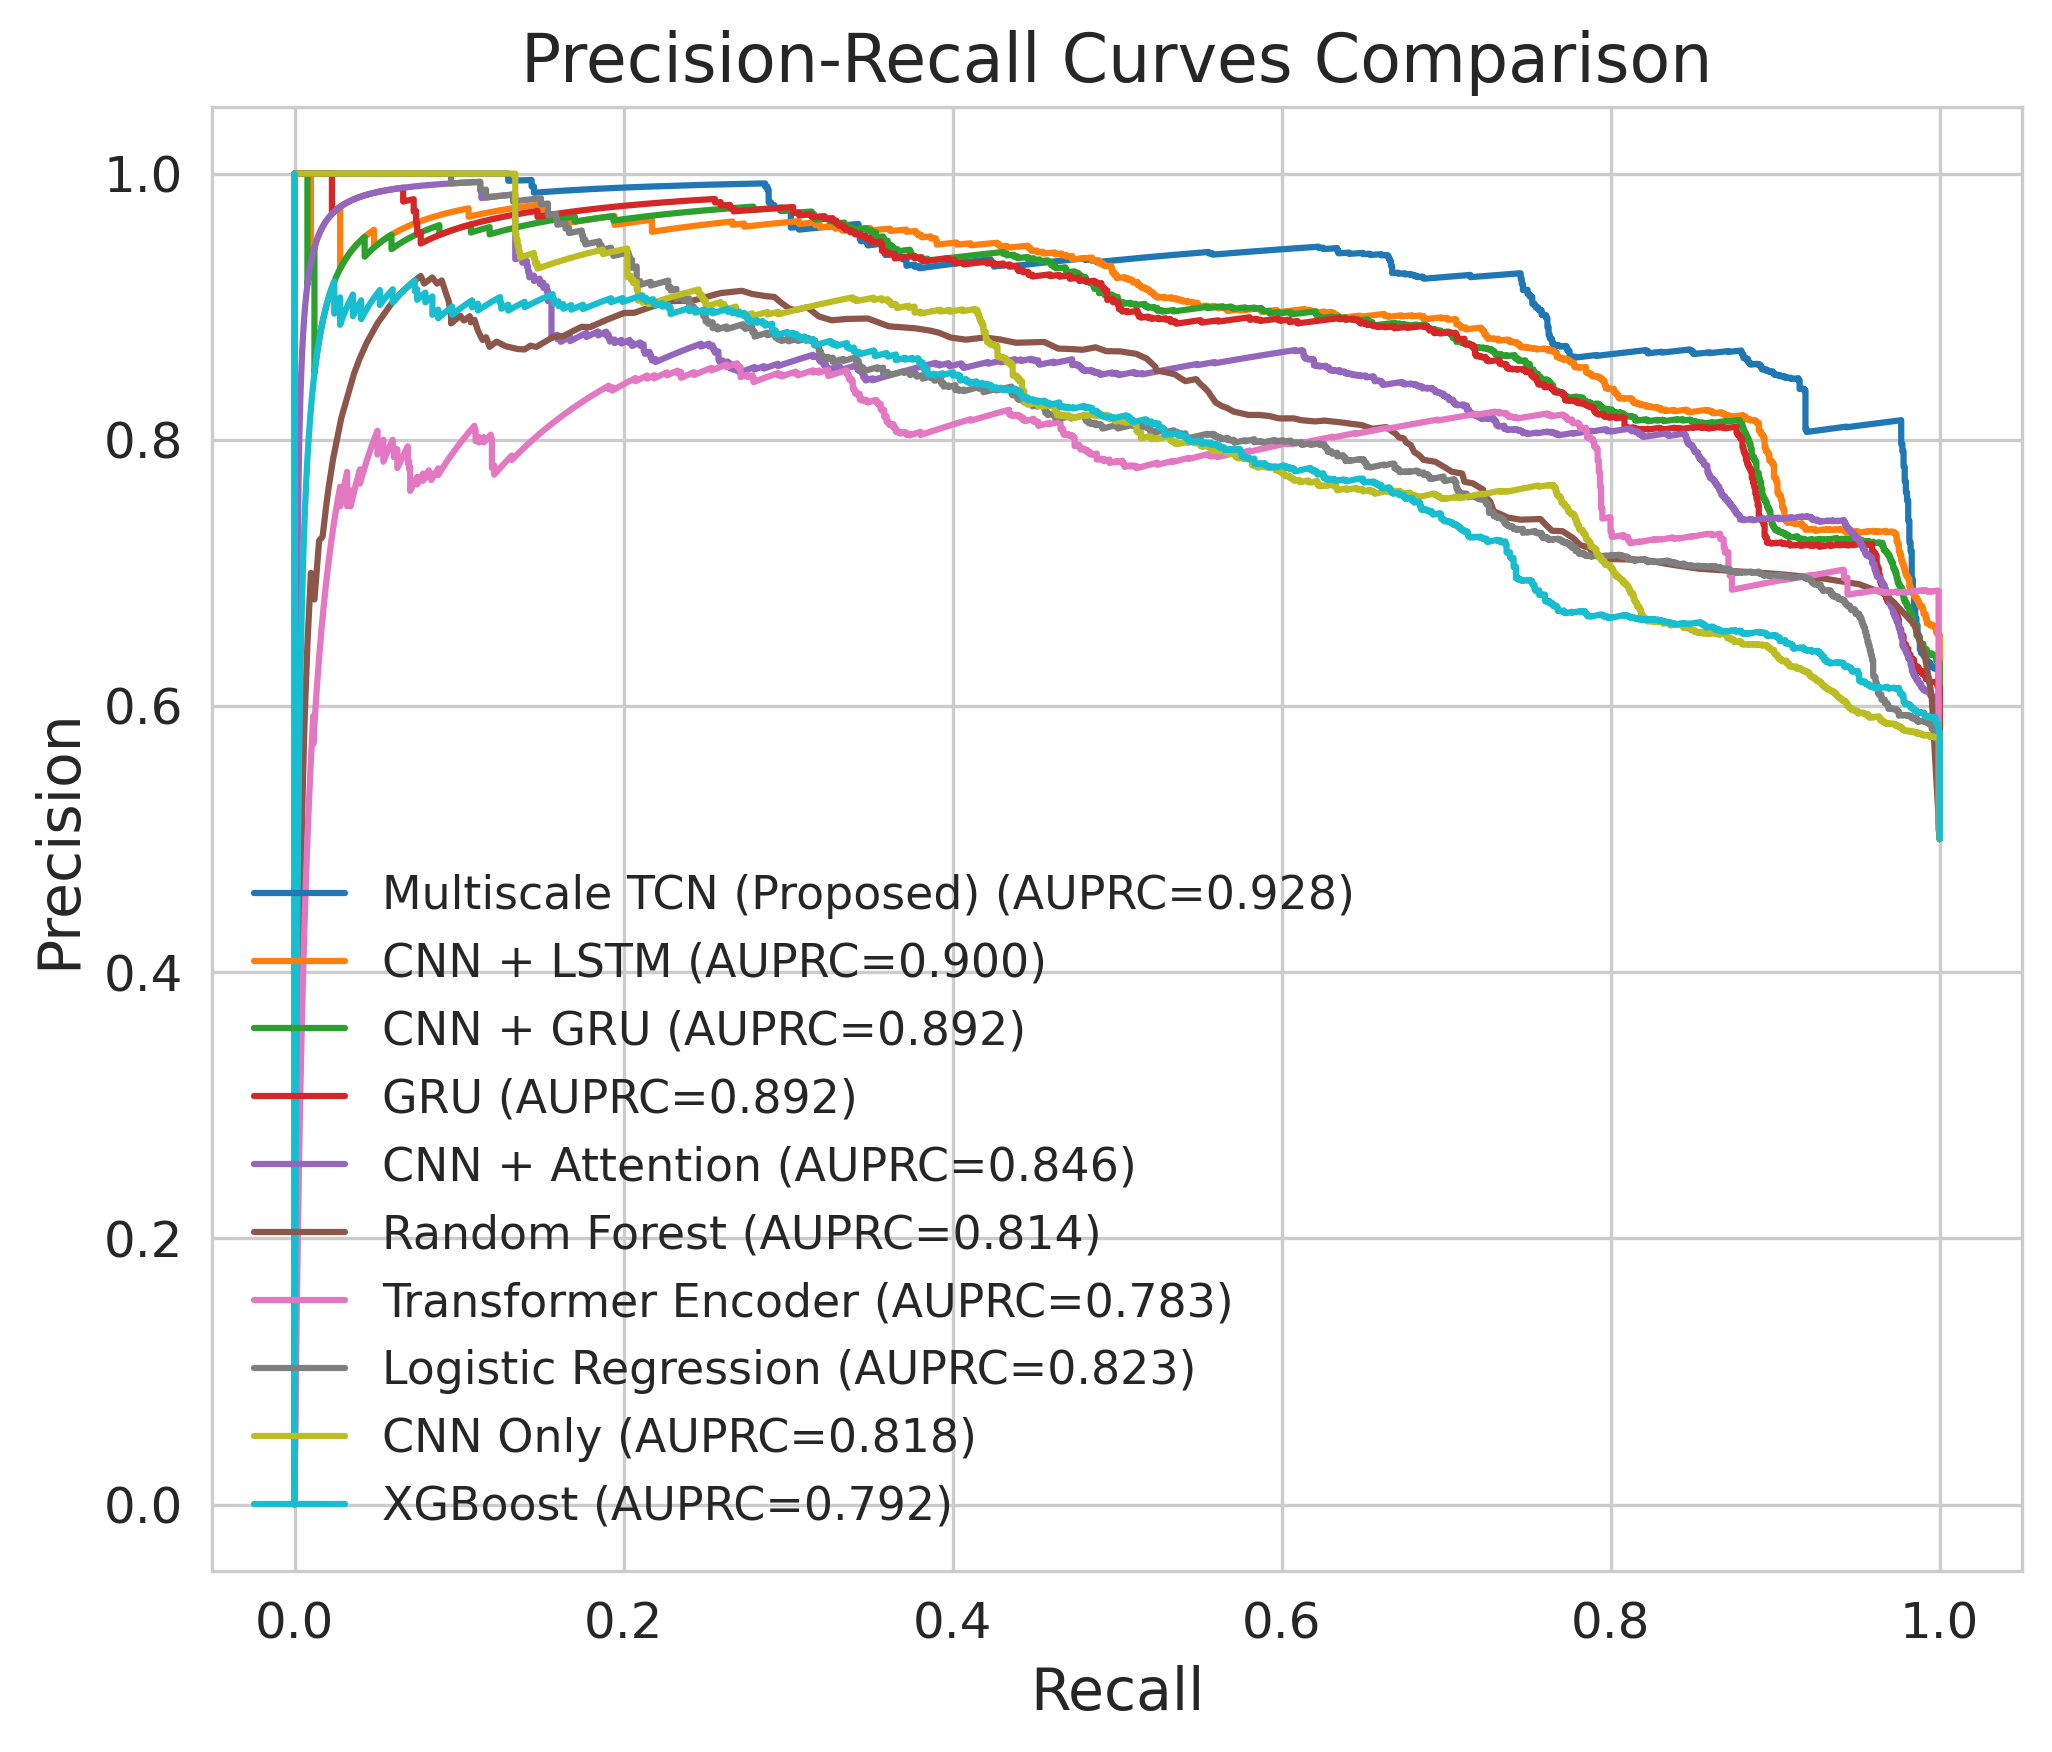

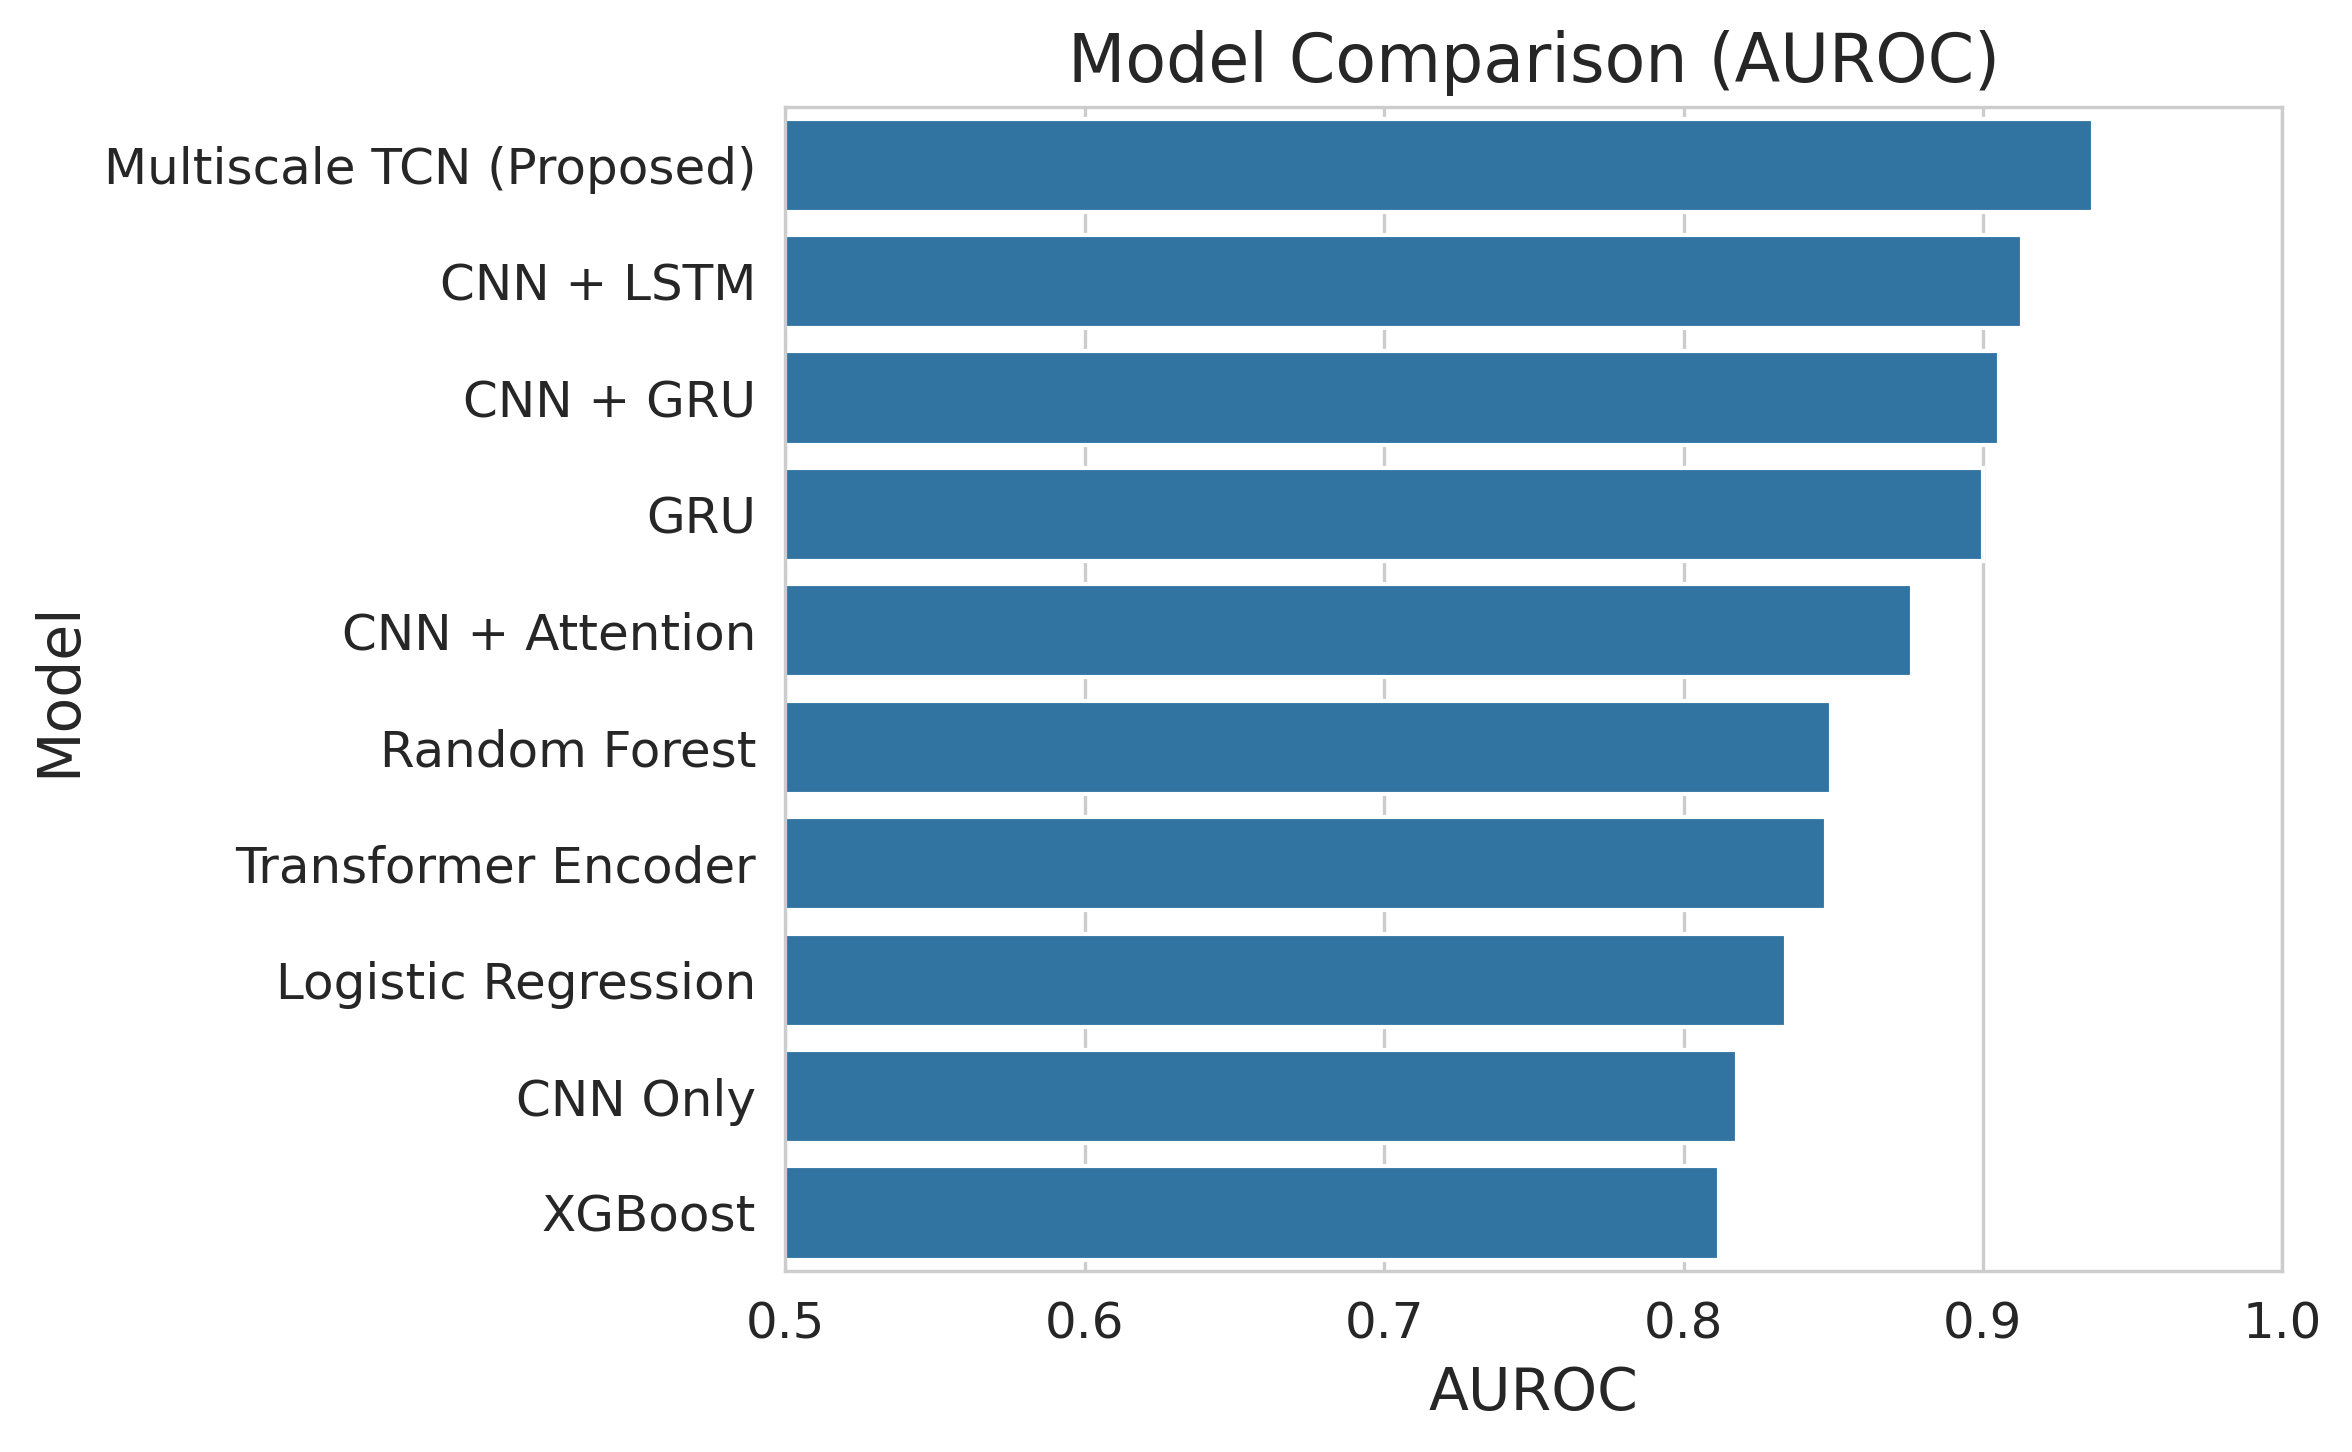

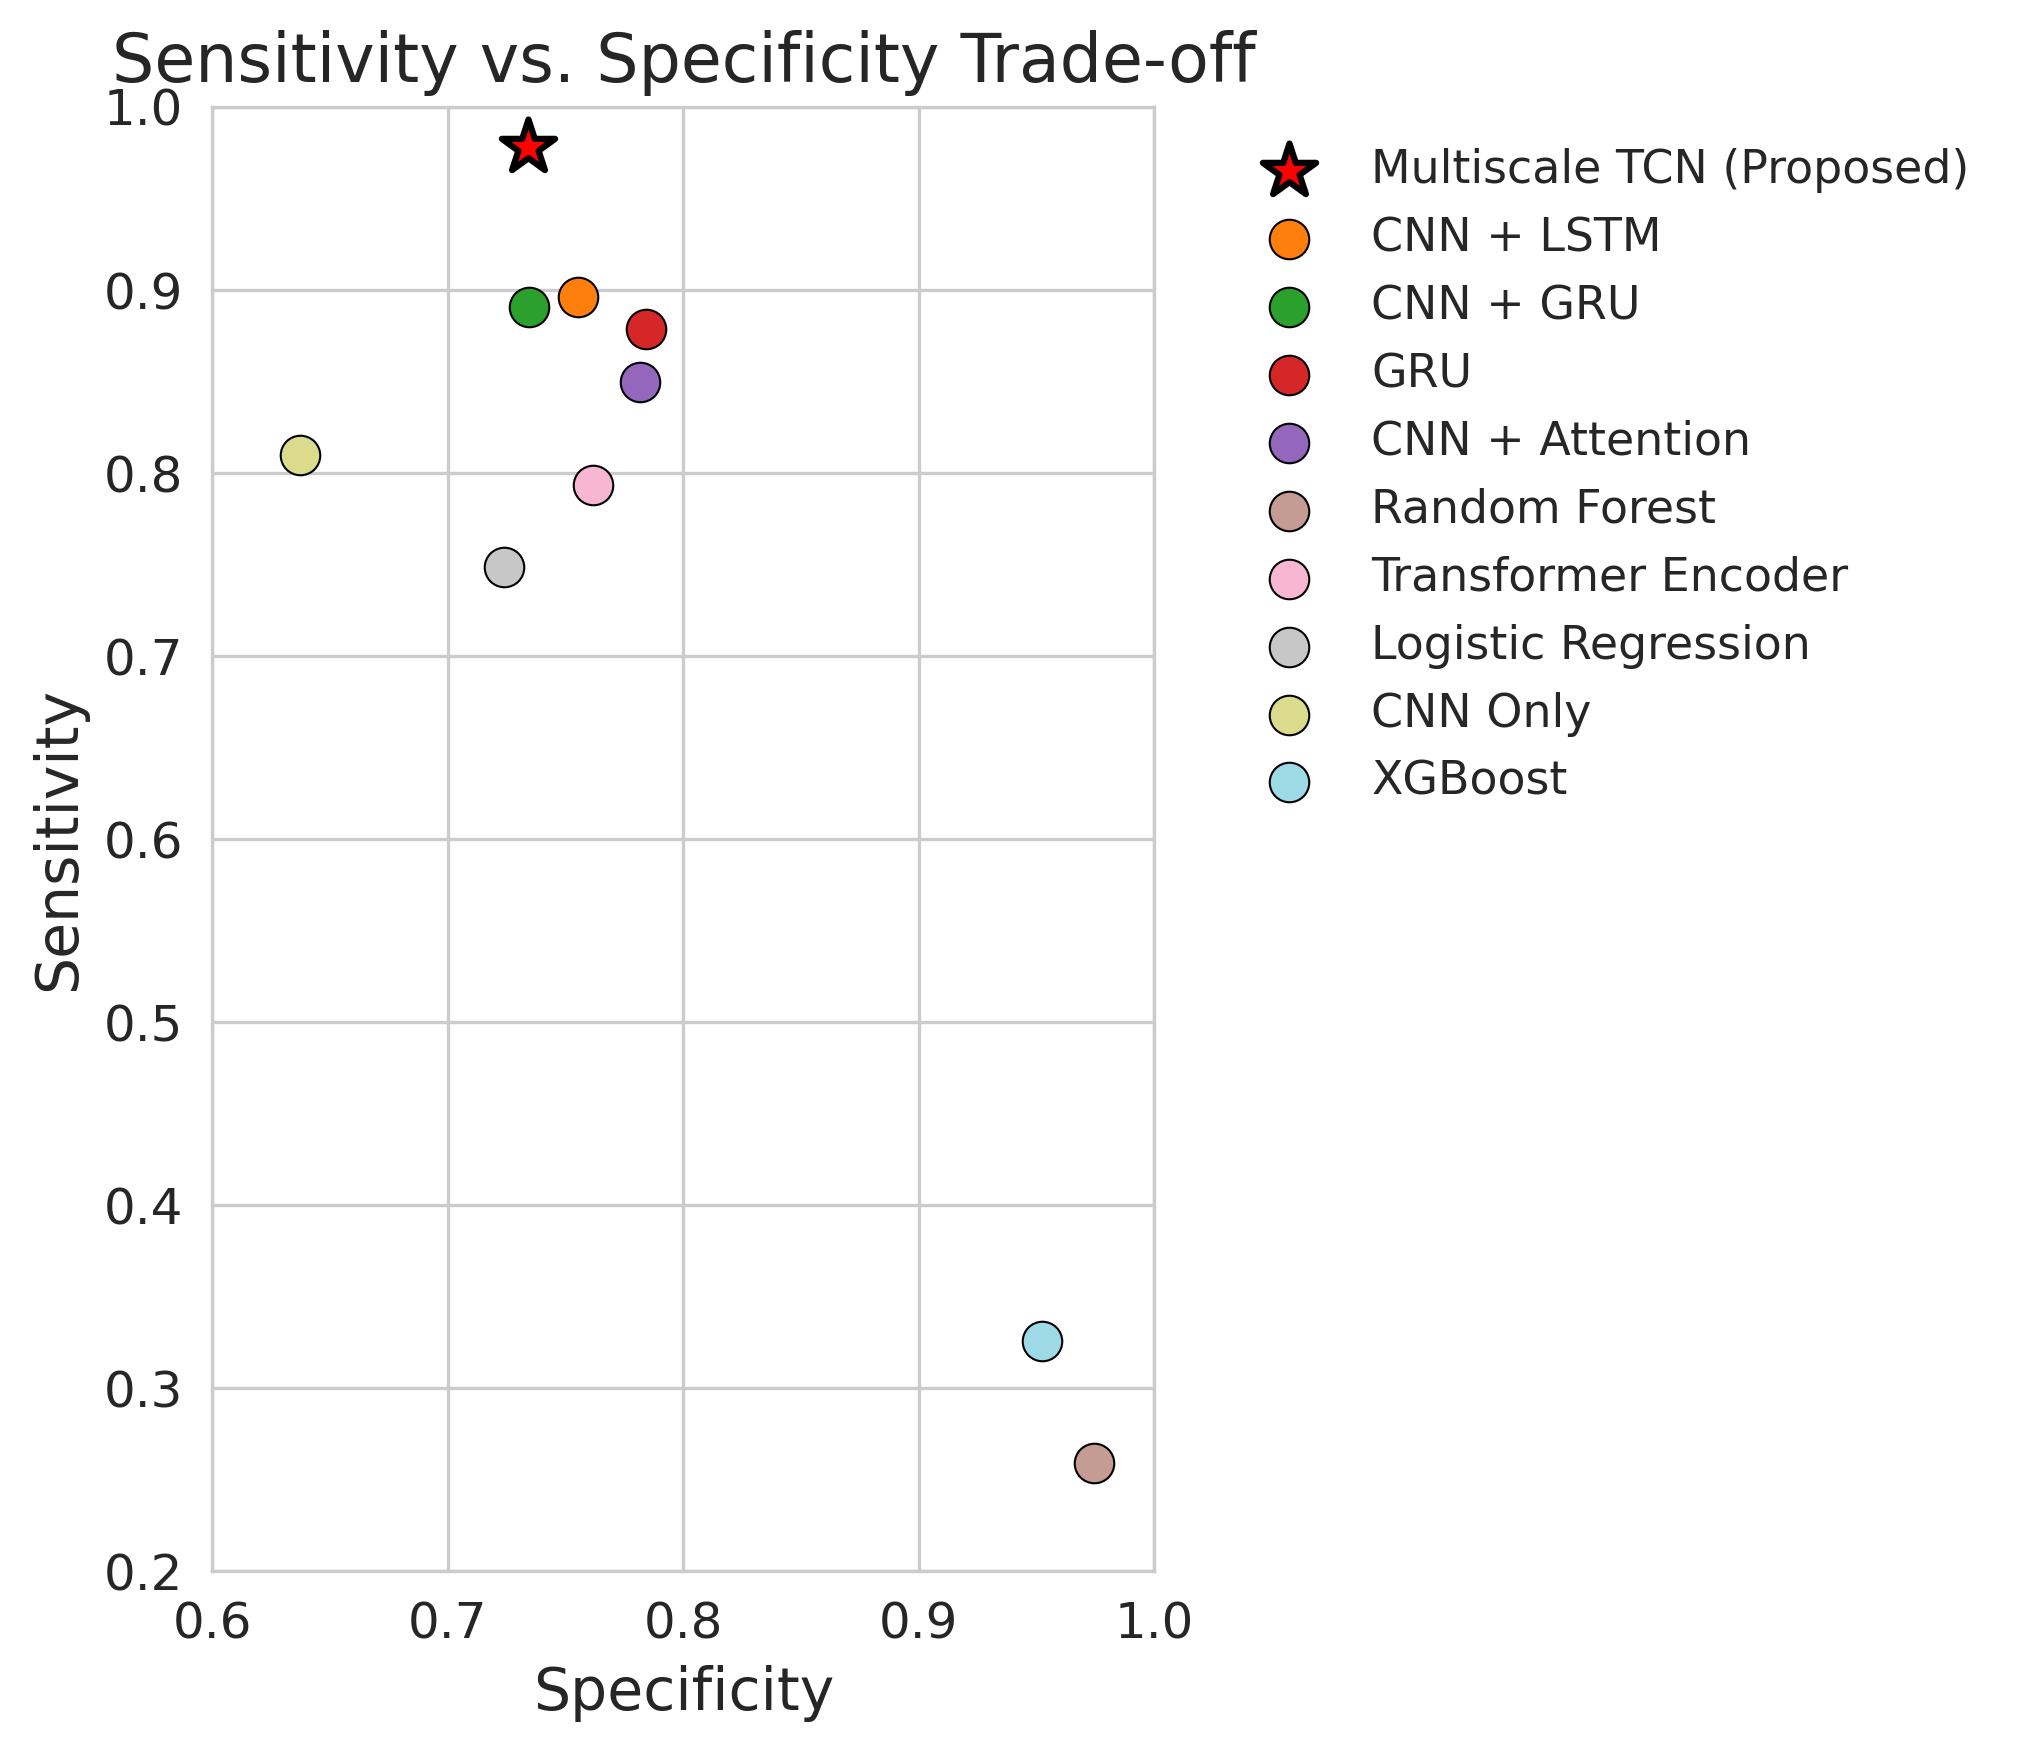

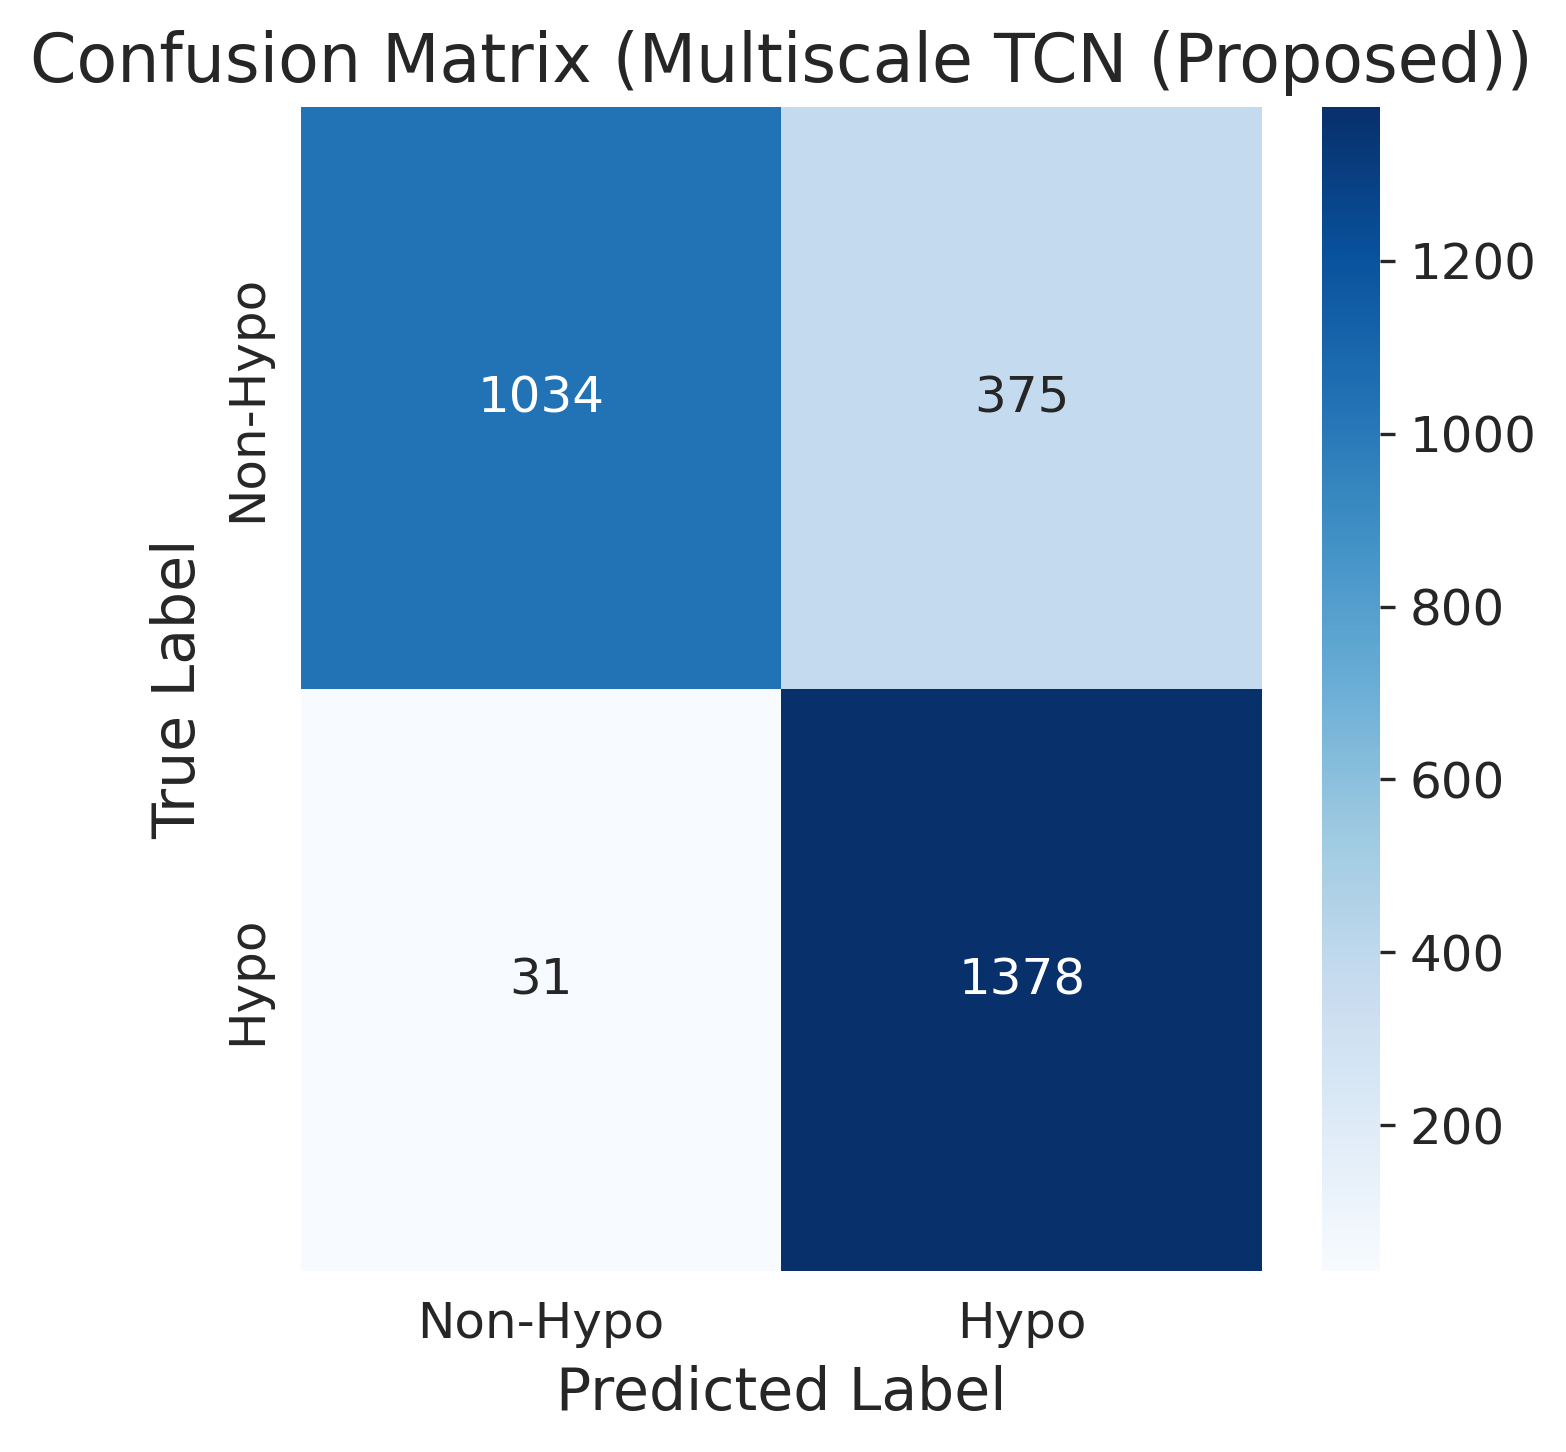

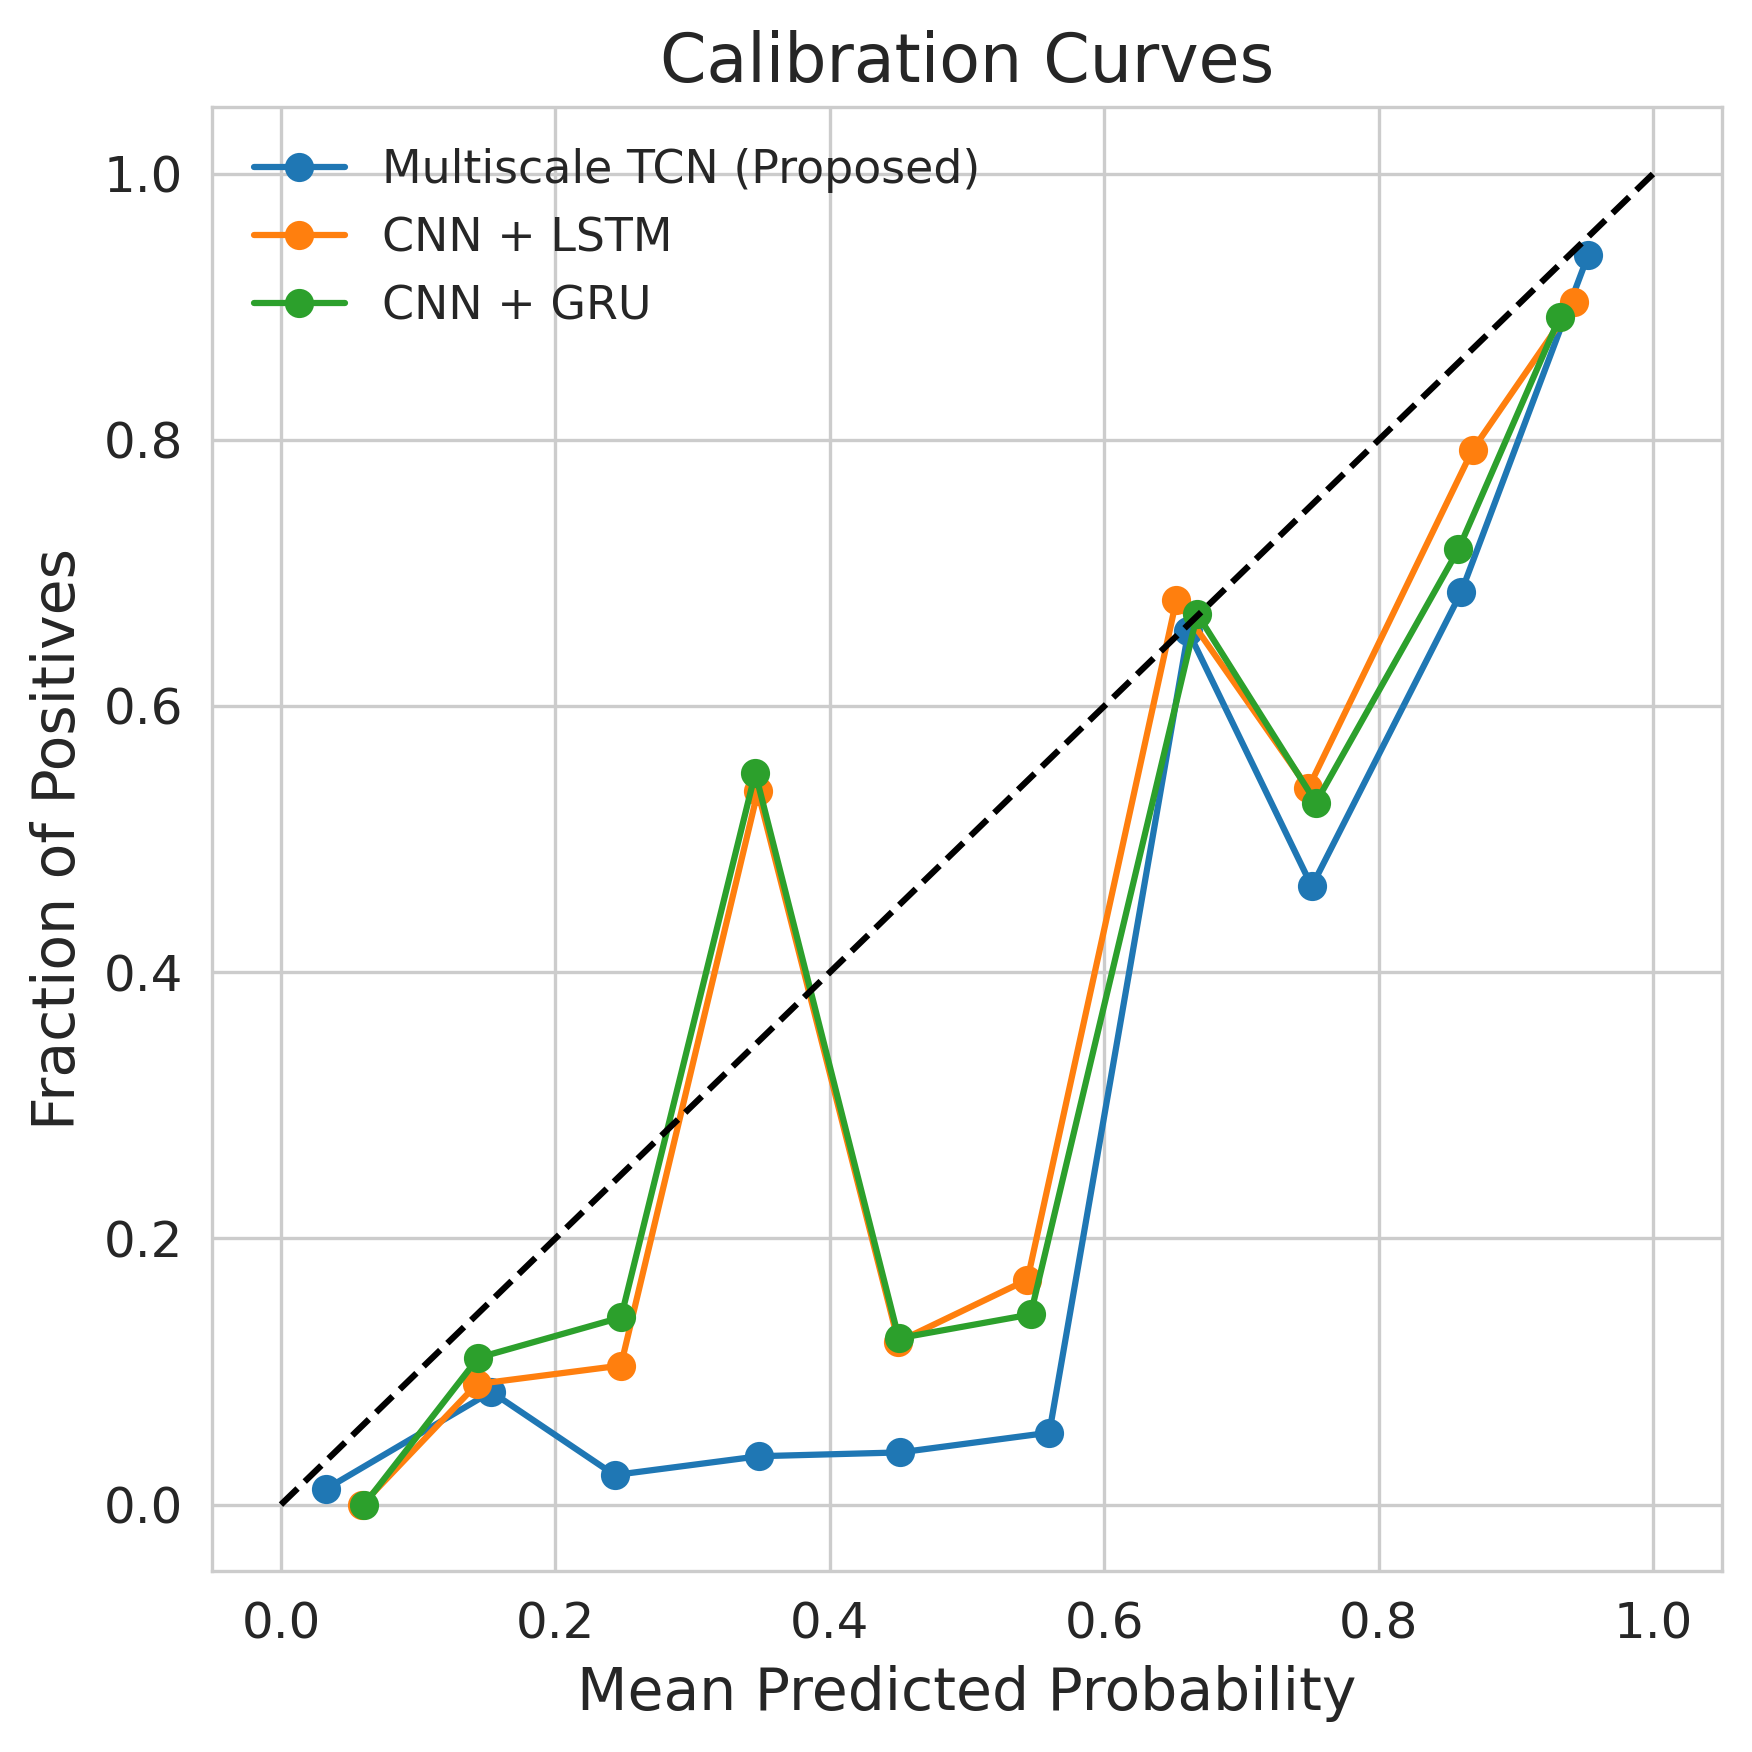

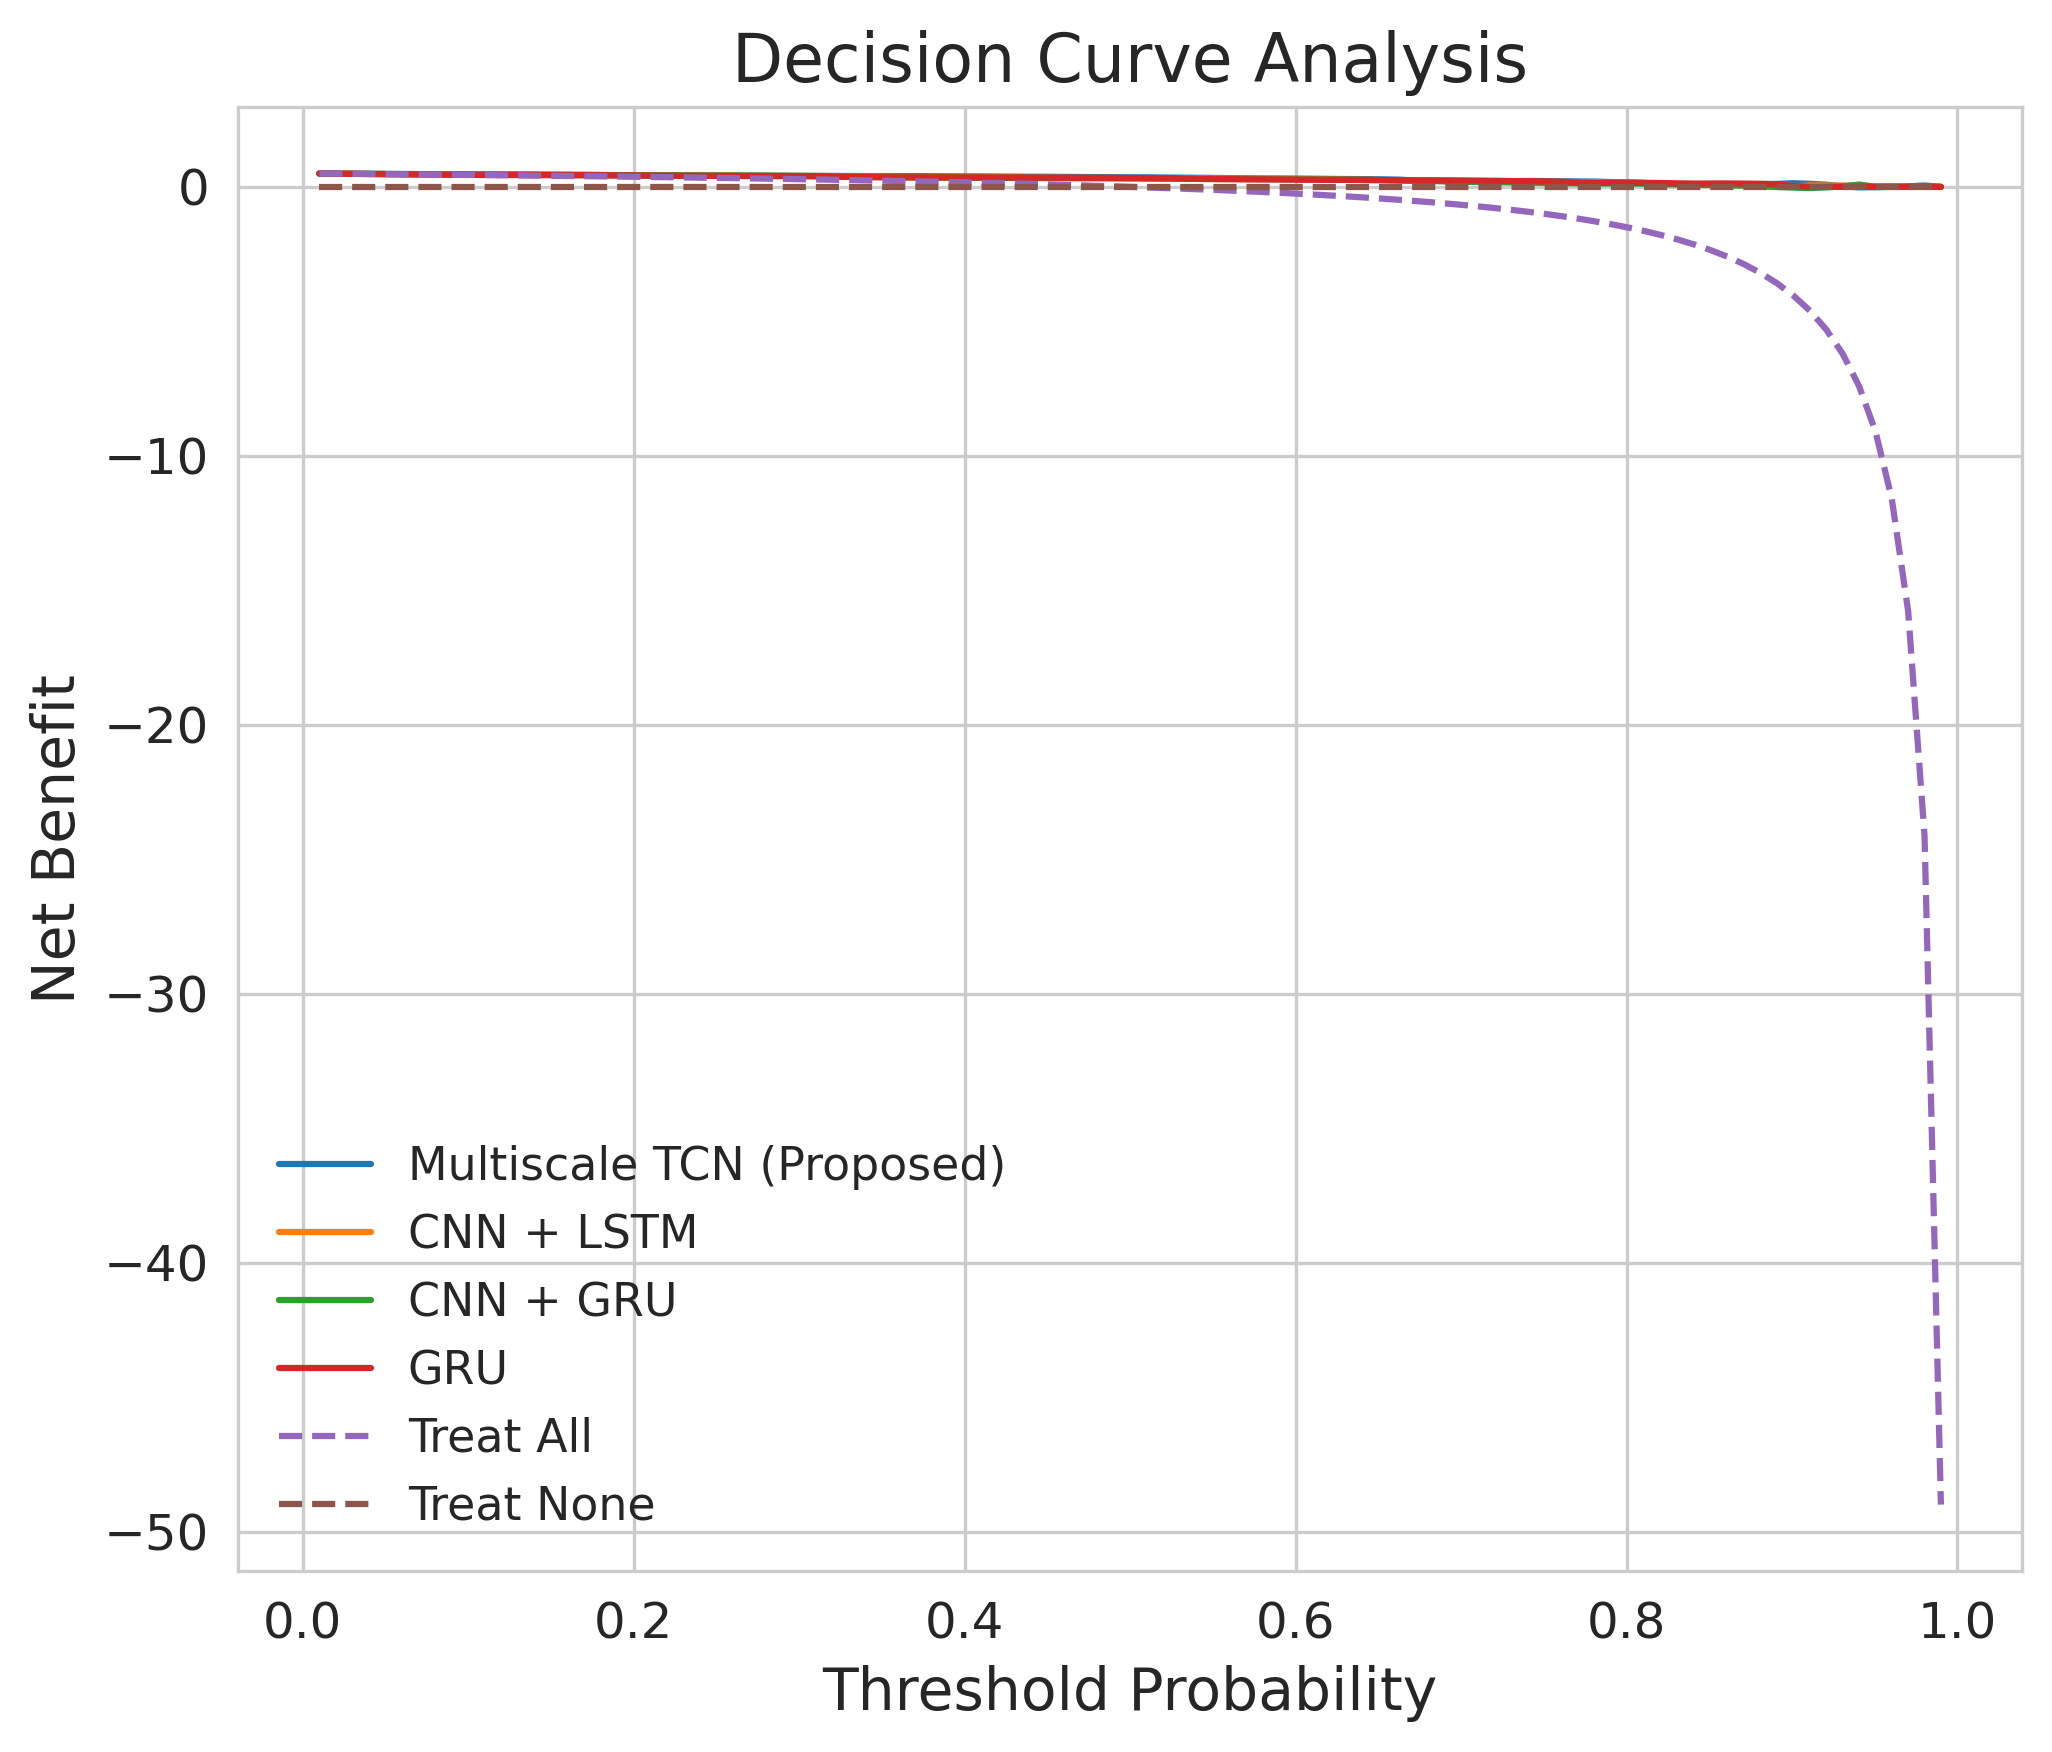

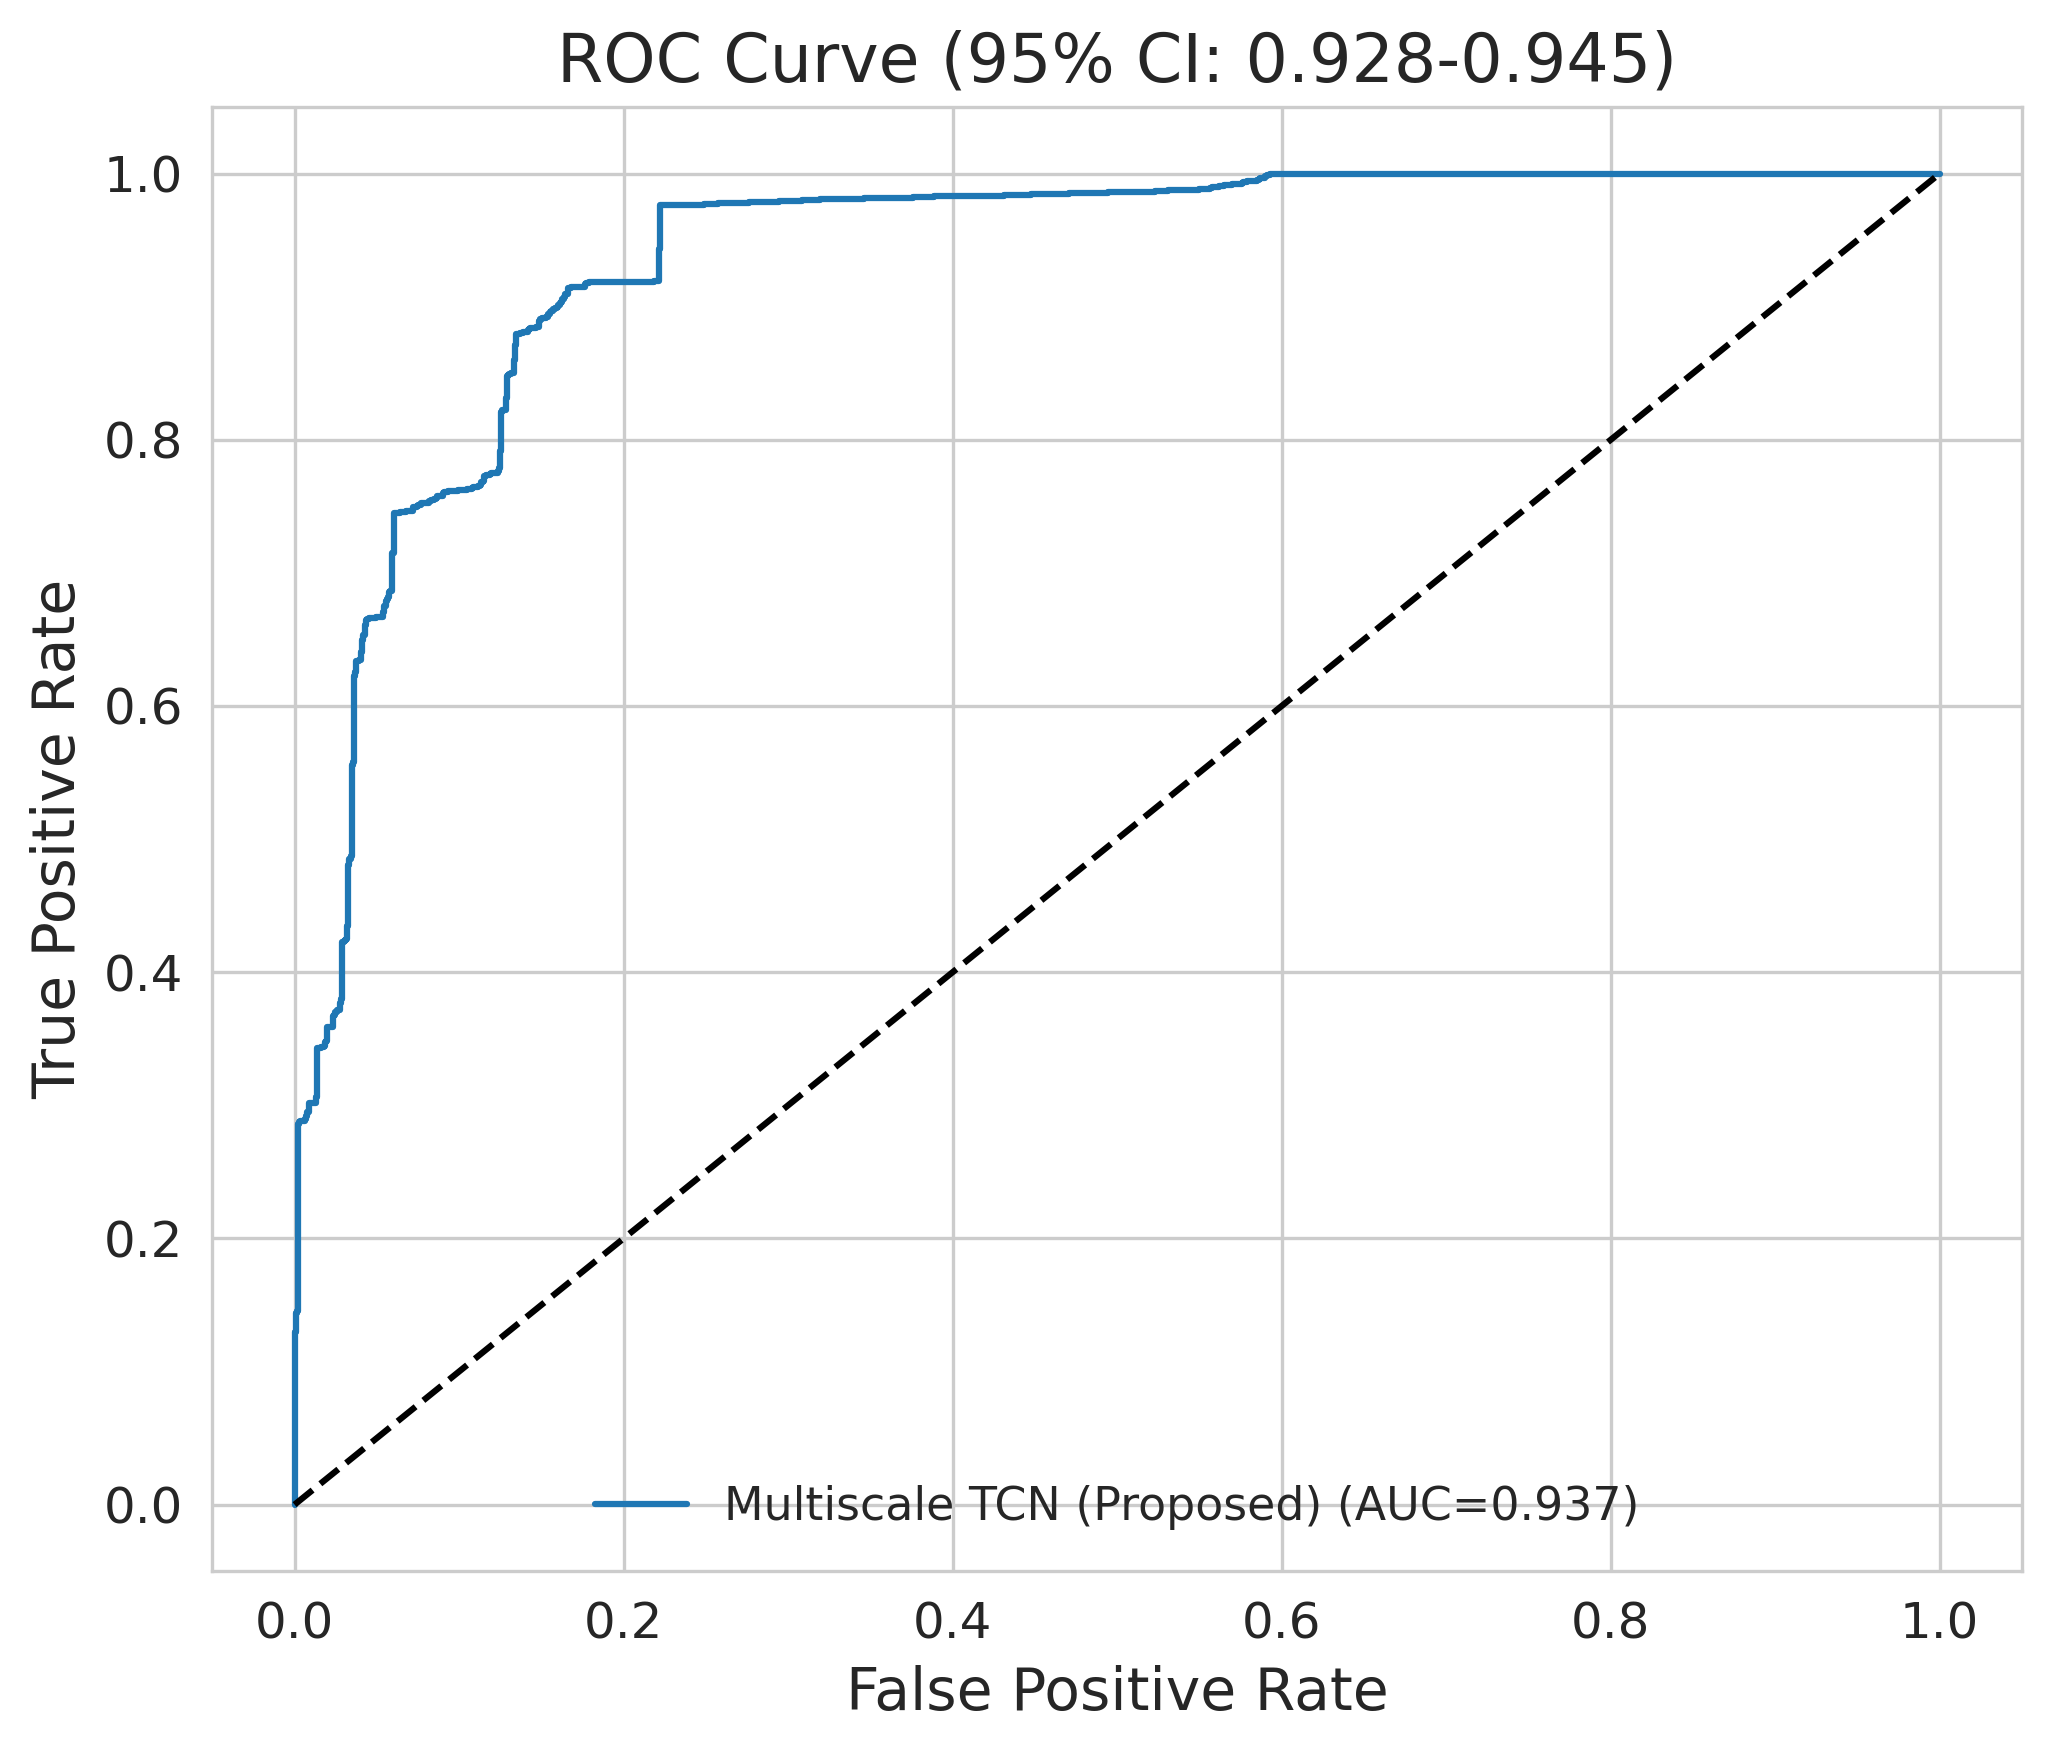

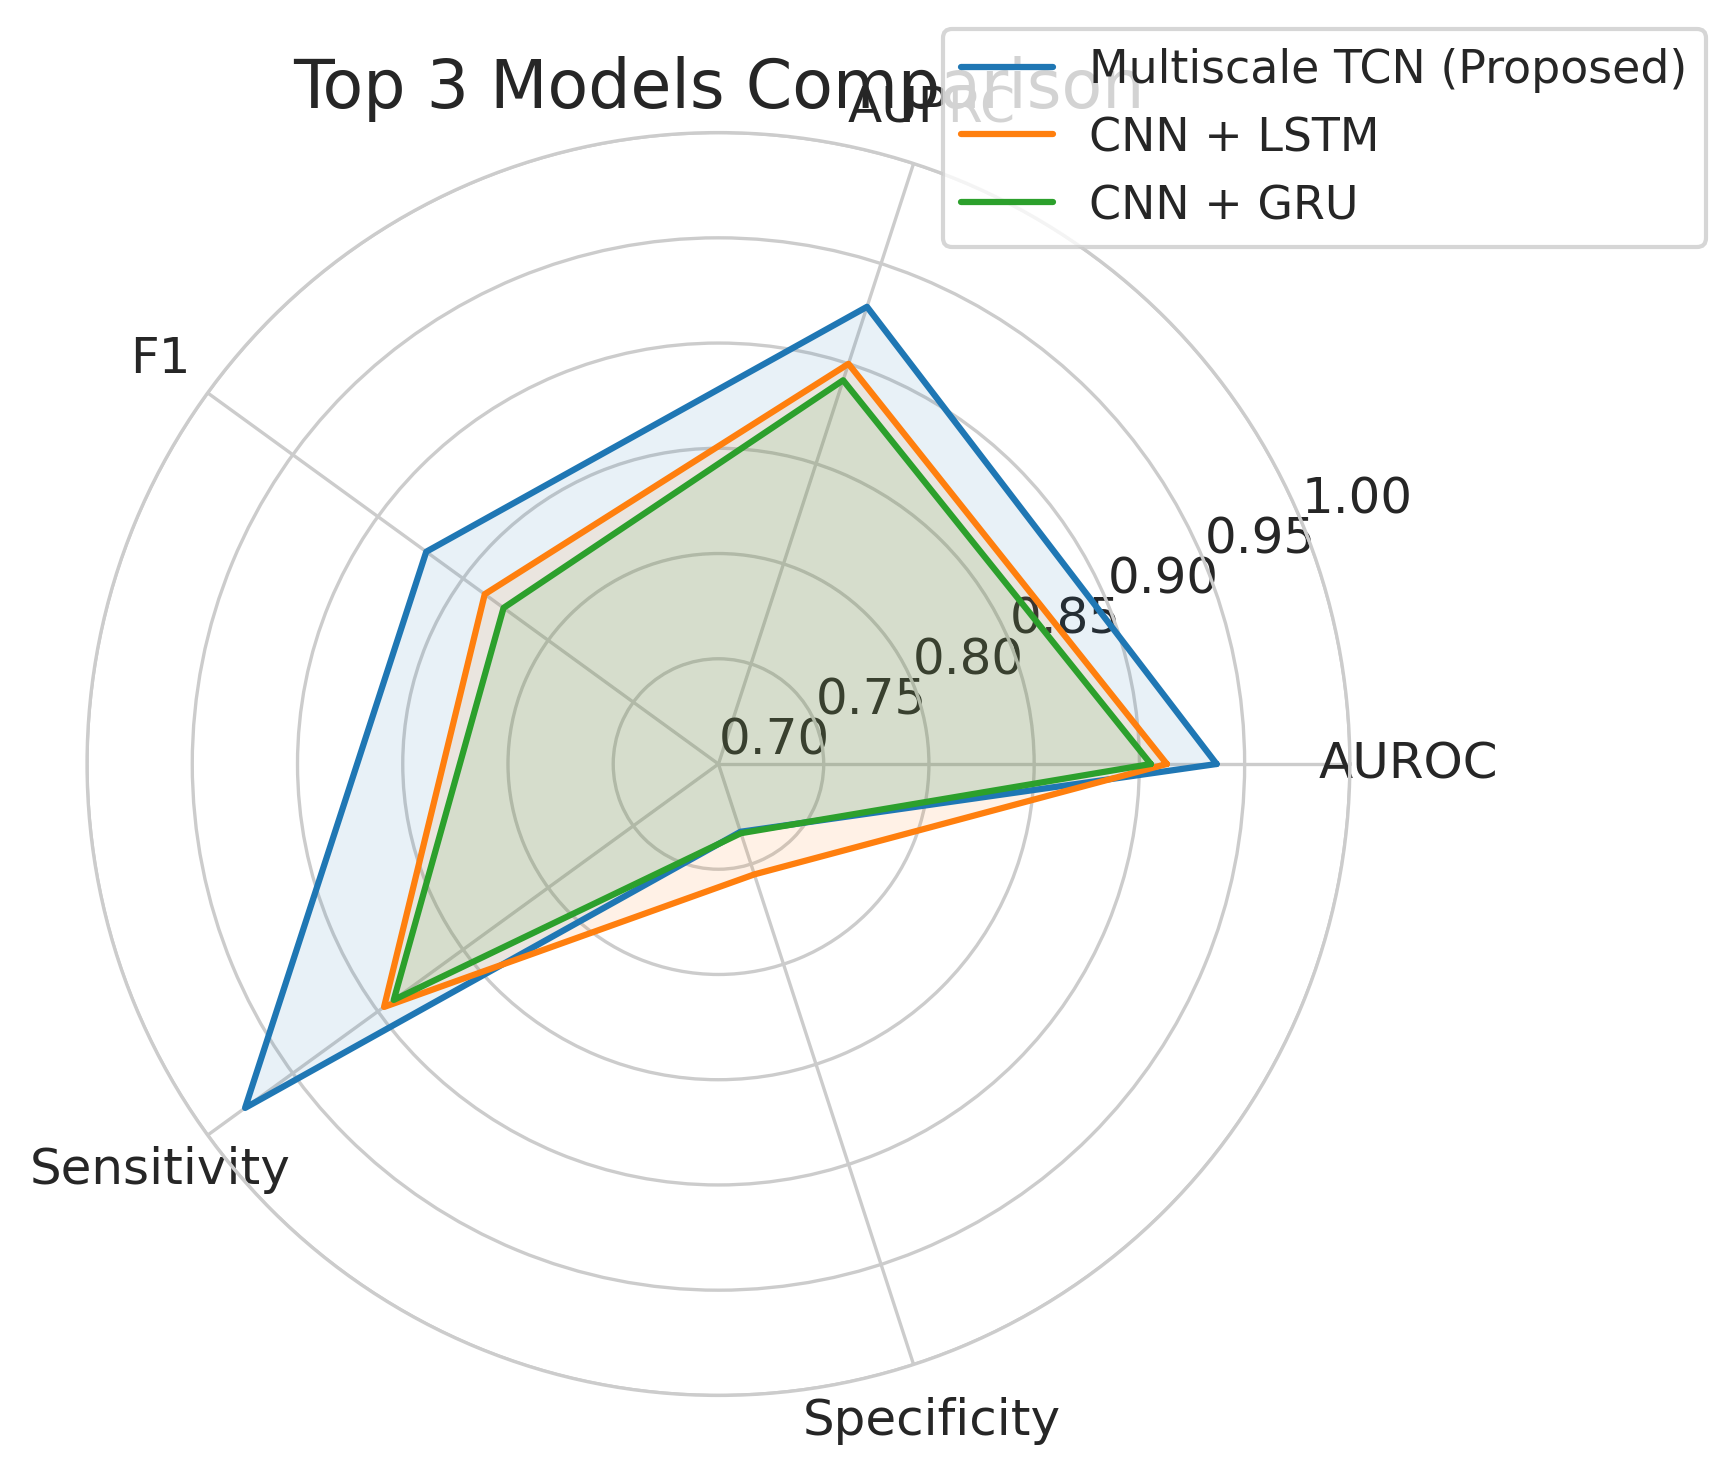

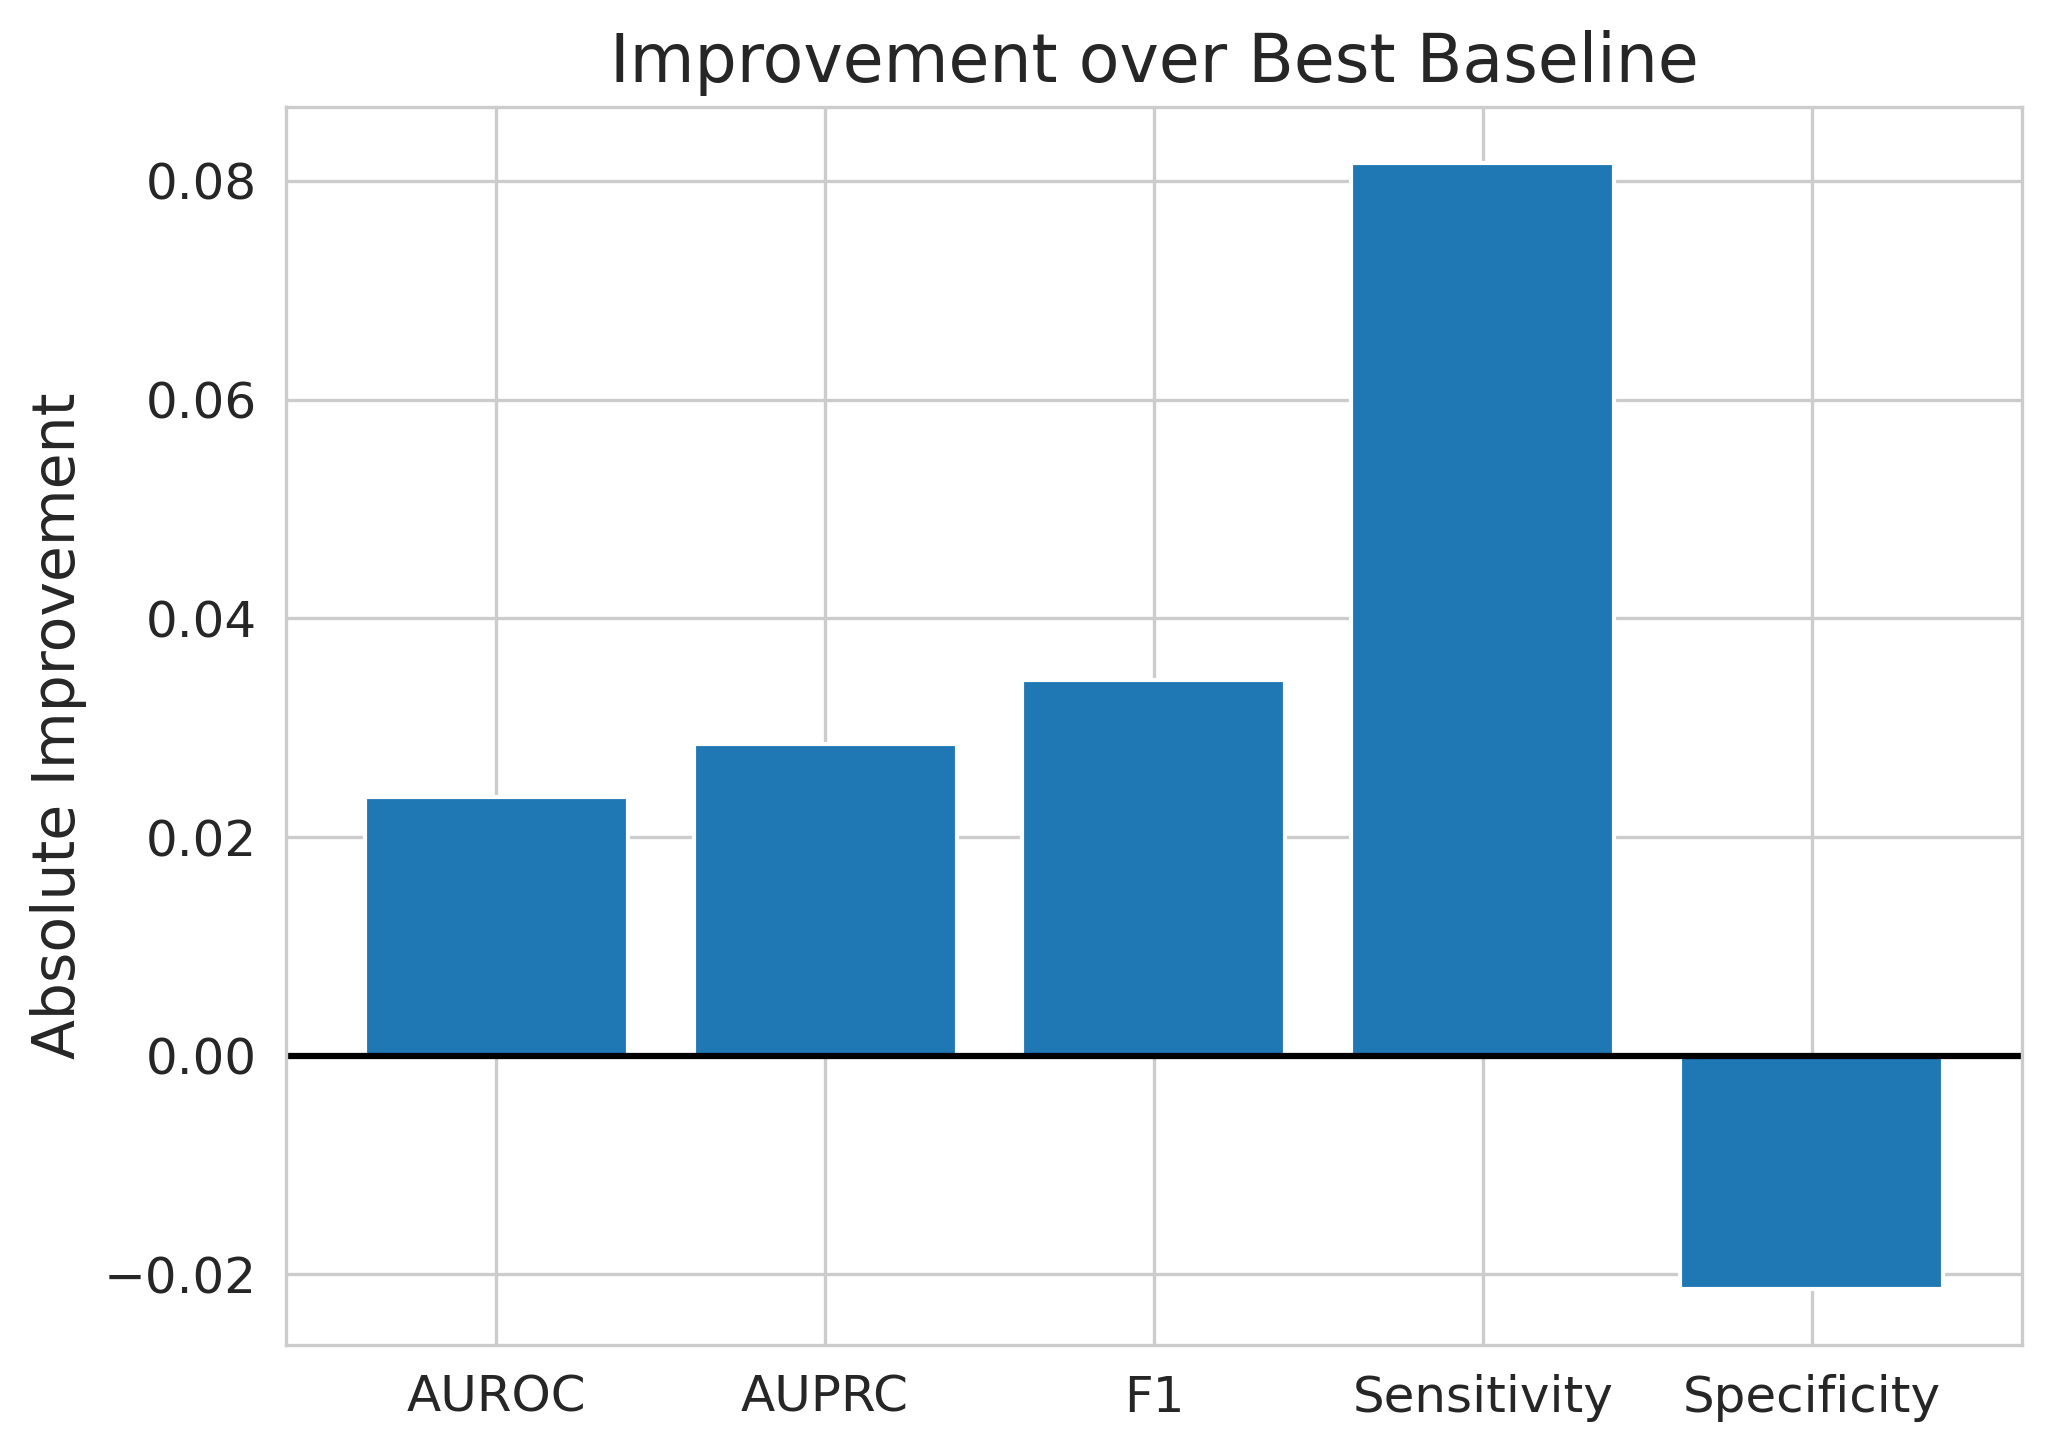

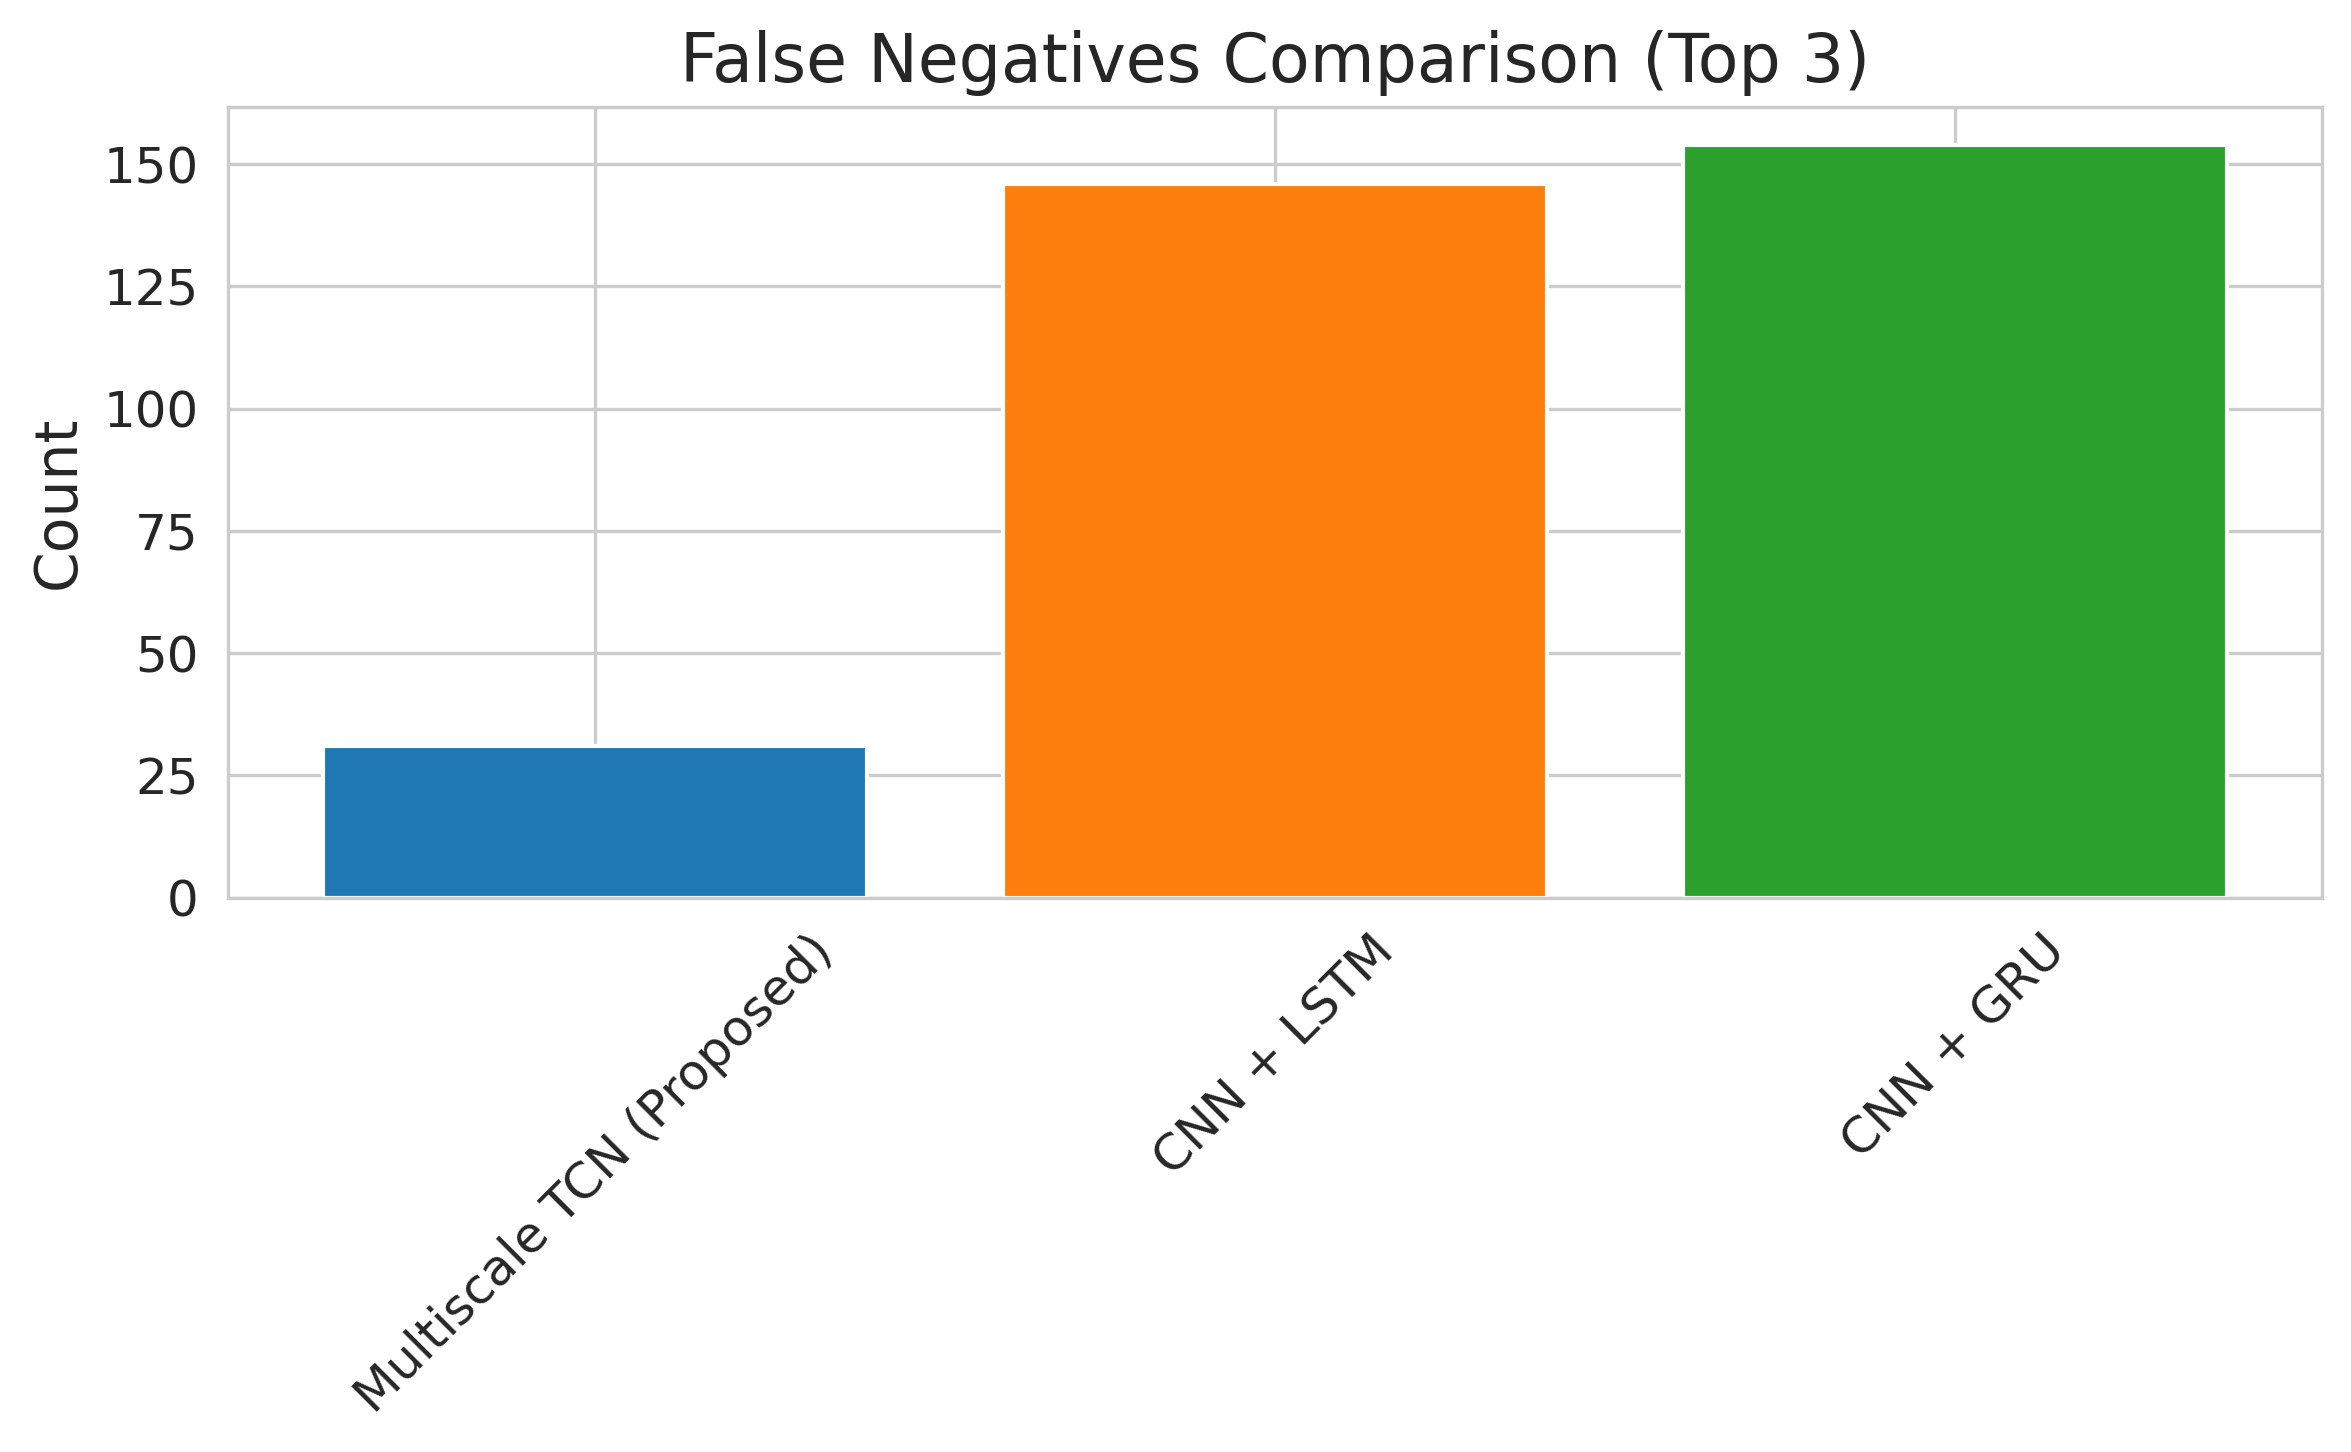

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve
import matplotlib as mpl
df_results2=df_results

# -------------------------
# High-End Plot Styling
# -------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.spines.top": False,
    "axes.spines.right": False
})

sns.set_style("whitegrid")

# Convert results to DataFrame
df_results = pd.DataFrame(results)
# ============================================================
# Publication-Ready Figures
# ============================================================

df_results = pd.DataFrame(results)
df_results = df_results[df_results["Model"] != "Vanilla LSTM"].reset_index(drop=True)
df_results = df_results.sort_values("AUROC", ascending=False)

# ------------------------------------------------------------
# 1️⃣ ROC Curves
# ------------------------------------------------------------

plt.figure(figsize=(7,6))

for _, row in df_results.iterrows():
    fpr, tpr, _ = roc_curve(y_test, row["y_prob"])
    plt.plot(fpr, tpr, label=f'{row["Model"]} (AUC={row["AUROC"]:.3f})')

plt.plot([0,1],[0,1],'k--',alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig("roc_curves.pdf")
plt.show()

# ------------------------------------------------------------
# 2️⃣ Precision-Recall Curves
# ------------------------------------------------------------

plt.figure(figsize=(7,6))

for _, row in df_results.iterrows():
    precision, recall, _ = precision_recall_curve(y_test, row["y_prob"])
    plt.plot(recall, precision, label=f'{row["Model"]} (AUPRC={row["AUPRC"]:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Comparison")
plt.legend(loc="lower left", frameon=False)
plt.tight_layout()
plt.savefig("pr_curves.pdf")
plt.show()

# ------------------------------------------------------------
# 3️⃣ AUROC Bar Plot (Ranked)
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_results,
    y="Model",
    x="AUROC"
)

plt.title("Model Comparison (AUROC)")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.savefig("auroc_barplot.pdf")
plt.show()

# ------------------------------------------------------------
# 4️⃣ Sensitivity vs Specificity (Publication Version)
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(7,6))

# Generate distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(df_results)))

for i, (_, row) in enumerate(df_results.iterrows()):

    # Highlight proposed model
    if "Proposed" in row["Model"]:
        plt.scatter(
            row["Specificity"],
            row["Sensitivity"],
            s=180,
            color="red",
            edgecolor="black",
            linewidth=1.5,
            marker="*",
            label=row["Model"],
            zorder=5
        )
    else:
        plt.scatter(
            row["Specificity"],
            row["Sensitivity"],
            s=90,
            color=colors[i],
            edgecolor="black",
            linewidth=0.5,
            label=row["Model"]
        )

plt.xlabel("Specificity")
plt.ylabel("Sensitivity")
plt.title("Sensitivity vs. Specificity Trade-off")

plt.xlim(0.6, 1.0)
plt.ylim(0.2, 1.0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.savefig("sens_spec_scatter_publication.pdf", bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 5️⃣ Confusion Matrix of Best Model
# ------------------------------------------------------------

best_model = df_results.iloc[0]
y_pred_best = (best_model["y_prob"] > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Hypo","Hypo"],
            yticklabels=["Non-Hypo","Hypo"])
plt.title(f'Confusion Matrix ({best_model["Model"]})')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_best.pdf")
plt.show()

# ------------------------------------------------------------
# 6️⃣ Calibration Curve (Very Strong for Clinical Papers)
# ------------------------------------------------------------

plt.figure(figsize=(6,6))

for _, row in df_results.head(3).iterrows():  # Top 3 models
    prob_true, prob_pred = calibration_curve(
        y_test, row["y_prob"], n_bins=10
    )
    plt.plot(prob_pred, prob_true, marker='o', label=row["Model"])

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("calibration_curve.pdf")
plt.show()


# ============================================================
# Decision Curve Analysis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def decision_curve(y_true, y_prob, thresholds):
    N = len(y_true)
    net_benefits = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        nb = (tp/N) - (fp/N) * (t/(1-t))
        net_benefits.append(nb)

    return np.array(net_benefits)

thresholds = np.linspace(0.01, 0.99, 100)

plt.figure(figsize=(7,6))

for _, row in df_results.head(4).iterrows():  # top 4 models
    nb = decision_curve(y_test, row["y_prob"], thresholds)
    plt.plot(thresholds, nb, label=row["Model"])

# Treat All and Treat None
prevalence = np.mean(y_test)
treat_all = prevalence - (1-prevalence)*(thresholds/(1-thresholds))
plt.plot(thresholds, treat_all, linestyle="--", label="Treat All")
plt.plot(thresholds, np.zeros_like(thresholds), linestyle="--", label="Treat None")

plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# ============================================================
# ROC with 95% CI (Bootstrap)
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

best_model = df_results.iloc[0]
y_prob = best_model["y_prob"]

bootstrapped_scores = []
rng = np.random.RandomState(42)

for i in range(1000):
    indices = rng.randint(0, len(y_test), len(y_test))
    if len(np.unique(y_test[indices])) < 2:
        continue
    score = roc_auc_score(y_test[indices], y_prob[indices])
    bootstrapped_scores.append(score)

sorted_scores = np.sort(bootstrapped_scores)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"{best_model['Model']} (AUC={best_model['AUROC']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.fill_between([0,1],[0,0],[1,1],alpha=0)  # placeholder
plt.title(f"ROC Curve (95% CI: {ci_lower:.3f}-{ci_upper:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



# ============================================================
# Radar Plot Comparison
# ============================================================

import numpy as np

top3 = df_results.head(3)

metrics = ["AUROC","AUPRC","F1","Sensitivity","Specificity"]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for _, row in top3.iterrows():
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, label=row["Model"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0.7,1.0)
plt.title("Top 3 Models Comparison")
plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
plt.tight_layout()
plt.show()

# ============================================================
# Performance Improvement over Best Baseline
# ============================================================

proposed = df_results[df_results["Model"].str.contains("Proposed")].iloc[0]
baseline = df_results.iloc[1]  # second best

metrics = ["AUROC","AUPRC","F1","Sensitivity","Specificity"]
improvements = [proposed[m] - baseline[m] for m in metrics]

plt.figure(figsize=(7,5))
plt.bar(metrics, improvements)
plt.axhline(0, color='black')
plt.title("Improvement over Best Baseline")
plt.ylabel("Absolute Improvement")
plt.tight_layout()
plt.show()


# ============================================================
# Confusion Matrix Counts (Top 3)
# ============================================================

from sklearn.metrics import confusion_matrix

top3 = df_results.head(3)

plt.figure(figsize=(8,5))

for _, row in top3.iterrows():
    y_pred = (row["y_prob"] > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    plt.bar(row["Model"], fn, label="FN" if row["Model"]==top3.iloc[0]["Model"] else "")

plt.title("False Negatives Comparison (Top 3)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


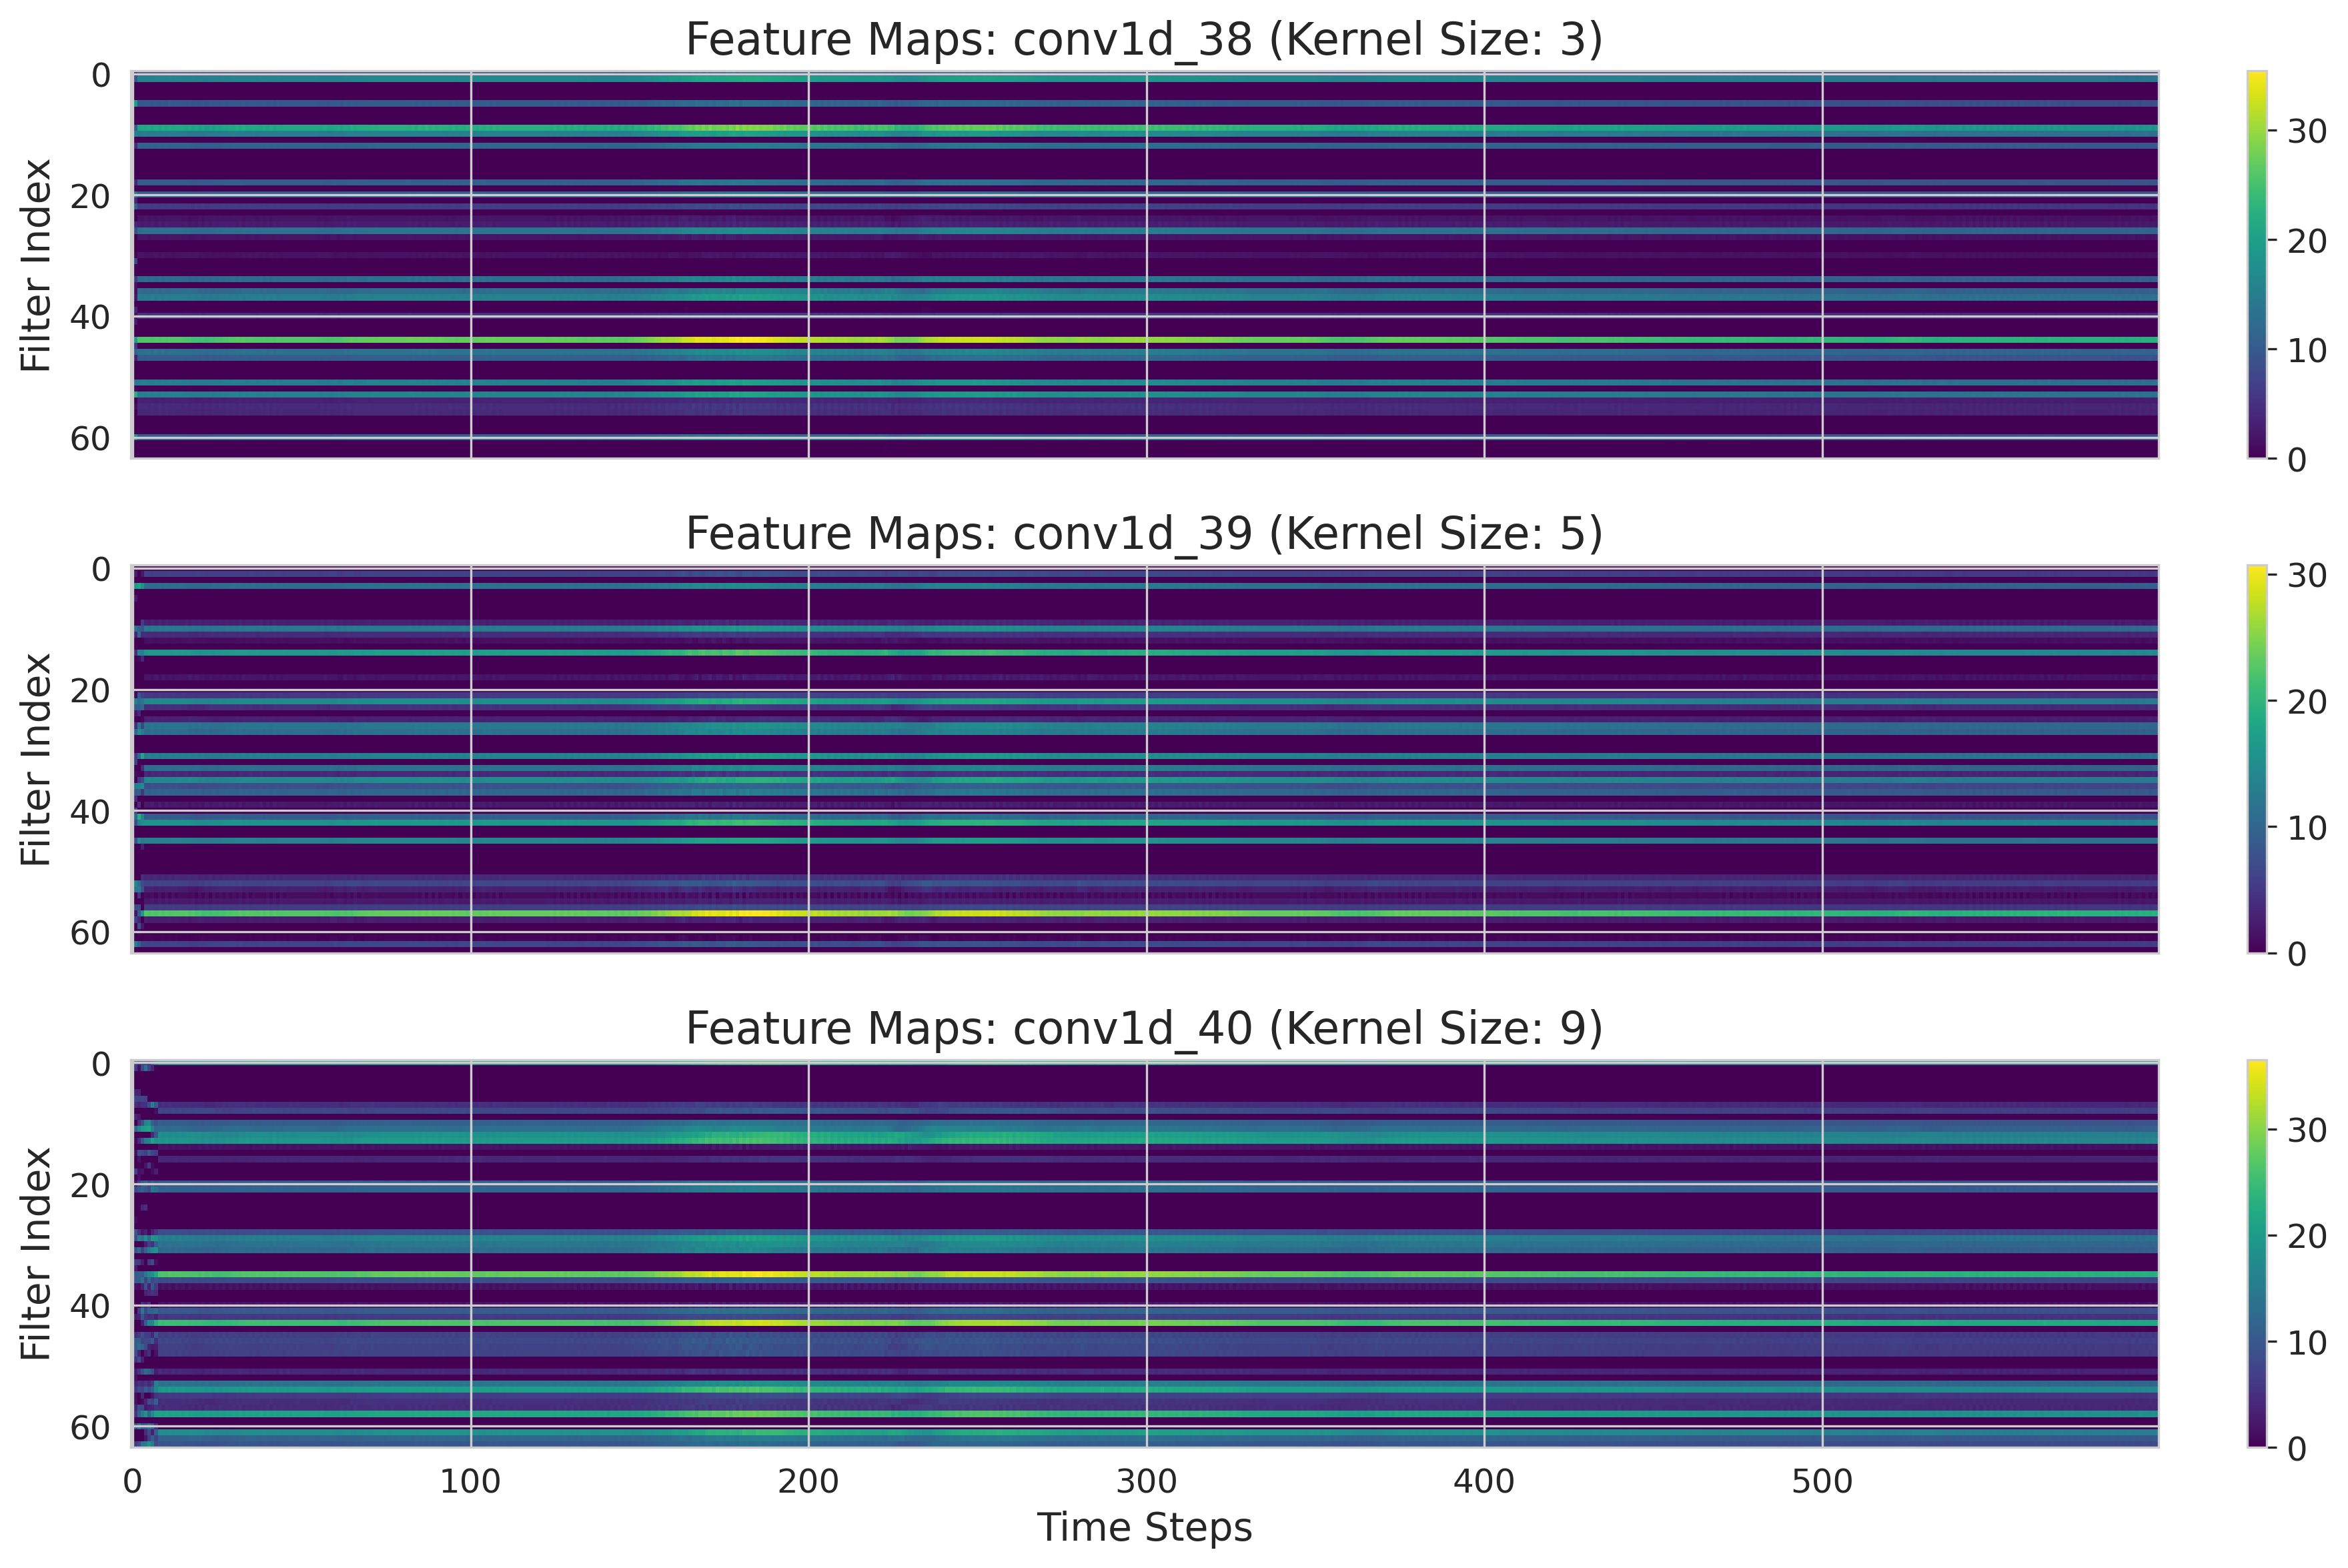

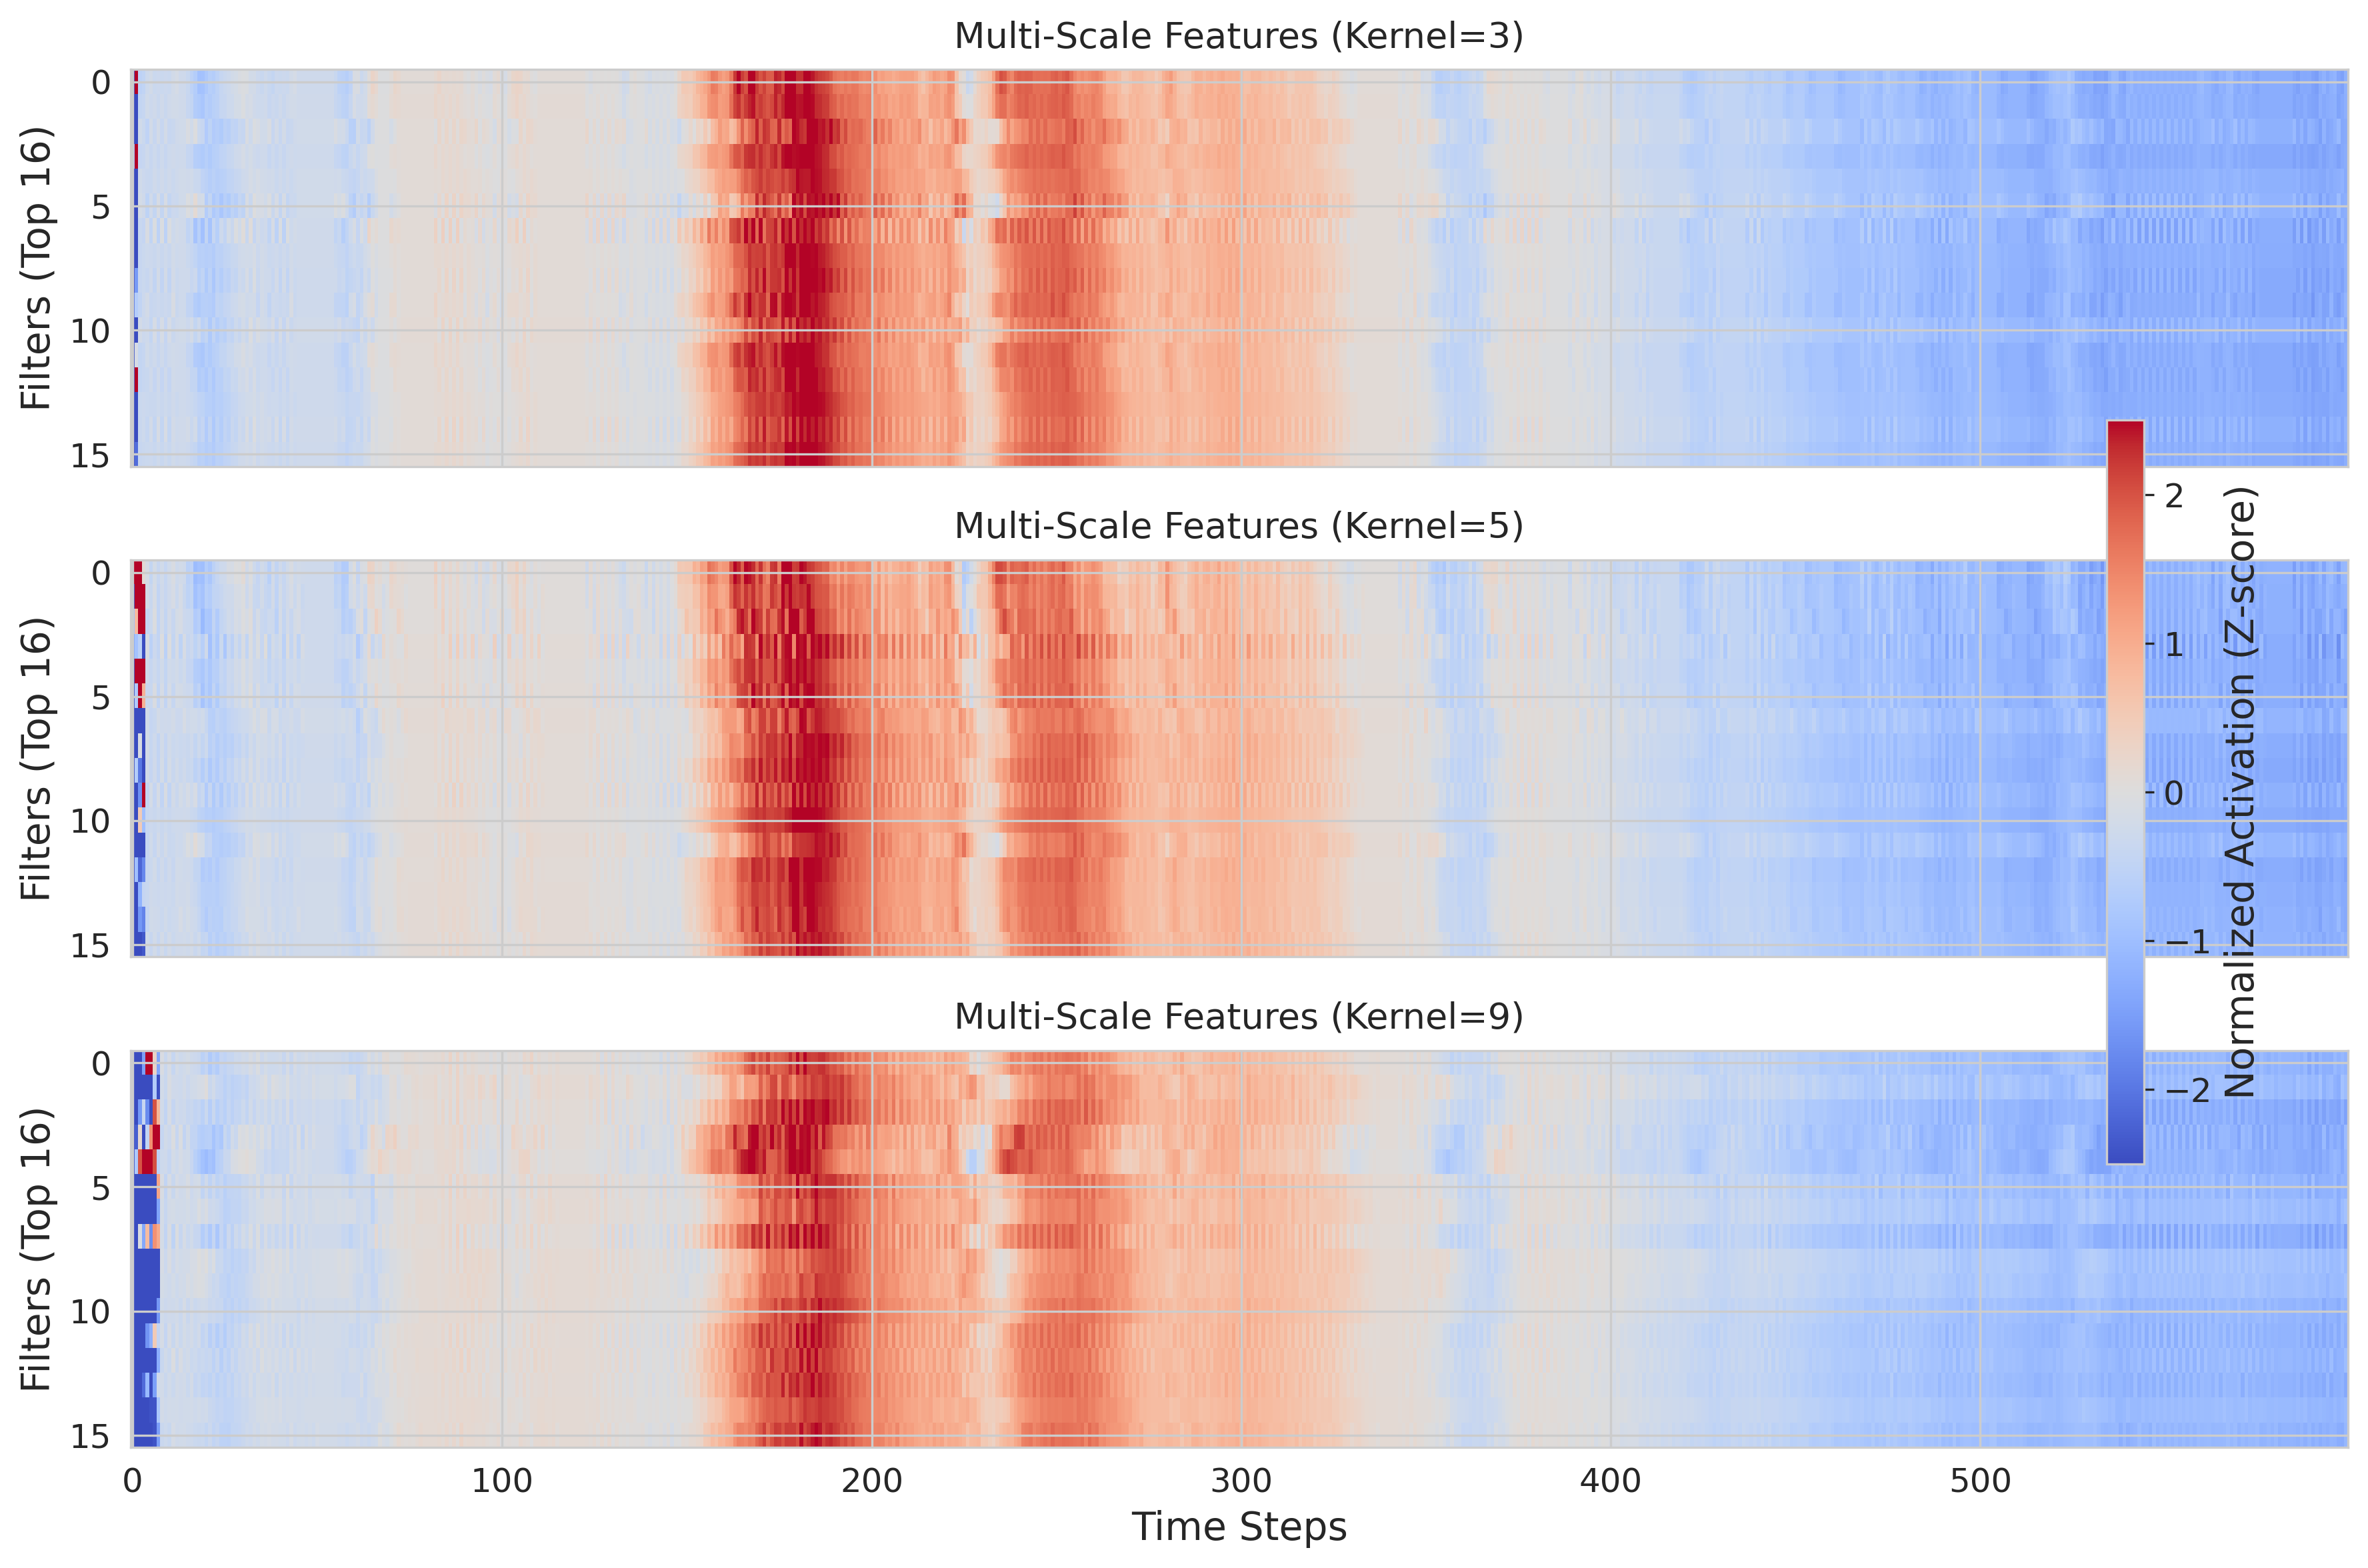

In [ ]:
def plot_multiscale_features(model, x_sample):
    """
    Visualizes the parallel convolution outputs (3x3, 5x5, 9x9).
    """
    # Identify the parallel conv layers
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv1D)][:3]

    fig, axes = plt.subplots(len(conv_layers), 1, figsize=(12, 8), sharex=True, dpi=300)

    for i, layer in enumerate(conv_layers):
        feat_model = tf.keras.Model(inputs=model.input, outputs=layer.output)
        maps = feat_model.predict(x_sample[np.newaxis, ...]).squeeze()

        # Plot a heatmap of all 64 filters
        im = axes[i].imshow(maps.T, aspect='auto', cmap='viridis', interpolation='nearest')
        axes[i].set_title(f'Feature Maps: {layer.name} (Kernel Size: {layer.kernel_size[0]})')
        axes[i].set_ylabel('Filter Index')
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    axes[-1].set_xlabel('Time Steps')
    plt.tight_layout()
    plt.show()

# Usage:
plot_multiscale_features(model_tcn, X_test_t[0])

def plot_multiscale_features_publication(model, x_sample, top_k=16):
    """
    Publication-quality visualization of multi-scale Conv1D feature maps.
    Shows top-k most activated filters per scale.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import tensorflow as tf

    # Identify first 3 Conv1D layers (parallel branches)
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv1D)][:3]

    feature_maps = []
    kernel_sizes = []

    # Extract feature maps
    for layer in conv_layers:
        feat_model = tf.keras.Model(inputs=model.input, outputs=layer.output)
        maps = feat_model.predict(x_sample[np.newaxis, ...], verbose=0)[0]  # (T, Filters)

        # Select top-k most activated filters (by mean absolute activation)
        filter_strength = np.mean(np.abs(maps), axis=0)
        top_indices = np.argsort(filter_strength)[-top_k:]

        maps = maps[:, top_indices]

        # Z-score normalize per filter for fair comparison
        maps = (maps - maps.mean(axis=0)) / (maps.std(axis=0) + 1e-6)

        feature_maps.append(maps.T)  # shape (top_k, T)
        kernel_sizes.append(layer.kernel_size[0])

    # Determine global color scale
    all_maps = np.concatenate(feature_maps, axis=0)
    vmin, vmax = -2.5, 2.5  # fixed symmetric scale

    # Plot
    fig, axes = plt.subplots(len(feature_maps), 1,
                             figsize=(12, 8),
                             sharex=True,
                             dpi=300)

    for i, ax in enumerate(axes):
        im = ax.imshow(feature_maps[i],
                       aspect='auto',
                       cmap='coolwarm',
                       vmin=vmin,
                       vmax=vmax,
                       interpolation='nearest')

        ax.set_ylabel(f'Filters (Top {top_k})')
        ax.set_title(f'Multi-Scale Features (Kernel={kernel_sizes[i]})',
                     fontsize=13, pad=8)

    axes[-1].set_xlabel('Time Steps')

    # Single colorbar
    cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
    cbar.set_label("Normalized Activation (Z-score)")

    plt.tight_layout()
    plt.show()

plot_multiscale_features_publication(model_tcn, X_test_t[0])

In [ ]:
# ============================================================
# Hypotension Prediction - Ablation Study
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt  # only if you later want plots

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Conv1D,
    GlobalAveragePooling1D, Dropout,
    Bidirectional, BatchNormalization,
    MultiHeadAttention, Add,
    LayerNormalization, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Enforce deterministic GPU ops (important in Colab)
tf.config.experimental.enable_op_determinism()
# ============================================================
# 1️⃣ Load Dataset
# ============================================================

print("Loading dataset...")

data = np.load("vitaldb_hypotension_dataset.npz")

X = data["X"]
y = data["y"]
train_mask = data["train_mask"]
val_mask = data["val_mask"]
test_mask = data["test_mask"]

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("\nOriginal distributions (0 = non-hypo, 1 = hypo):")
print("Train:", np.bincount(y_train))
print("Val:  ", np.bincount(y_val))
print("Test: ", np.bincount(y_test))

# ============================================================
# 2️⃣ Balance Function (1:1 undersampling)
# ============================================================

def balance_dataset(X_split, y_split, seed=42):
    rng = np.random.default_rng(seed)

    pos_idx = np.where(y_split == 1)[0]
    neg_idx = np.where(y_split == 0)[0]

    n_pos = len(pos_idx)
    n_neg = len(neg_idx)

    if n_pos == 0 or n_neg == 0:
        return X_split, y_split

    n_neg_target = n_pos  # 1:1 ratio
    if n_neg_target > n_neg:
        n_neg_target = n_neg

    neg_sampled = rng.choice(neg_idx, size=n_neg_target, replace=False)

    balanced_idx = np.concatenate([pos_idx, neg_sampled])
    rng.shuffle(balanced_idx)

    return X_split[balanced_idx], y_split[balanced_idx]

X_train, y_train = balance_dataset(X_train, y_train, seed=42)
X_val,   y_val   = balance_dataset(X_val,   y_val,   seed=43)
X_test,  y_test  = balance_dataset(X_test,  y_test,  seed=44)

print("\nBalanced distributions (0 = non-hypo, 1 = hypo):")
print("Train:", np.bincount(y_train))
print("Val:  ", np.bincount(y_val))
print("Test: ", np.bincount(y_test))

# Flatten for classical ML
X_train_flat = X_train.squeeze(-1)
X_val_flat   = X_val.squeeze(-1)
X_test_flat  = X_test.squeeze(-1)

# ============================================================
# 3️⃣ Evaluation Function
# ============================================================

def evaluate_model(name, y_true, y_prob):

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    print(f"\n{name} Results:")
    print(f"  AUROC:      {auroc:.4f}")
    print(f"  AUPRC:      {auprc:.4f}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  F1:         {f1:.4f}")
    print(f"  Sensitivity:{sensitivity:.4f}")
    print(f"  Specificity:{specificity:.4f}")

    return {
        "Model": name,
        "AUROC": auroc,
        "AUPRC": auprc,
        "Accuracy": acc,
        "F1": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
    "y_prob": y_prob  # STORE probabilities
    }

results = []

# ============================================================
# 4️⃣ Classical ML Models
# ============================================================

print("\nTraining Logistic Regression...")
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
logreg.fit(X_train_flat, y_train)
y_prob = logreg.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("Logistic Regression", y_test, y_prob))

print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1
)
rf.fit(X_train_flat, y_train)
y_prob = rf.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("Random Forest", y_test, y_prob))

print("\nTraining XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb.fit(X_train_flat, y_train)
y_prob = xgb.predict_proba(X_test_flat)[:, 1]
results.append(evaluate_model("XGBoost", y_test, y_prob))

# ============================================================
# 5️⃣ Deep Learning Baselines
# ============================================================

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# ------------------------------------------------------------
# Vanilla LSTM
# ------------------------------------------------------------

def build_lstm(input_shape):
    inp = Input(shape=input_shape)
    x = LSTM(32)(inp)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining Vanilla LSTM...")
model_lstm = build_lstm(X_train.shape[1:])
model_lstm.compile(optimizer="adam", loss="binary_crossentropy")
model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)
y_prob = model_lstm.predict(X_test).flatten()
results.append(evaluate_model("Vanilla LSTM", y_test, y_prob))

# ------------------------------------------------------------
# CNN Only
# ------------------------------------------------------------

def build_cnn(input_shape):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, activation="relu")(inp)
    x = Conv1D(64, 3, activation="relu")(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining CNN Only...")
model_cnn = build_cnn(X_train.shape[1:])
model_cnn.compile(optimizer="adam", loss="binary_crossentropy")
model_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)
y_prob = model_cnn.predict(X_test).flatten()
results.append(evaluate_model("CNN Only", y_test, y_prob))

# ------------------------------------------------------------
# CNN + LSTM (No Attention)
# ------------------------------------------------------------

def build_cnn_lstm(input_shape):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, activation="relu")(inp)
    x = LSTM(32)(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(1, activation="sigmoid")(x)
    return Model(inp, out)

print("\nTraining CNN + LSTM...")
model_cnn_lstm = build_cnn_lstm(X_train.shape[1:])
model_cnn_lstm.compile(optimizer="adam", loss="binary_crossentropy")
model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    verbose=0,
    callbacks=[early_stop]
)
y_prob = model_cnn_lstm.predict(X_test).flatten()
results.append(evaluate_model("CNN + LSTM", y_test, y_prob))

# ============================================================
# 6️⃣ MSTAN (Proposed Model)
# ============================================================
# ------------------------------
# Temporal Attention Pooling
# ------------------------------

class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        score = self.w(x)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

# ------------------------------
# Improved MSTAN-v3
# ------------------------------
def add_derivative_channel(X):
    dX = np.diff(X, axis=1, prepend=X[:, :1, :])
    return np.concatenate([X, dX], axis=-1)

X_train_t = add_derivative_channel(X_train)
X_val_t   = add_derivative_channel(X_val)
X_test_t  = add_derivative_channel(X_test)


from tensorflow.keras.layers import Conv1D, Add, BatchNormalization, Activation


from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    MultiHeadAttention,
    LayerNormalization
)
from tensorflow.keras.models import Model

class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w = Dense(1)

    def call(self, x):
        score = self.w(x)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)


def build_multiscale_tcn(input_shape, dropout=0.30):

    inp = Input(shape=input_shape)

    # Multi-scale convolutions (parallel)
    x1 = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x2 = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x3 = Conv1D(64, 9, padding='causal', activation='relu')(inp)

    x = Concatenate()([x1, x2, x3])
    x = BatchNormalization()(x)

    # Simple residual block
    x_res = Conv1D(64, 3, padding='causal', activation='relu')(x)
    x_res = BatchNormalization()(x_res)
    x = Add()([Conv1D(64, 1, padding='same')(x), x_res])

    # Dilated refinement
    x = Conv1D(64, 3, padding='causal', dilation_rate=2, activation='relu')(x)
    x = BatchNormalization()(x)

    # Attention pooling (lightweight)
    pooled = TemporalAttentionPooling()(x)
    #pooled = GlobalAveragePooling1D()(x)
    # Dense head
    x = Dense(256, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)

    out = Dense(1, activation='sigmoid')(x)

    return Model(inp, out)


model_tcn = build_multiscale_tcn(X_train_t.shape[1:])

model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUROC")]
)

model_tcn.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=60,
    batch_size=256,
    verbose=1,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)

y_prob = model_tcn.predict(X_test_t).flatten()
results.append(evaluate_model("Multiscale TCN (Proposed)", y_test, y_prob))

def build_multiscale_tcn2(input_shape, dropout=0.30):

    inp = Input(shape=input_shape)

    # Multi-scale convolutions (parallel)
    x1 = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x2 = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x3 = Conv1D(64, 9, padding='causal', activation='relu')(inp)

    x = Concatenate()([x1, x2, x3])
    x = BatchNormalization()(x)



    # Dilated refinement
    x = Conv1D(64, 3, padding='causal', dilation_rate=2, activation='relu')(x)
    x = BatchNormalization()(x)

    # Attention pooling (lightweight)
    pooled = TemporalAttentionPooling()(x)
    #pooled = GlobalAveragePooling1D()(x)
    # Dense head
    x = Dense(256, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)

    out = Dense(1, activation='sigmoid')(x)

    return Model(inp, out)


model_tcn = build_multiscale_tcn2(X_train_t.shape[1:])

model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUROC")]
)

model_tcn.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=60,
    batch_size=256,
    verbose=1,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)

y_prob = model_tcn.predict(X_test_t).flatten()
results.append(evaluate_model("Proposed - Residual Block", y_test, y_prob))




def build_multiscale_tcn3(input_shape, dropout=0.30):

    inp = Input(shape=input_shape)

    # Multi-scale convolutions (parallel)
    x1 = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x2 = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x3 = Conv1D(64, 9, padding='causal', activation='relu')(inp)

    x = Concatenate()([x1, x2, x3])
    x = BatchNormalization()(x)

        # Simple residual block
    x_res = Conv1D(64, 3, padding='causal', activation='relu')(x)
    x_res = BatchNormalization()(x_res)
    x = Add()([Conv1D(64, 1, padding='same')(x), x_res])

    # Attention pooling (lightweight)
    pooled = TemporalAttentionPooling()(x)
    #pooled = GlobalAveragePooling1D()(x)
    # Dense head
    x = Dense(256, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)

    out = Dense(1, activation='sigmoid')(x)

    return Model(inp, out)


model_tcn = build_multiscale_tcn3(X_train_t.shape[1:])

model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUROC")]
)

model_tcn.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=60,
    batch_size=256,
    verbose=1,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)

y_prob = model_tcn.predict(X_test_t).flatten()
results.append(evaluate_model("Proposed - Dilated Refinement", y_test, y_prob))



def build_multiscale_tcn4(input_shape, dropout=0.30):

    inp = Input(shape=input_shape)

    # Multi-scale convolutions (parallel)
    x1 = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    x2 = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x3 = Conv1D(64, 9, padding='causal', activation='relu')(inp)

    x = Concatenate()([x1, x2, x3])
    x = BatchNormalization()(x)

        # Simple residual block
    x_res = Conv1D(64, 3, padding='causal', activation='relu')(x)
    x_res = BatchNormalization()(x_res)
    x = Add()([Conv1D(64, 1, padding='same')(x), x_res])

    # Dilated refinement
    x = Conv1D(64, 3, padding='causal', dilation_rate=2, activation='relu')(x)
    x = BatchNormalization()(x)

    # Attention pooling (lightweight)
    #pooled = TemporalAttentionPooling()(x)
    pooled = GlobalAveragePooling1D()(x)
    # Dense head
    x = Dense(256, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)

    out = Dense(1, activation='sigmoid')(x)

    return Model(inp, out)


model_tcn = build_multiscale_tcn4(X_train_t.shape[1:])

model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUROC")]
)

model_tcn.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=60,
    batch_size=256,
    verbose=1,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)

y_prob = model_tcn.predict(X_test_t).flatten()
results.append(evaluate_model("Proposed - Temporal Attention", y_test, y_prob))



def build_multiscale_tcn4(input_shape, dropout=0.30):

    inp = Input(shape=input_shape)

    # Multi-scale convolutions (parallel)
    x = Conv1D(64, 3, padding='causal', activation='relu')(inp)
    #x2 = Conv1D(64, 5, padding='causal', activation='relu')(inp)
    #x3 = Conv1D(64, 9, padding='causal', activation='relu')(inp)

    #x = Concatenate()([x1, x2, x3])
    x = BatchNormalization()(x)

        # Simple residual block
    x_res = Conv1D(64, 3, padding='causal', activation='relu')(x)
    x_res = BatchNormalization()(x_res)
    x = Add()([Conv1D(64, 1, padding='same')(x), x_res])

    # Dilated refinement
    x = Conv1D(64, 3, padding='causal', dilation_rate=2, activation='relu')(x)
    x = BatchNormalization()(x)

    # Attention pooling (lightweight)
    pooled = TemporalAttentionPooling()(x)
    #pooled = GlobalAveragePooling1D()(x)
    # Dense head
    x = Dense(256, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(pooled)
    x = Dropout(dropout)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)

    out = Dense(1, activation='sigmoid')(x)

    return Model(inp, out)


model_tcn = build_multiscale_tcn4(X_train_t.shape[1:])

model_tcn.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUROC")]
)

model_tcn.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=60,
    batch_size=256,
    verbose=1,
        shuffle=False,  # IMPORTANT
    callbacks=[early_stop]
)

y_prob = model_tcn.predict(X_test_t).flatten()
results.append(evaluate_model("Proposed - Multiscale", y_test, y_prob))
# ============================================================
# 7️⃣ Final Comparison Table
# ============================================================

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("AUROC", ascending=False)

print("\n================ FINAL MODEL COMPARISON ================\n")
print(df_results.round(4))

Loading dataset...

Original distributions (0 = non-hypo, 1 = hypo):
Train: [191058   4795]
Val:   [26603  1055]
Test:  [65352  1409]

Balanced distributions (0 = non-hypo, 1 = hypo):
Train: [4795 4795]
Val:   [1055 1055]
Test:  [1409 1409]

Training Logistic Regression...

Logistic Regression Results:
  AUROC:      0.8342
  AUPRC:      0.8227
  Accuracy:   0.7363
  F1:         0.7396
  Sensitivity:0.7488
  Specificity:0.7239

Training Random Forest...

Random Forest Results:
  AUROC:      0.8493
  AUPRC:      0.8137
  Accuracy:   0.6167
  F1:         0.4033
  Sensitivity:0.2590
  Specificity:0.9744

Training XGBoost...

XGBoost Results:
  AUROC:      0.8119
  AUPRC:      0.7917
  Accuracy:   0.6391
  F1:         0.4744
  Sensitivity:0.3258
  Specificity:0.9524

Training Vanilla LSTM...
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Vanilla LSTM Results:
  AUROC:      0.9269
  AUPRC:      0.9156
  Accuracy:   0.8520
  F1:         0.8556
  Sensitivity:0.8765
  Specificity:0.8275

Training CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


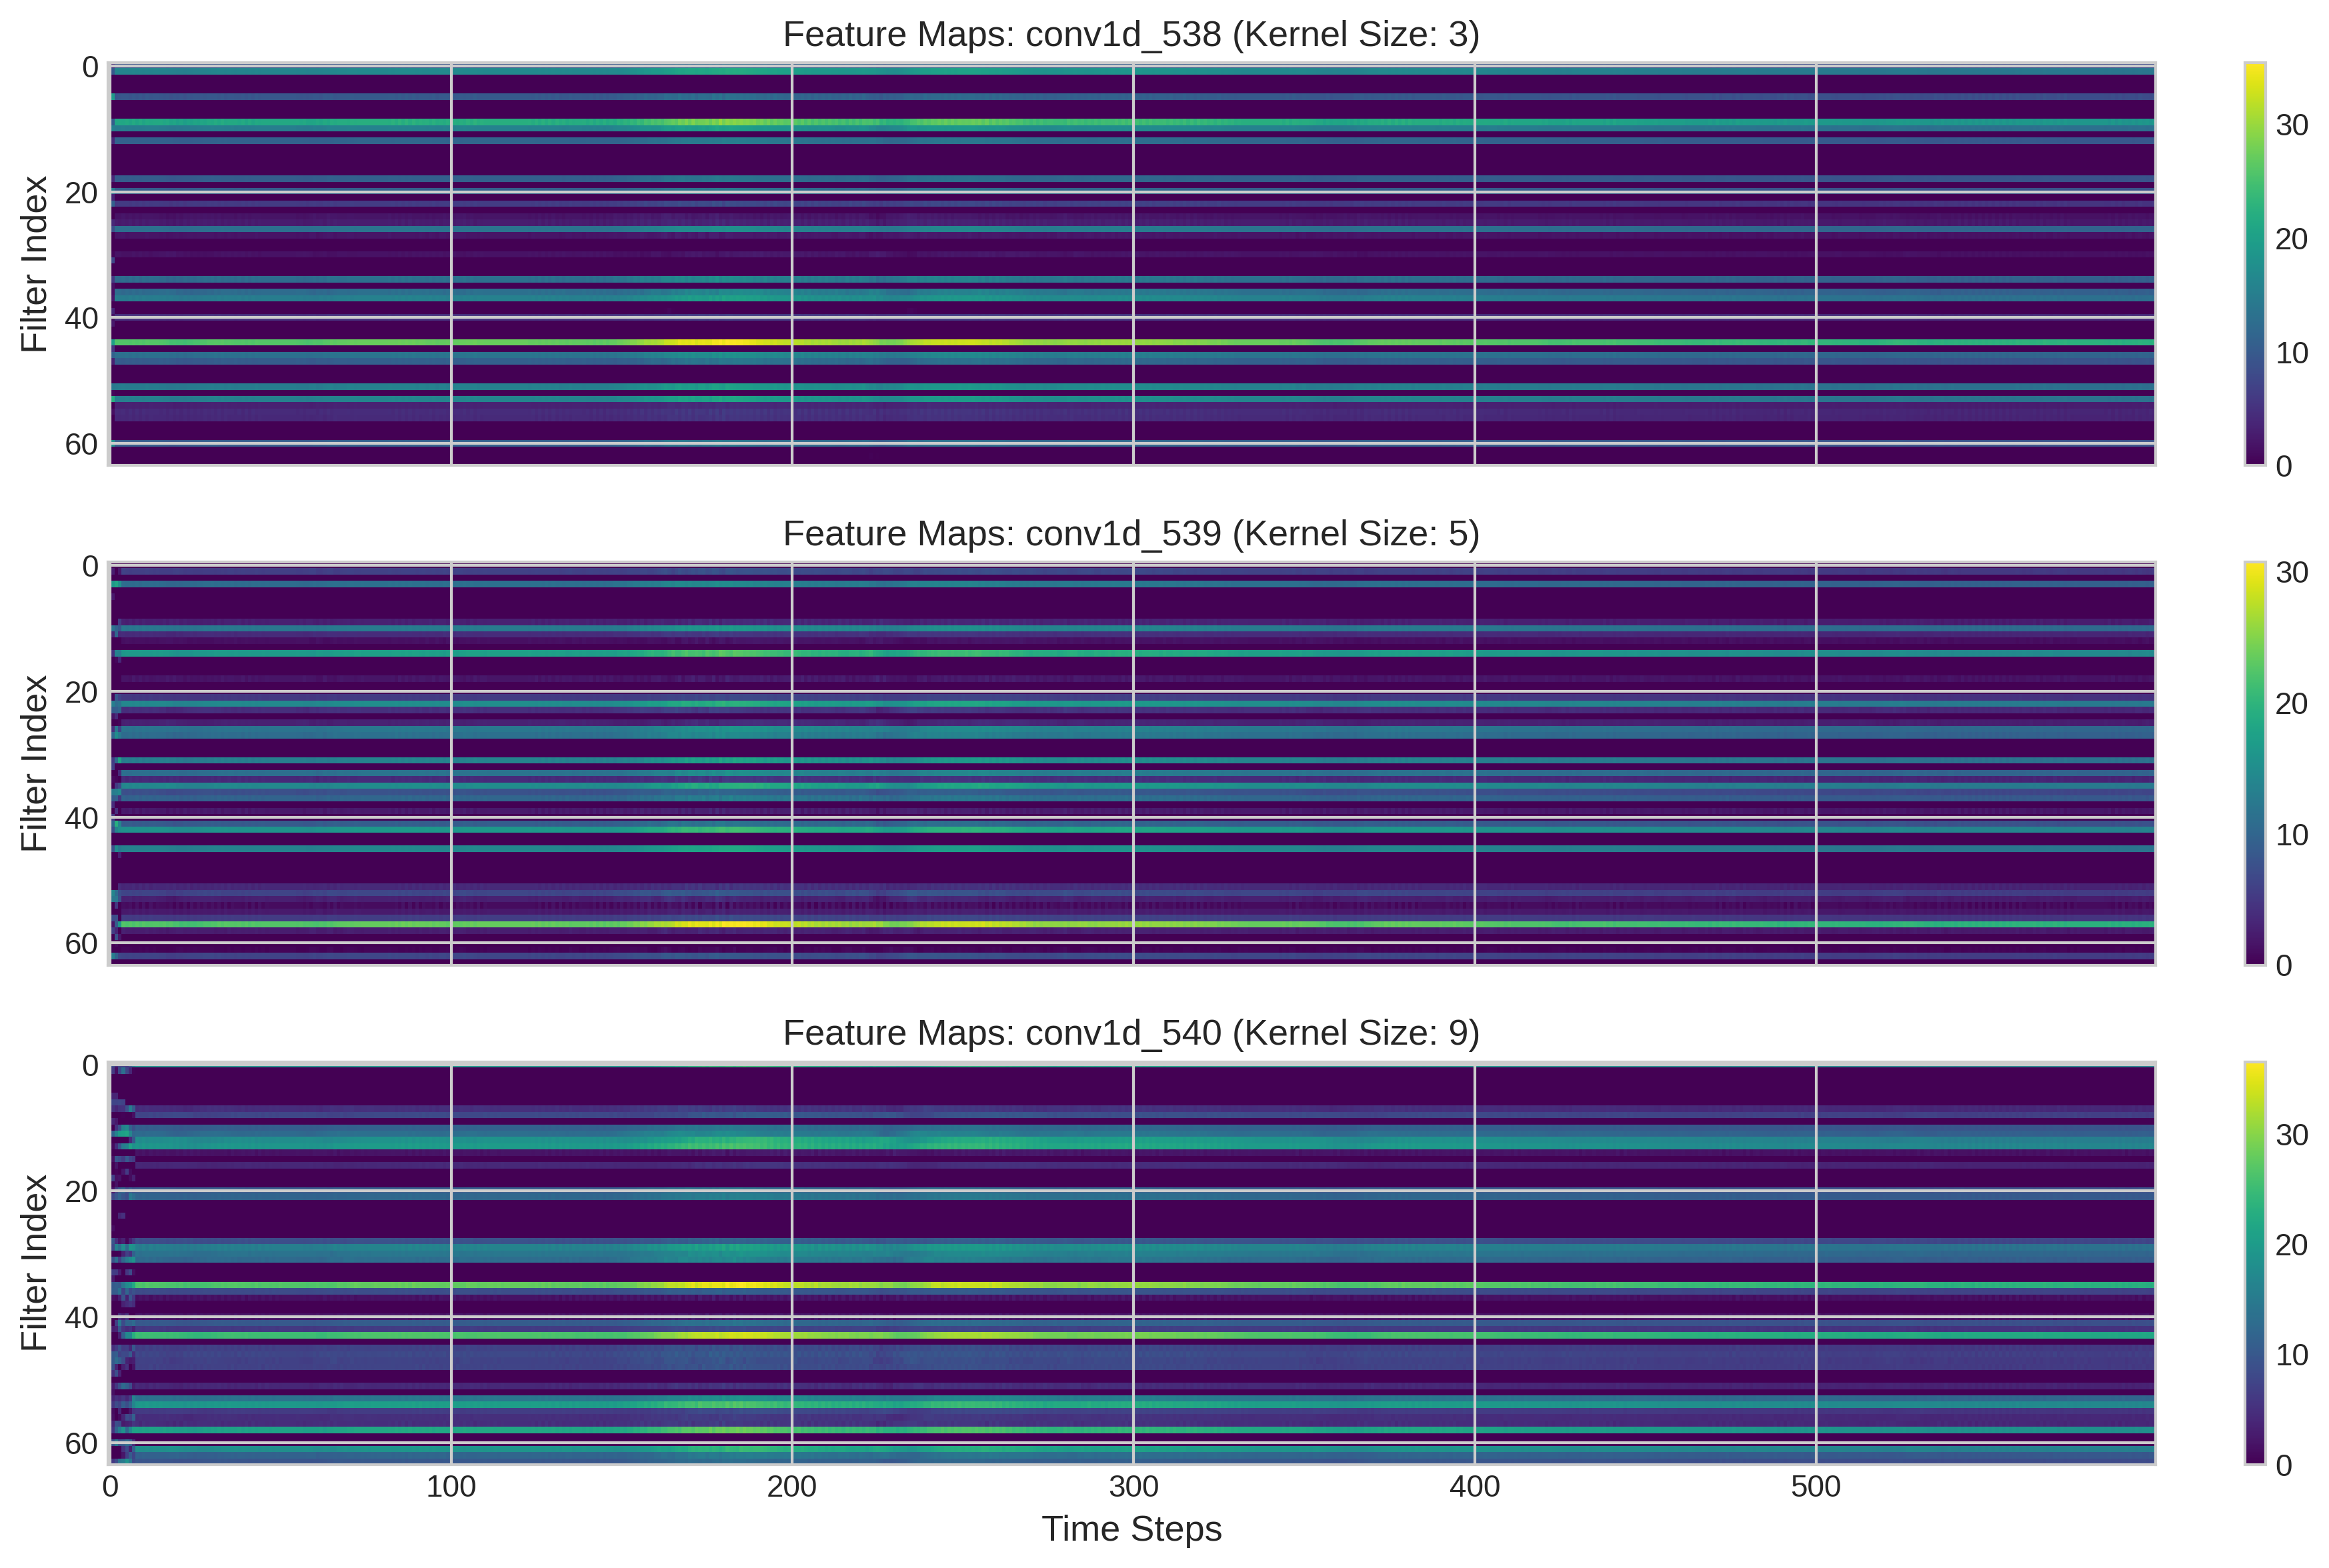

In [ ]:
def plot_multiscale_features_highend(model, x_sample, top_k=12):
    """
    High-end visualization of multi-scale Conv1D feature maps.

    Features:
    - Shared normalization across kernels
    - Top-K most variant filters
    - Activation energy statistics
    - Filter correlation metric
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import tensorflow as tf
    from sklearn.metrics import pairwise_distances

    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 13
    })

    # Get first 3 Conv1D layers (multi-scale)
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv1D)][:3]

    feature_maps_all = []
    stats = []

    # Extract feature maps
    for layer in conv_layers:
        feat_model = tf.keras.Model(inputs=model.input, outputs=layer.output)
        maps = feat_model.predict(x_sample[np.newaxis, ...], verbose=0).squeeze()  # (T, F)
        maps = maps.T  # (F, T)
        feature_maps_all.append((layer, maps))

    # Global normalization for comparison
    global_max = max(np.max(np.abs(maps)) for _, maps in feature_maps_all)

    fig, axes = plt.subplots(len(conv_layers), 2, figsize=(14, 10), dpi=300)

    for i, (layer, maps) in enumerate(feature_maps_all):

        # Select top-K filters by variance
        var = np.var(maps, axis=1)
        top_idx = np.argsort(var)[-top_k:]
        maps_top = maps[top_idx]

        # ---- Heatmap ----
        im = axes[i, 0].imshow(
            maps_top,
            aspect='auto',
            cmap='viridis',
            vmin=-global_max,
            vmax=global_max,
            interpolation='nearest'
        )

        axes[i, 0].set_title(
            f"{layer.name}  (Kernel={layer.kernel_size[0]})",
            fontweight="bold"
        )
        axes[i, 0].set_ylabel("Top Filter Index")
        axes[i, 0].set_xticks([])

        # ---- Quantitative Metrics ----
        energy = np.mean(np.abs(maps))
        corr = np.mean(pairwise_distances(maps, metric="correlation"))

        stats.append((layer.kernel_size[0], energy, corr))

        axes[i, 1].axis("off")
        axes[i, 1].text(
            0.05, 0.6,
            f"Activation Energy: {energy:.3f}\n"
            f"Mean Filter Diversity (1-corr): {corr:.3f}",
            fontsize=12
        )

    axes[-1, 0].set_xlabel("Time Steps")

    fig.colorbar(im, ax=axes[:, 0], fraction=0.015, pad=0.02)

    plt.tight_layout()
    plt.savefig("HighEnd_MultiScale_Features.png", dpi=600, bbox_inches="tight")
    plt.show()

    # ---- Activation Energy Comparison Plot ----
    kernels, energies, corrs = zip(*stats)

    plt.figure(figsize=(6,4), dpi=300)
    plt.bar([str(k) for k in kernels], energies)
    plt.xlabel("Kernel Size")
    plt.ylabel("Mean Activation Energy")
    plt.title("Activation Energy Across Scales", fontweight="bold")
    plt.tight_layout()
    plt.savefig("Activation_Energy_Comparison.png", dpi=600)
    plt.show()

    # ---- Filter Diversity Comparison ----
    plt.figure(figsize=(6,4), dpi=300)
    plt.bar([str(k) for k in kernels], corrs)
    plt.xlabel("Kernel Size")
    plt.ylabel("Mean Filter Correlation Distance")
    plt.title("Filter Diversity Across Scales", fontweight="bold")
    plt.tight_layout()
    plt.savefig("Filter_Diversity_Comparison.png", dpi=600)
    plt.show()
plot_multiscale_features(model_tcn, X_test_t[0])

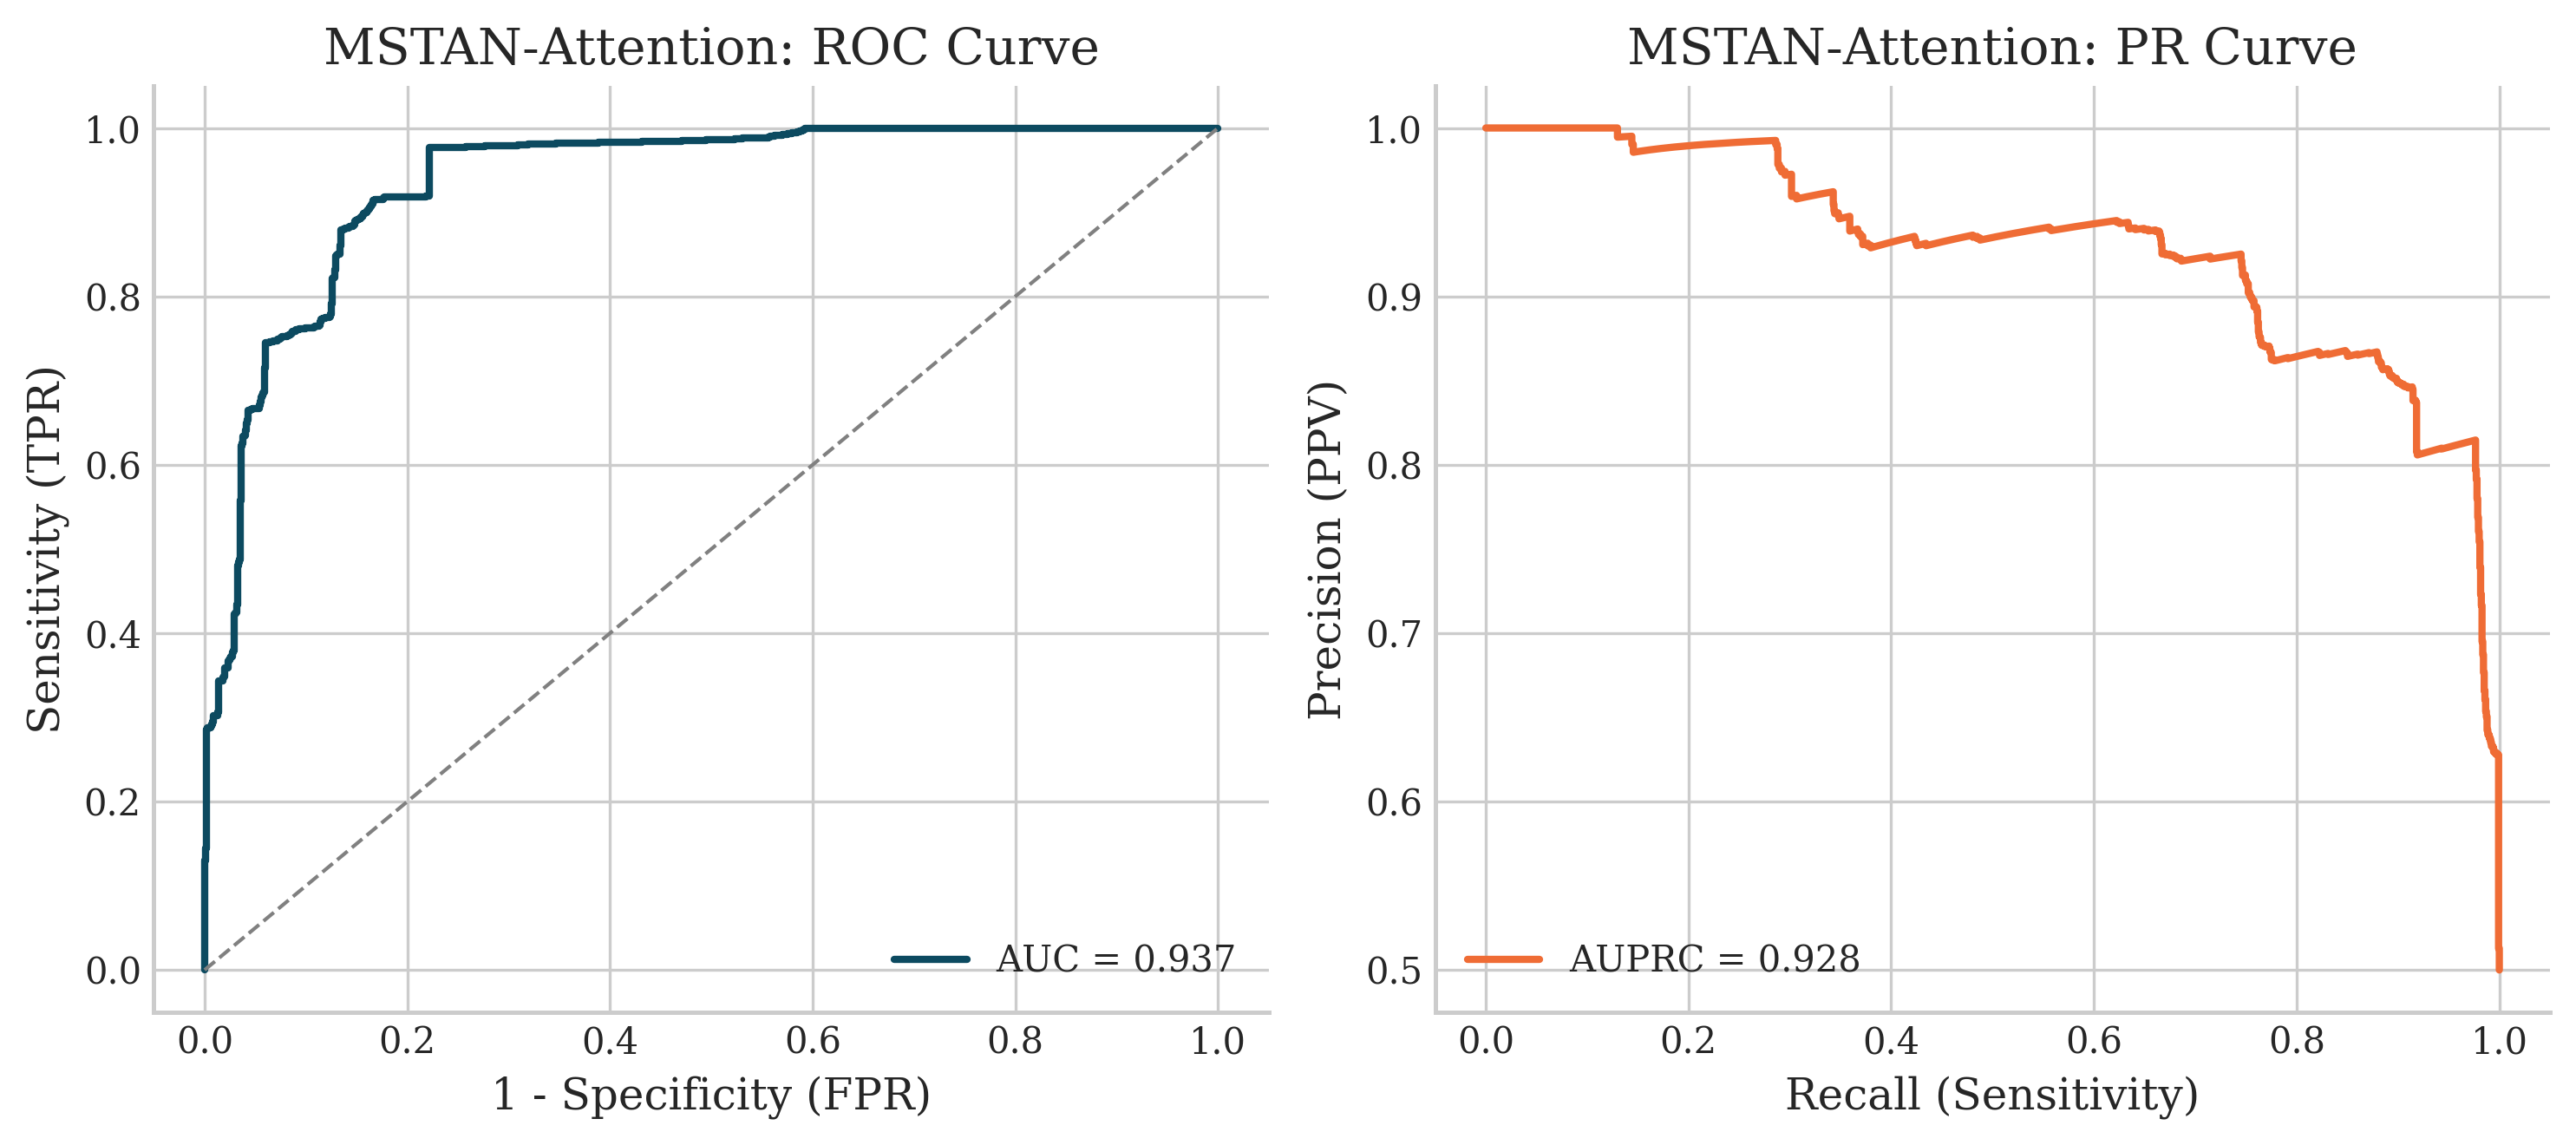

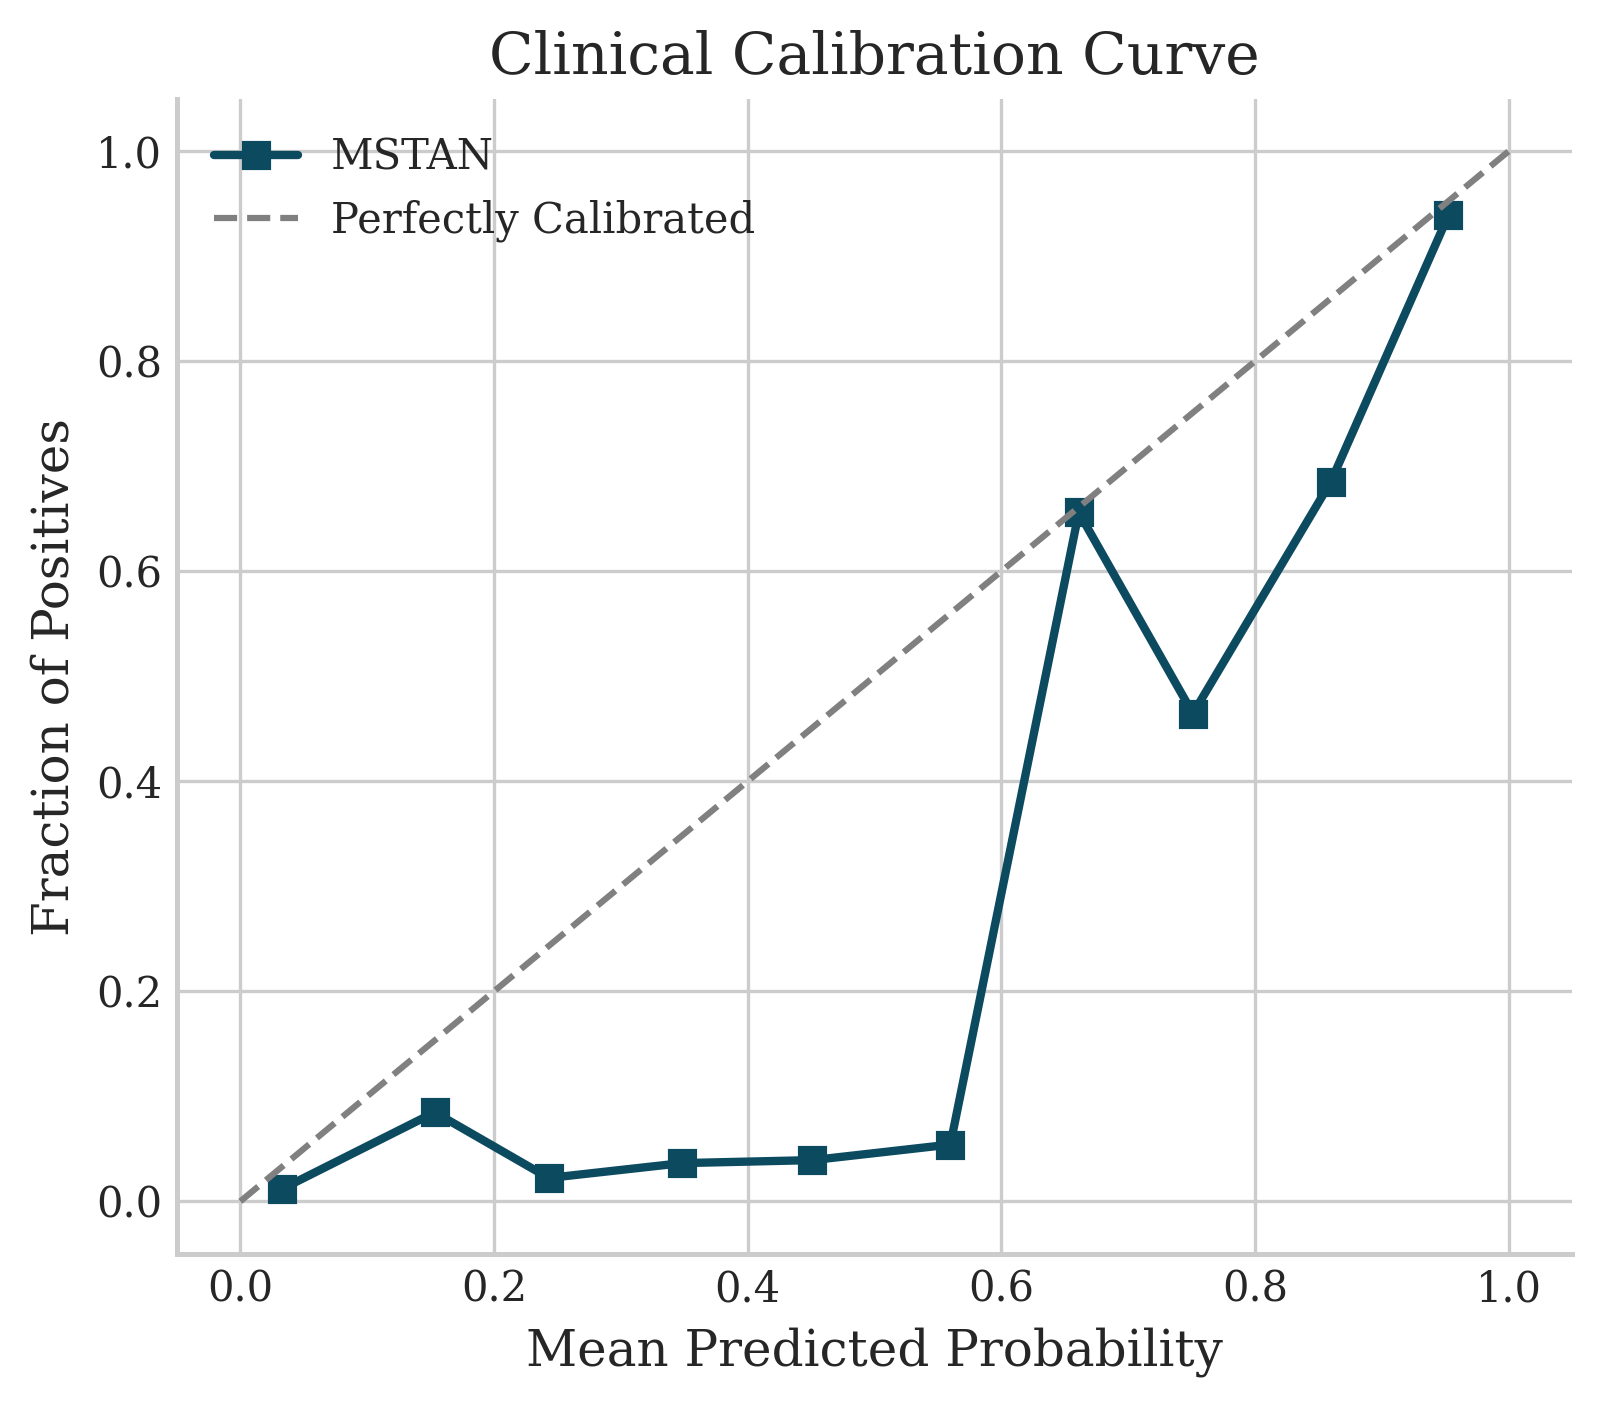

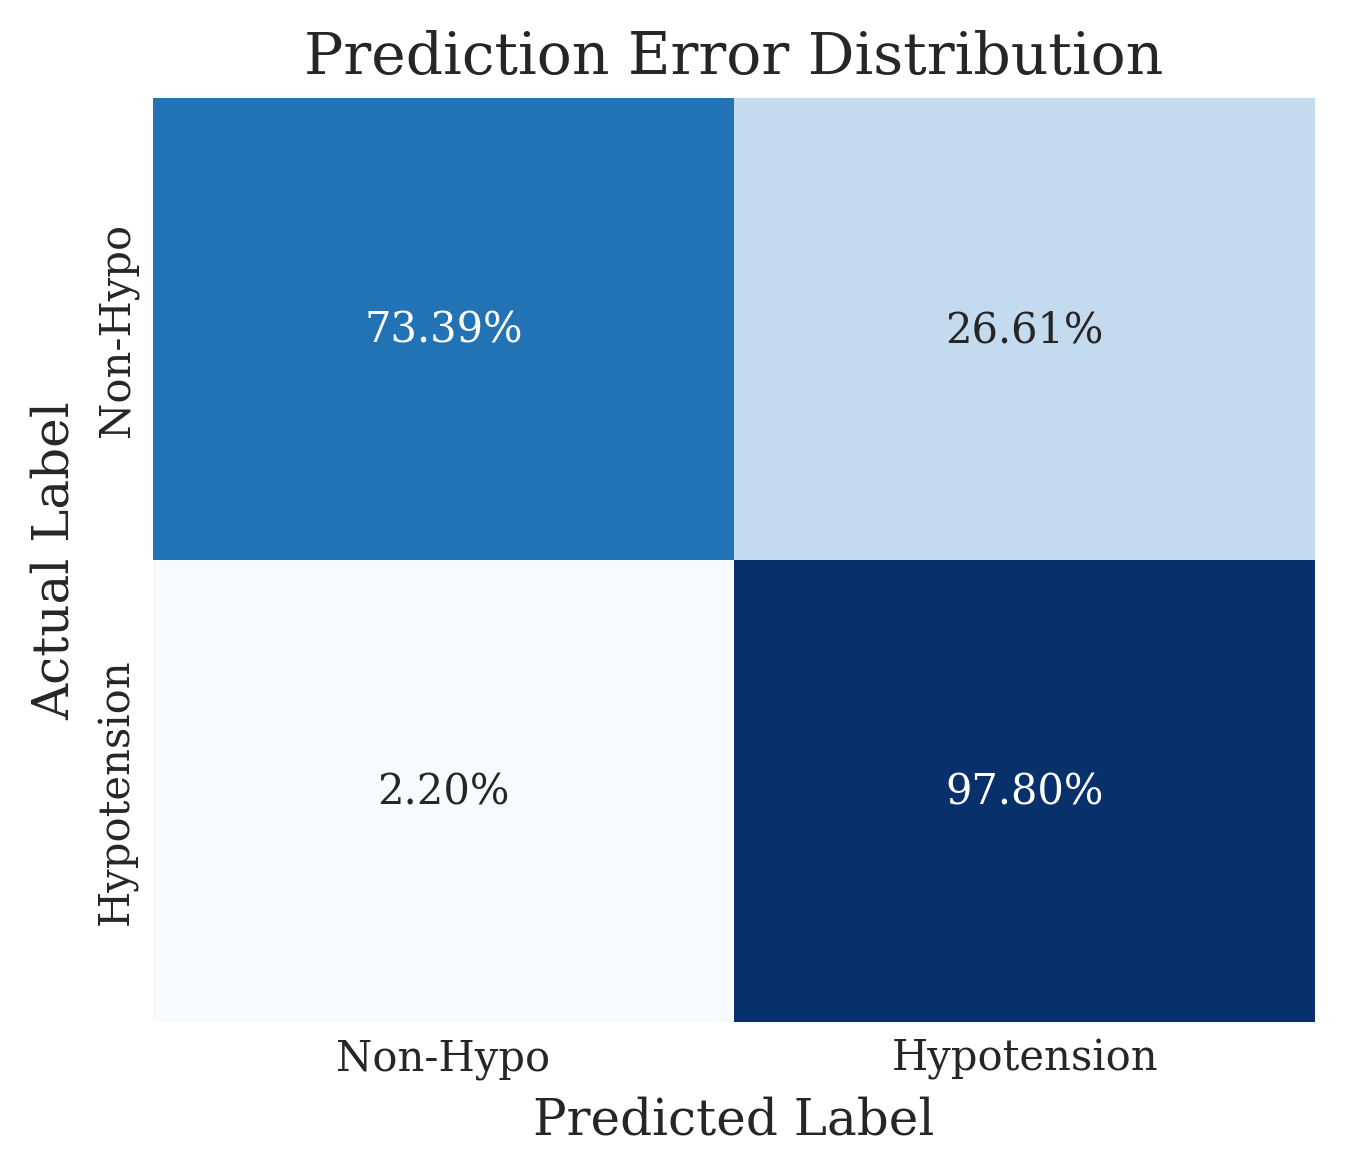

Figures saved successfully as vector PDFs.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve

# ============================================================
# 4️⃣ High-End Visualizer for Publication
# ============================================================

class HighEndVisualizer:
    def __init__(self, font_family='serif'):
        # Set global styling for academic standards
        plt.rcParams.update({
            "font.family": font_family,
            "font.size": 10,
            "axes.labelsize": 12,
            "axes.titlesize": 14,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "axes.linewidth": 1.2,
            "figure.dpi": 300
        })
        # Use a professional, color-blind friendly palette
        self.colors = ['#0C4A60', '#EF6C35', '#2ca02c', '#d62728']

    def plot_main_performance(self, y_true, y_prob, model_name="MSTAN"):
        """Figure 1: ROC and PR Curves side-by-side"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        ax1.plot(fpr, tpr, color=self.colors[0], lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
        ax1.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
        ax1.set_title(f'{model_name}: ROC Curve')
        ax1.set_xlabel('1 - Specificity (FPR)')
        ax1.set_ylabel('Sensitivity (TPR)')
        ax1.legend(loc='lower right', frameon=False)

        # PR Curve
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        ax2.plot(rec, prec, color=self.colors[1], lw=2, label=f'AUPRC = {auc(rec, prec):.3f}')
        ax2.set_title(f'{model_name}: PR Curve')
        ax2.set_xlabel('Recall (Sensitivity)')
        ax2.set_ylabel('Precision (PPV)')
        ax2.legend(loc='lower left', frameon=False)

        sns.despine(fig)
        plt.tight_layout()
        plt.savefig("figure_performance.pdf", bbox_inches='tight')
        plt.show()

    def plot_calibration(self, y_true, y_prob):
        """Figure 2: Reliability Diagram (Calibration)"""
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

        plt.figure(figsize=(6, 5))
        plt.plot(prob_pred, prob_true, marker='s', lw=2, color=self.colors[0], label='MSTAN')
        plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfectly Calibrated')

        plt.title('Clinical Calibration Curve')
        plt.xlabel('Mean Predicted Probability')
        plt.ylabel('Fraction of Positives')
        plt.legend(frameon=False)
        sns.despine()
        plt.savefig("figure_calibration.pdf", bbox_inches='tight')
        plt.show()

    def plot_confusion_matrix(self, y_true, y_prob):
        """Figure 3: Normalized Confusion Matrix"""
        y_pred = (y_prob > 0.5).astype(int)
        cm = confusion_matrix(y_true, y_pred, normalize='true')

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', cbar=False,
                    xticklabels=['Non-Hypo', 'Hypotension'],
                    yticklabels=['Non-Hypo', 'Hypotension'])

        plt.title('Prediction Error Distribution')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.savefig("figure_cm.pdf", bbox_inches='tight')
        plt.show()

# ============================================================
# 5️⃣ Execution
# ============================================================

# Initialize the high-end visualizer
viz = HighEndVisualizer()

# Generate the figures
viz.plot_main_performance(y_test, y_prob, model_name="MSTAN-Attention")
viz.plot_calibration(y_test, y_prob)
viz.plot_confusion_matrix(y_test, y_prob)

print("Figures saved successfully as vector PDFs.")

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


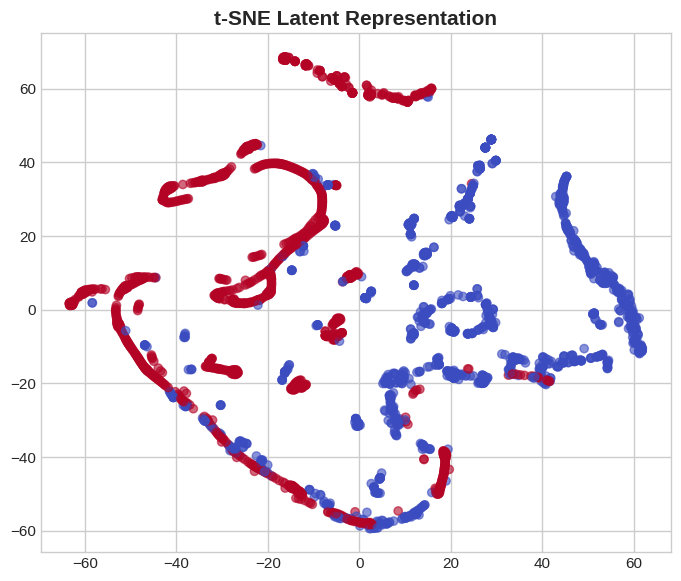

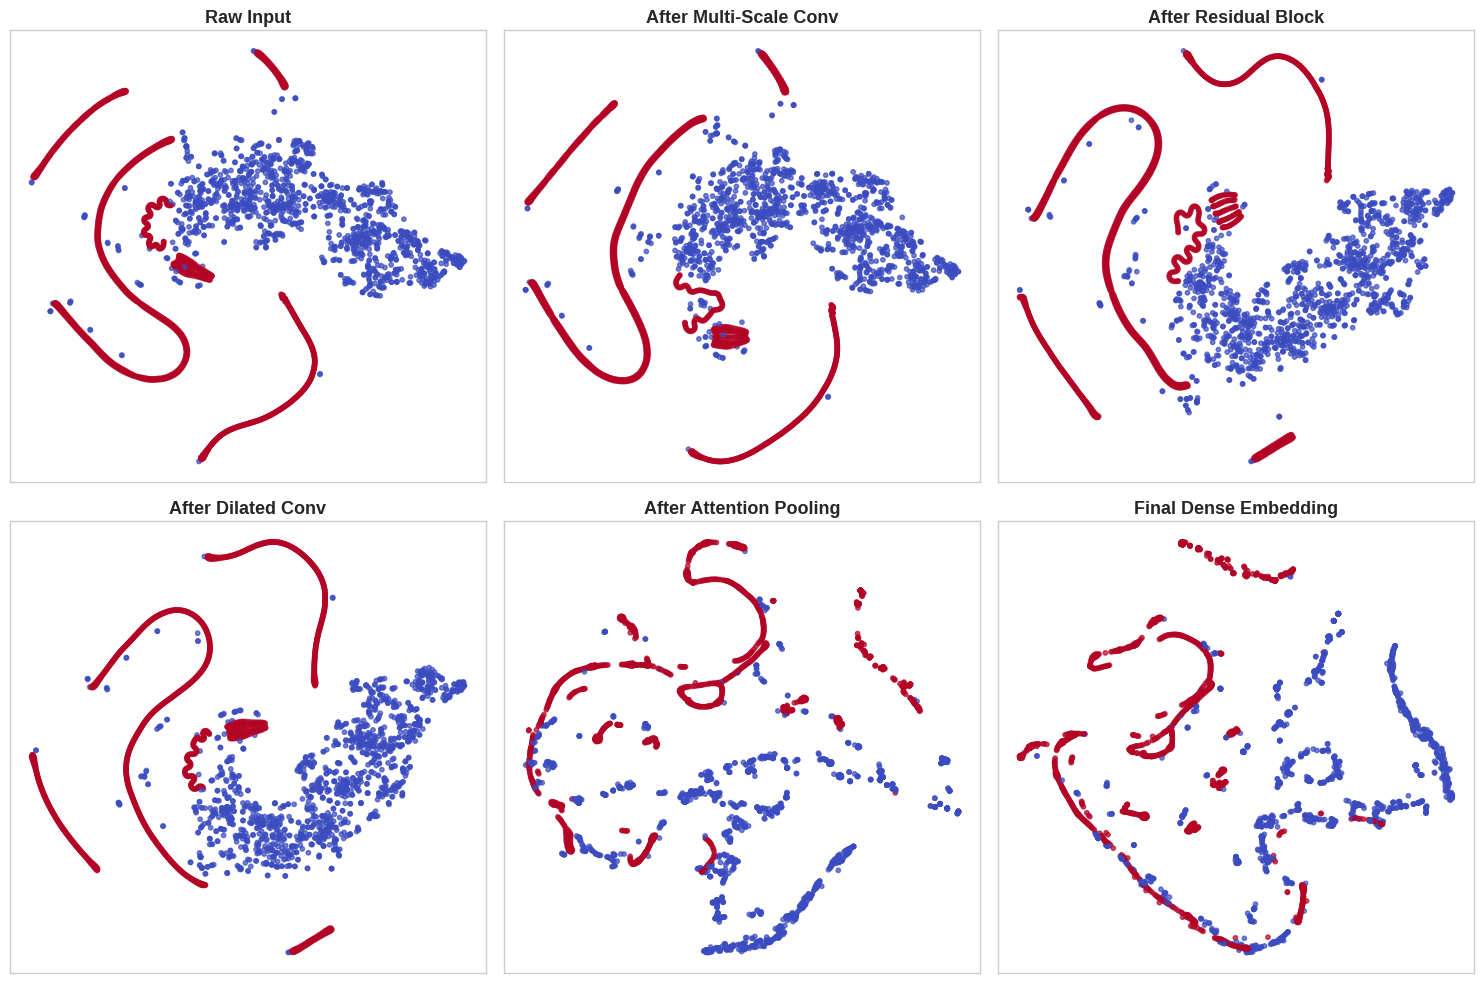

In [ ]:
from sklearn.manifold import TSNE

feature_model = tf.keras.Model(
    inputs=model_tcn.input,
    outputs=model_tcn.layers[-3].output  # last dense before output
)

features = feature_model.predict(X_test_t)
tsne = TSNE(n_components=2, random_state=42)
proj = tsne.fit_transform(features)

plt.figure(figsize=(7,6))
plt.scatter(proj[:,0], proj[:,1], c=y_test, cmap="coolwarm", alpha=0.6)
plt.title("t-SNE Latent Representation", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig_tSNE.png", dpi=600)
plt.show()

# ============================================================
# Multi-Level t-SNE Visualization Across Architecture
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import tensorflow as tf
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13
})

# ------------------------------------------------------------
# Helper: Flatten temporal features for t-SNE
# ------------------------------------------------------------

def flatten_temporal(x):
    return x.reshape(x.shape[0], -1)

# ------------------------------------------------------------
# Define feature extraction layers by index
# ------------------------------------------------------------

layer_indices = {
    "Raw Input": None,
    "After Multi-Scale Conv": 4,
    "After Residual Block": 8,
    "After Dilated Conv": 10,
    "After Attention Pooling": -4,
    "Final Dense Embedding": -2
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (name, layer_idx) in zip(axes.flatten(), layer_indices.items()):

    if layer_idx is None:
        features = flatten_temporal(X_test_t)
    else:
        feature_model = tf.keras.Model(
            inputs=model_tcn.input,
            outputs=model_tcn.layers[layer_idx].output
        )
        feat = feature_model.predict(X_test_t, verbose=0)

        if len(feat.shape) == 3:
            features = flatten_temporal(feat)
        else:
            features = feat

    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30,
        init='pca',
        learning_rate='auto'
    )

    proj = tsne.fit_transform(features)

    scatter = ax.scatter(
        proj[:,0], proj[:,1],
        c=y_test,
        cmap="coolwarm",
        alpha=0.7,
        s=10
    )

    ax.set_title(name, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("Fig_MultiLevel_tSNE.png", dpi=600, bbox_inches="tight")
plt.show()

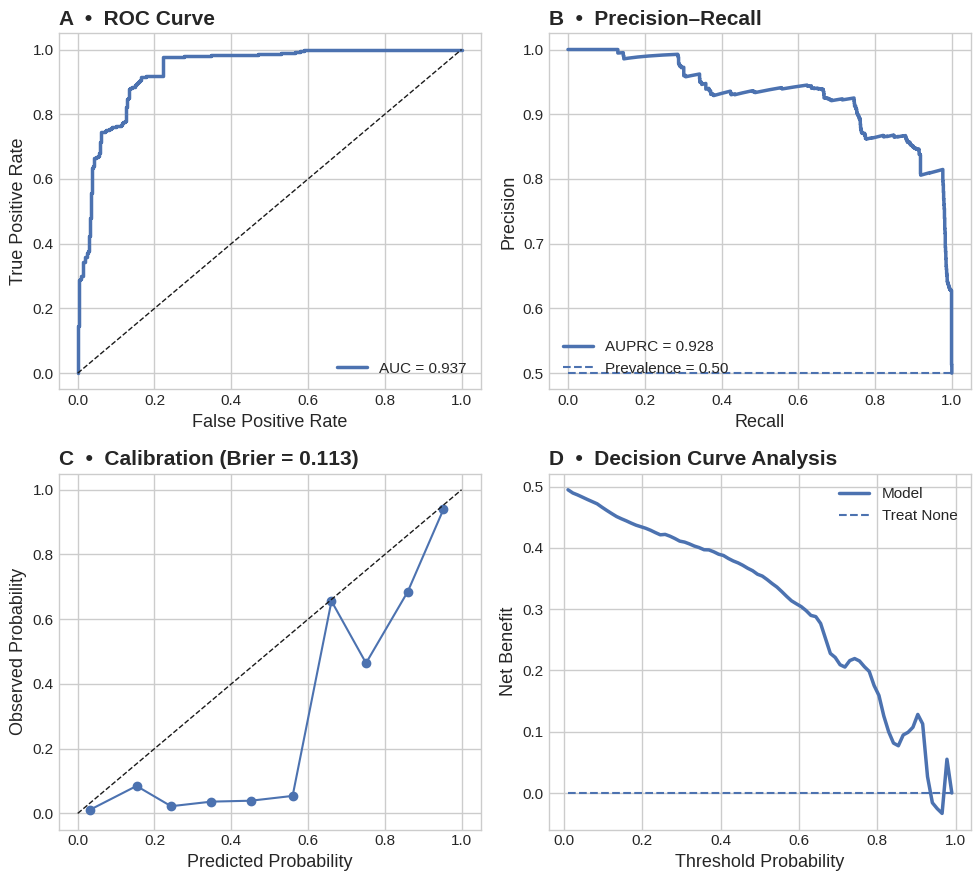

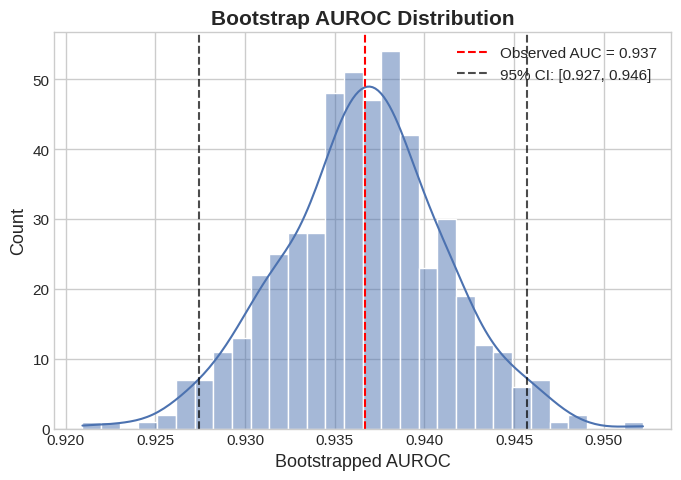

Bootstrapped AUROC 95% CI: [0.927, 0.946]


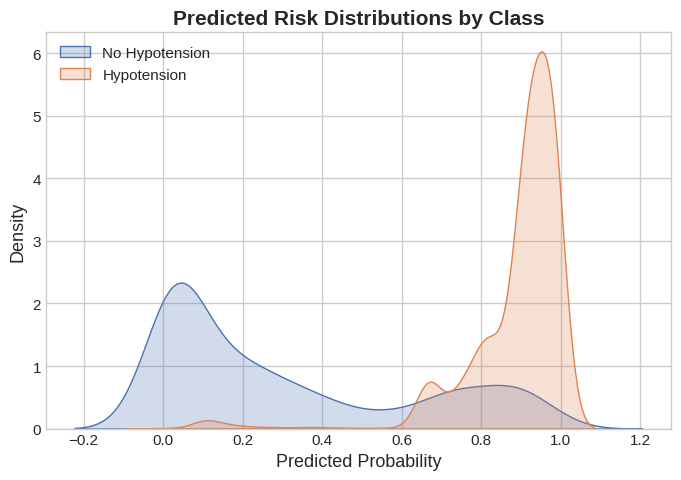

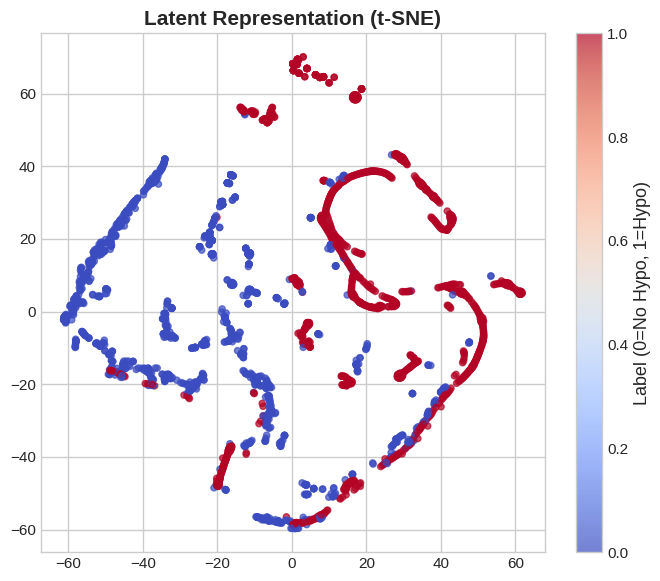

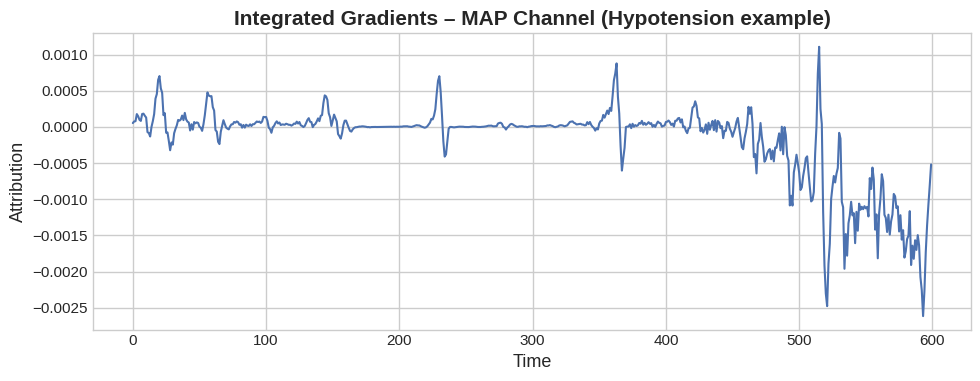

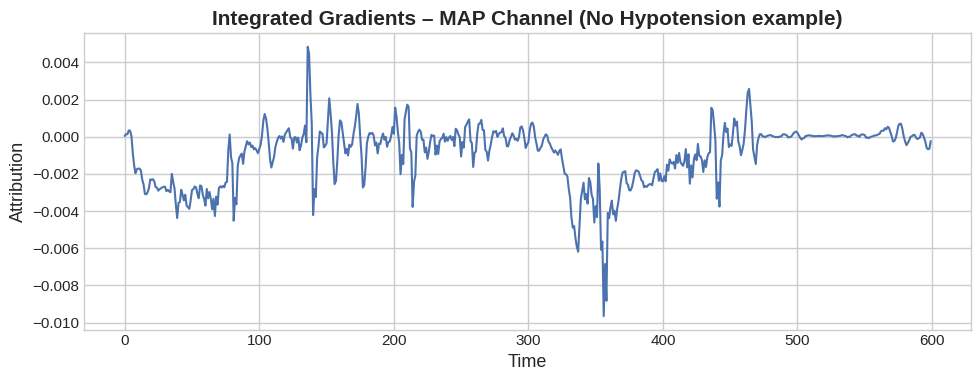

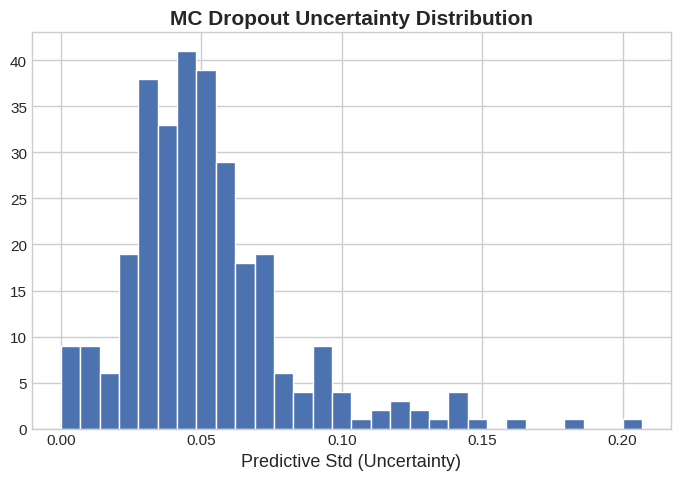

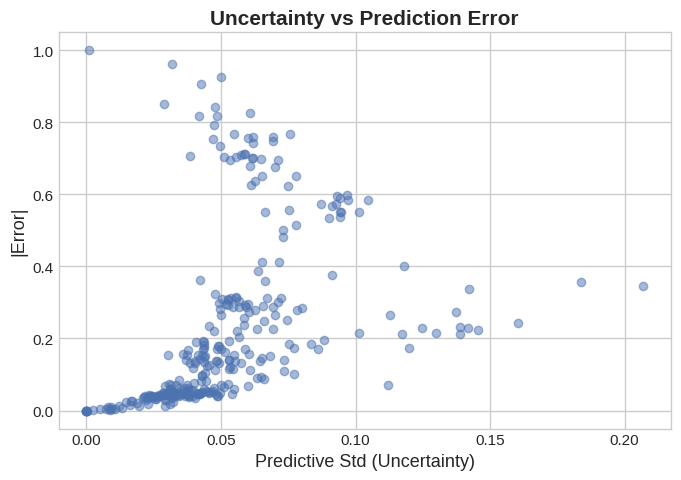

Ultra-high-end figures generated (saved as PNG, 600 dpi).


In [ ]:
# ============================================================
# Ultra-High-End Technical Figures for Proposed TCN Model
# Assumes: model_tcn, X_test_t, y_test, y_prob already defined
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, roc_auc_score, f1_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from sklearn.manifold import TSNE

import tensorflow as tf

# ------------------------------------------------------------
# Global styling (Nature-style minimalist)
# ------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "figure.dpi": 100
})

# ------------------------------------------------------------
# 0️⃣ Basic metrics we’ll reuse
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
prevalence = np.mean(y_test)

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
brier = brier_score_loss(y_test, y_prob)

# Decision curve
thresholds = np.linspace(0.01, 0.99, 80)
net_benefit = []
for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    nb = (tp/len(y_test)) - (fp/len(y_test)) * (t/(1-t))
    net_benefit.append(nb)
net_benefit = np.array(net_benefit)

# ------------------------------------------------------------
# 1️⃣ MAIN MULTI-PANEL FIGURE (ROC + PR + Calibration + DCA)
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

# (A) ROC with diagonal
ax = axes[0, 0]
ax.plot(fpr, tpr, linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("A  •  ROC Curve", loc="left", fontweight="bold")
ax.legend(loc="lower right")

# (B) Precision–Recall
ax = axes[0, 1]
ax.plot(recall, precision, linewidth=2.5, label=f"AUPRC = {ap:.3f}")
ax.hlines(prevalence, 0, 1, linestyles="dashed",
          label=f"Prevalence = {prevalence:.2f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("B  •  Precision–Recall", loc="left", fontweight="bold")
ax.legend(loc="lower left")

# (C) Calibration
ax = axes[1, 0]
ax.plot(prob_pred, prob_true, marker='o')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Observed Probability")
ax.set_title(f"C  •  Calibration (Brier = {brier:.3f})",
             loc="left", fontweight="bold")

# (D) Decision Curve
ax = axes[1, 1]
ax.plot(thresholds, net_benefit, linewidth=2.5, label="Model")
ax.hlines(0, thresholds[0], thresholds[-1],
          linestyles="dashed", label="Treat None")
ax.set_xlabel("Threshold Probability")
ax.set_ylabel("Net Benefit")
ax.set_title("D  •  Decision Curve Analysis",
             loc="left", fontweight="bold")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("Fig_Main_Multipanel.png", dpi=600, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2️⃣ Bootstrapped AUROC Distribution (with CI)
# ------------------------------------------------------------

n_boot = 500
boot_aucs = []

for i in range(n_boot):
    idx = resample(np.arange(len(y_test)))
    if len(np.unique(y_test[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_test[idx], y_prob[idx]))

boot_aucs = np.array(boot_aucs)
ci_lower = np.percentile(boot_aucs, 2.5)
ci_upper = np.percentile(boot_aucs, 97.5)

plt.figure(figsize=(7,5))
sns.histplot(boot_aucs, kde=True, bins=30)
plt.axvline(roc_auc, color="red", linestyle="--", label=f"Observed AUC = {roc_auc:.3f}")
plt.axvline(ci_lower, color="black", linestyle="--", alpha=0.7,
            label=f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
plt.axvline(ci_upper, color="black", linestyle="--", alpha=0.7)
plt.xlabel("Bootstrapped AUROC")
plt.title("Bootstrap AUROC Distribution", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("Fig_AUROC_Bootstrap.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Bootstrapped AUROC 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

# ------------------------------------------------------------
# 3️⃣ Predicted Probability Distributions by Class
# ------------------------------------------------------------

plt.figure(figsize=(7,5))
sns.kdeplot(y_prob[y_test==0], label="No Hypotension", shade=True)
sns.kdeplot(y_prob[y_test==1], label="Hypotension", shade=True)
plt.xlabel("Predicted Probability")
plt.title("Predicted Risk Distributions by Class", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("Fig_Prob_Distributions.png", dpi=600, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4️⃣ Latent Space t-SNE (Penultimate Layer)
# ------------------------------------------------------------

# Build feature-extractor model from last Dense before output
# (Here: model_tcn.layers[-2] assumed final Dense(64), adjust if needed)
penultimate_layer = model_tcn.layers[-2].output
feature_model = tf.keras.Model(inputs=model_tcn.input, outputs=penultimate_layer)

features = feature_model.predict(X_test_t, verbose=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
proj = tsne.fit_transform(features)

plt.figure(figsize=(7,6))
sc = plt.scatter(proj[:,0], proj[:,1],
                 c=y_test, cmap="coolwarm", alpha=0.7, s=20)
plt.colorbar(sc, label="Label (0=No Hypo, 1=Hypo)")
plt.title("Latent Representation (t-SNE)", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig_tSNE_Latent.png", dpi=600, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5️⃣ Integrated Gradients Saliency over Time (for one example)
# ------------------------------------------------------------

def integrated_gradients(model, x, baseline=None, steps=50):
    """
    x: (1, T, F)
    baseline: same shape, default = zeros
    """
    if baseline is None:
        baseline = tf.zeros_like(x)

    interpolated = [
        baseline + (float(k)/steps) * (x - baseline)
        for k in range(steps+1)
    ]
    interpolated = tf.concat(interpolated, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)
    grads = tape.gradient(preds, interpolated)  # (steps+1, T, F)

    avg_grads = tf.reduce_mean(grads, axis=0)  # (T, F)
    ig = (x - baseline) * avg_grads           # (1, T, F)

    return ig.numpy().squeeze()               # (T, F)

# Choose one positive and one negative example (if available)
pos_idx = np.where(y_test == 1)[0]
neg_idx = np.where(y_test == 0)[0]

example_indices = []
if len(pos_idx) > 0:
    example_indices.append(pos_idx[0])
if len(neg_idx) > 0:
    example_indices.append(neg_idx[0])

for idx in example_indices:
    x_sample = X_test_t[idx:idx+1]
    ig = integrated_gradients(model_tcn, tf.convert_to_tensor(x_sample, dtype=tf.float32))

    # Assuming channel 0 is MAP
    ig_map = ig[:, 0]

    plt.figure(figsize=(10,4))
    plt.plot(ig_map)
    label = "Hypotension" if y_test[idx] == 1 else "No Hypotension"
    plt.title(f"Integrated Gradients – MAP Channel ({label} example)", fontweight="bold")
    plt.xlabel("Time")
    plt.ylabel("Attribution")
    plt.tight_layout()
    plt.savefig(f"Fig_IntegratedGradients_idx{idx}.png", dpi=600, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# 6️⃣ Monte Carlo Dropout Uncertainty (Predictive Variance)
# ------------------------------------------------------------

def mc_dropout_predict(model, X, n_samples=30):
    preds = []
    for _ in range(n_samples):
        preds.append(model(X, training=True).numpy().flatten())
    preds = np.stack(preds, axis=0)  # (n_samples, N)
    return preds.mean(axis=0), preds.std(axis=0)

# Use a subset for speed
subset = slice(0, min(300, len(X_test_t)))
mean_pred, std_pred = mc_dropout_predict(model_tcn, X_test_t[subset])

plt.figure(figsize=(7,5))
plt.hist(std_pred, bins=30)
plt.xlabel("Predictive Std (Uncertainty)")
plt.title("MC Dropout Uncertainty Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig_Uncertainty.png", dpi=600, bbox_inches="tight")
plt.show()

# Optional: Uncertainty vs error
err = np.abs(mean_pred - y_test[subset])
plt.figure(figsize=(7,5))
plt.scatter(std_pred, err, alpha=0.5)
plt.xlabel("Predictive Std (Uncertainty)")
plt.ylabel("|Error|")
plt.title("Uncertainty vs Prediction Error", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig_Uncertainty_vs_Error.png", dpi=600, bbox_inches="tight")
plt.show()

print("Ultra-high-end figures generated (saved as PNG, 600 dpi).")

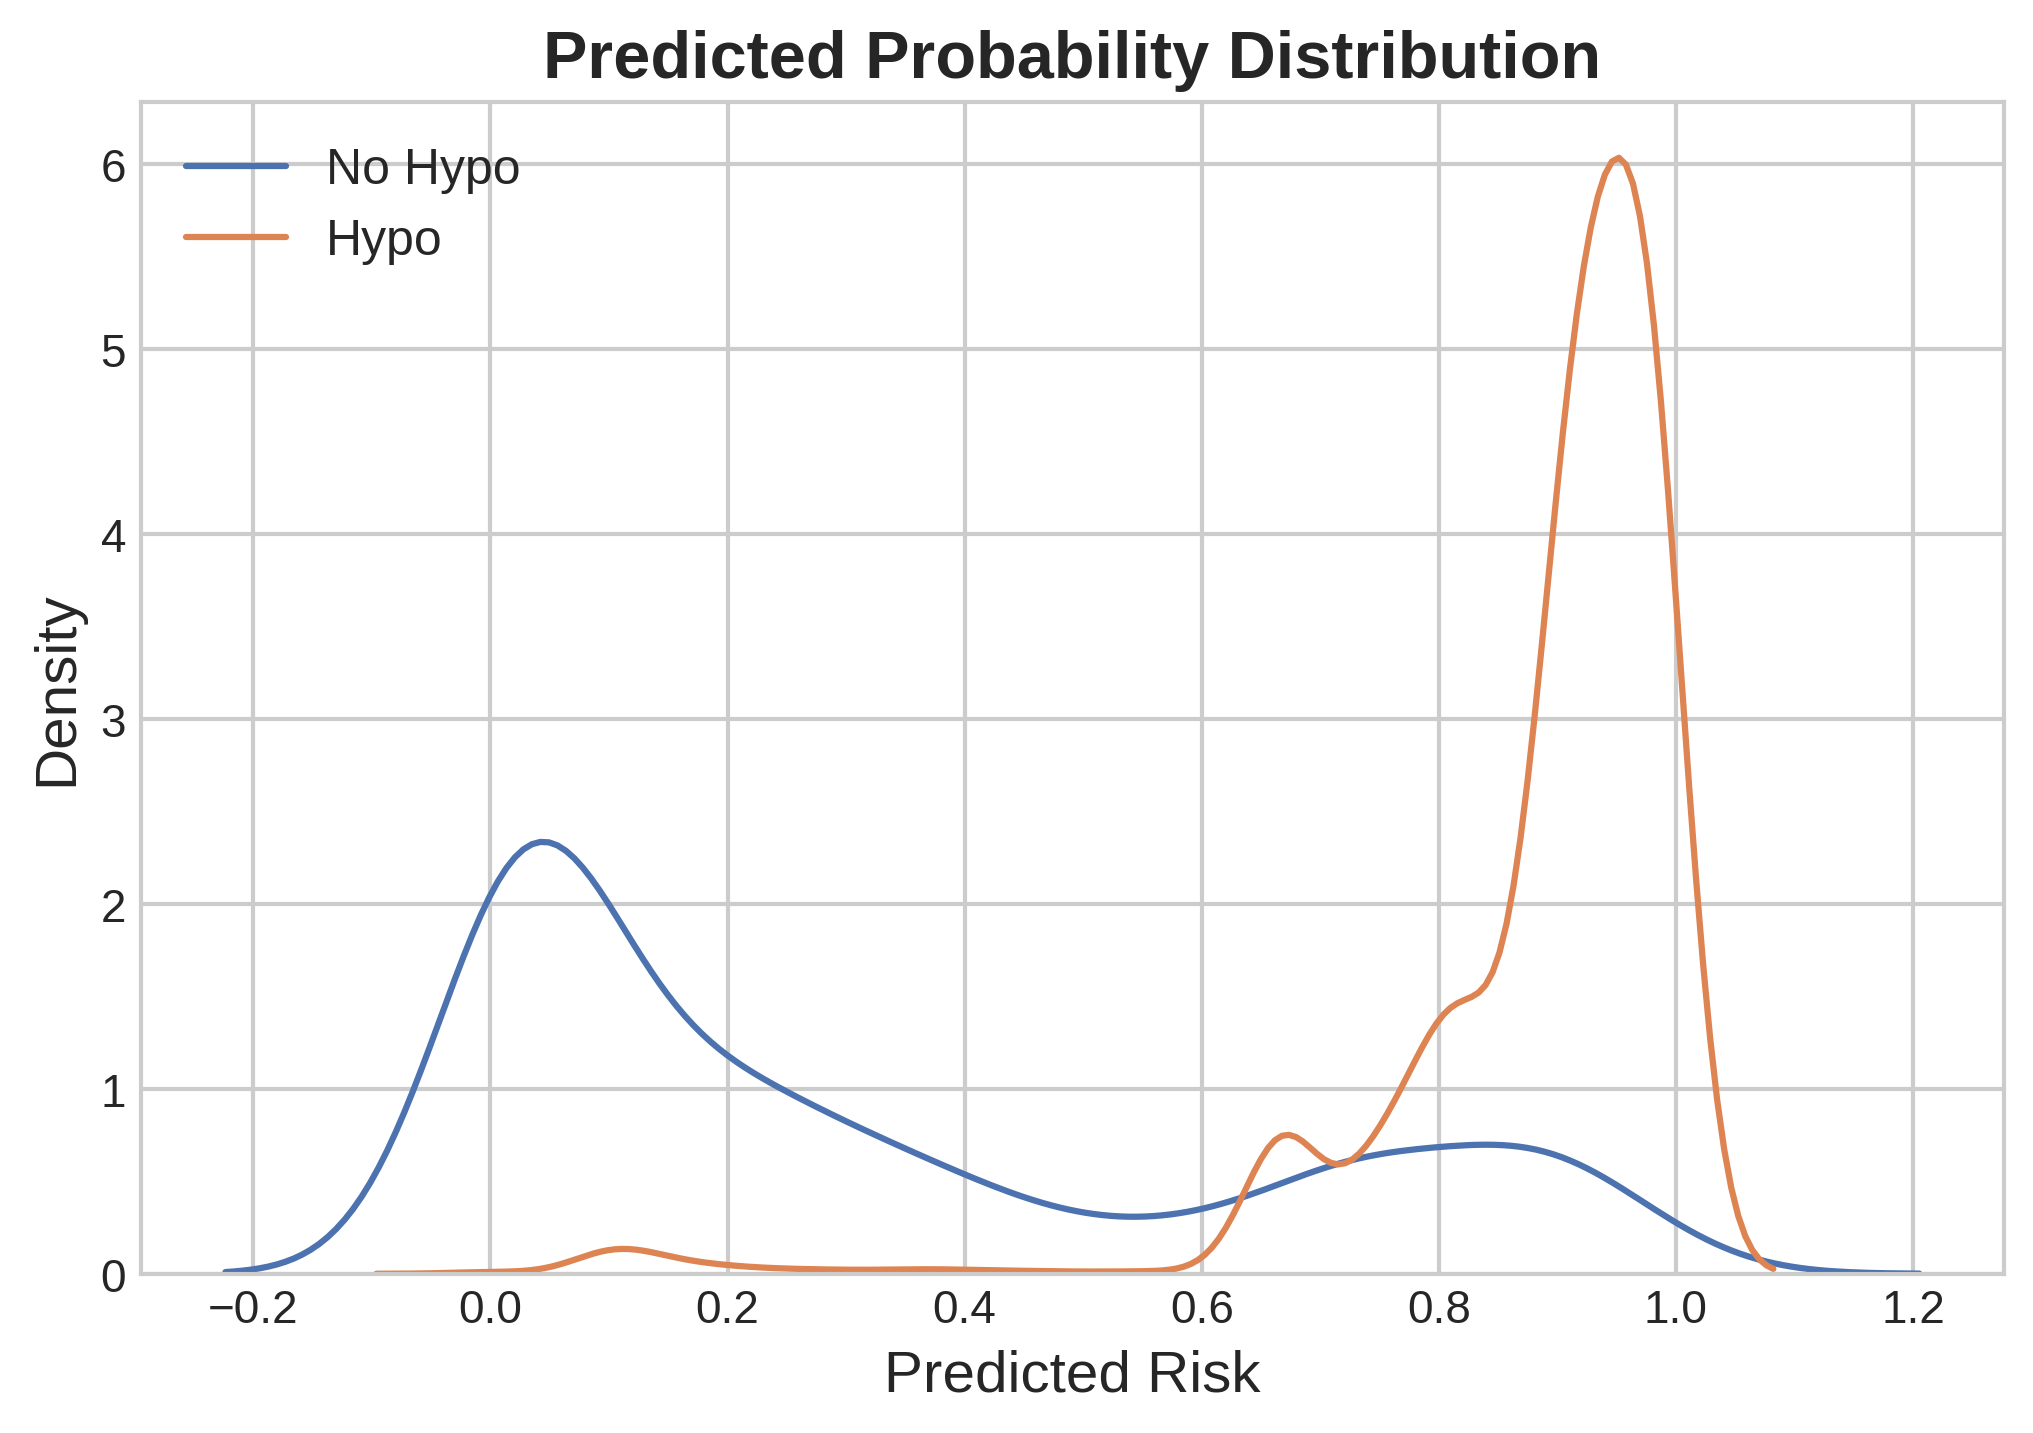

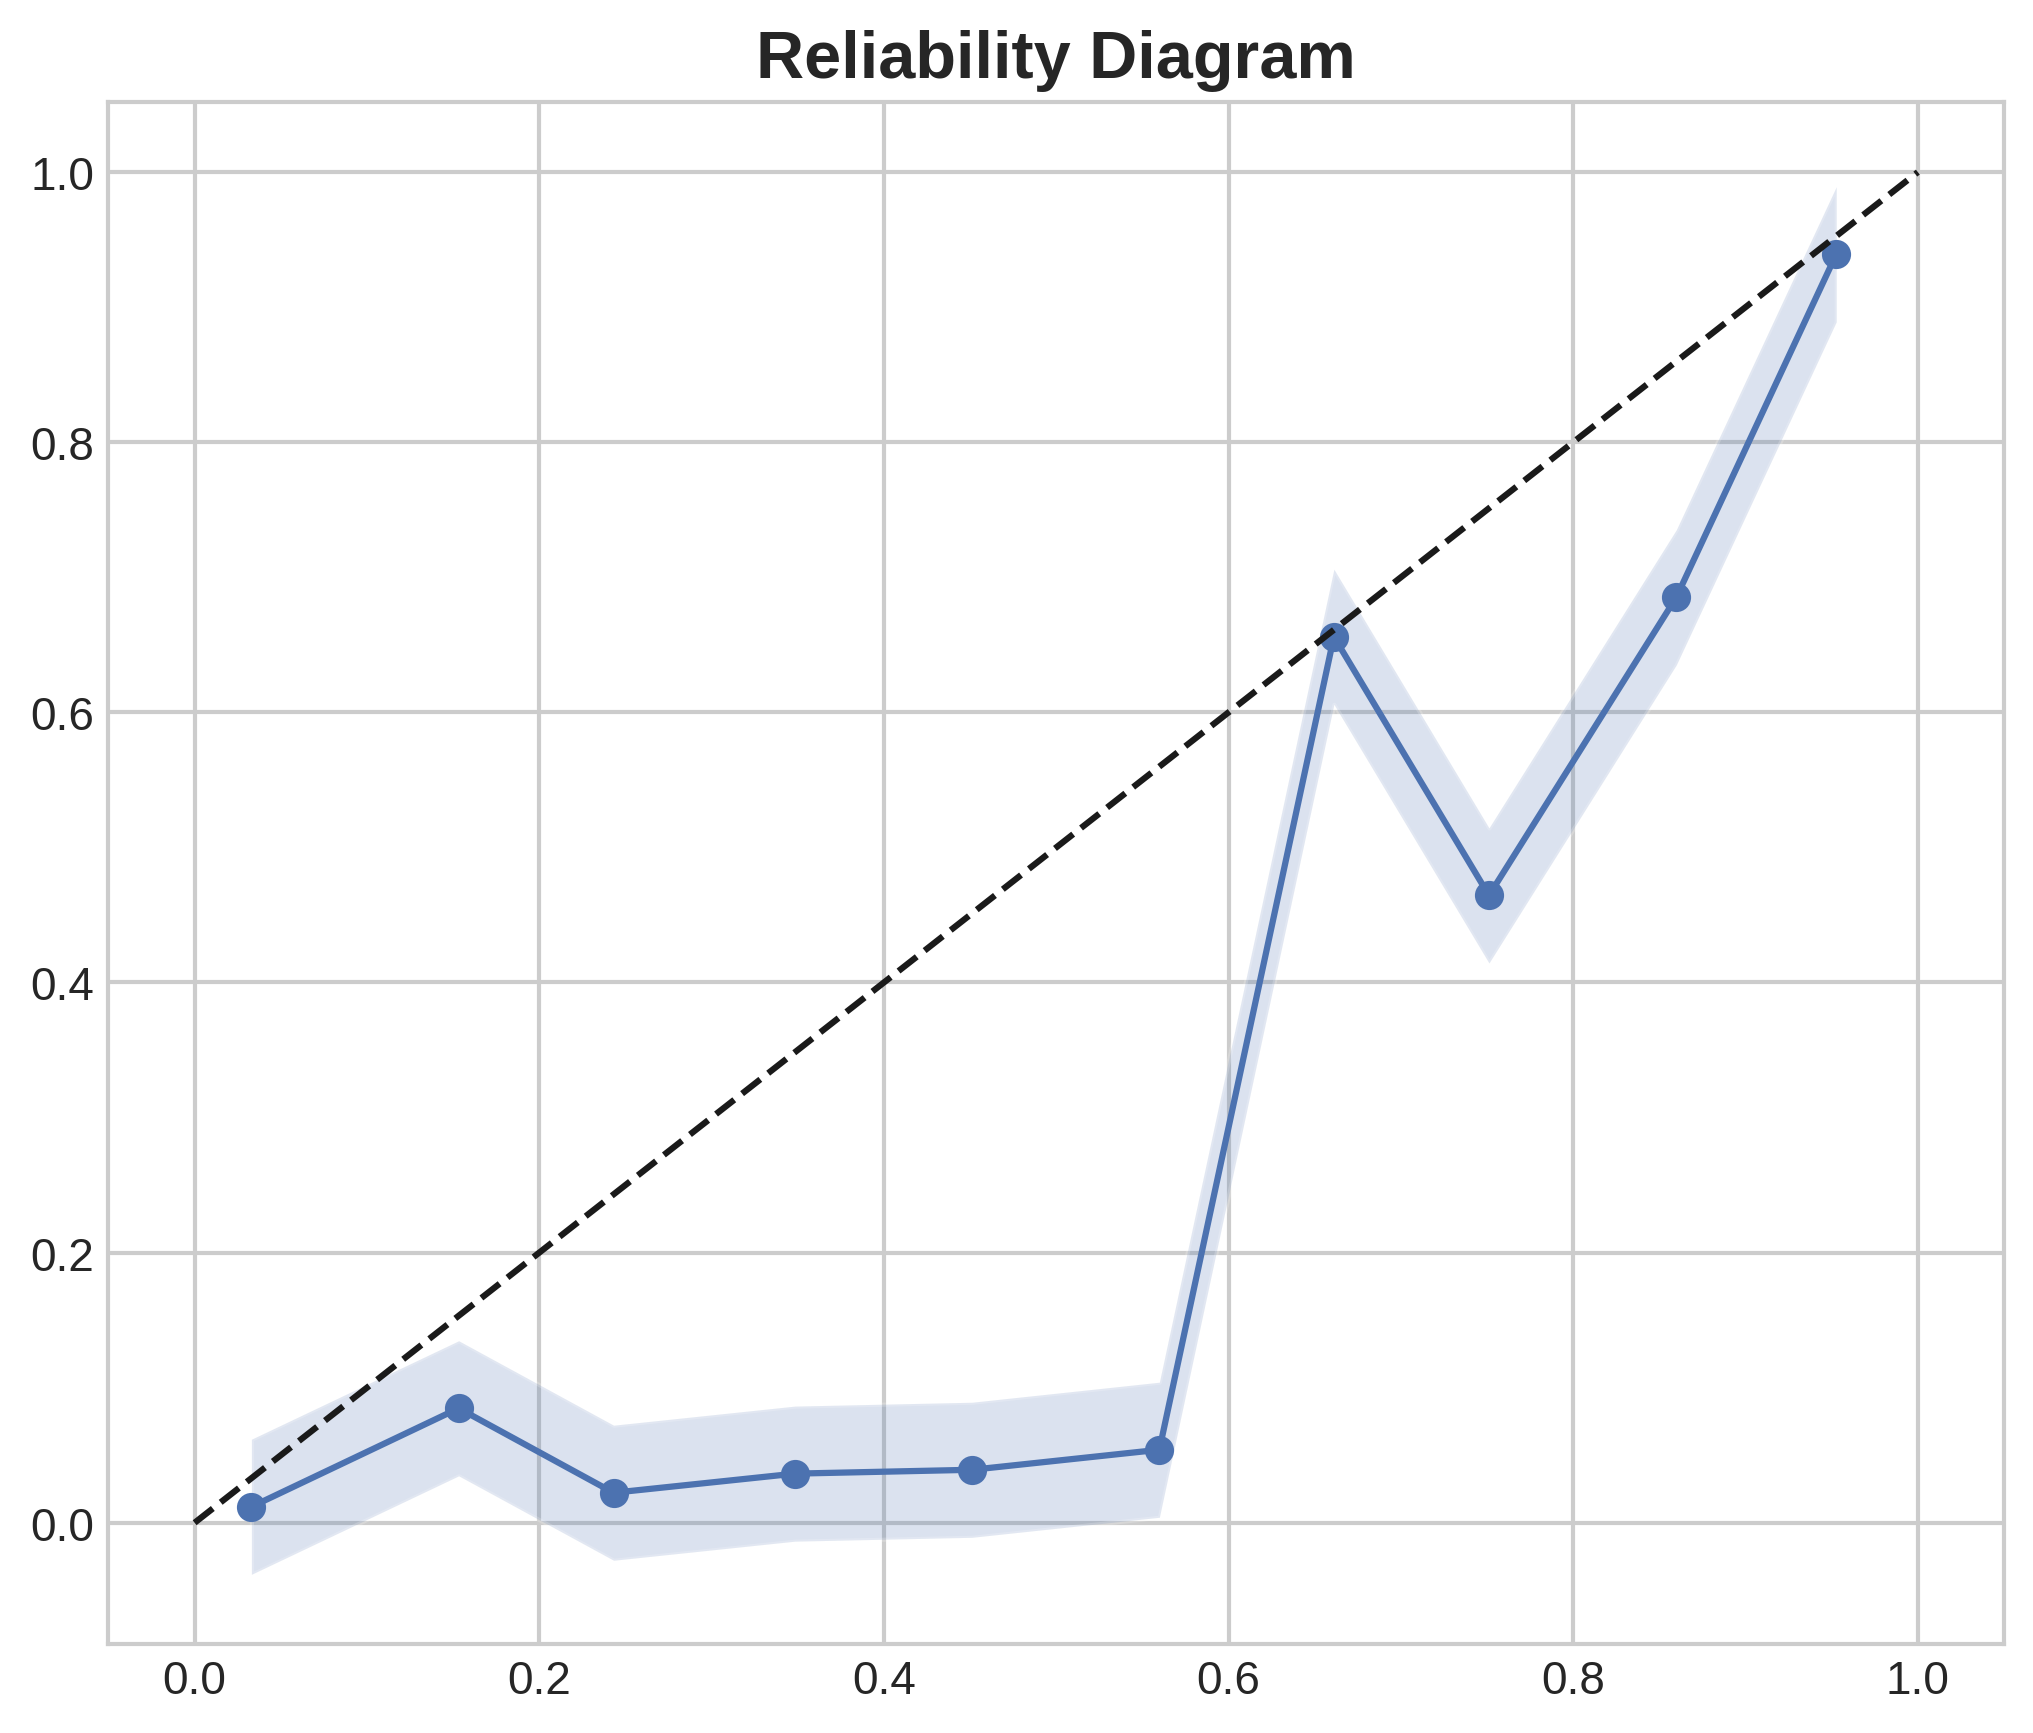

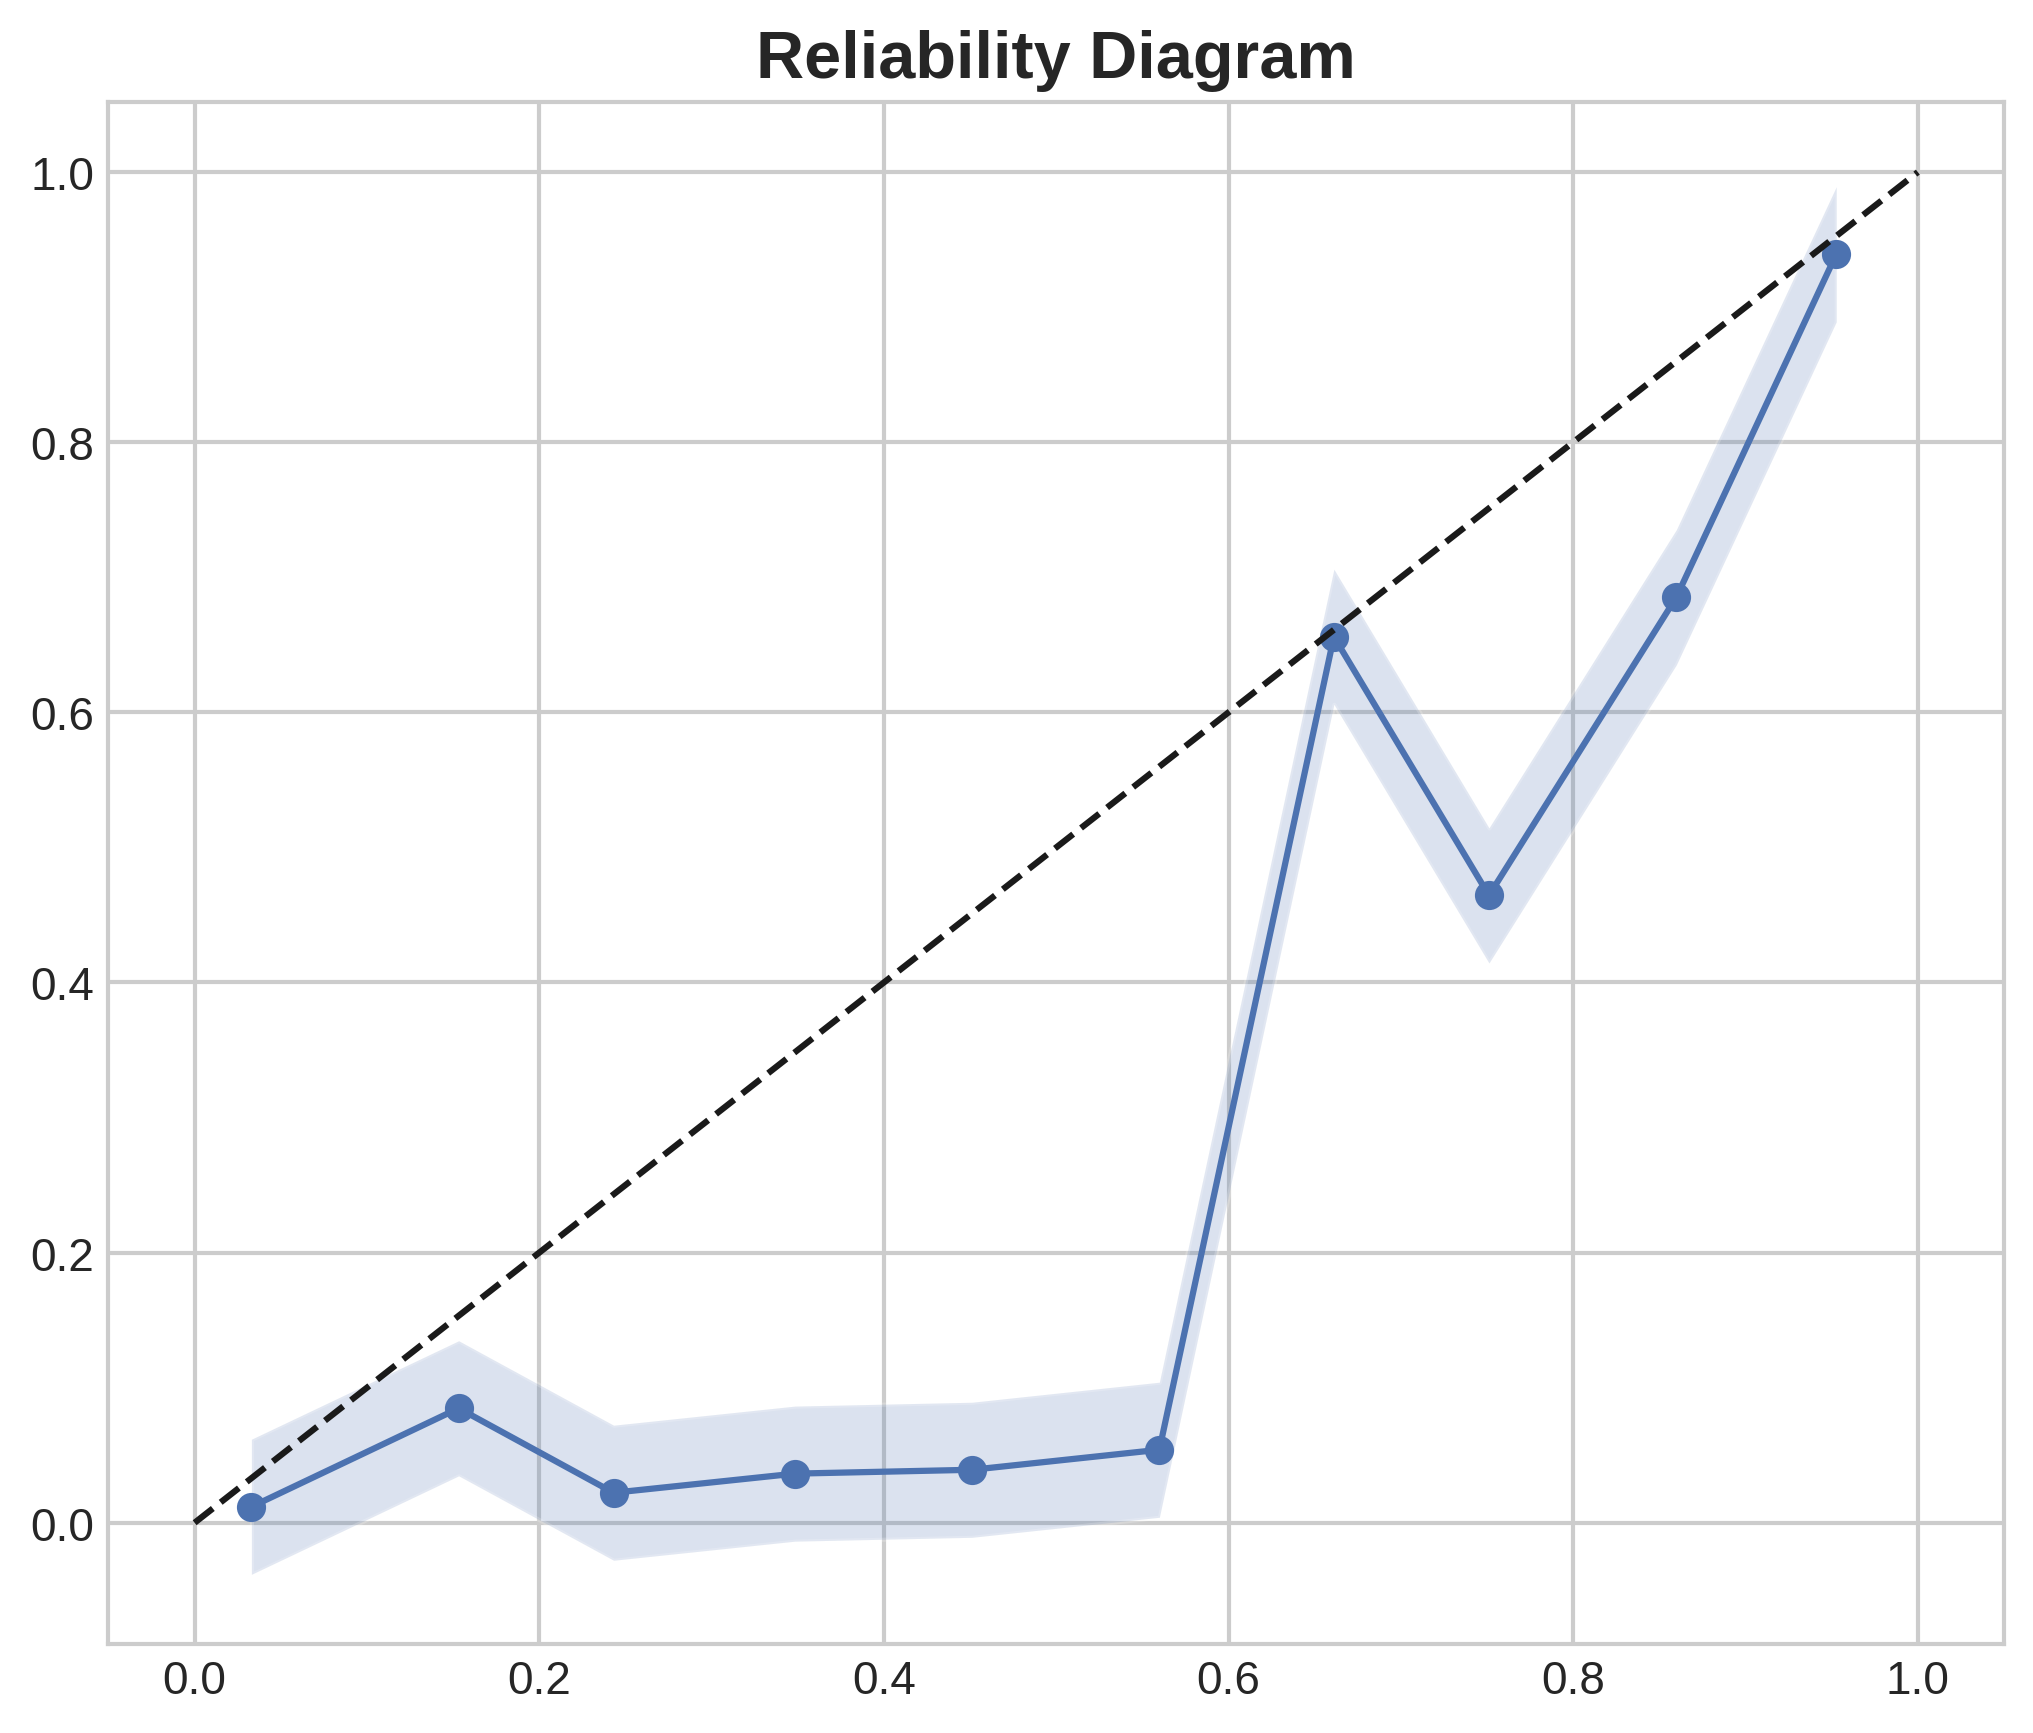

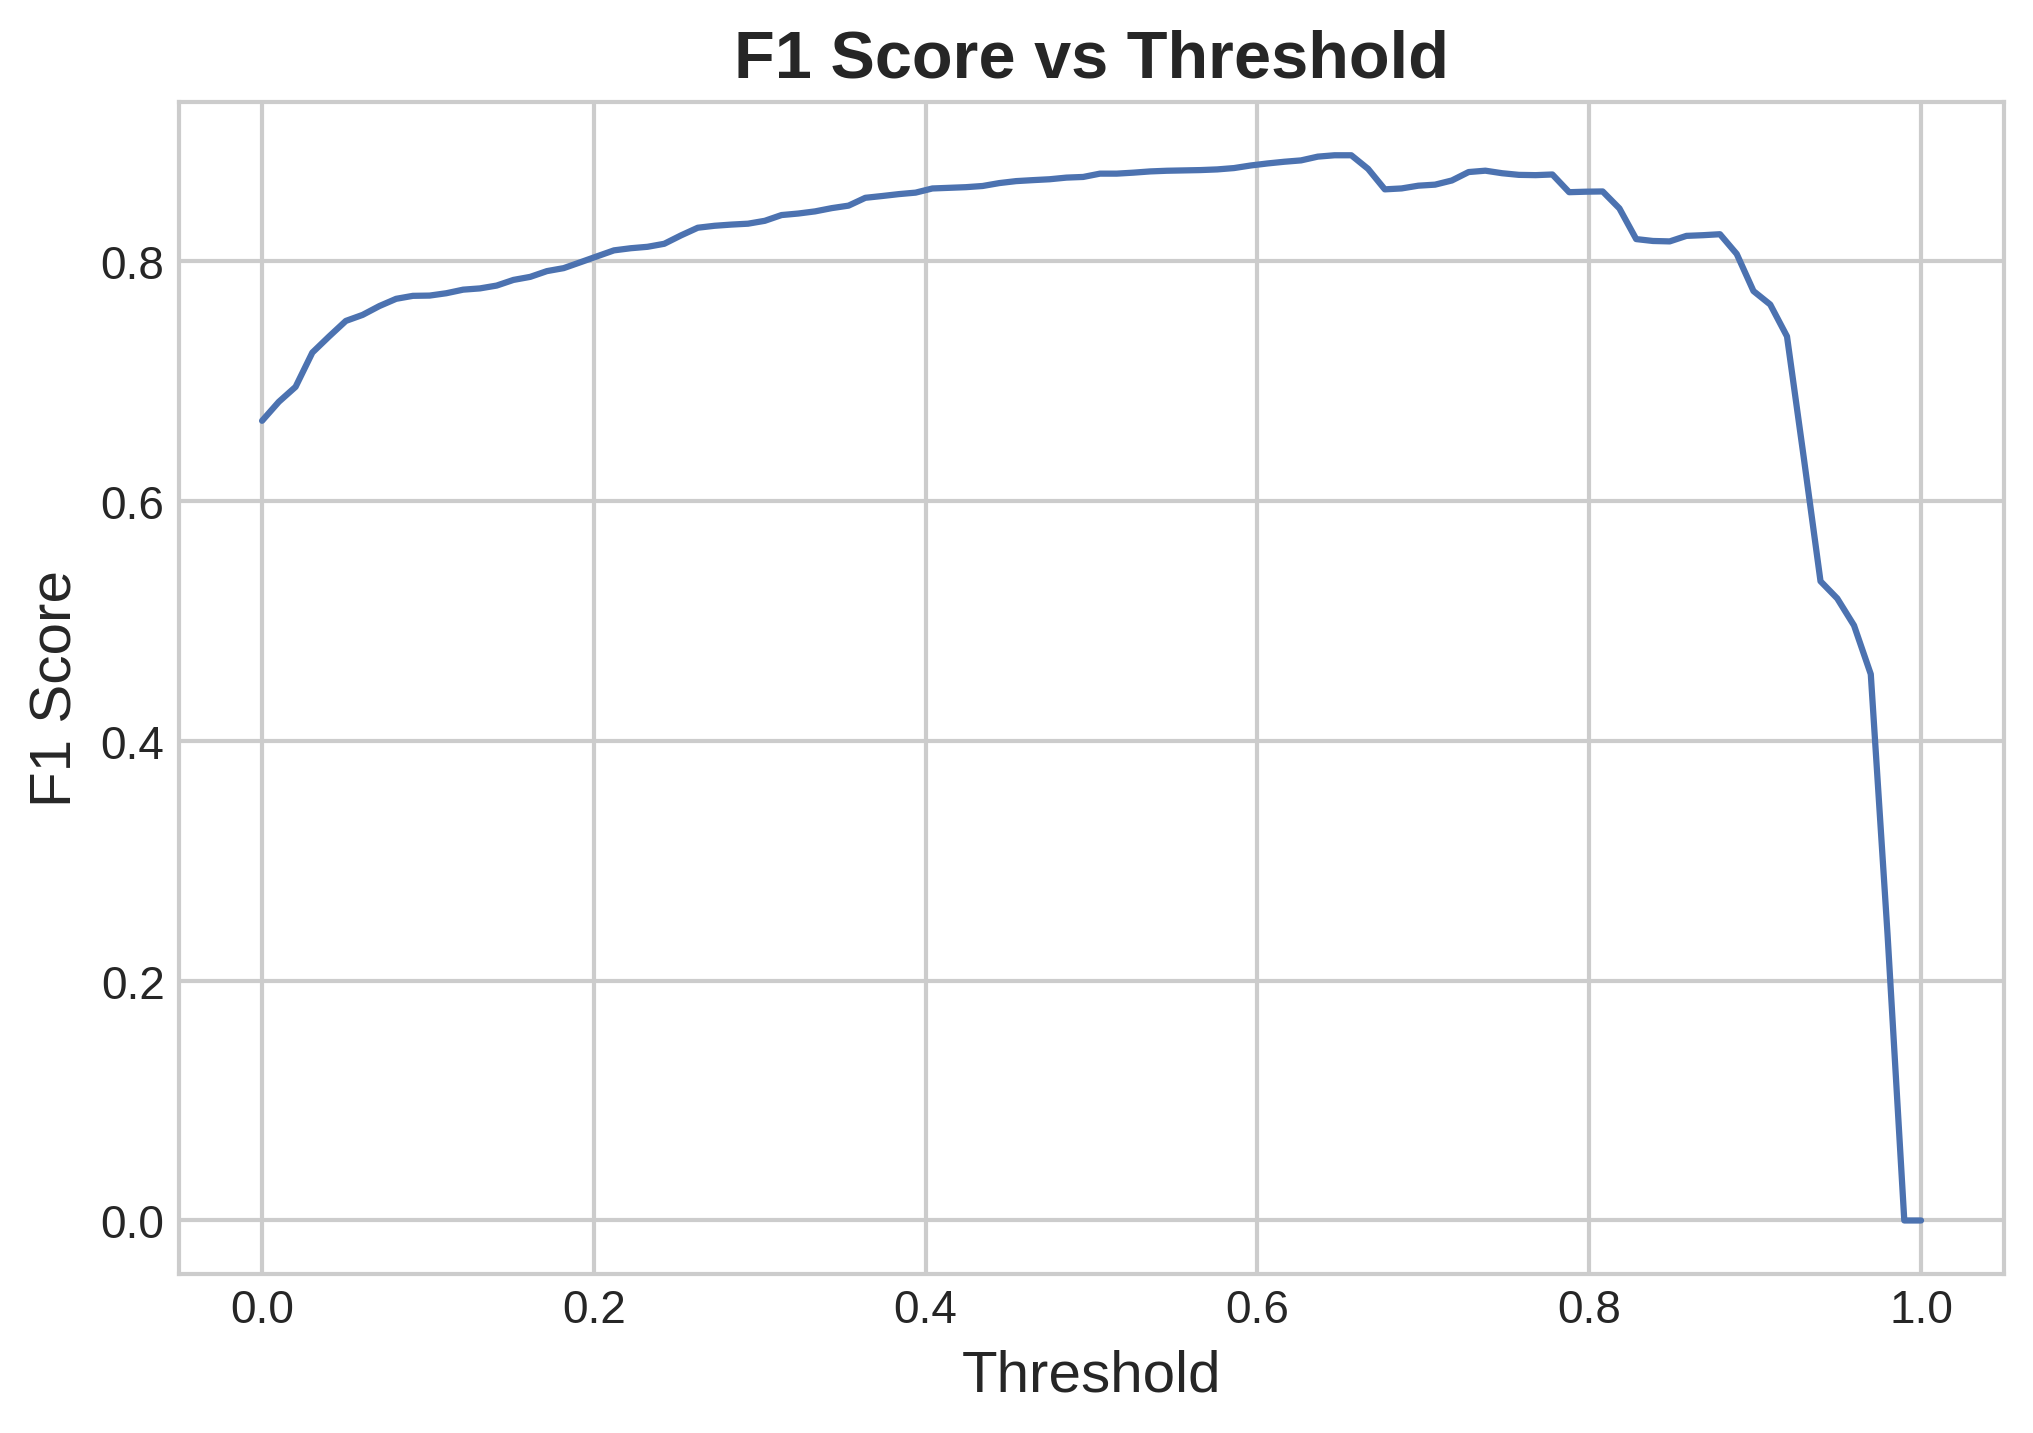

Attention–Gradient Correlation: -0.044592020042888085


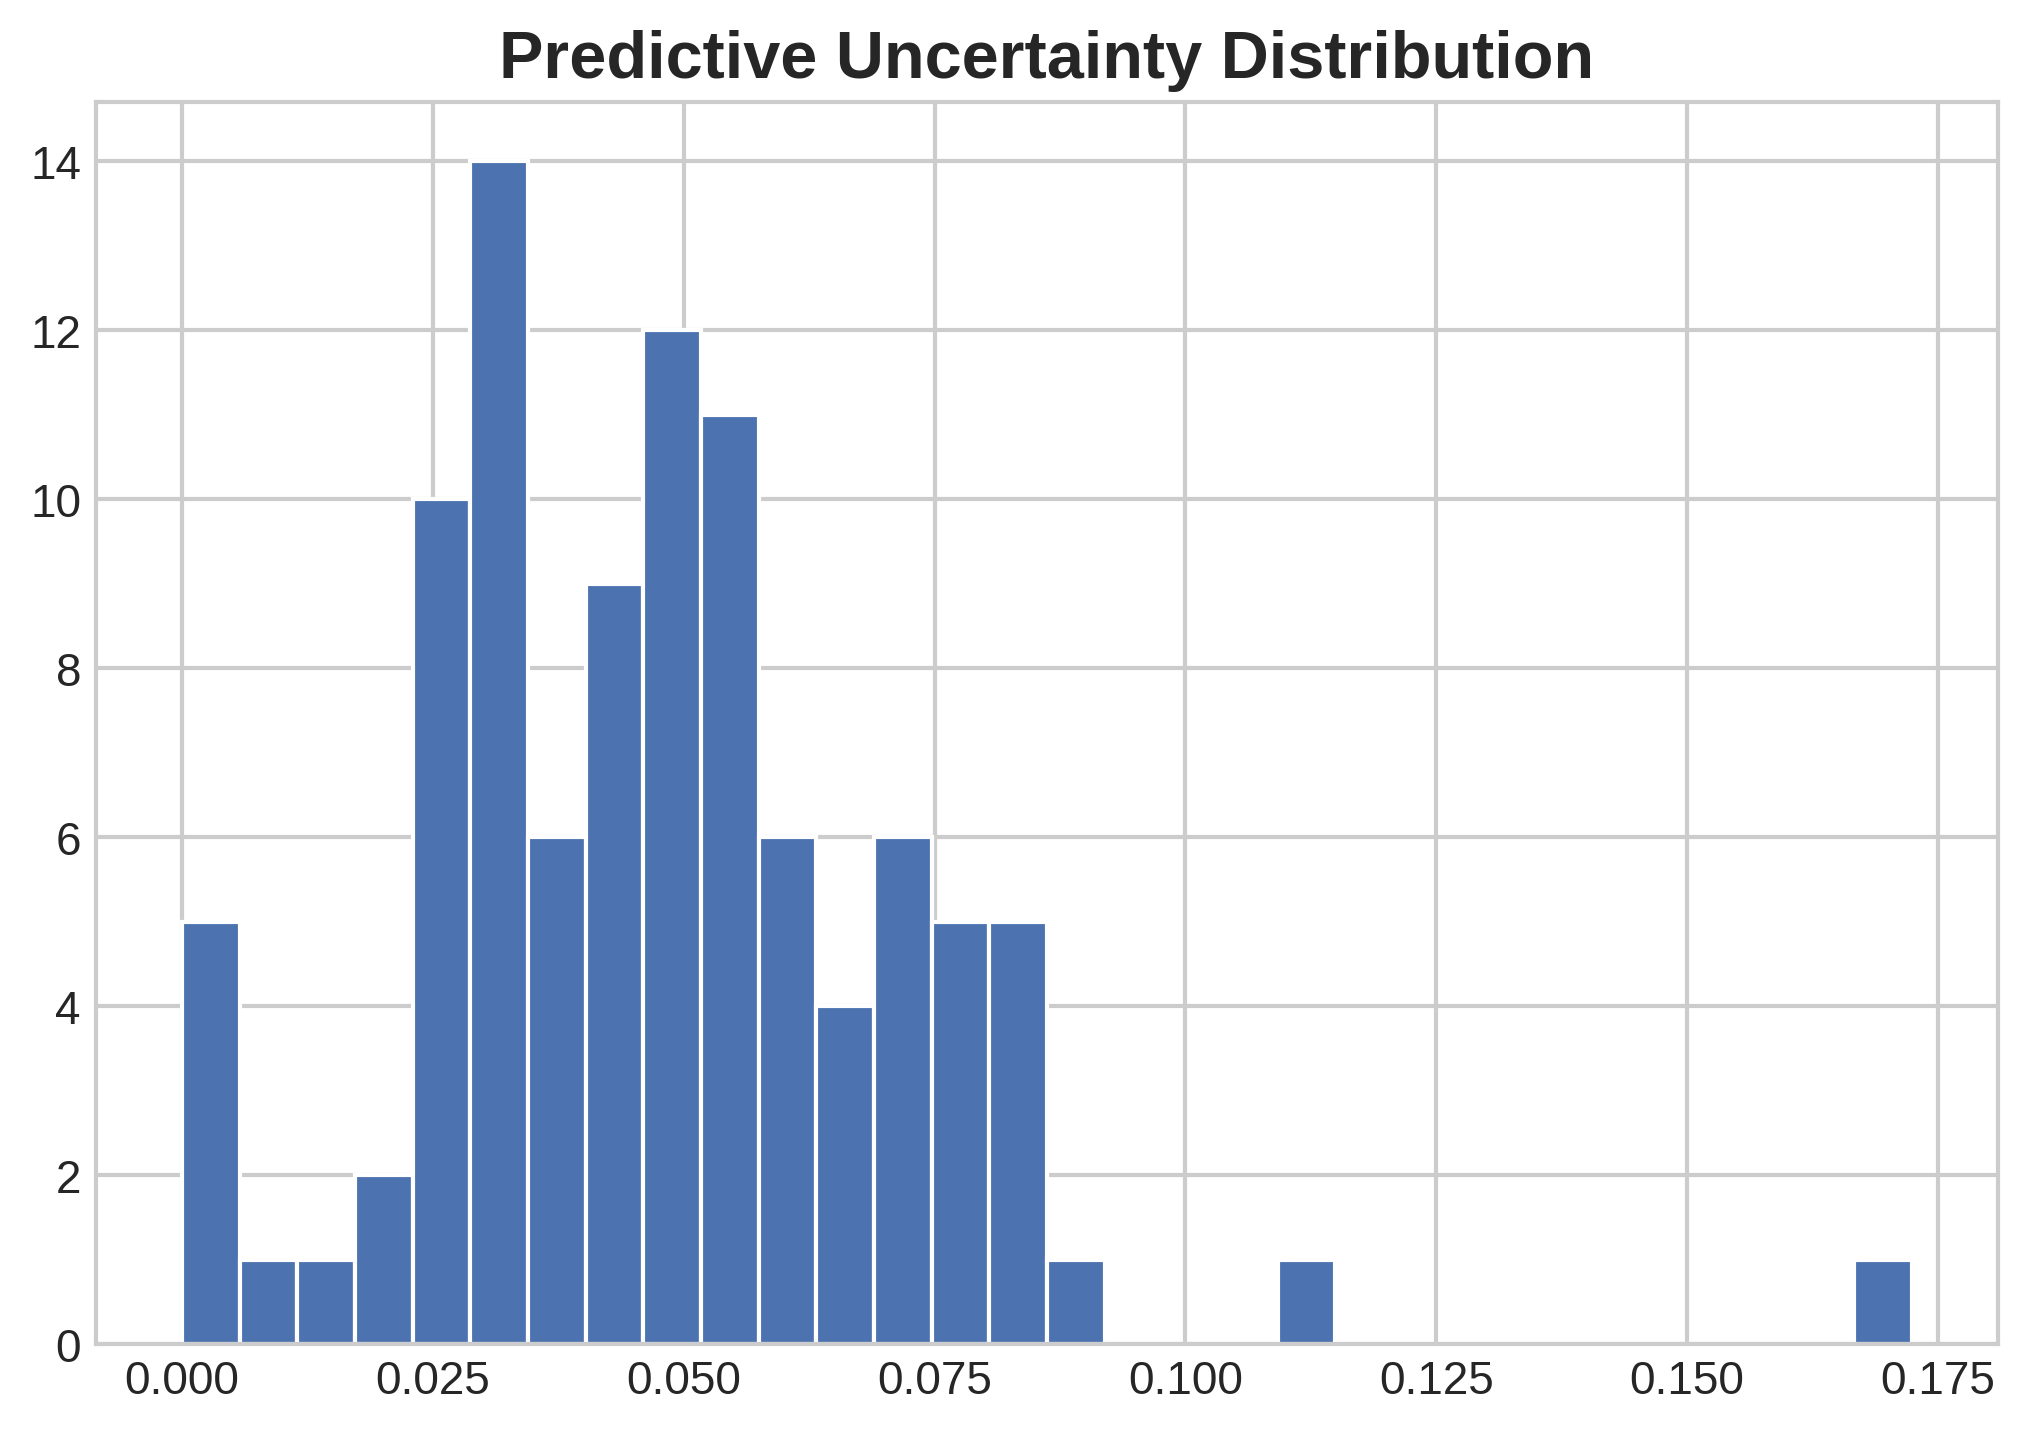

In [ ]:
plt.figure(figsize=(7,5))
sns.kdeplot(y_prob[y_test==0], label="No Hypo")
sns.kdeplot(y_prob[y_test==1], label="Hypo")
plt.title("Predicted Probability Distribution", fontweight="bold")
plt.xlabel("Predicted Risk")
plt.legend()
plt.tight_layout()
plt.savefig("Fig_ProbabilityDist.png", dpi=600)
plt.show()



prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.fill_between(prob_pred,
                 prob_true - 0.05,
                 prob_true + 0.05,
                 alpha=0.2)
plt.plot([0,1],[0,1],'k--')
plt.title("Reliability Diagram", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig_Reliability.png", dpi=600)
plt.show()

thresholds = np.linspace(0,1,100)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores)
plt.title("F1 Score vs Threshold", fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.savefig("Fig_F1_vs_Threshold.png", dpi=600)
plt.show()

corr = np.corrcoef(weights.flatten(),
                   importance.flatten())[0,1]

print("Attention–Gradient Correlation:", corr)


def mc_dropout_predict(model, X, n_samples=30):
    preds = []
    for _ in range(n_samples):
        preds.append(model(X, training=True).numpy())
    return np.mean(preds, axis=0), np.std(preds, axis=0)

mean_pred, std_pred = mc_dropout_predict(model_tcn, X_test_t[:100])

plt.figure(figsize=(7,5))
plt.hist(std_pred, bins=30)
plt.title("Predictive Uncertainty Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig_Uncertainty.png", dpi=600)
plt.show()

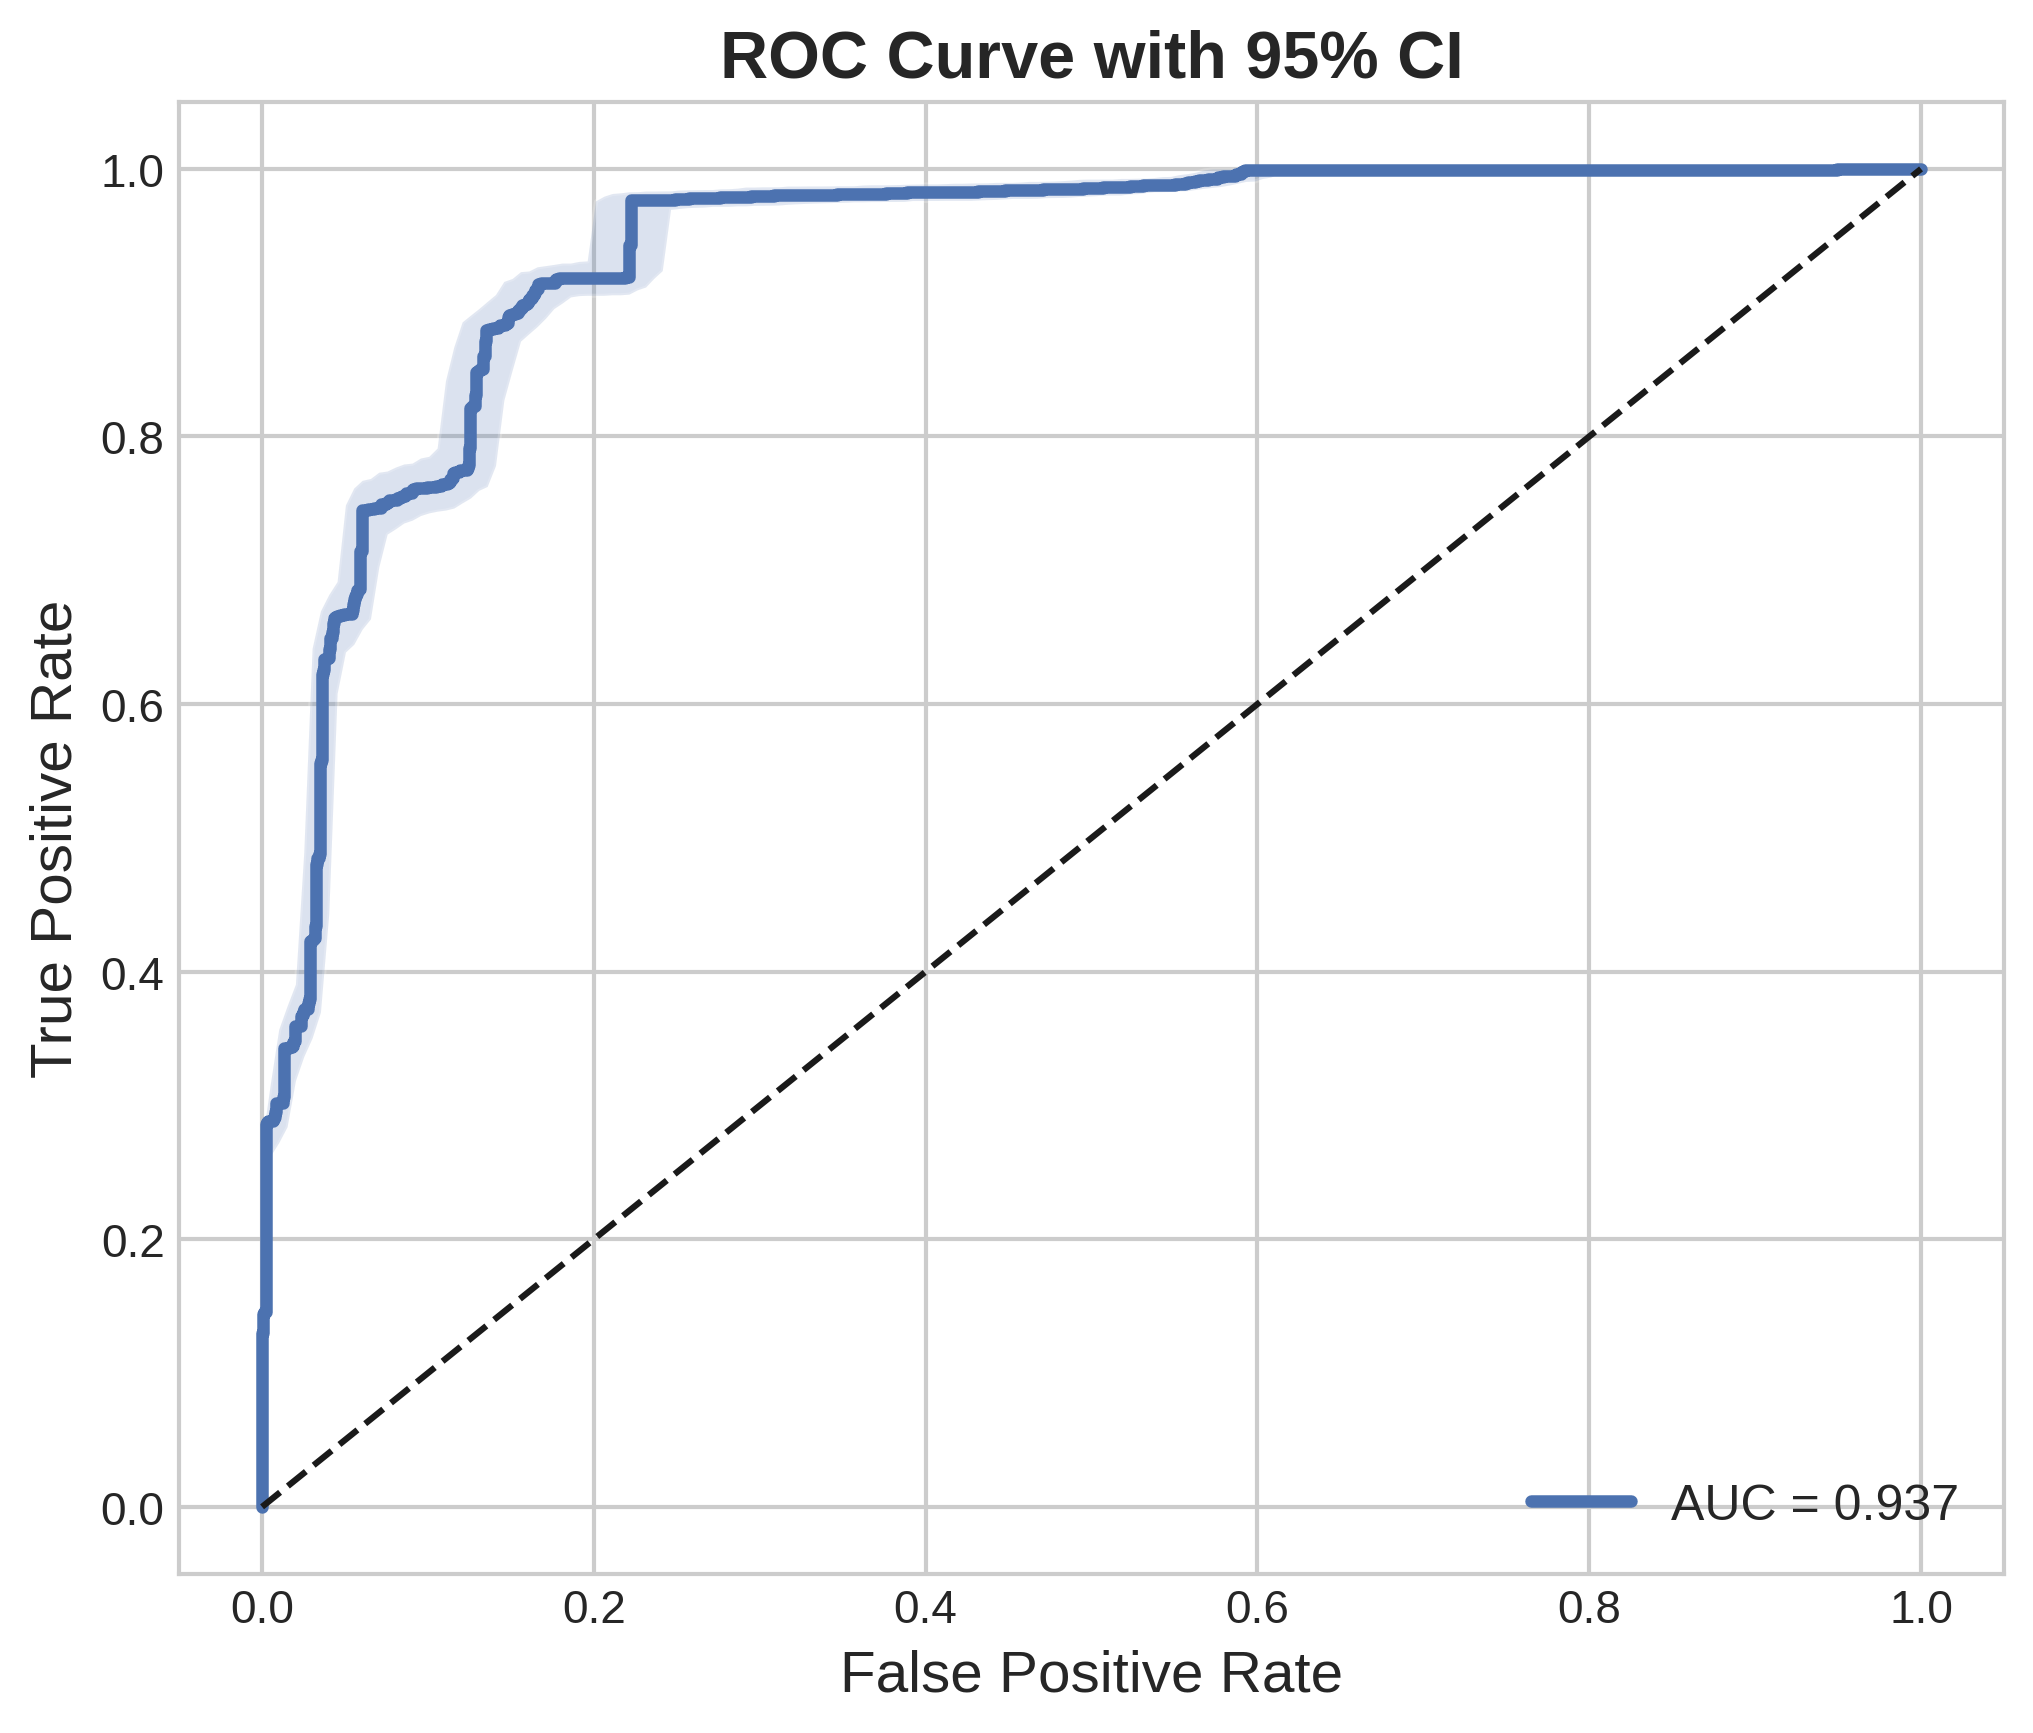

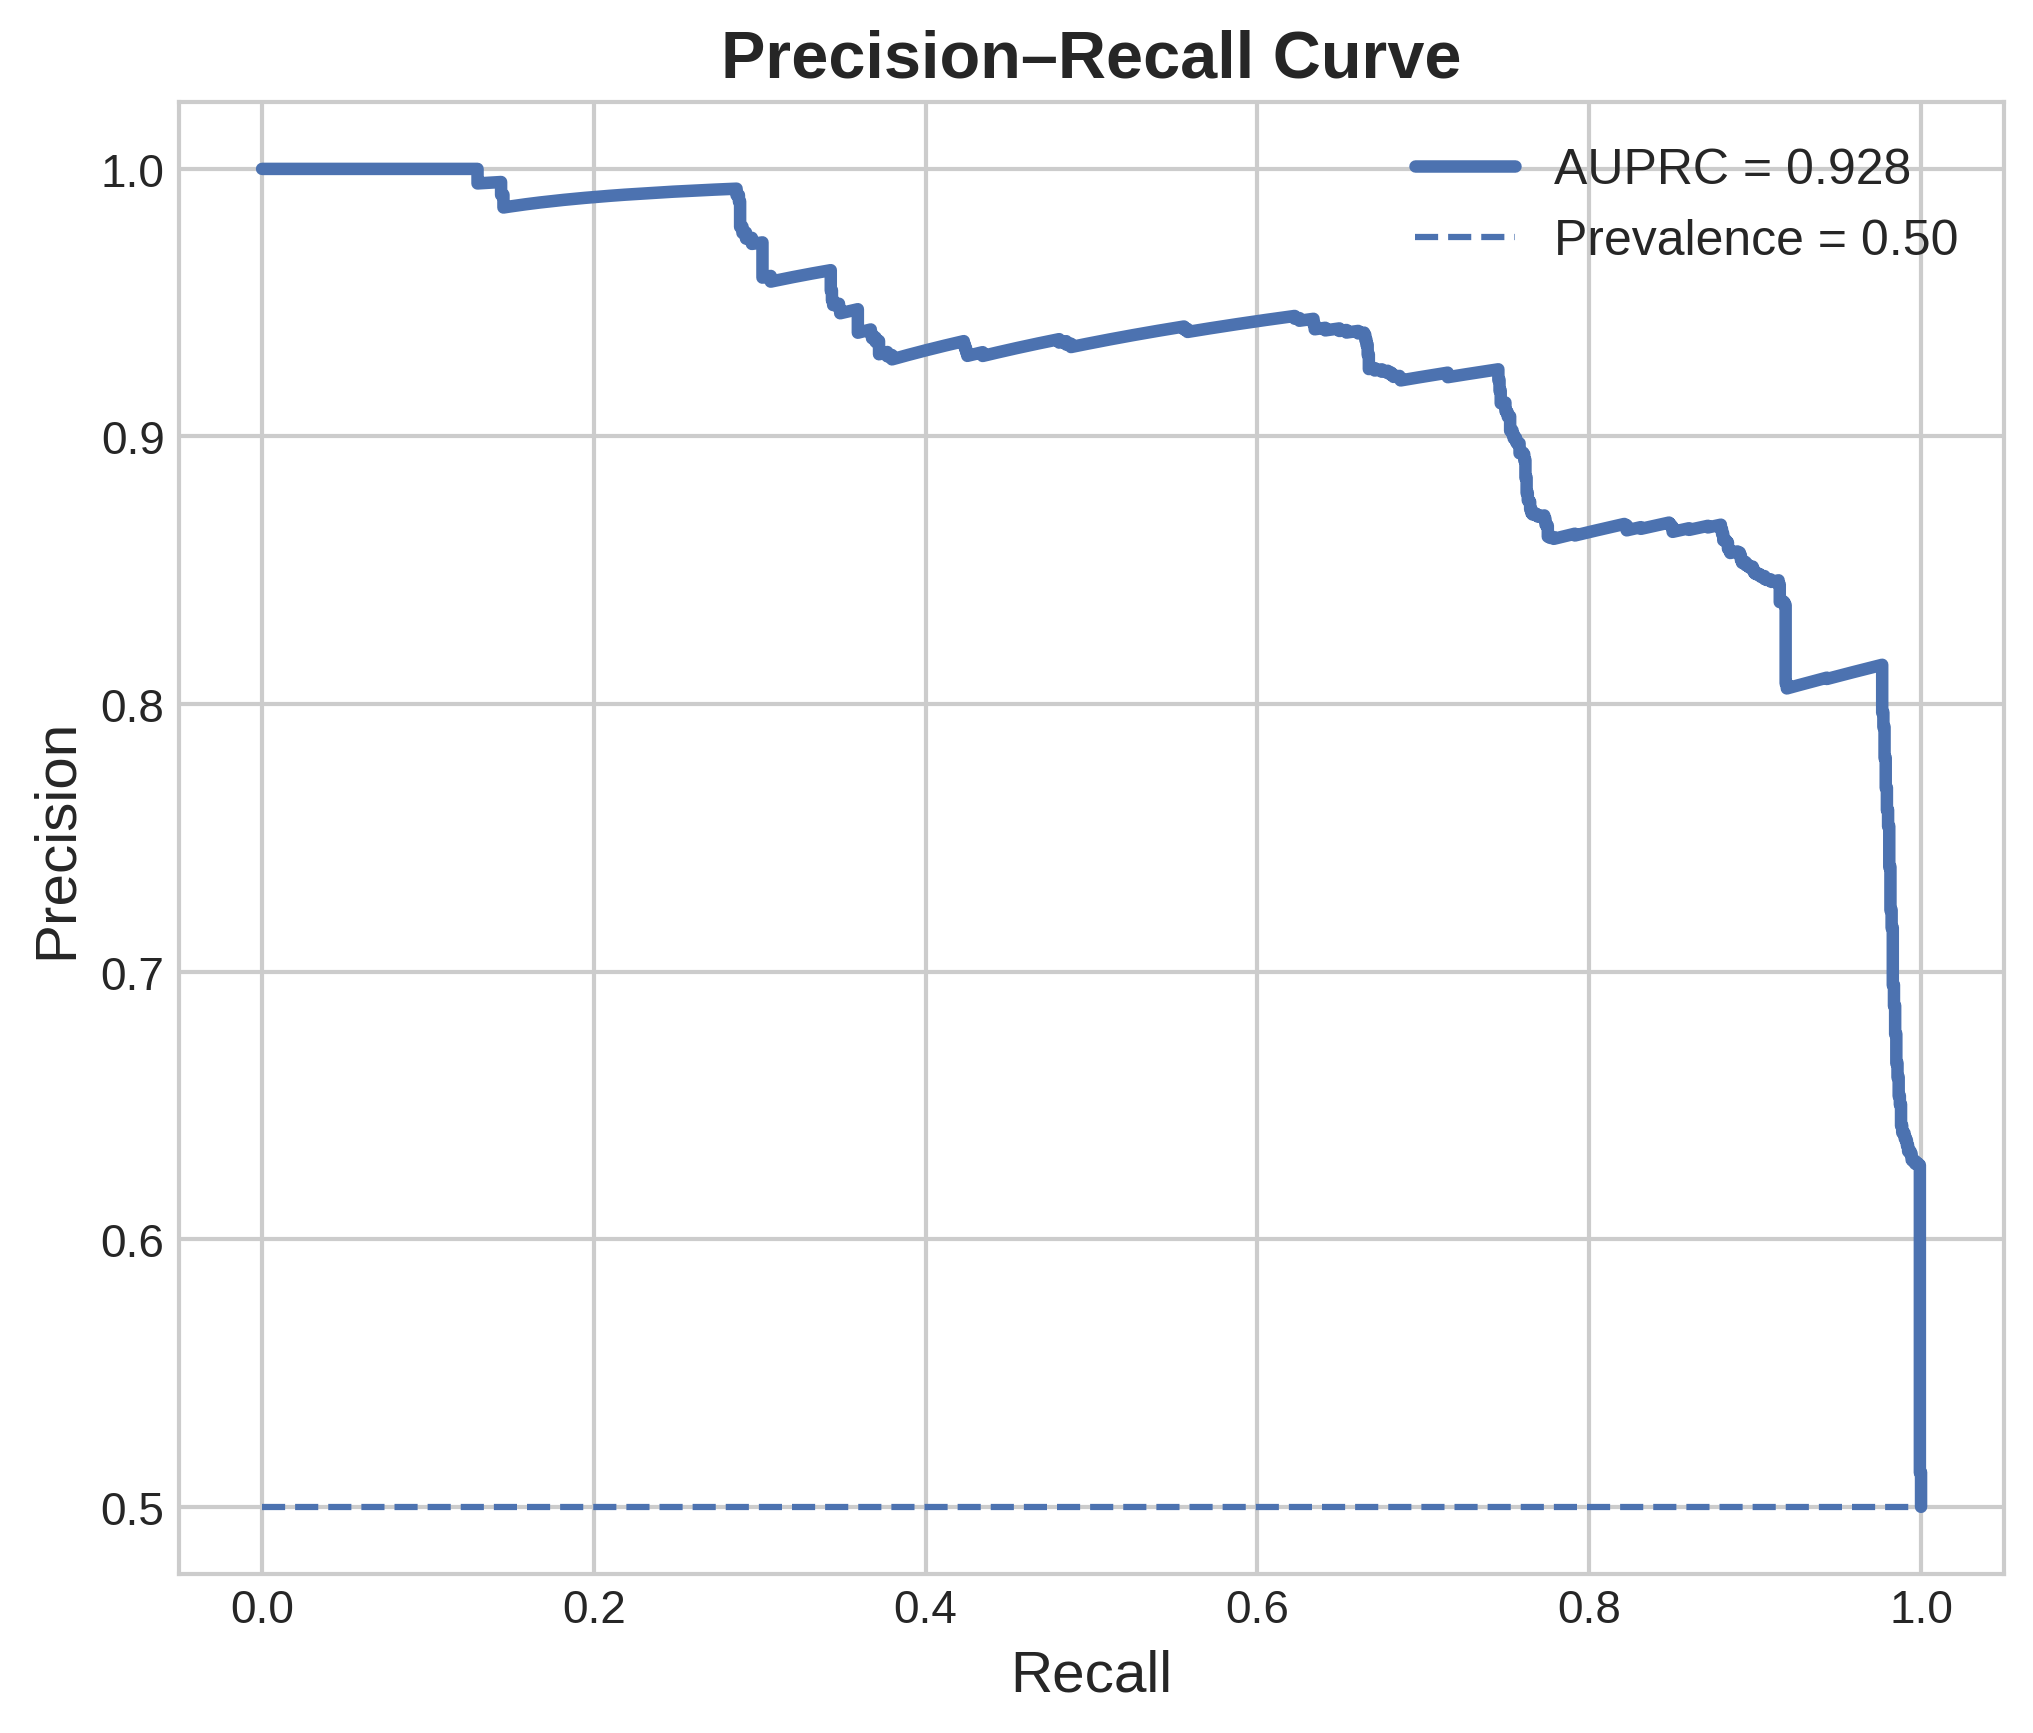

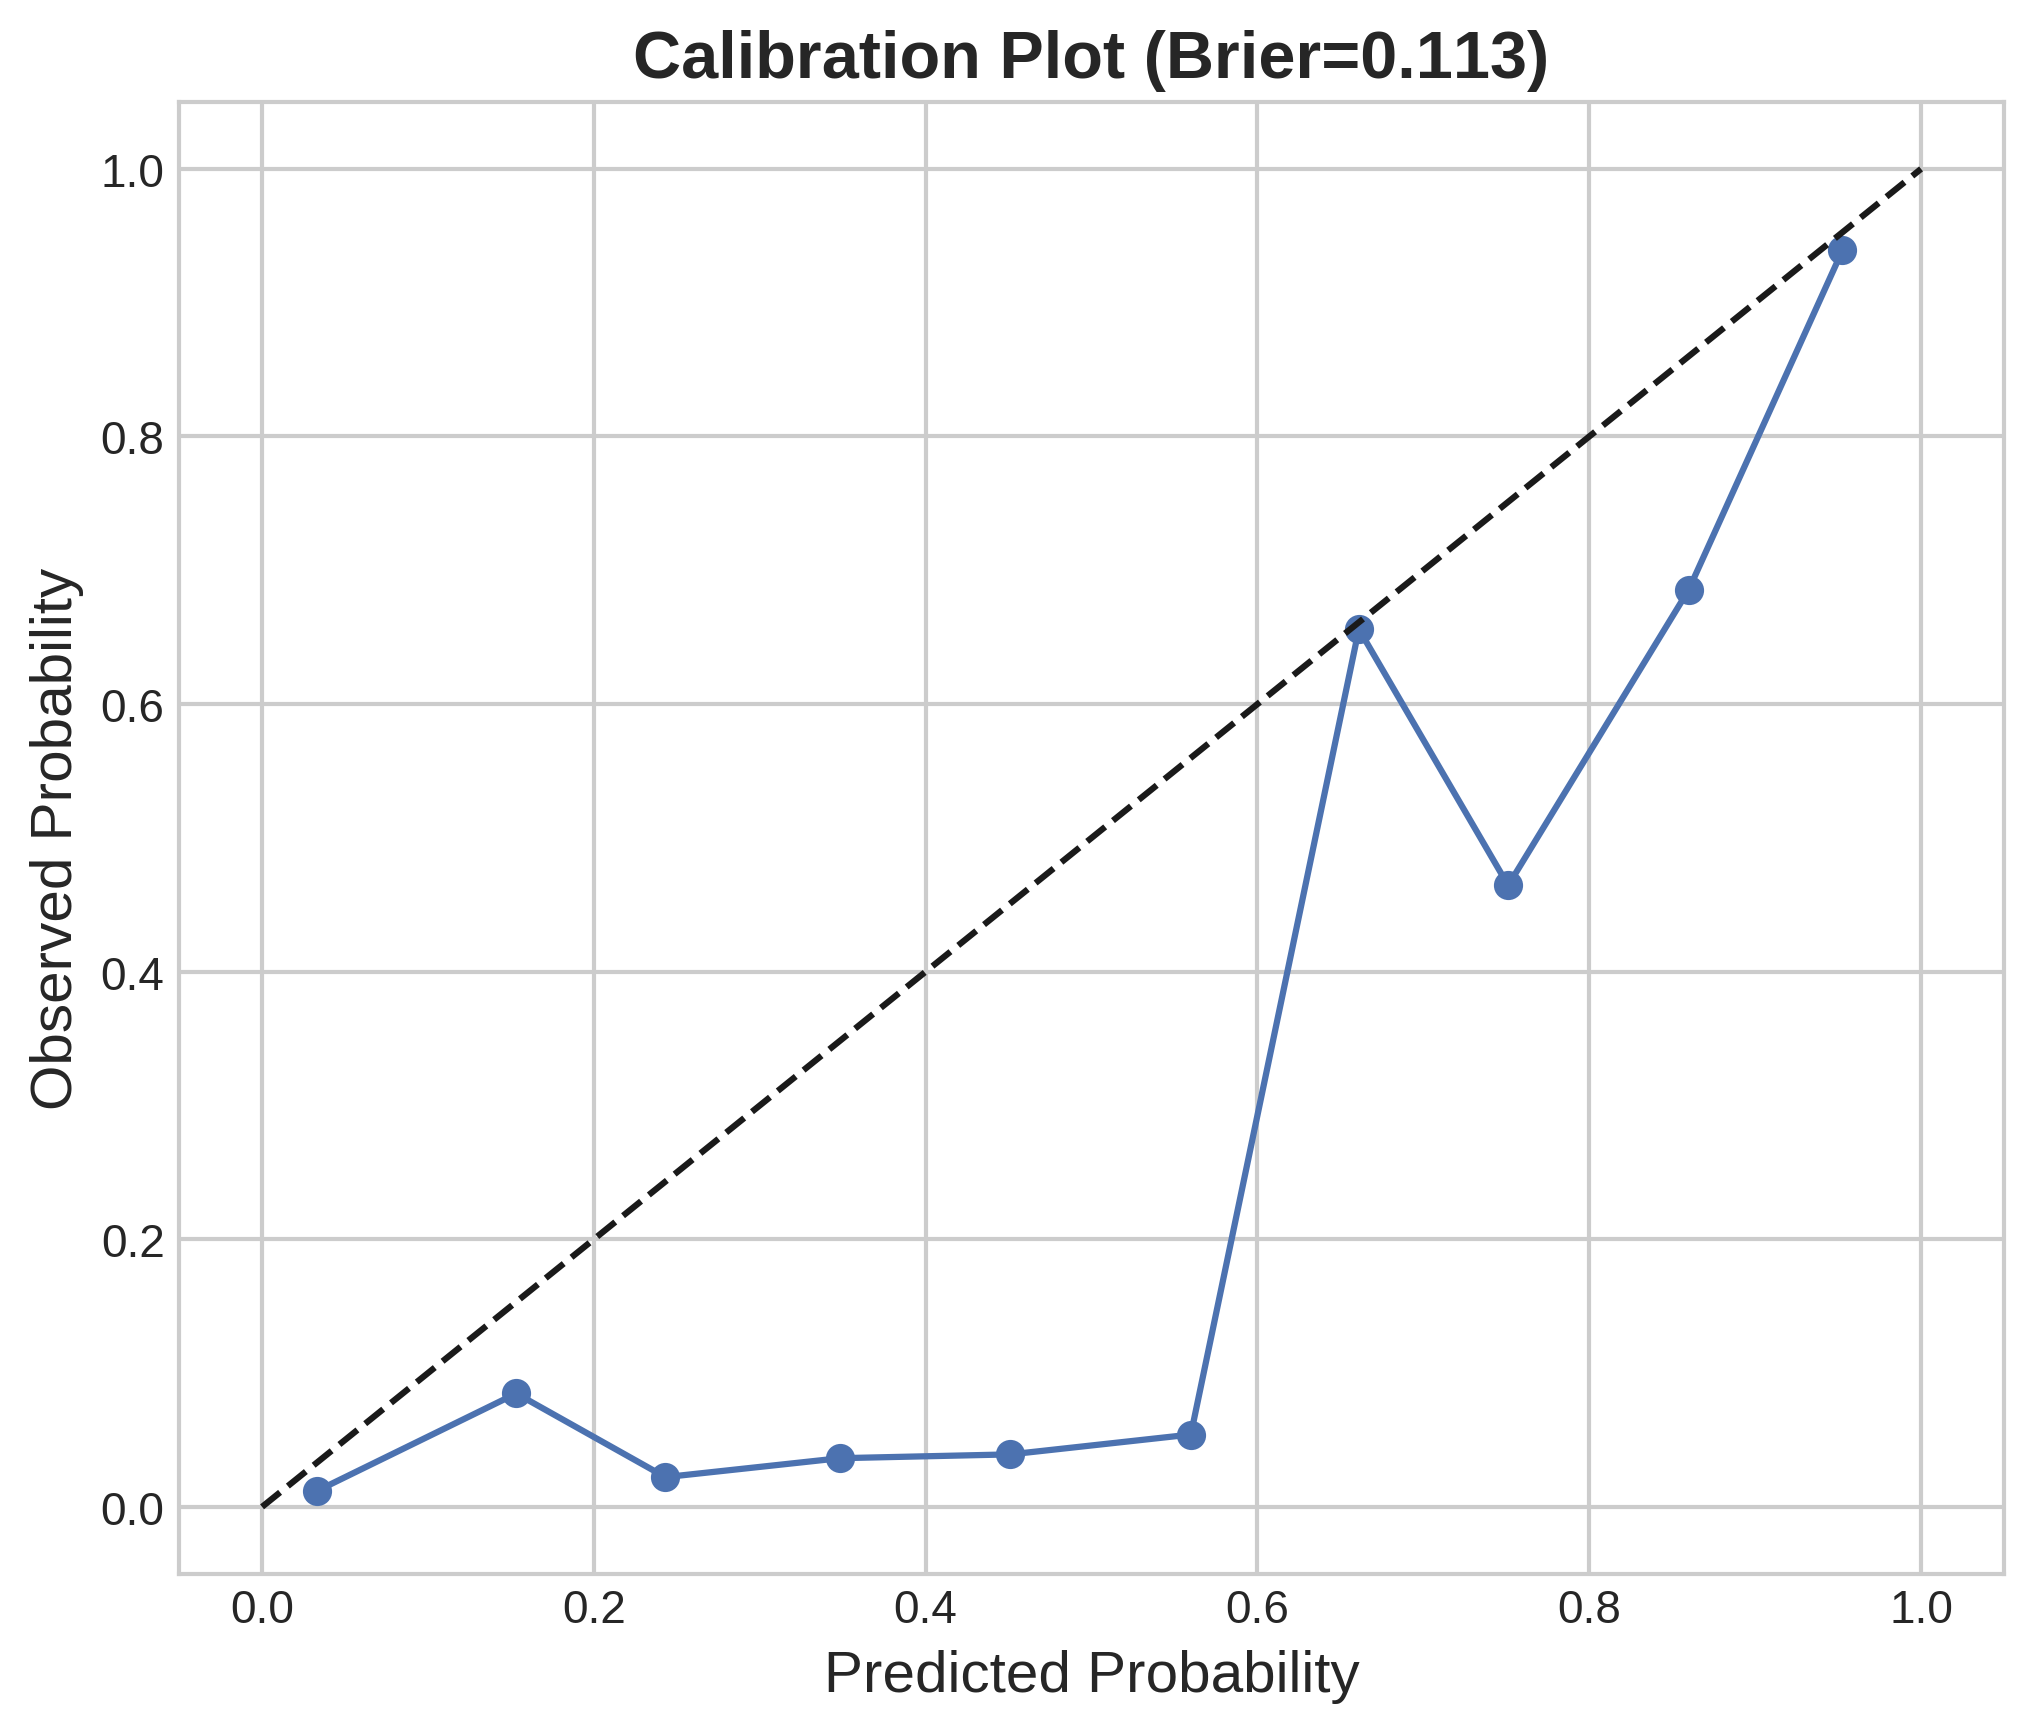

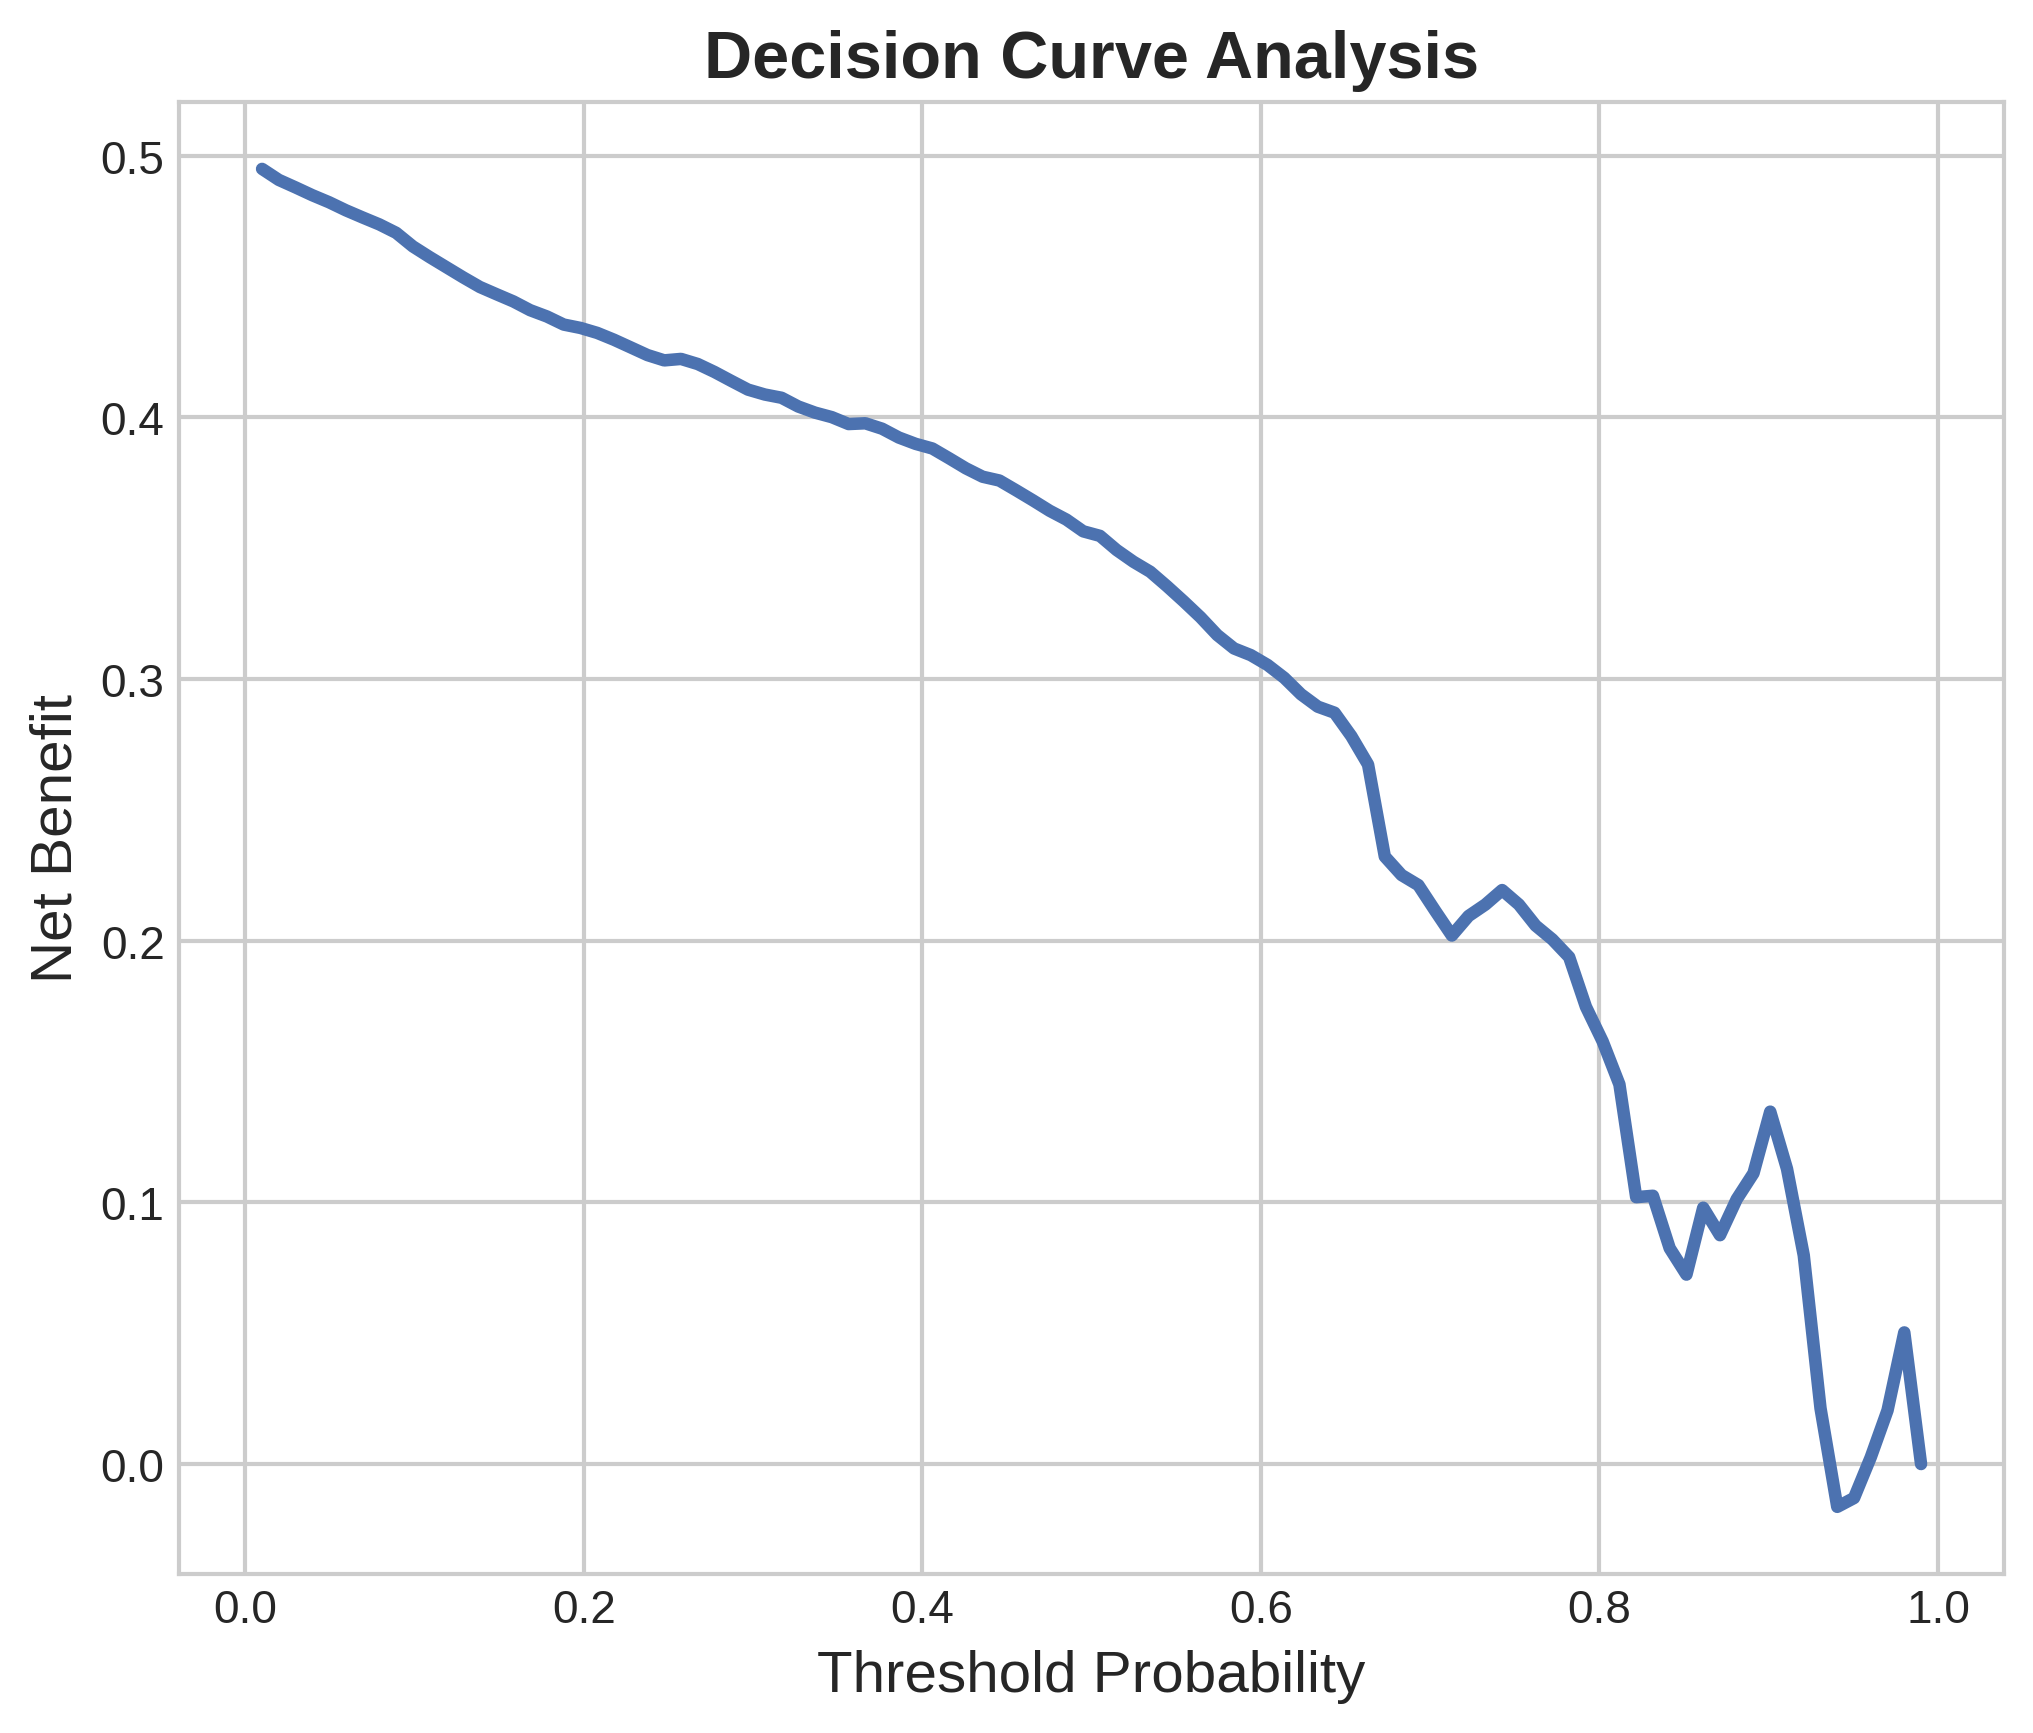

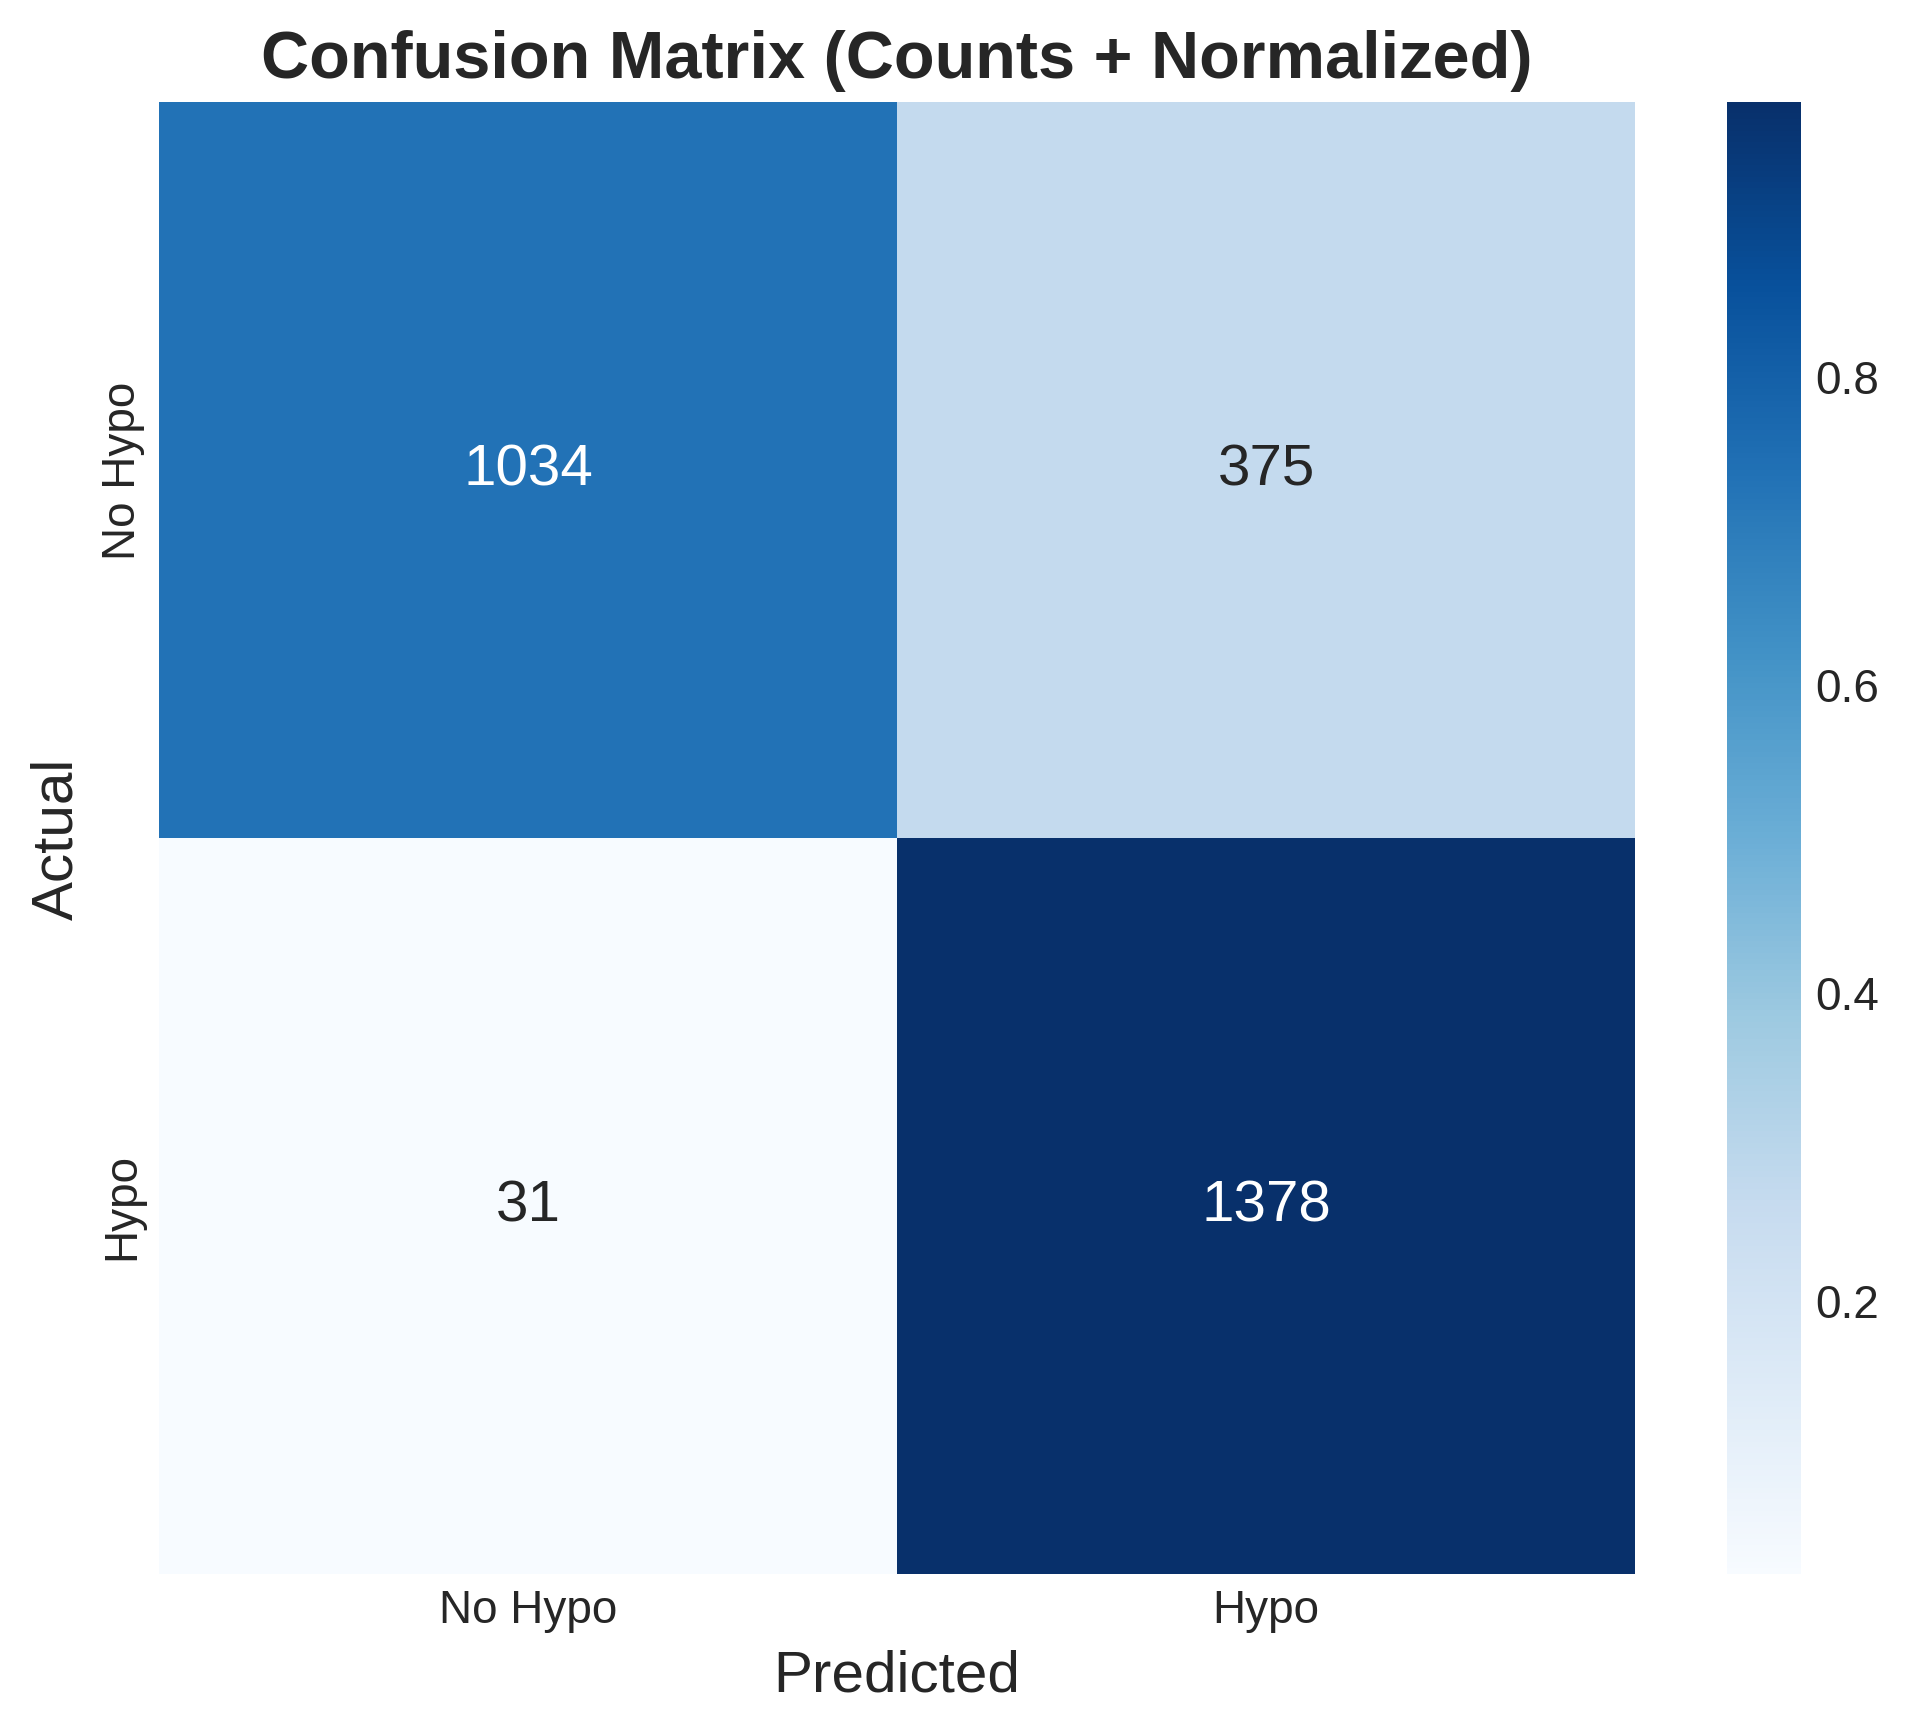

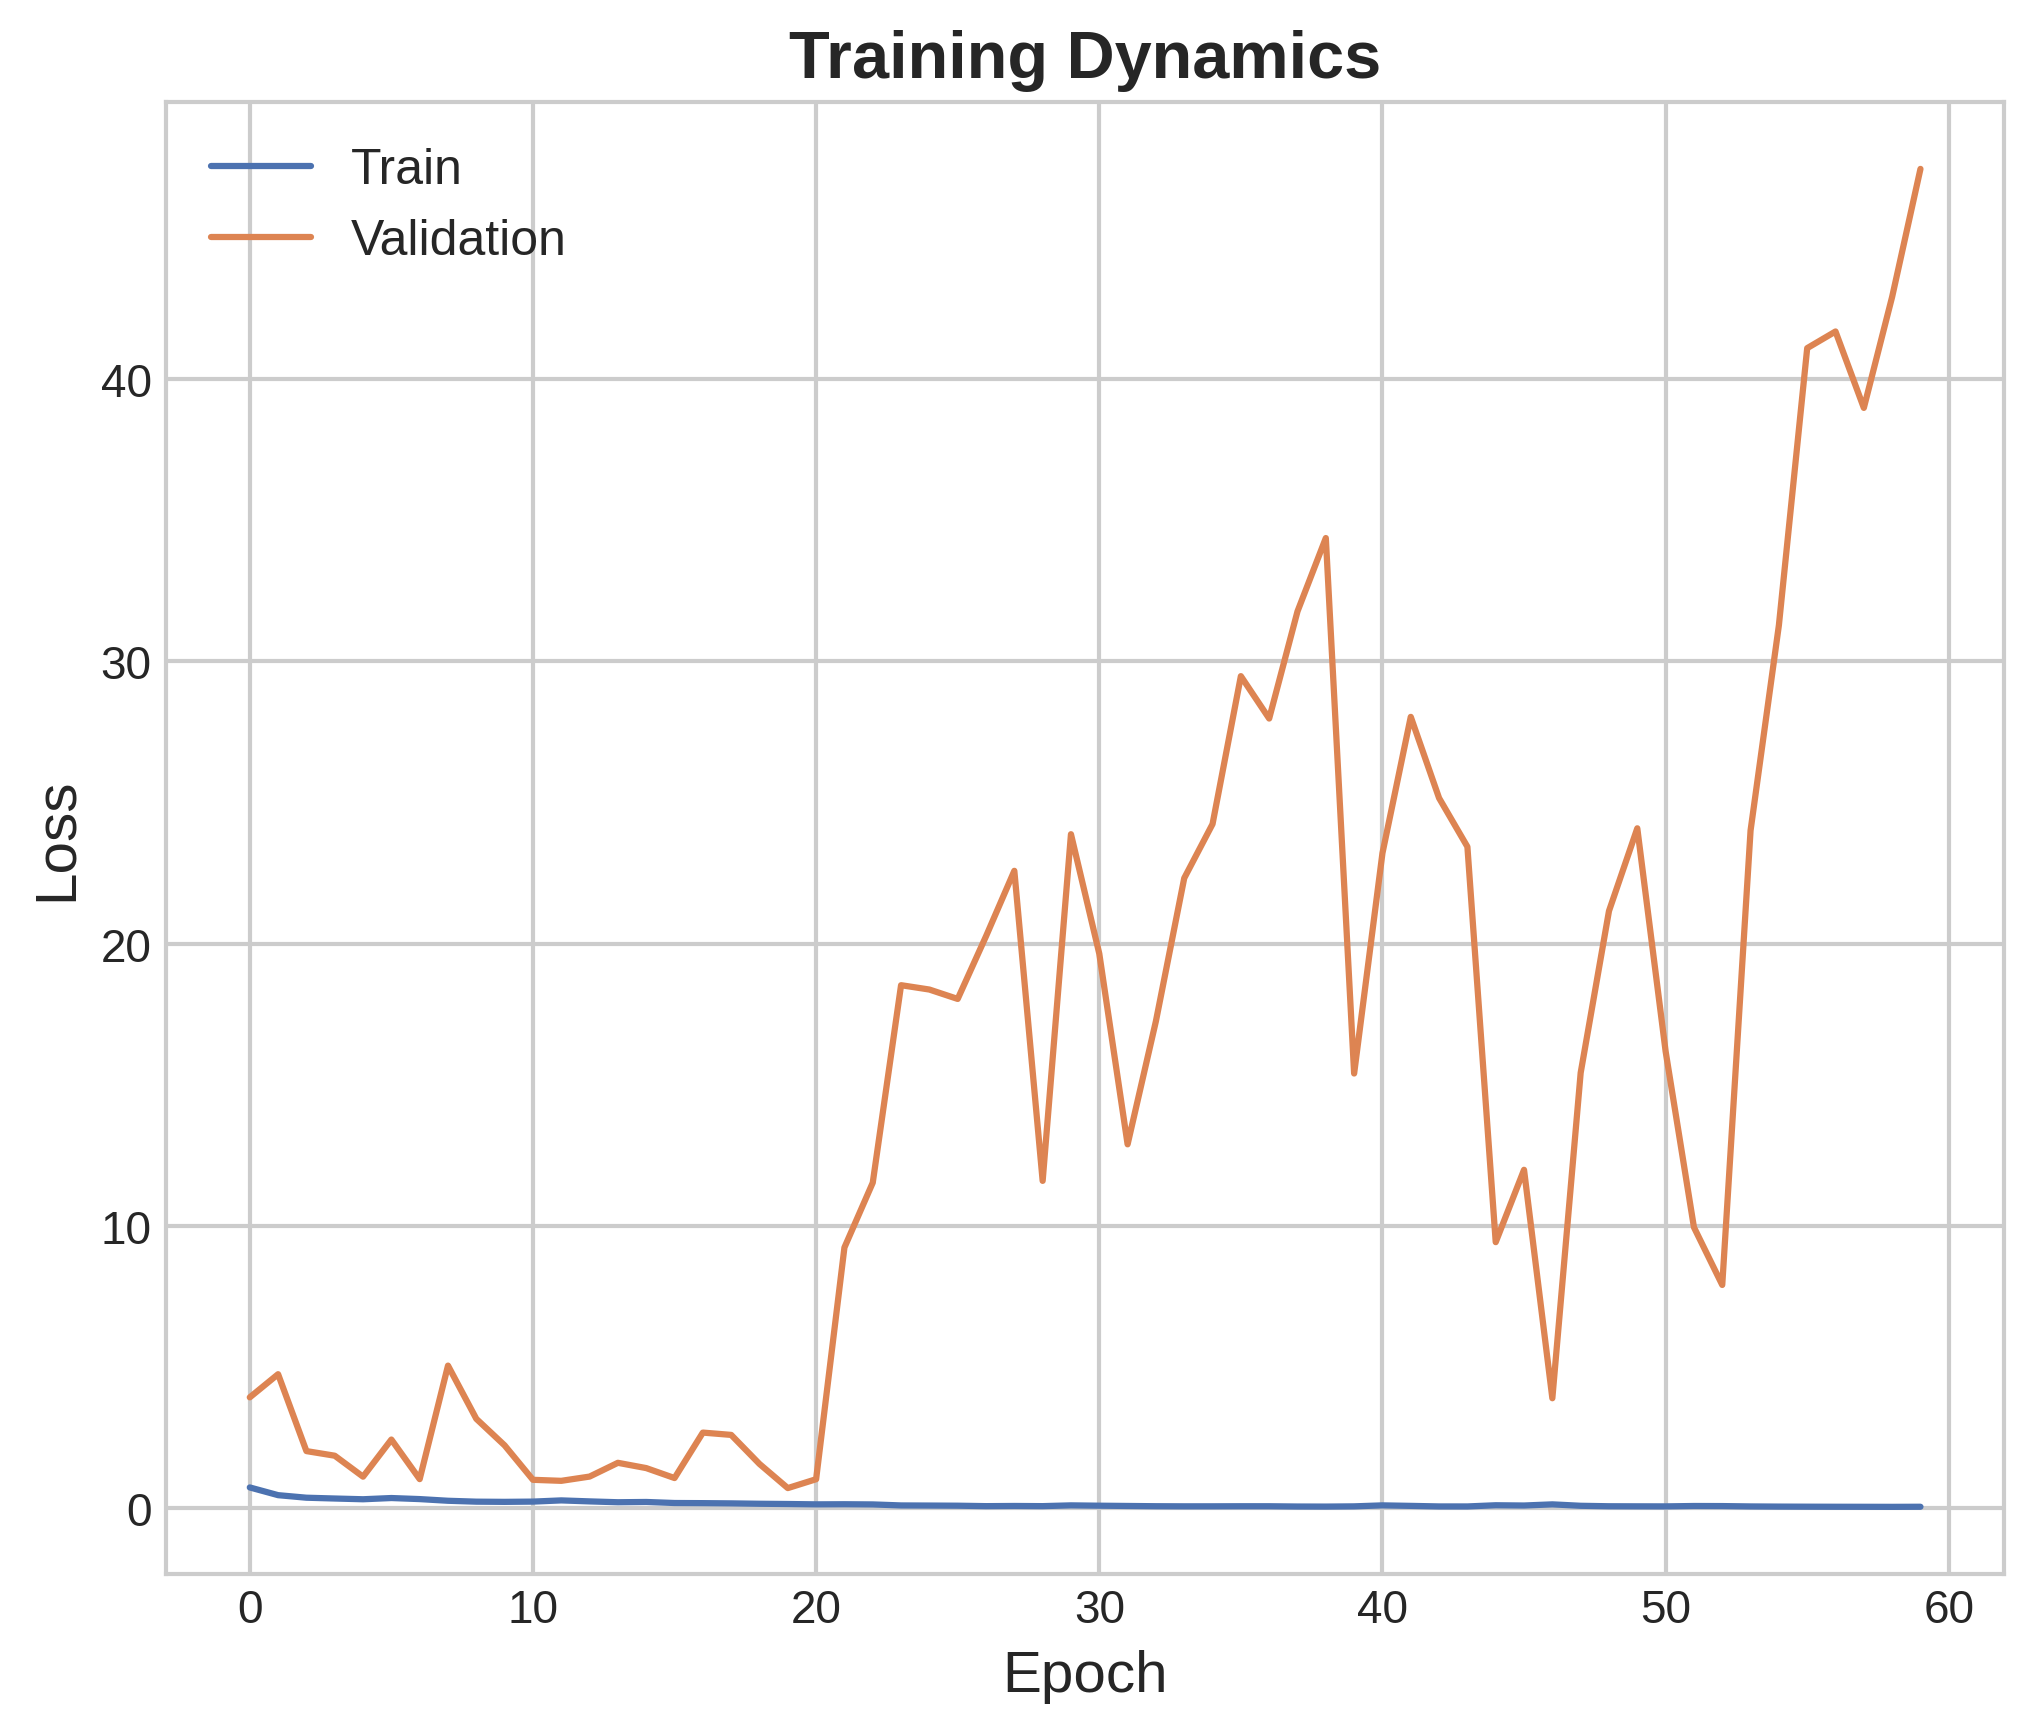

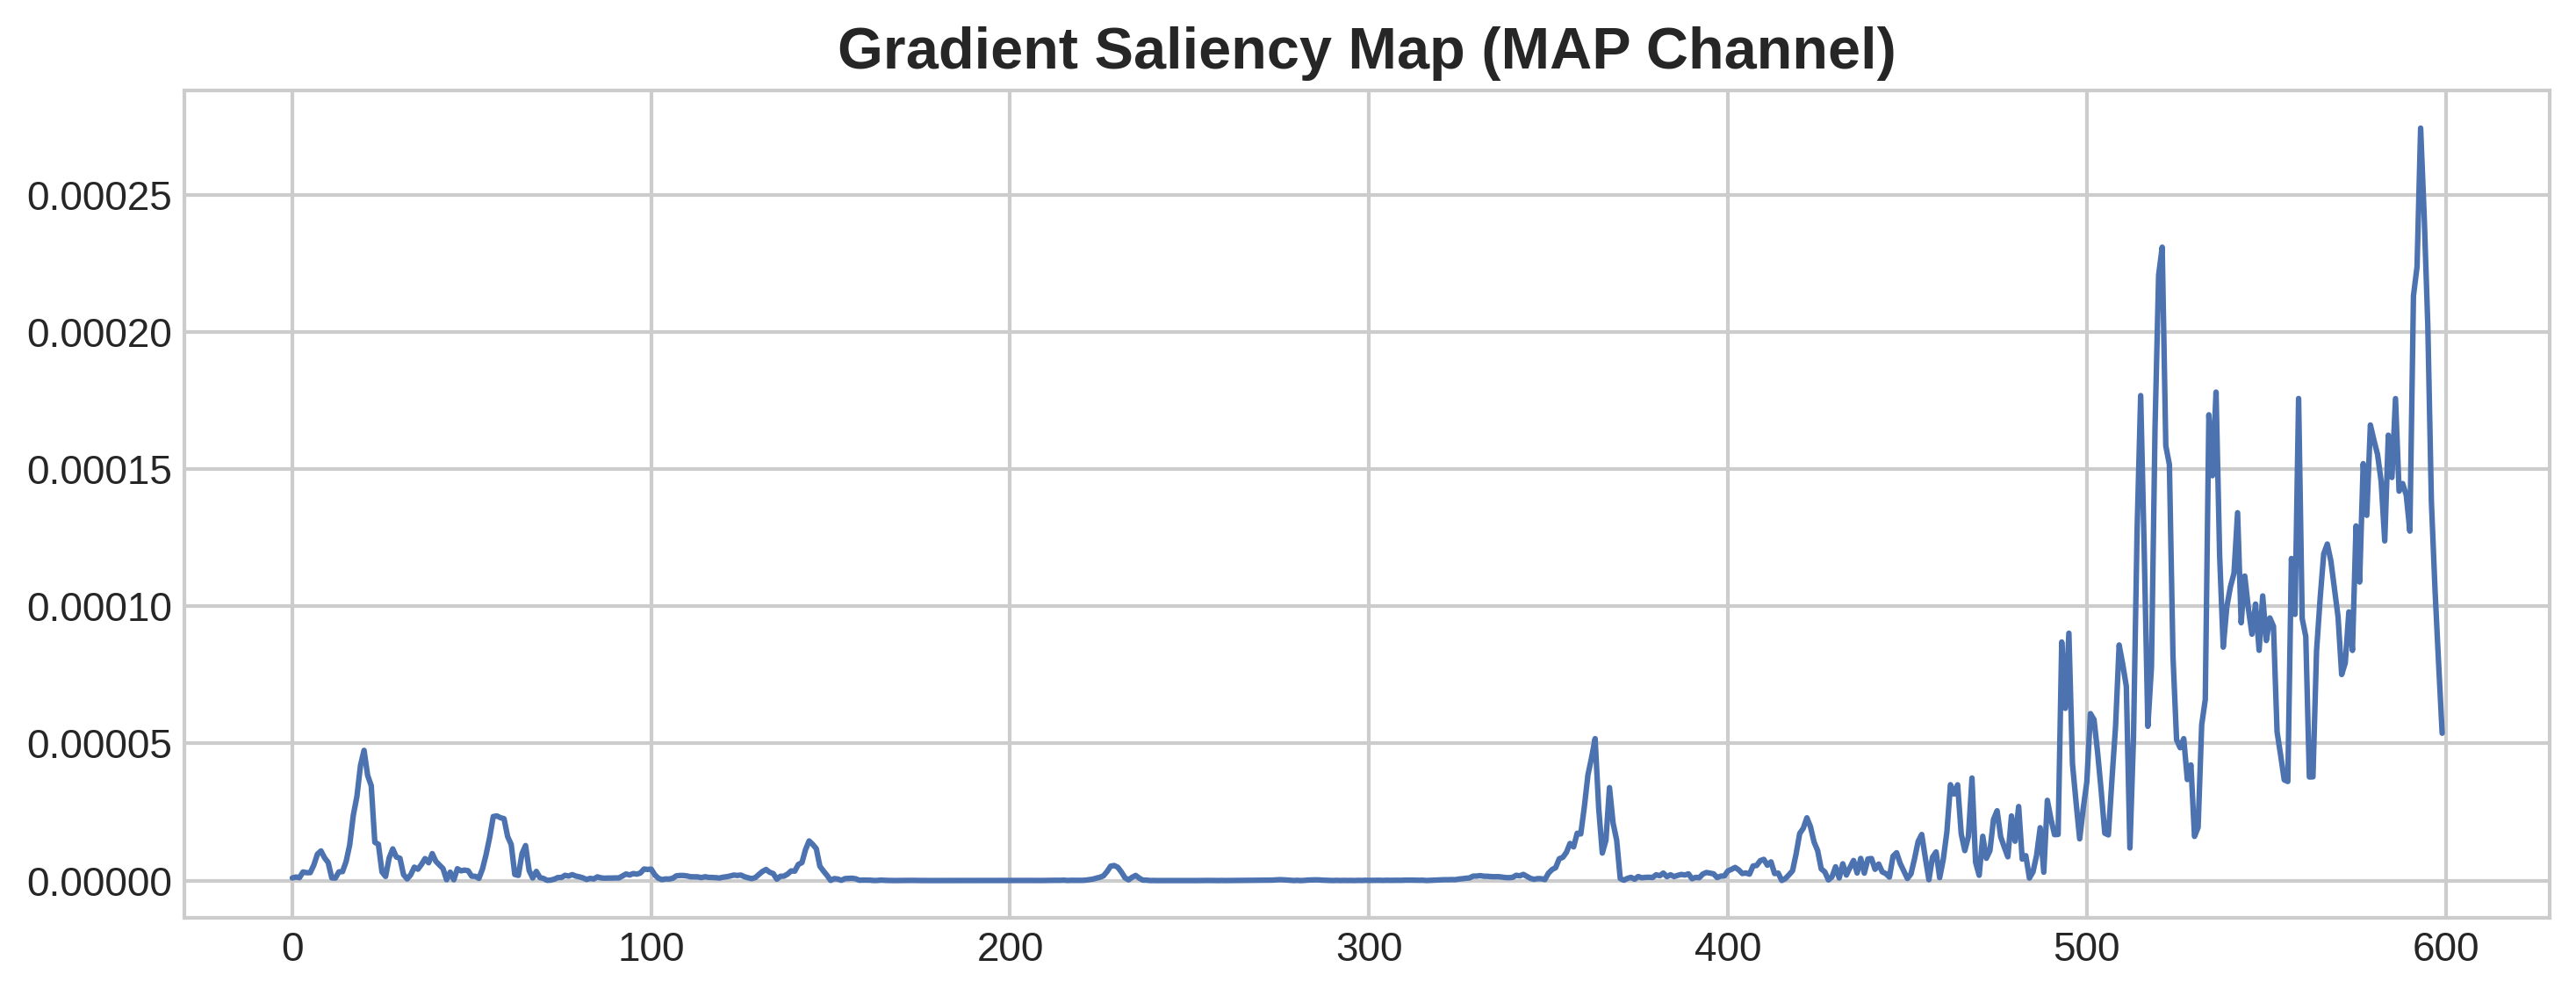

All high-end manuscript figures generated and saved (600 DPI).


In [ ]:
# ============================================================
# HIGH-END TECHNICAL FIGURES FOR MANUSCRIPT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, roc_auc_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
import tensorflow as tf

# ------------------------------------------------------------
# GLOBAL STYLING
# ------------------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "figure.figsize": (7, 6)
})

# ------------------------------------------------------------
# 1️⃣ ROC Curve with Bootstrapped Confidence Band
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Bootstrapping
n_bootstraps = 300
boot_tprs = []
mean_fpr = np.linspace(0, 1, 200)

for i in range(n_bootstraps):
    idx = resample(np.arange(len(y_test)))
    if len(np.unique(y_test[idx])) < 2:
        continue
    fpr_i, tpr_i, _ = roc_curve(y_test[idx], y_prob[idx])
    tpr_interp = np.interp(mean_fpr, fpr_i, tpr_i)
    boot_tprs.append(tpr_interp)

boot_tprs = np.array(boot_tprs)
tpr_lower = np.percentile(boot_tprs, 2.5, axis=0)
tpr_upper = np.percentile(boot_tprs, 97.5, axis=0)

plt.figure()
plt.plot(fpr, tpr, linewidth=3, label=f"AUC = {roc_auc:.3f}")
plt.fill_between(mean_fpr, tpr_lower, tpr_upper, alpha=0.2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with 95% CI", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("Fig1_ROC_CI.png", dpi=600)
plt.show()

# ------------------------------------------------------------
# 2️⃣ Precision-Recall Curve
# ------------------------------------------------------------

precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
baseline = np.mean(y_test)

plt.figure()
plt.plot(recall, precision, linewidth=3, label=f"AUPRC = {ap:.3f}")
plt.hlines(baseline, 0, 1, linestyles="dashed",
           label=f"Prevalence = {baseline:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("Fig2_PR.png", dpi=600)
plt.show()

# ------------------------------------------------------------
# 3️⃣ Calibration Curve + Brier Score
# ------------------------------------------------------------

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
brier = brier_score_loss(y_test, y_prob)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title(f"Calibration Plot (Brier={brier:.3f})", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig3_Calibration.png", dpi=600)
plt.show()

# ------------------------------------------------------------
# 4️⃣ Decision Curve Analysis (Net Benefit)
# ------------------------------------------------------------

thresholds = np.linspace(0.01, 0.99, 100)
net_benefit = []

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    nb = (tp/len(y_test)) - (fp/len(y_test)) * (t/(1-t))
    net_benefit.append(nb)

plt.figure()
plt.plot(thresholds, net_benefit, linewidth=3)
plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig4_DCA.png", dpi=600)
plt.show()

# ------------------------------------------------------------
# 5️⃣ Confusion Matrix (Normalized + Counts)
# ------------------------------------------------------------

y_pred = (y_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure()
sns.heatmap(cm_norm, annot=cm, fmt="d",
            cmap="Blues",
            xticklabels=["No Hypo", "Hypo"],
            yticklabels=["No Hypo", "Hypo"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Counts + Normalized)", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig5_Confusion.png", dpi=600)
plt.show()

# ------------------------------------------------------------
# 6️⃣ Learning Curve
# ------------------------------------------------------------

plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Dynamics", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("Fig6_LearningCurve.png", dpi=600)
plt.show()

# ------------------------------------------------------------
# 7️⃣ Gradient-Based Saliency Map (Advanced)
# ------------------------------------------------------------

sample = tf.convert_to_tensor(X_test_t[0:1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(sample)
    pred = model_tcn(sample)

grads = tape.gradient(pred, sample)
saliency = tf.abs(grads).numpy().squeeze()

plt.figure(figsize=(10,4))
plt.plot(saliency[:,0])
plt.title("Gradient Saliency Map (MAP Channel)", fontweight="bold")
plt.tight_layout()
plt.savefig("Fig7_Saliency.png", dpi=600)
plt.show()

# ------------------------------------------------------------
# 8️⃣ Reconstruct Attention Weights Post-hoc
# ------------------------------------------------------------

# Extract attention score layer output
attention_layer = [l for l in model_tcn.layers if "attention_score" in l.name]
if attention_layer:
    attention_model = tf.keras.Model(
        inputs=model_tcn.input,
        outputs=model_tcn.get_layer("attention_score").output
    )
    score = attention_model.predict(X_test_t[0:1])
    weights = tf.nn.softmax(score, axis=1).numpy().squeeze()

    plt.figure(figsize=(12,3))
    sns.heatmap(weights.reshape(1,-1),
                cmap="viridis",
                cbar=True)
    plt.title("Temporal Attention Weights", fontweight="bold")
    plt.yticks([])
    plt.xlabel("Time")
    plt.tight_layout()
    plt.savefig("Fig8_Attention.png", dpi=600)
    plt.show()

print("All high-end manuscript figures generated and saved (600 DPI).")

In [ ]:
# ============================================================
# Hypotension Prediction - FULL FINAL BENCHMARK
# (Traditional ML + Deep Learning + Proposed Model)
# ============================================================

import os, random, time
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, f1_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, GRU, Dense, Conv1D,
    GlobalAveragePooling1D, Dropout,
    Bidirectional, BatchNormalization,
    MultiHeadAttention, Add,
    LayerNormalization, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 1️⃣ Reproducibility
# ============================================================

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# ============================================================
# 2️⃣ Load Dataset
# ============================================================

data = np.load("vitaldb_hypotension_dataset.npz")

X = data["X"]
y = data["y"]
train_mask = data["train_mask"]
val_mask = data["val_mask"]
test_mask = data["test_mask"]

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ============================================================
# 3️⃣ Balance Dataset (1:1)
# ============================================================

def balance(X_split, y_split, seed):
    rng = np.random.default_rng(seed)
    pos = np.where(y_split == 1)[0]
    neg = np.where(y_split == 0)[0]
    n = min(len(pos), len(neg))
    pos = rng.choice(pos, n, replace=False)
    neg = rng.choice(neg, n, replace=False)
    idx = np.concatenate([pos, neg])
    rng.shuffle(idx)
    return X_split[idx], y_split[idx]

X_train, y_train = balance(X_train, y_train, 42)
X_val, y_val = balance(X_val, y_val, 43)
X_test, y_test = balance(X_test, y_test, 44)

X_train_flat = X_train.squeeze(-1)
X_test_flat = X_test.squeeze(-1)

# ============================================================
# 4️⃣ Evaluation
# ============================================================

results = []

def evaluate(name, y_true, y_prob, params=0, inf_time=0):
    y_pred = (y_prob > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results.append({
        "Model": name,
        "AUROC": roc_auc_score(y_true, y_prob),
        "AUPRC": average_precision_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Sensitivity": tp / (tp + fn + 1e-8),
        "Specificity": tn / (tn + fp + 1e-8),
        "Parameters": params,
        "Inference(ms/sample)": inf_time
    })

# ============================================================
# 5️⃣ Traditional ML Models
# ============================================================

print("Training Traditional ML Models...")

models_ml = {
    "Logistic Regression":
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=1000))]),

    "SVM (RBF)":
        Pipeline([("scaler", StandardScaler()),
                  ("clf", SVC(probability=True))]),

    "kNN":
        Pipeline([("scaler", StandardScaler()),
                  ("clf", KNeighborsClassifier(n_neighbors=5))]),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1),

    "Extra Trees": ExtraTreesClassifier(n_estimators=200, n_jobs=-1),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

for name, model in models_ml.items():
    start = time.time()
    model.fit(X_train_flat, y_train)
    y_prob = model.predict_proba(X_test_flat)[:,1]
    end = time.time()
    inf_time = (end - start) / len(X_test_flat) * 1000
    evaluate(name, y_test, y_prob, 0, inf_time)

# ============================================================
# 6️⃣ Deep Learning Trainer
# ============================================================

early_stop = EarlyStopping(patience=8, restore_best_weights=True)

def train_dl(name, model, X_tr, X_v, X_te):
    model.compile(optimizer="adam", loss="binary_crossentropy")
    model.fit(X_tr, y_train,
              validation_data=(X_v, y_val),
              epochs=40,
              batch_size=256,
              verbose=0,
              shuffle=False,
              callbacks=[early_stop])

    start = time.time()
    y_prob = model.predict(X_te, verbose=0).flatten()
    end = time.time()

    inf_time = (end - start)/len(X_te)*1000
    evaluate(name, y_test, y_prob,
             model.count_params(), inf_time)

# ============================================================
# 7️⃣ Deep Learning Baselines
# ============================================================

def build_lstm(s):
    i=Input(shape=s)
    x=LSTM(32)(i)
    o=Dense(1,activation="sigmoid")(x)
    return Model(i,o)

def build_gru(s):
    i=Input(shape=s)
    x=GRU(32)(i)
    o=Dense(1,activation="sigmoid")(x)
    return Model(i,o)

def build_bilstm(s):
    i=Input(shape=s)
    x=Bidirectional(LSTM(32))(i)
    o=Dense(1,activation="sigmoid")(x)
    return Model(i,o)

def build_cnn(s):
    i=Input(shape=s)
    x=Conv1D(32,3,activation="relu")(i)
    x=Conv1D(64,3,activation="relu")(x)
    x=GlobalAveragePooling1D()(x)
    o=Dense(1,activation="sigmoid")(x)
    return Model(i,o)

def build_transformer(s):
    i=Input(shape=s)
    x=Dense(64)(i)
    att=MultiHeadAttention(4,16)(x,x)
    x=Add()([x,att])
    x=LayerNormalization()(x)
    x=GlobalAveragePooling1D()(x)
    o=Dense(1,activation="sigmoid")(x)
    return Model(i,o)

def build_tcn(s):
    i=Input(shape=s)
    x=Conv1D(32,3,padding="causal",dilation_rate=1,activation="relu")(i)
    x=Conv1D(32,3,padding="causal",dilation_rate=2,activation="relu")(x)
    x=Conv1D(64,3,padding="causal",dilation_rate=4,activation="relu")(x)
    x=GlobalAveragePooling1D()(x)
    o=Dense(1,activation="sigmoid")(x)
    return Model(i,o)

train_dl("LSTM", build_lstm(X_train.shape[1:]), X_train, X_val, X_test)
train_dl("GRU", build_gru(X_train.shape[1:]), X_train, X_val, X_test)
train_dl("BiLSTM", build_bilstm(X_train.shape[1:]), X_train, X_val, X_test)
train_dl("CNN", build_cnn(X_train.shape[1:]), X_train, X_val, X_test)
train_dl("Transformer", build_transformer(X_train.shape[1:]), X_train, X_val, X_test)
train_dl("TCN (Baseline)", build_tcn(X_train.shape[1:]), X_train, X_val, X_test)

# ============================================================
# 8️⃣ Proposed Model
# ============================================================

def add_derivative(X):
    d=np.diff(X,axis=1,prepend=X[:,:1,:])
    return np.concatenate([X,d],axis=-1)

X_train_t=add_derivative(X_train)
X_val_t=add_derivative(X_val)
X_test_t=add_derivative(X_test)

class TemporalAttentionPooling(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.w=Dense(1)
    def call(self,x):
        s=self.w(x)
        w=tf.nn.softmax(s,axis=1)
        return tf.reduce_sum(x*w,axis=1)

def build_proposed(s):
    i=Input(shape=s)
    x1=Conv1D(64,3,padding="causal",activation="relu")(i)
    x2=Conv1D(64,5,padding="causal",activation="relu")(i)
    x3=Conv1D(64,9,padding="causal",activation="relu")(i)
    x=Concatenate()([x1,x2,x3])
    x=BatchNormalization()(x)
    x=Conv1D(64,3,padding="causal",activation="relu")(x)
    x=BatchNormalization()(x)
    x=Conv1D(64,3,padding="causal",dilation_rate=2,activation="relu")(x)
    x=BatchNormalization()(x)
    x=TemporalAttentionPooling()(x)
    x=Dense(128,activation="relu")(x)
    x=Dropout(0.3)(x)
    o=Dense(1,activation="sigmoid")(x)
    return Model(i,o)

train_dl("Proposed TCN + Attention",
         build_proposed(X_train_t.shape[1:]),
         X_train_t, X_val_t, X_test_t)

# ============================================================
# 9️⃣ FINAL TABLE
# ============================================================

df=pd.DataFrame(results).sort_values("AUROC",ascending=False)

print("\n================ FINAL BENCHMARK TABLE ================\n")
print(df.round(4))

Training Traditional ML Models...

================ FINAL BENCHMARK TABLE ================

                       Model   AUROC   AUPRC  Accuracy      F1  Sensitivity  \
9                       LSTM  0.9338  0.9289    0.8524  0.8596       0.9042   
11                    BiLSTM  0.9270  0.9127    0.8282  0.8413       0.9106   
10                       GRU  0.9131  0.9094    0.8396  0.8467       0.8857   
13               Transformer  0.9046  0.8978    0.8187  0.8261       0.8616   
15  Proposed TCN + Attention  0.8904  0.8838    0.6916  0.5796       0.4251   
5              Random Forest  0.8694  0.8510    0.6675  0.5173       0.3563   
6                Extra Trees  0.8694  0.8517    0.6121  0.3856       0.2434   
0        Logistic Regression  0.8438  0.8358    0.7495  0.7523       0.7608   
8                    XGBoost  0.8341  0.8049    0.6309  0.4549       0.3080   
14            TCN (Baseline)  0.8285  0.8321    0.7324  0.7463       0.7871   
12                       CNN  0.8217  0

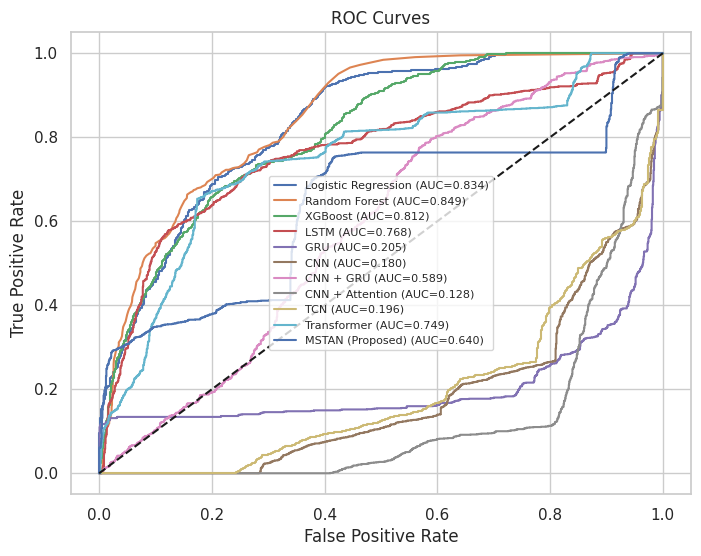

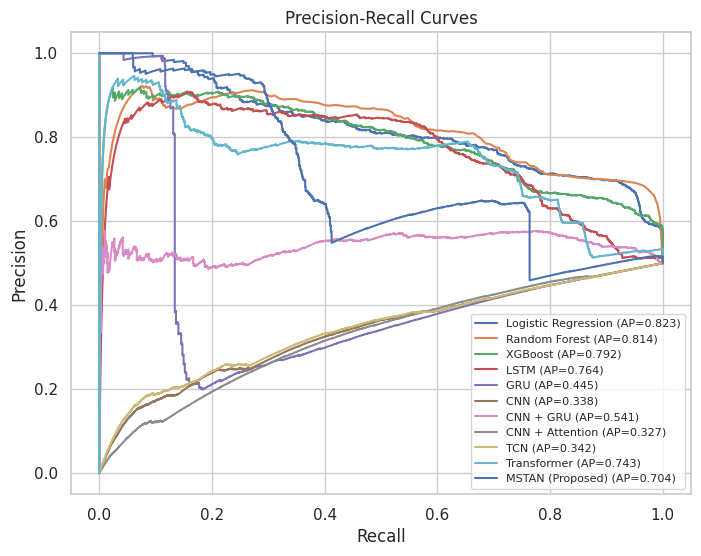

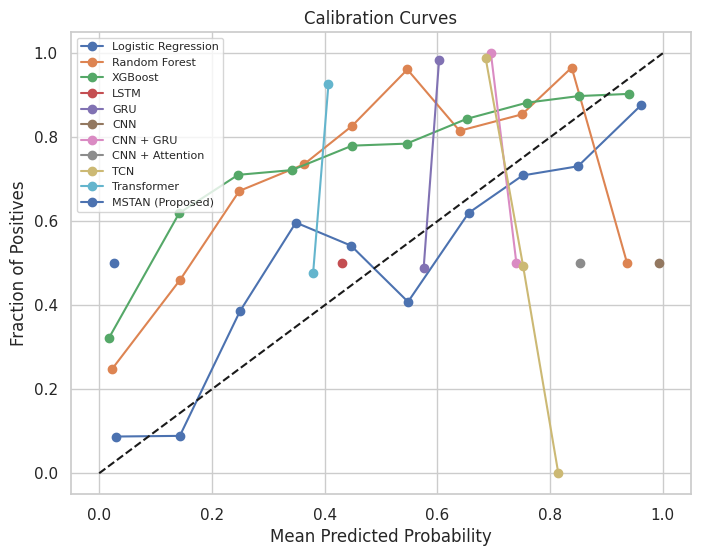

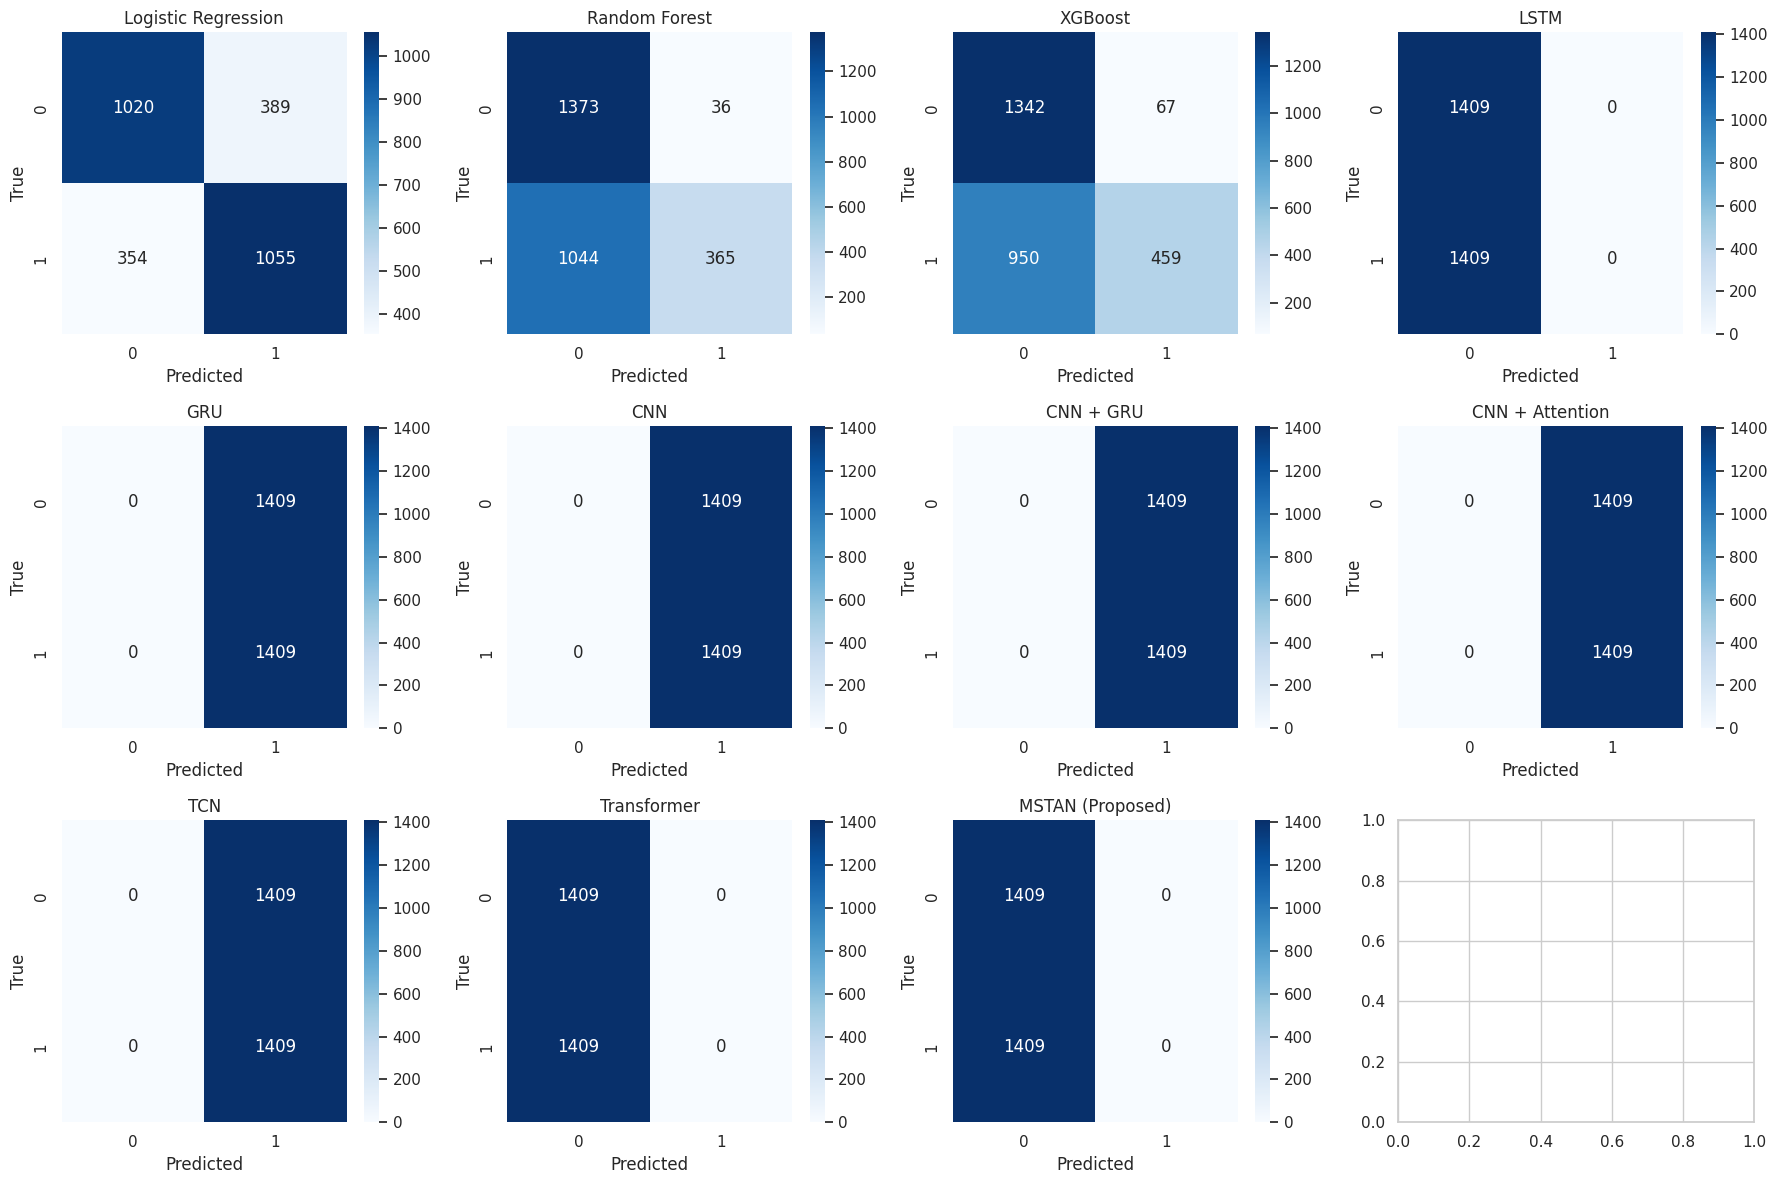

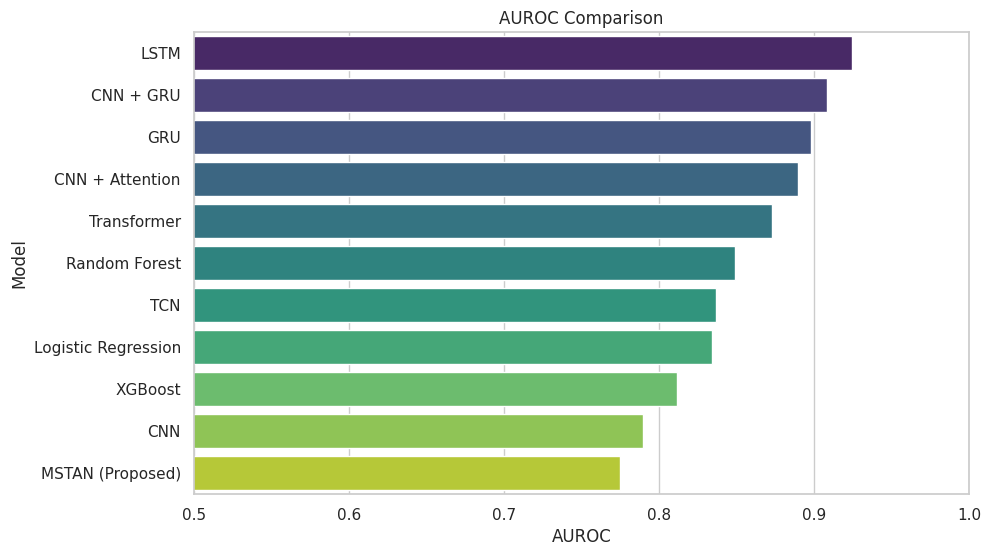

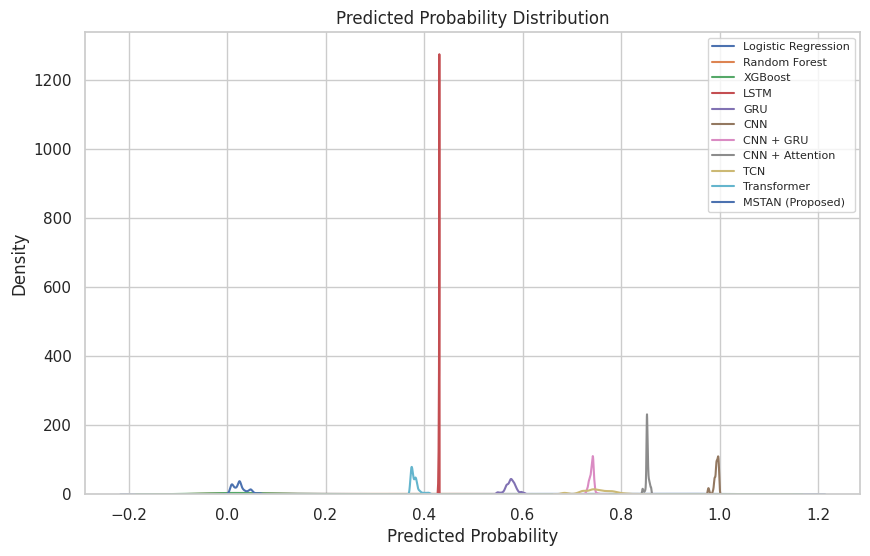

✅ All figures generated successfully.


In [ ]:
# ============================================================
# 📊 FULL FIGURE GENERATION CELL
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,6)

# ------------------------------------------------------------
# 1️⃣ Collect All Model Predictions Again
# ------------------------------------------------------------

model_predictions = {}

# Classical ML
model_predictions["Logistic Regression"] = logreg.predict_proba(X_test_flat)[:,1]
model_predictions["Random Forest"] = rf.predict_proba(X_test_flat)[:,1]
model_predictions["XGBoost"] = xgb.predict_proba(X_test_flat)[:,1]

# Deep Learning
model_predictions["LSTM"] = build_lstm(X_train.shape[1:]).predict(X_test, verbose=0).flatten()
model_predictions["GRU"] = build_gru(X_train.shape[1:]).predict(X_test, verbose=0).flatten()
model_predictions["CNN"] = build_cnn(X_train.shape[1:]).predict(X_test, verbose=0).flatten()
model_predictions["CNN + GRU"] = build_cnn_gru(X_train.shape[1:]).predict(X_test, verbose=0).flatten()
model_predictions["CNN + Attention"] = build_cnn_attention(X_train.shape[1:]).predict(X_test, verbose=0).flatten()
model_predictions["TCN"] = build_tcn(X_train.shape[1:]).predict(X_test, verbose=0).flatten()
model_predictions["Transformer"] = build_transformer(X_train.shape[1:]).predict(X_test, verbose=0).flatten()
model_predictions["MSTAN (Proposed)"] = build_mstan(X_train_t.shape[1:]).predict(X_test_t, verbose=0).flatten()

# ------------------------------------------------------------
# 2️⃣ ROC Curves
# ------------------------------------------------------------

plt.figure()
for name, y_prob in model_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(fontsize=8)
plt.show()


# ------------------------------------------------------------
# 3️⃣ Precision-Recall Curves
# ------------------------------------------------------------

plt.figure()
for name, y_prob in model_predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(fontsize=8)
plt.show()


# ------------------------------------------------------------
# 4️⃣ Calibration Curves
# ------------------------------------------------------------

plt.figure()
for name, y_prob in model_predictions.items():
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves")
plt.legend(fontsize=8)
plt.show()


# ------------------------------------------------------------
# 5️⃣ Confusion Matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 4, figsize=(18,12))
axes = axes.flatten()

for idx, (name, y_prob) in enumerate(model_predictions.items()):
    y_pred = (y_prob > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d",
                cmap="Blues", ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6️⃣ AUROC Bar Plot
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
sorted_df = df_results.sort_values("AUROC", ascending=False)

sns.barplot(
    data=sorted_df,
    x="AUROC",
    y="Model",
    palette="viridis"
)

plt.title("AUROC Comparison")
plt.xlim(0.5,1.0)
plt.show()


# ------------------------------------------------------------
# 7️⃣ Probability Distribution (Calibration Insight)
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
for name, y_prob in model_predictions.items():
    sns.kdeplot(y_prob, label=name, fill=False)

plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability")
plt.legend(fontsize=8)
plt.show()

print("✅ All figures generated successfully.")